In [9]:
from pathlib import Path
import numpy as np
import pandas as pd

# ============================================================
# MAIN CONFIG
# ============================================================
DATASET_NAME = "old"
LABEL_NAME = "box2deg"

CASE_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2025_JJASO"
)

OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CM_DIR = OUT_DIR / "confusion_matrices"
CM_DIR.mkdir(parents=True, exist_ok=True)

FI_DIR = OUT_DIR / "feature_importance"
FI_DIR.mkdir(parents=True, exist_ok=True)

LEADS = [6, 12, 24, 48]
RANDOM_STATE = 42
N_SPLITS = 5

FEATURE_COLS = [
    "lon", "lat", "month",
    "area_km2", "tb_mean", "tb_min",
    "speed_kmh", "direction_deg",
    "eta850_abs", "rh600", "wshear_200_850",
    "pi_vmax_ms", "gpi"
]

ID_COLS = [
    "track_id", "time",
    "centroid_lon", "centroid_lat"
]

print("CASE_DIR:", CASE_DIR)
print("OUT_DIR:", OUT_DIR)

CASE_DIR: C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2025_JJASO
OUT_DIR: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final


In [10]:
# ============================================================
# CASE TABLE QC
# ============================================================
qc_rows = []

for L in LEADS:
    fp = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    if not fp.exists():
        print("[MISSING]", fp)
        continue

    df = pd.read_csv(fp)
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)

    qc_rows.append({
        "lead_h": L,
        "rows": len(df),
        "positive": int(df["y"].sum()),
        "negative": int((df["y"] == 0).sum()),
        "pos_frac": float(df["y"].mean()),
        "time_min": df["time"].min(),
        "time_max": df["time"].max(),
        "unique_tracks": df["track_id"].nunique(),
        "any_predictor_nan_frac": float(df[FEATURE_COLS].isna().any(axis=1).mean()),
        "speed_nan_frac": float(df["speed_kmh"].isna().mean()),
        "direction_nan_frac": float(df["direction_deg"].isna().mean()),
        "pi_nan_frac": float(df["pi_vmax_ms"].isna().mean()),
        "gpi_nan_frac": float(df["gpi"].isna().mean()),
    })

qc = pd.DataFrame(qc_rows)
qc.to_csv(OUT_DIR / "case_table_qc.csv", index=False)

qc

,lead_h,rows,positive,negative,pos_frac,time_min,time_max,unique_tracks,any_predictor_nan_frac,speed_nan_frac,direction_nan_frac,pi_nan_frac,gpi_nan_frac
0,6,1338,223,1115,0.166667,2009-06-01 09:00:00,2025-10-28 00:00:00,1338,0.577728,0.464873,0.464873,0.195815,0.195815
1,12,1242,207,1035,0.166667,2009-06-01 00:00:00,2025-10-29 21:00:00,1240,0.549114,0.452496,0.452496,0.179549,0.179549
2,24,1050,175,875,0.166667,2009-06-03 09:00:00,2025-10-30 06:00:00,1049,0.602857,0.498095,0.498095,0.191429,0.191429
3,48,756,126,630,0.166667,2009-06-02 09:00:00,2025-10-28 18:00:00,756,0.630952,0.500000,0.500000,0.214286,0.214286


In [11]:
# ============================================================
# MODELS + HELPERS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier


def get_models(random_state=42):
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs"
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=600,
            random_state=random_state,
            class_weight="balanced",
            n_jobs=-1
        ),

        "AdaBoost": AdaBoostClassifier(
            n_estimators=600,
            random_state=random_state
        ),

        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=0.001,
            max_iter=1000,
            random_state=random_state
        ),

        "KNN": KNeighborsClassifier(
            n_neighbors=5
        ),

        "Naive Bayes": GaussianNB(),

        "SVM": SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=random_state
        ),

        "QDA": QuadraticDiscriminantAnalysis(
            reg_param=0.01
        ),

        "Decision Tree": DecisionTreeClassifier(
            random_state=random_state,
            class_weight="balanced"
        ),
    }


def model_needs_scaling(model_name):
    return model_name in [
        "Logistic Regression",
        "MLP",
        "KNN",
        "Naive Bayes",
        "SVM",
        "QDA"
    ]


def make_pipeline(model_name, model):
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if model_needs_scaling(model_name):
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model))

    return Pipeline(steps)


def get_cv(y, groups=None, n_splits=5, random_state=42):
    n_pos = int(np.sum(y == 1))
    n_neg = int(np.sum(y == 0))

    n_splits_eff = min(n_splits, n_pos, n_neg)

    if n_splits_eff < 2:
        raise ValueError("Not enough positive/negative samples for CV.")

    if groups is not None:
        return StratifiedGroupKFold(
            n_splits=n_splits_eff,
            shuffle=True,
            random_state=random_state
        ), "StratifiedGroupKFold", n_splits_eff

    return StratifiedKFold(
        n_splits=n_splits_eff,
        shuffle=True,
        random_state=random_state
    ), "StratifiedKFold", n_splits_eff


def safe_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    out = {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        out["roc_auc"] = roc_auc_score(y_true, y_score)
    except Exception:
        out["roc_auc"] = np.nan

    try:
        out["pr_auc"] = average_precision_score(y_true, y_score)
    except Exception:
        out["pr_auc"] = np.nan

    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    except Exception:
        tn, fp, fn, tp = np.nan, np.nan, np.nan, np.nan

    out["tn"] = tn
    out["fp"] = fp
    out["fn"] = fn
    out["tp"] = tp

    return out


def threshold_scan(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    valid = np.isfinite(y_score)
    y_true = y_true[valid]
    y_score = y_score[valid]

    if len(y_true) == 0:
        return pd.DataFrame()

    # percentile-based thresholds are more stable than fixed linear spacing
    thresholds = np.unique(np.nanpercentile(y_score, np.linspace(0, 100, 501)))

    rows = []

    for th in thresholds:
        m = safe_metrics(y_true, y_score, threshold=th)
        rows.append(m)

    scan = pd.DataFrame(rows)
    return scan.sort_values(["f1", "recall", "precision"], ascending=False).reset_index(drop=True)

In [12]:
# ============================================================
# MANUAL 5-FOLD GROUPED CV
# Saves:
#   1. fold metrics
#   2. out-of-fold probabilities
#   3. default-threshold global metrics
#   4. tuned-threshold global metrics
# ============================================================

def run_one_model_cv(
    case_df,
    lead_h,
    model_name,
    model,
    dataset_name=DATASET_NAME,
    label_name=LABEL_NAME,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS
):
    df = case_df.copy()
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)

    X = df[FEATURE_COLS].copy()
    y = df["y"].astype(int).values
    groups = df["track_id"].astype(str).values if "track_id" in df.columns else None

    cv, cv_name, n_splits_eff = get_cv(
        y=y,
        groups=groups,
        n_splits=n_splits,
        random_state=random_state
    )

    pipe = make_pipeline(model_name, model)

    fold_rows = []
    oof_rows = []

    if groups is not None:
        splitter = cv.split(X, y, groups)
    else:
        splitter = cv.split(X, y)

    for fold_id, (train_idx, test_idx) in enumerate(splitter, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        pipe.fit(X_train, y_train)

        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        else:
            # fallback, not expected for current models
            y_score = pipe.decision_function(X_test)
            y_score = (y_score - np.nanmin(y_score)) / (np.nanmax(y_score) - np.nanmin(y_score) + 1e-12)

        fold_metric = safe_metrics(y_test, y_score, threshold=0.5)

        fold_metric.update({
            "dataset": dataset_name,
            "label": label_name,
            "lead_h": lead_h,
            "model": model_name,
            "fold": fold_id,
            "cv": cv_name,
            "n_splits": n_splits_eff,
            "train_n": len(train_idx),
            "test_n": len(test_idx),
            "train_pos": int(y_train.sum()),
            "test_pos": int(y_test.sum()),
            "train_neg": int((y_train == 0).sum()),
            "test_neg": int((y_test == 0).sum()),
        })

        fold_rows.append(fold_metric)

        oof = df.iloc[test_idx][ID_COLS].copy()
        oof["dataset"] = dataset_name
        oof["label"] = label_name
        oof["lead_h"] = lead_h
        oof["model"] = model_name
        oof["fold"] = fold_id
        oof["y_true"] = y_test
        oof["y_score"] = y_score
        oof["y_pred_default"] = (y_score >= 0.5).astype(int)

        oof_rows.append(oof)

    fold_df = pd.DataFrame(fold_rows)
    oof_df = pd.concat(oof_rows, ignore_index=True)

    # ------------------------------------------------------------
    # Global OOF default-threshold metrics
    # ------------------------------------------------------------
    default_metrics = safe_metrics(
        oof_df["y_true"].values,
        oof_df["y_score"].values,
        threshold=0.5
    )

    default_row = {
        "dataset": dataset_name,
        "label": label_name,
        "lead_h": lead_h,
        "model": model_name,
        "metric_type": "oof_default_0.5",
        **default_metrics
    }

    # ------------------------------------------------------------
    # OOF threshold tuning
    # ------------------------------------------------------------
    scan = threshold_scan(
        oof_df["y_true"].values,
        oof_df["y_score"].values
    )

    if len(scan) > 0:
        best = scan.iloc[0].to_dict()
        best_threshold = float(best["threshold"])
    else:
        best = {}
        best_threshold = 0.5

    oof_df["y_pred_tuned"] = (oof_df["y_score"] >= best_threshold).astype(int)

    tuned_metrics = safe_metrics(
        oof_df["y_true"].values,
        oof_df["y_score"].values,
        threshold=best_threshold
    )

    tuned_row = {
        "dataset": dataset_name,
        "label": label_name,
        "lead_h": lead_h,
        "model": model_name,
        "metric_type": "oof_tuned_threshold",
        **tuned_metrics
    }

    return fold_df, oof_df, pd.DataFrame([default_row, tuned_row]), scan

In [13]:
# ============================================================
# RUN ALL MODELS / ALL LEADS
# ============================================================

models = get_models(random_state=RANDOM_STATE)

all_fold_results = []
all_oof_results = []
all_oof_summary = []
all_threshold_scans = []

for L in LEADS:
    case_csv = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    if not case_csv.exists():
        print("[MISSING]", case_csv)
        continue

    case_df = pd.read_csv(case_csv)

    print("\n" + "=" * 80)
    print(f"LEAD {L}h | rows={len(case_df)} | positives={int(case_df['y'].sum())} | negatives={int((case_df['y'] == 0).sum())}")
    print("=" * 80)

    for model_name, model in models.items():
        print(f"\nRunning model: {model_name}")

        try:
            fold_df, oof_df, oof_summary_df, scan_df = run_one_model_cv(
                case_df=case_df,
                lead_h=L,
                model_name=model_name,
                model=model,
                dataset_name=DATASET_NAME,
                label_name=LABEL_NAME,
                random_state=RANDOM_STATE,
                n_splits=N_SPLITS
            )

            all_fold_results.append(fold_df)
            all_oof_results.append(oof_df)
            all_oof_summary.append(oof_summary_df)

            scan_df["dataset"] = DATASET_NAME
            scan_df["label"] = LABEL_NAME
            scan_df["lead_h"] = L
            scan_df["model"] = model_name
            all_threshold_scans.append(scan_df)

            # Save model-specific OOF predictions immediately
            safe_model_name = model_name.replace(" ", "_").replace("/", "_")
            oof_fp = OUT_DIR / f"oof_{DATASET_NAME}_{LABEL_NAME}_{L}h_{safe_model_name}.csv"
            oof_df.to_csv(oof_fp, index=False)

            scan_fp = OUT_DIR / f"threshold_scan_{DATASET_NAME}_{LABEL_NAME}_{L}h_{safe_model_name}.csv"
            scan_df.to_csv(scan_fp, index=False)

        except Exception as e:
            print(f"[ERROR] {model_name} lead {L}h failed: {e}")

            err_row = pd.DataFrame([{
                "dataset": DATASET_NAME,
                "label": LABEL_NAME,
                "lead_h": L,
                "model": model_name,
                "error": str(e)
            }])

            all_oof_summary.append(err_row)

# ------------------------------------------------------------
# Save combined outputs
# ------------------------------------------------------------
fold_results = pd.concat(all_fold_results, ignore_index=True)
oof_results = pd.concat(all_oof_results, ignore_index=True)
oof_summary = pd.concat(all_oof_summary, ignore_index=True)
threshold_scans = pd.concat(all_threshold_scans, ignore_index=True)

fold_results.to_csv(OUT_DIR / "fold_results_all_models.csv", index=False)
oof_results.to_csv(OUT_DIR / "oof_predictions_all_models.csv", index=False)
oof_summary.to_csv(OUT_DIR / "oof_summary_default_and_tuned_all_models.csv", index=False)
threshold_scans.to_csv(OUT_DIR / "threshold_scans_all_models.csv", index=False)

print("\n[SAVED]")
print(OUT_DIR / "fold_results_all_models.csv")
print(OUT_DIR / "oof_predictions_all_models.csv")
print(OUT_DIR / "oof_summary_default_and_tuned_all_models.csv")
print(OUT_DIR / "threshold_scans_all_models.csv")


LEAD 6h | rows=1338 | positives=223 | negatives=1115

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Running model: MLP

Running model: KNN

Running model: Naive Bayes

Running model: SVM

Running model: QDA

Running model: Decision Tree

LEAD 12h | rows=1242 | positives=207 | negatives=1035

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Running model: MLP

Running model: KNN

Running model: Naive Bayes

Running model: SVM

Running model: QDA

Running model: Decision Tree

LEAD 24h | rows=1050 | positives=175 | negatives=875

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Running model: MLP

Running model: KNN

Running model: Naive Bayes

Running model: SVM

Running model: QDA

Running model: Decision Tree

LEAD 48h | rows=756 | positives=126 | negatives=630

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Runni

In [14]:
# ============================================================
# FOLD-LEVEL MEAN ± STD SUMMARY
# ============================================================

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

summary_rows = []

for (lead_h, model), g in fold_results.groupby(["lead_h", "model"]):
    row = {
        "dataset": DATASET_NAME,
        "label": LABEL_NAME,
        "lead_h": lead_h,
        "model": model,
        "folds": g["fold"].nunique(),
        "samples_mean": g["test_n"].mean(),
        "test_pos_mean": g["test_pos"].mean(),
        "test_neg_mean": g["test_neg"].mean(),
    }

    for metric in metric_cols:
        row[f"{metric}_mean"] = g[metric].mean()
        row[f"{metric}_std"] = g[metric].std()

    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows)
cv_summary = cv_summary.sort_values(["lead_h", "f1_mean"], ascending=[True, False])

cv_summary.to_csv(OUT_DIR / "cv_summary_mean_std_all_models.csv", index=False)

cv_summary

,dataset,label,lead_h,model,folds,samples_mean,test_pos_mean,test_neg_mean,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
7,old,box2deg,6,Random Forest,5,267.6,44.6,223.0,0.881939,0.017437,0.709113,0.069058,0.485514,0.060165,0.573616,0.048312,0.913459,0.015077,0.689244,0.082639
4,old,box2deg,6,MLP,5,267.6,44.6,223.0,0.865490,0.019772,0.606092,0.077160,0.537561,0.054127,0.567048,0.047656,0.862735,0.025697,0.589701,0.094882
5,old,box2deg,6,Naive Bayes,5,267.6,44.6,223.0,0.867748,0.029643,0.622934,0.073317,0.521420,0.063010,0.565751,0.056988,0.857036,0.018951,0.558387,0.053605
3,old,box2deg,6,Logistic Regression,5,267.6,44.6,223.0,0.794502,0.027779,0.432452,0.029564,0.787388,0.033684,0.557680,0.026954,0.859078,0.006871,0.563711,0.044630
0,old,box2deg,6,AdaBoost,5,267.6,44.6,223.0,0.871463,0.013470,0.638368,0.082320,0.487916,0.065880,0.552209,0.068927,0.893033,0.026889,0.615704,0.104763
8,old,box2deg,6,SVM,5,267.6,44.6,223.0,0.875971,0.028445,0.691958,0.102746,0.458491,0.079278,0.549054,0.078862,0.889125,0.018141,0.656097,0.070799
6,old,box2deg,6,QDA,5,267.6,44.6,223.0,0.863262,0.022109,0.612363,0.046917,0.459750,0.067482,0.523923,0.058057,0.860817,0.018106,0.554479,0.057484
1,old,box2deg,6,Decision Tree,5,267.6,44.6,223.0,0.838582,0.011640,0.509109,0.090780,0.492446,0.061802,0.498403,0.066212,0.699643,0.028938,0.336848,0.075899
2,old,box2deg,6,KNN,5,267.6,44.6,223.0,0.862502,0.023539,0.643812,0.113367,0.400154,0.039376,0.489909,0.049417,0.800199,0.039680,0.502049,0.066601
14,old,box2deg,12,Naive Bayes,5,248.4,41.4,207.0,0.867128,0.019932,0.624628,0.094757,0.491539,0.088491,0.548814,0.086843,0.843642,0.029028,0.543773,0.064868


In [15]:
# ============================================================
# BEST MODELS BY LEAD
# Based on fold-level mean F1
# ============================================================

best_by_lead_cv = (
    cv_summary
    .sort_values(["lead_h", "f1_mean"], ascending=[True, False])
    .groupby("lead_h")
    .head(1)
    .reset_index(drop=True)
)

best_by_lead_cv.to_csv(OUT_DIR / "best_models_by_lead_cv_f1.csv", index=False)

best_by_lead_cv[
    [
        "lead_h", "model",
        "f1_mean", "precision_mean", "recall_mean",
        "roc_auc_mean", "pr_auc_mean"
    ]
]

,lead_h,model,f1_mean,precision_mean,recall_mean,roc_auc_mean,pr_auc_mean
0,6,Random Forest,0.573616,0.709113,0.485514,0.913459,0.689244
1,12,Naive Bayes,0.548814,0.624628,0.491539,0.843642,0.543773
2,24,AdaBoost,0.462053,0.545091,0.407664,0.845128,0.529333
3,48,MLP,0.375909,0.500164,0.357551,0.778961,0.415243


In [16]:
# ============================================================
# OOF DEFAULT VS TUNED THRESHOLD SUMMARY
# ============================================================

oof_summary_clean = oof_summary.copy()

# keep only successful rows
oof_summary_clean = oof_summary_clean[oof_summary_clean["metric_type"].notna()].copy()

oof_default = oof_summary_clean[oof_summary_clean["metric_type"] == "oof_default_0.5"].copy()
oof_tuned = oof_summary_clean[oof_summary_clean["metric_type"] == "oof_tuned_threshold"].copy()

oof_default = oof_default.sort_values(["lead_h", "f1"], ascending=[True, False])
oof_tuned = oof_tuned.sort_values(["lead_h", "f1"], ascending=[True, False])

oof_default.to_csv(OUT_DIR / "oof_default_threshold_summary.csv", index=False)
oof_tuned.to_csv(OUT_DIR / "oof_tuned_threshold_summary.csv", index=False)

print("Best default-threshold models:")
display(oof_default.groupby("lead_h").head(1)[
    ["lead_h", "model", "threshold", "f1", "precision", "recall", "roc_auc", "pr_auc"]
])

print("Best tuned-threshold models:")
display(oof_tuned.groupby("lead_h").head(1)[
    ["lead_h", "model", "threshold", "f1", "precision", "recall", "roc_auc", "pr_auc"]
])

Best default-threshold models:


,lead_h,model,threshold,f1,precision,recall,roc_auc,pr_auc
2,6,Random Forest,0.5,0.577540,0.715232,0.484305,0.913740,0.687383
28,12,Naive Bayes,0.5,0.552846,0.629630,0.492754,0.840225,0.529843
40,24,AdaBoost,0.5,0.462541,0.537879,0.405714,0.841117,0.511400
60,48,MLP,0.5,0.376682,0.432990,0.333333,0.761061,0.345180


Best tuned-threshold models:


,lead_h,model,threshold,f1,precision,recall,roc_auc,pr_auc
3,6,Random Forest,0.286370,0.659836,0.607547,0.721973,0.913740,0.687383
21,12,Random Forest,0.257850,0.612576,0.527972,0.729469,0.892189,0.608882
39,24,Random Forest,0.286667,0.569892,0.538071,0.605714,0.856307,0.510777
57,48,Random Forest,0.153400,0.497630,0.354730,0.833333,0.817246,0.425070


In [17]:
# ============================================================
# METRIC TABLES BY MODEL AND LEAD
# Using fold-level mean metrics
# ============================================================

def save_metric_table(metric_name):
    col = f"{metric_name}_mean"

    table = cv_summary.pivot(
        index="model",
        columns="lead_h",
        values=col
    )

    table = table[[6, 12, 24, 48]]
    out_fp = OUT_DIR / f"table_{metric_name}_cv_mean.csv"
    table.to_csv(out_fp)

    print("\n", metric_name.upper())
    display(table)

    return table

f1_table = save_metric_table("f1")
precision_table = save_metric_table("precision")
recall_table = save_metric_table("recall")
roc_auc_table = save_metric_table("roc_auc")
pr_auc_table = save_metric_table("pr_auc")


 F1


lead_h,6,12,24,48
model,,,,
AdaBoost,0.552209,0.503276,0.462053,0.313160
Decision Tree,0.498403,0.480250,0.406162,0.301697
KNN,0.489909,0.435889,0.398691,0.293212
Logistic Regression,0.557680,0.513765,0.411536,0.355185
MLP,0.567048,0.521746,0.418801,0.375909
Naive Bayes,0.565751,0.548814,0.353627,0.340929
QDA,0.523923,0.465072,0.316654,0.357115
Random Forest,0.573616,0.480935,0.364848,0.194090
SVM,0.549054,0.457637,0.376247,0.181979



 PRECISION


lead_h,6,12,24,48
model,,,,
AdaBoost,0.638368,0.588953,0.545091,0.408687
Decision Tree,0.509109,0.497851,0.424964,0.322362
KNN,0.643812,0.621733,0.535308,0.463016
Logistic Regression,0.432452,0.394134,0.308854,0.252651
MLP,0.606092,0.554503,0.482790,0.500164
Naive Bayes,0.622934,0.624628,0.560562,0.303092
QDA,0.612363,0.600982,0.592088,0.323889
Random Forest,0.709113,0.658403,0.599969,0.503333
SVM,0.691958,0.612053,0.602906,0.608333



 RECALL


lead_h,6,12,24,48
model,,,,
AdaBoost,0.487916,0.445297,0.407664,0.262249
Decision Tree,0.492446,0.467989,0.393539,0.298218
KNN,0.400154,0.337288,0.323986,0.231009
Logistic Regression,0.787388,0.741642,0.630424,0.622886
MLP,0.537561,0.496394,0.379011,0.357551
Naive Bayes,0.521420,0.491539,0.258854,0.528499
QDA,0.459750,0.380266,0.216617,0.480678
Random Forest,0.485514,0.383278,0.263583,0.127384
SVM,0.458491,0.373190,0.277272,0.118833



 ROC_AUC


lead_h,6,12,24,48
model,,,,
AdaBoost,0.893033,0.884894,0.845128,0.793791
Decision Tree,0.699643,0.687161,0.643029,0.586001
KNN,0.800199,0.780908,0.789557,0.732263
Logistic Regression,0.859078,0.837164,0.750861,0.682818
MLP,0.862735,0.864606,0.796282,0.778961
Naive Bayes,0.857036,0.843642,0.803462,0.728975
QDA,0.860817,0.847153,0.789488,0.731795
Random Forest,0.913459,0.894275,0.862248,0.821074
SVM,0.889125,0.869824,0.817871,0.791089



 PR_AUC


lead_h,6,12,24,48
model,,,,
AdaBoost,0.615704,0.598751,0.529333,0.410901
Decision Tree,0.336848,0.325721,0.278934,0.213737
KNN,0.502049,0.437899,0.405674,0.337298
Logistic Regression,0.563711,0.502325,0.414310,0.266473
MLP,0.589701,0.539598,0.474554,0.415243
Naive Bayes,0.558387,0.543773,0.492497,0.354216
QDA,0.554479,0.531807,0.472654,0.381882
Random Forest,0.689244,0.612119,0.526982,0.461016
SVM,0.656097,0.553676,0.476446,0.424541


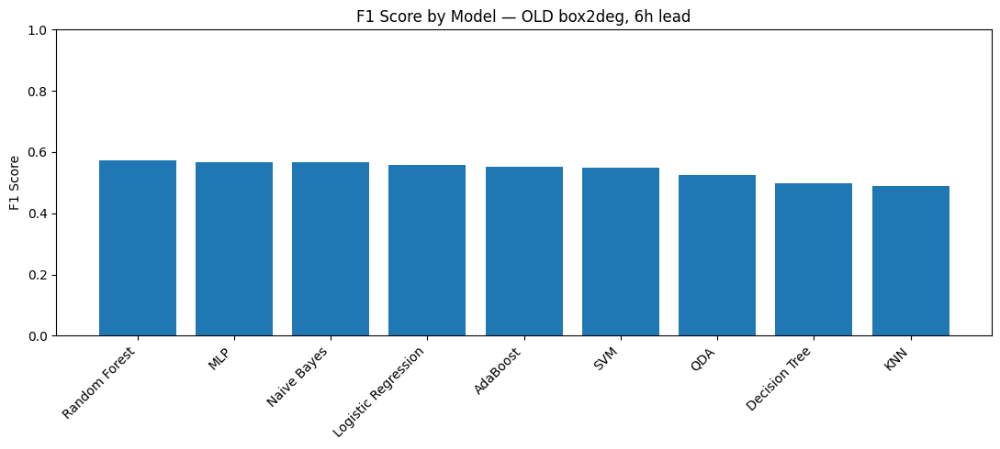

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_f1_6h.png


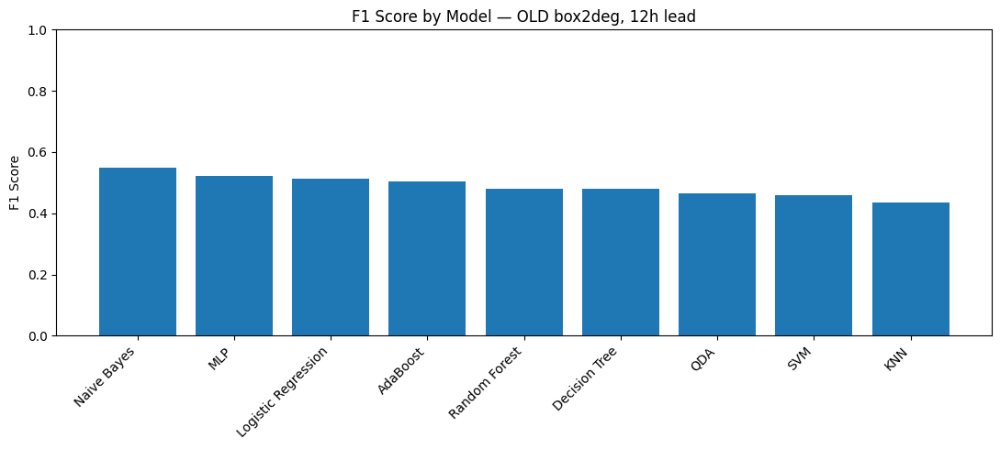

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_f1_12h.png


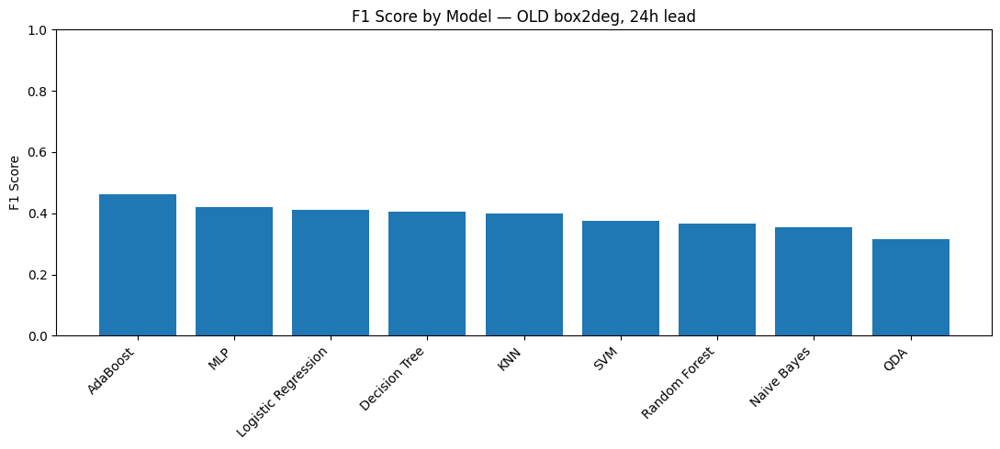

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_f1_24h.png


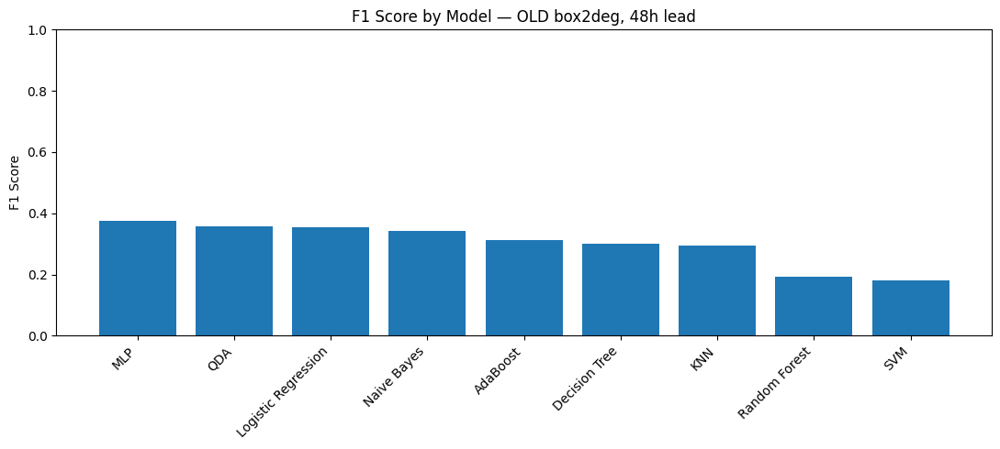

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_f1_48h.png


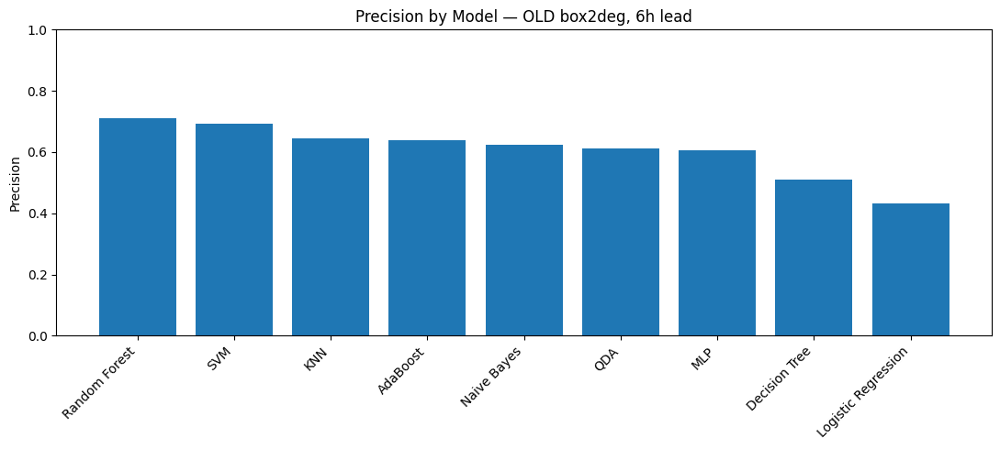

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_precision_6h.png


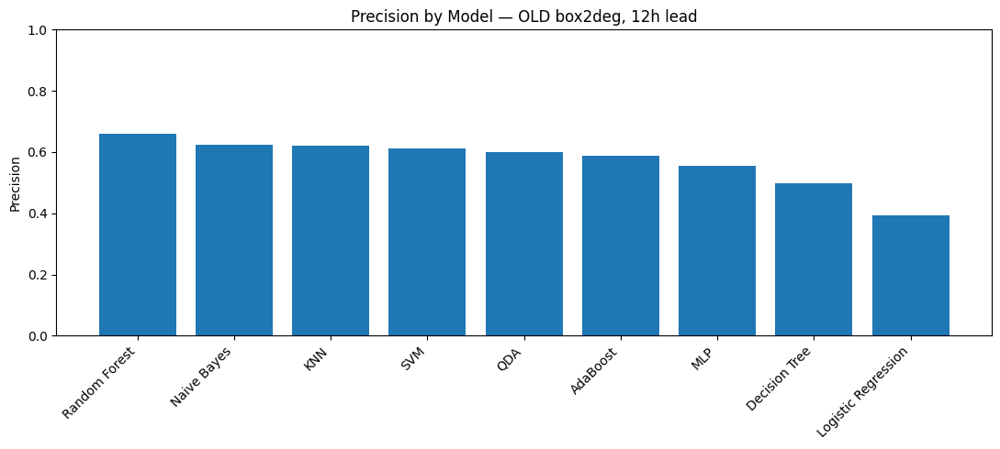

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_precision_12h.png


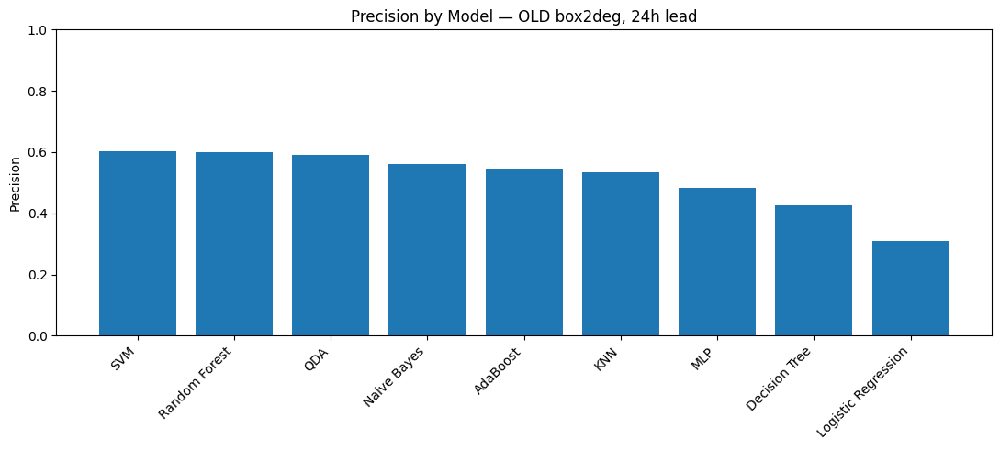

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_precision_24h.png


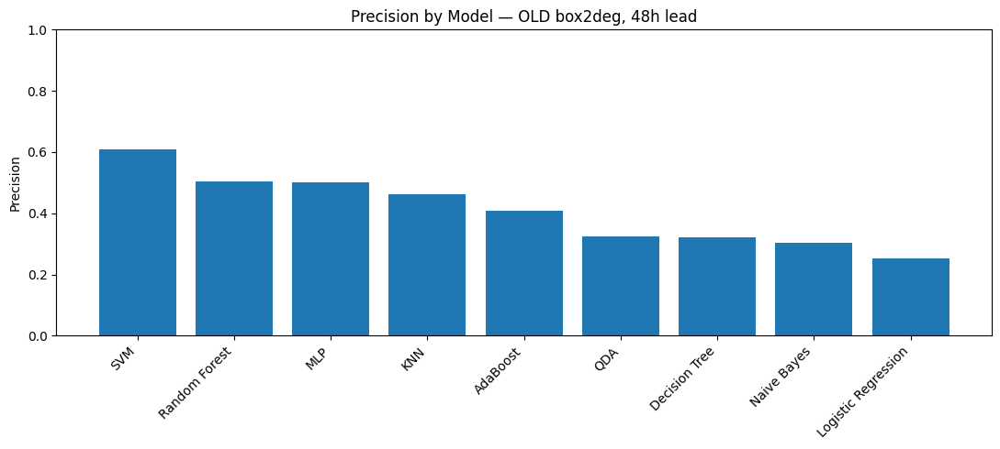

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_precision_48h.png


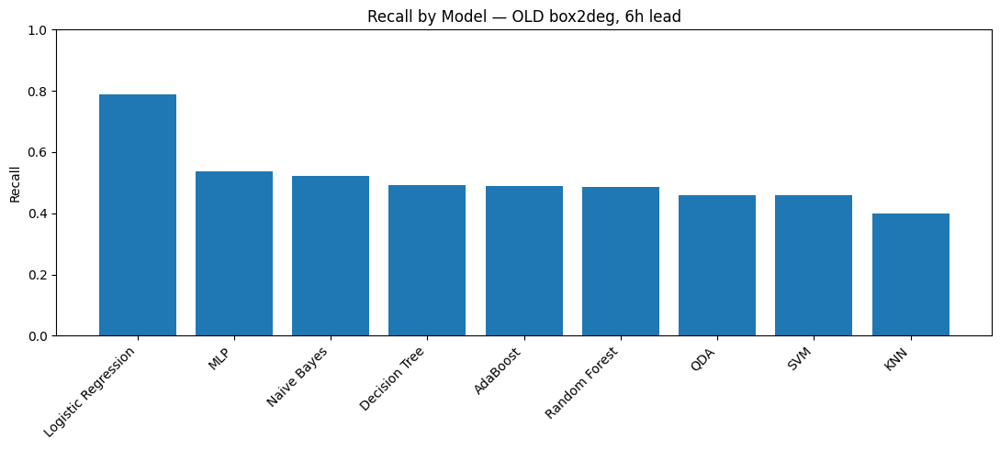

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_recall_6h.png


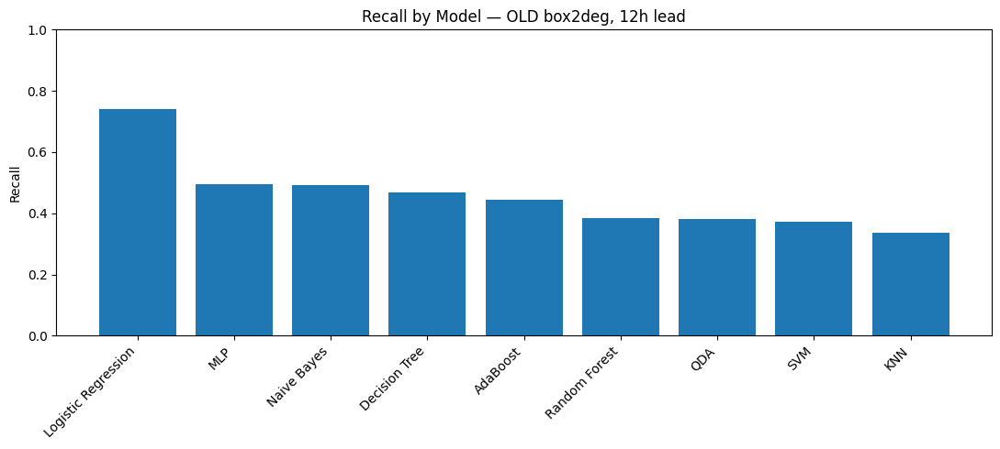

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_recall_12h.png


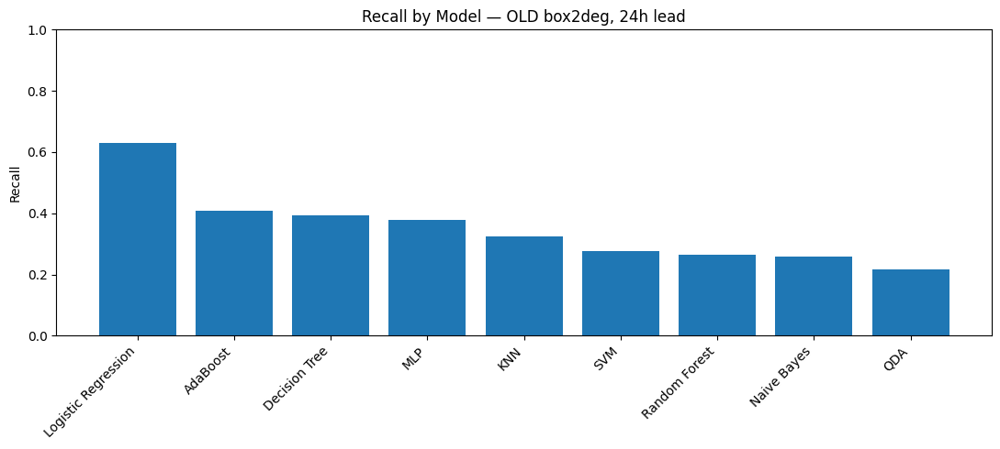

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_recall_24h.png


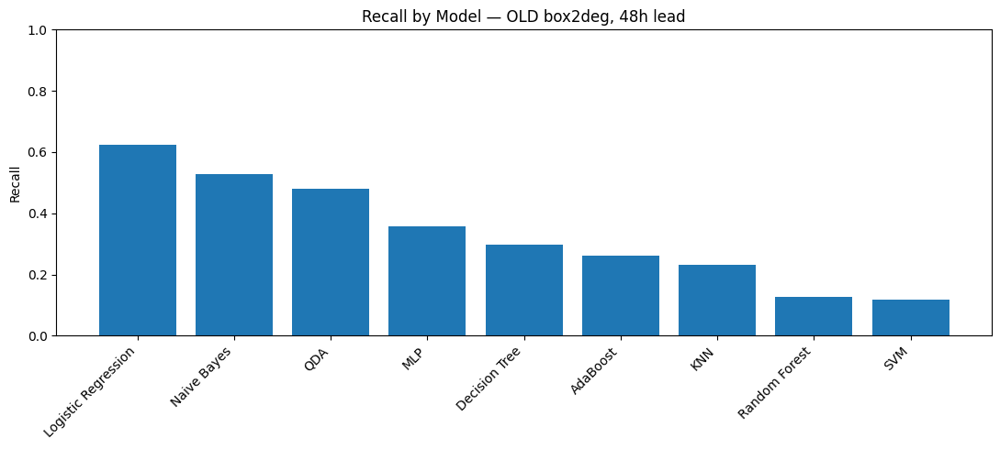

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_recall_48h.png


In [18]:
# ============================================================
# BAR PLOTS FOR F1 / PRECISION / RECALL
# ============================================================

import matplotlib.pyplot as plt

def plot_metric_by_lead(metric_col, ylabel, filename_prefix):
    for L in LEADS:
        sub = cv_summary[cv_summary["lead_h"] == L].copy()
        sub = sub.sort_values(metric_col, ascending=False)

        plt.figure(figsize=(11, 5))
        plt.bar(sub["model"], sub[metric_col])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(ylabel)
        plt.title(f"{ylabel} by Model — {DATASET_NAME.upper()} {LABEL_NAME}, {L}h lead")
        plt.ylim(0, max(1.0, sub[metric_col].max() * 1.15))
        plt.tight_layout()

        out_fp = OUT_DIR / f"{filename_prefix}_{L}h.png"
        plt.savefig(out_fp, dpi=200)
        plt.show()

        print("Saved:", out_fp)

plot_metric_by_lead("f1_mean", "F1 Score", "bar_f1")
plot_metric_by_lead("precision_mean", "Precision", "bar_precision")
plot_metric_by_lead("recall_mean", "Recall", "bar_recall")

In [19]:
# ============================================================
# GPI-ONLY THRESHOLD BASELINE
# ============================================================

def gpi_threshold_baseline(case_csv, lead_h):
    df = pd.read_csv(case_csv)
    df = df.dropna(subset=["gpi"]).copy()

    y = df["y"].astype(int).values
    score = df["gpi"].astype(float).values

    scan = threshold_scan(y, score)

    if len(scan) == 0:
        return pd.DataFrame(), pd.DataFrame()

    best = scan.iloc[[0]].copy()
    best["dataset"] = DATASET_NAME
    best["label"] = LABEL_NAME
    best["lead_h"] = lead_h
    best["model"] = "GPI threshold"

    scan["dataset"] = DATASET_NAME
    scan["label"] = LABEL_NAME
    scan["lead_h"] = lead_h
    scan["model"] = "GPI threshold"

    return scan, best


gpi_scans = []
gpi_bests = []

for L in LEADS:
    case_csv = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    scan, best = gpi_threshold_baseline(case_csv, L)

    if len(scan) > 0:
        scan.to_csv(OUT_DIR / f"gpi_threshold_scan_{L}h.csv", index=False)
        gpi_scans.append(scan)
        gpi_bests.append(best)

if gpi_bests:
    gpi_best = pd.concat(gpi_bests, ignore_index=True)
    gpi_best.to_csv(OUT_DIR / "gpi_threshold_best_by_lead.csv", index=False)
    display(gpi_best[["lead_h", "model", "threshold", "f1", "precision", "recall", "roc_auc", "pr_auc"]])

,lead_h,model,threshold,f1,precision,recall,roc_auc,pr_auc
0,6,GPI threshold,26.172978,0.602020,0.543796,0.674208,0.842163,0.594254
1,12,GPI threshold,13.059708,0.562500,0.439024,0.782609,0.829210,0.562440
2,24,GPI threshold,18.703836,0.518519,0.480392,0.563218,0.762469,0.465047
3,48,GPI threshold,2.571522,0.424125,0.278061,0.893443,0.677775,0.330614


PLOTTING

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import gaussian_kde
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
DATASET_NAME = "old"
LABEL_NAME = "box2deg"

CASE_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2025_JJASO"
)

OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final"
)

PLOT_DIR = OUT_DIR / "plots_old"
CM_DIR = OUT_DIR / "confusion_matrices_old"
FI_DIR = OUT_DIR / "feature_importance_old"

for d in [OUT_DIR, PLOT_DIR, CM_DIR, FI_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LEADS = [6, 12, 24, 48]

FEATURE_COLS = [
    "lon", "lat", "month",
    "area_km2", "tb_mean", "tb_min",
    "speed_kmh", "direction_deg",
    "eta850_abs", "rh600", "wshear_200_850",
    "pi_vmax_ms", "gpi"
]

ID_COLS = [
    "track_id", "time", "centroid_lon", "centroid_lat"
]

# ------------------------------------------------------------
# Load saved ML outputs
# ------------------------------------------------------------
fold_results = pd.read_csv(OUT_DIR / "fold_results_all_models.csv")
oof_all = pd.read_csv(OUT_DIR / "oof_predictions_all_models.csv")
oof_summary = pd.read_csv(OUT_DIR / "oof_summary_default_and_tuned_all_models.csv")
threshold_scans = pd.read_csv(OUT_DIR / "threshold_scans_all_models.csv")

print("Loaded:")
print("fold_results:", fold_results.shape)
print("oof_all:", oof_all.shape)
print("oof_summary:", oof_summary.shape)
print("threshold_scans:", threshold_scans.shape)

Loaded:
fold_results: (180, 24)
oof_all: (39474, 13)
oof_summary: (72, 16)
threshold_scans: (13193, 15)


In [21]:
# ============================================================
# LOAD OLD CASE TABLES
# ============================================================

datasets = {}

for L in LEADS:
    fp = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    if not fp.exists():
        raise FileNotFoundError(fp)

    df = pd.read_csv(fp)
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)
    df["y"] = df["y"].astype(int)

    datasets[L] = df.copy()

    print(f"\nLead {L}h")
    print("Rows:", len(df))
    print("Positive:", int(df["y"].sum()))
    print("Negative:", int((df["y"] == 0).sum()))
    print("Any predictor NaN fraction:", df[FEATURE_COLS].isna().any(axis=1).mean())


Lead 6h
Rows: 1338
Positive: 223
Negative: 1115
Any predictor NaN fraction: 0.577727952167414

Lead 12h
Rows: 1242
Positive: 207
Negative: 1035
Any predictor NaN fraction: 0.5491143317230274

Lead 24h
Rows: 1050
Positive: 175
Negative: 875
Any predictor NaN fraction: 0.6028571428571429

Lead 48h
Rows: 756
Positive: 126
Negative: 630
Any predictor NaN fraction: 0.6309523809523809


In [22]:
# ============================================================
# SUMMARY TABLES
# ============================================================

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

# If cv_summary already exists, load it. Otherwise rebuild from fold_results.
cv_summary_fp = OUT_DIR / "cv_summary_mean_std_all_models.csv"

if cv_summary_fp.exists():
    cv_summary = pd.read_csv(cv_summary_fp)
else:
    summary_rows = []

    for (lead_h, model), g in fold_results.groupby(["lead_h", "model"]):
        row = {
            "dataset": DATASET_NAME,
            "label": LABEL_NAME,
            "lead_h": lead_h,
            "model": model,
            "folds": g["fold"].nunique(),
            "samples_mean": g["test_n"].mean(),
            "test_pos_mean": g["test_pos"].mean(),
            "test_neg_mean": g["test_neg"].mean(),
        }

        for metric in metric_cols:
            row[f"{metric}_mean"] = g[metric].mean()
            row[f"{metric}_std"] = g[metric].std()

        summary_rows.append(row)

    cv_summary = pd.DataFrame(summary_rows)
    cv_summary.to_csv(cv_summary_fp, index=False)

cv_summary = cv_summary.sort_values(["lead_h", "f1_mean"], ascending=[True, False]).reset_index(drop=True)

ranked_table = cv_summary[
    [
        "lead_h", "model",
        "precision_mean", "recall_mean", "f1_mean",
        "roc_auc_mean", "pr_auc_mean"
    ]
].copy()

ranked_table = ranked_table.rename(columns={
    "precision_mean": "precision",
    "recall_mean": "recall",
    "f1_mean": "f1",
    "roc_auc_mean": "roc_auc",
    "pr_auc_mean": "pr_auc",
})

ranked_table.to_csv(OUT_DIR / "model_performance_ranked_by_lead_old.csv", index=False)

best_by_lead = (
    ranked_table
    .sort_values(["lead_h", "f1"], ascending=[True, False])
    .groupby("lead_h", as_index=False)
    .first()
)

best_by_lead.to_csv(OUT_DIR / "best_model_by_lead_old.csv", index=False)

print("\nRanked table:")
display(ranked_table)

print("\nBest model by lead:")
display(best_by_lead)


Ranked table:


,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,6,Random Forest,0.709113,0.485514,0.573616,0.913459,0.689244
1,6,MLP,0.606092,0.537561,0.567048,0.862735,0.589701
2,6,Naive Bayes,0.622934,0.521420,0.565751,0.857036,0.558387
3,6,Logistic Regression,0.432452,0.787388,0.557680,0.859078,0.563711
4,6,AdaBoost,0.638368,0.487916,0.552209,0.893033,0.615704
5,6,SVM,0.691958,0.458491,0.549054,0.889125,0.656097
6,6,QDA,0.612363,0.459750,0.523923,0.860817,0.554479
7,6,Decision Tree,0.509109,0.492446,0.498403,0.699643,0.336848
8,6,KNN,0.643812,0.400154,0.489909,0.800199,0.502049
9,12,Naive Bayes,0.624628,0.491539,0.548814,0.843642,0.543773



Best model by lead:


,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,6,Random Forest,0.709113,0.485514,0.573616,0.913459,0.689244
1,12,Naive Bayes,0.624628,0.491539,0.548814,0.843642,0.543773
2,24,AdaBoost,0.545091,0.407664,0.462053,0.845128,0.529333
3,48,MLP,0.500164,0.357551,0.375909,0.778961,0.415243


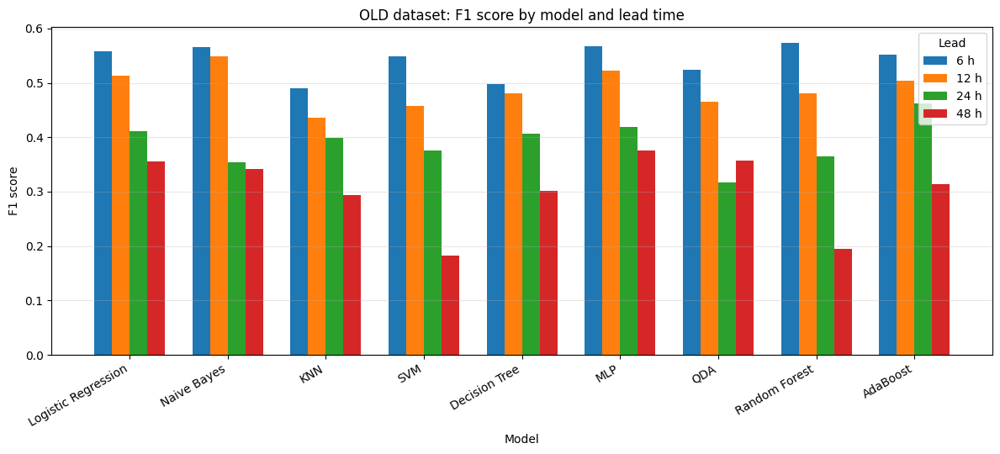

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\bar_f1_by_model_lead_old.png


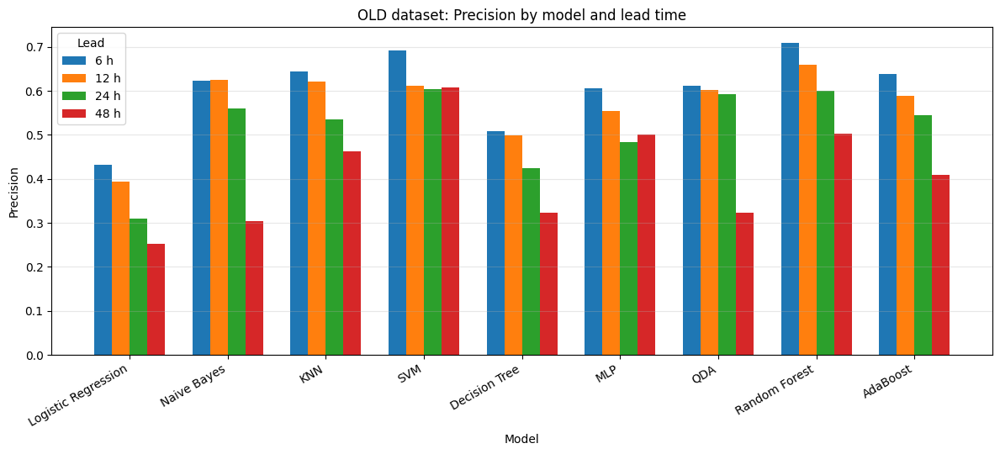

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\bar_precision_by_model_lead_old.png


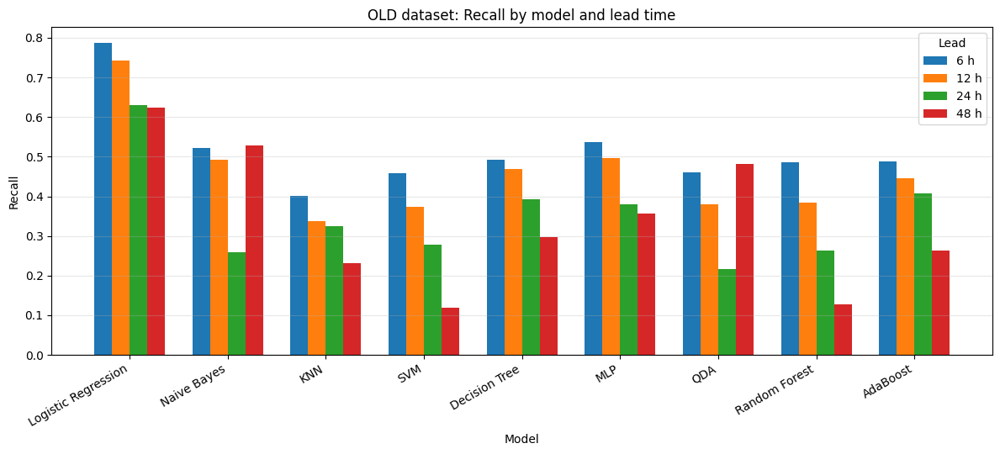

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\bar_recall_by_model_lead_old.png


In [23]:
# ============================================================
# GROUPED BAR PLOTS — OLD
# F1, Precision, Recall
# ============================================================

MODEL_ORDER = [
    "Logistic Regression",
    "Naive Bayes",
    "KNN",
    "SVM",
    "Decision Tree",
    "MLP",
    "QDA",
    "Random Forest",
    "AdaBoost",
]

summary_plot = cv_summary.copy()
summary_plot["model"] = pd.Categorical(summary_plot["model"], categories=MODEL_ORDER, ordered=True)
summary_plot = summary_plot.sort_values(["model", "lead_h"]).copy()

lead_order = [6, 12, 24, 48]


def make_bar_metric(metric_col, ylabel, title, outname):
    piv = summary_plot.pivot(index="model", columns="lead_h", values=metric_col)
    piv = piv.reindex(MODEL_ORDER)
    piv = piv[lead_order]

    x = np.arange(len(piv.index))
    width = 0.18

    fig, ax = plt.subplots(figsize=(12, 5.5))

    for i, lead in enumerate(lead_order):
        ax.bar(
            x + (i - 1.5) * width,
            piv[lead],
            width=width,
            label=f"{lead} h"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(piv.index, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Model")
    ax.set_title(title)
    ax.legend(title="Lead")
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(PLOT_DIR / outname, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", PLOT_DIR / outname)


make_bar_metric(
    metric_col="f1_mean",
    ylabel="F1 score",
    title="OLD dataset: F1 score by model and lead time",
    outname="bar_f1_by_model_lead_old.png"
)

make_bar_metric(
    metric_col="precision_mean",
    ylabel="Precision",
    title="OLD dataset: Precision by model and lead time",
    outname="bar_precision_by_model_lead_old.png"
)

make_bar_metric(
    metric_col="recall_mean",
    ylabel="Recall",
    title="OLD dataset: Recall by model and lead time",
    outname="bar_recall_by_model_lead_old.png"
)

Top models: ['MLP', 'Logistic Regression', 'AdaBoost', 'Naive Bayes']


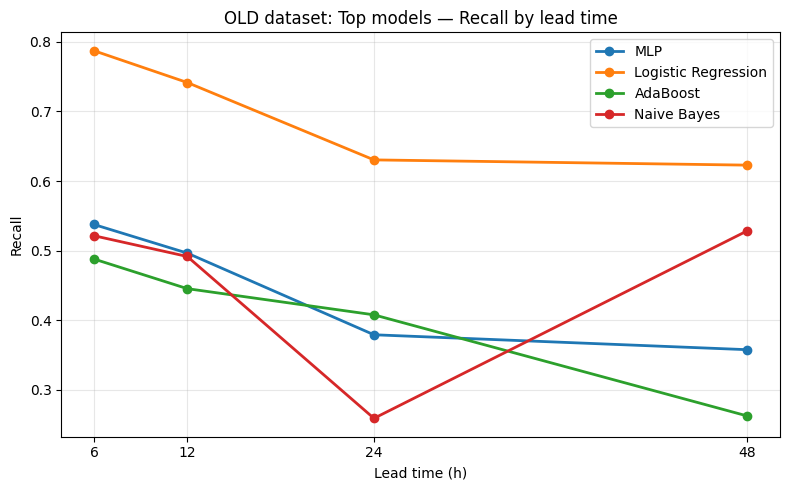

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\top_models_recall_old.png


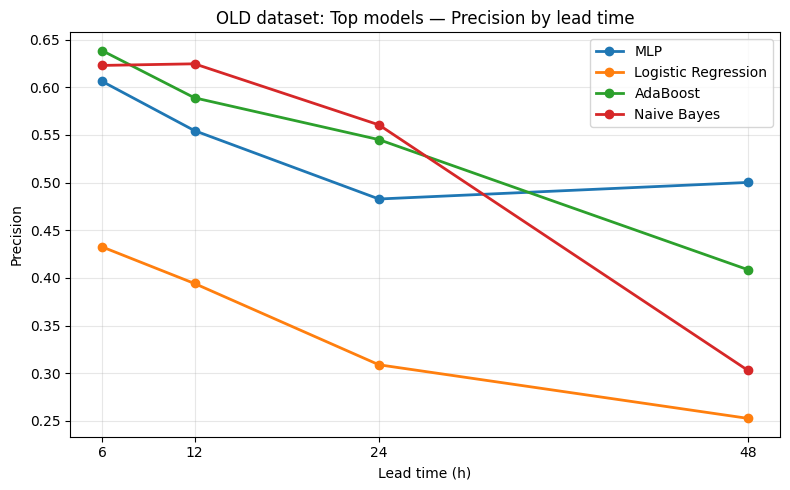

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\top_models_precision_old.png


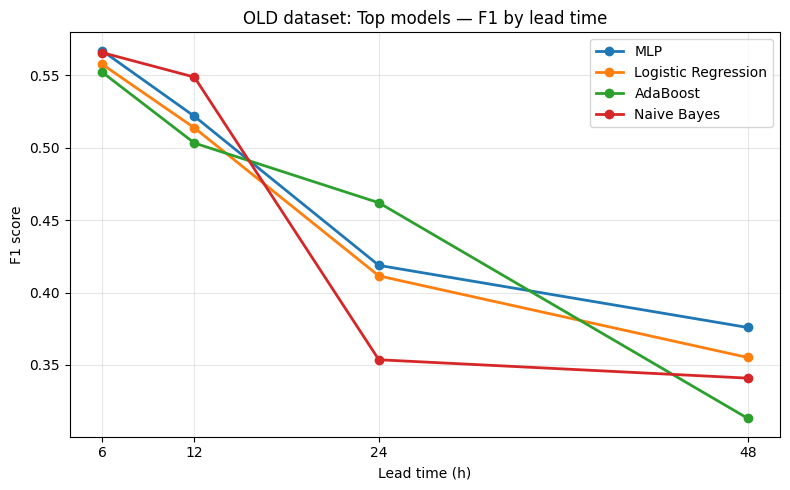

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\top_models_f1_old.png


In [24]:
# ============================================================
# LINE PLOTS — TOP MODELS
# ============================================================

top_models = (
    cv_summary.groupby("model")["f1_mean"]
    .mean()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

print("Top models:", top_models)


def make_line_top(metric_col, ylabel, title, outname):
    fig, ax = plt.subplots(figsize=(8, 5))

    for model in top_models:
        sub = cv_summary[cv_summary["model"] == model].sort_values("lead_h")
        ax.plot(
            sub["lead_h"],
            sub[metric_col],
            marker="o",
            linewidth=2,
            label=model
        )

    ax.set_xticks(LEADS)
    ax.set_xlabel("Lead time (h)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOT_DIR / outname, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", PLOT_DIR / outname)


make_line_top(
    metric_col="recall_mean",
    ylabel="Recall",
    title="OLD dataset: Top models — Recall by lead time",
    outname="top_models_recall_old.png"
)

make_line_top(
    metric_col="precision_mean",
    ylabel="Precision",
    title="OLD dataset: Top models — Precision by lead time",
    outname="top_models_precision_old.png"
)

make_line_top(
    metric_col="f1_mean",
    ylabel="F1 score",
    title="OLD dataset: Top models — F1 by lead time",
    outname="top_models_f1_old.png"
)

In [31]:
# ============================================================
# LOAD OLD ML OUTPUTS
# ============================================================

from pathlib import Path
import pandas as pd

DATASET_NAME = "old"
LABEL_NAME = "box2deg"

OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final"
)

PLOT_DIR = OUT_DIR / "plots"
CM_DIR = OUT_DIR / "confusion_matrices"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

oof_fp = OUT_DIR / "oof_predictions_all_models.csv"
ranked_fp = OUT_DIR / "model_performance_ranked_by_lead_old.csv"

if not oof_fp.exists():
    raise FileNotFoundError(oof_fp)

if not ranked_fp.exists():
    raise FileNotFoundError(ranked_fp)

oof_all = pd.read_csv(oof_fp)
ranked_table = pd.read_csv(ranked_fp)

best_by_lead = (
    ranked_table
    .sort_values(["lead_h", "f1"], ascending=[True, False])
    .groupby("lead_h", as_index=False)
    .first()
)

print("Loaded OLD ML outputs")
print("OUT_DIR:", OUT_DIR)
print("OOF:", oof_fp)
print("Ranked:", ranked_fp)

print("\nOOF rows:", len(oof_all))
print("Models:", sorted(oof_all["model"].unique()))

if "dataset" in oof_all.columns:
    print("Dataset values inside oof_all:", oof_all["dataset"].unique())

print("\nRanked table:")
display(ranked_table)

print("\nBest model by lead:")
display(best_by_lead)

Loaded OLD ML outputs
OUT_DIR: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final
OOF: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\oof_predictions_all_models.csv
Ranked: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\model_performance_ranked_by_lead_old.csv

OOF rows: 39474
Models: ['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']
Dataset values inside oof_all: ['old']

Ranked table:


,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,6,Random Forest,0.709113,0.485514,0.573616,0.913459,0.689244
1,6,MLP,0.606092,0.537561,0.567048,0.862735,0.589701
2,6,Naive Bayes,0.622934,0.521420,0.565751,0.857036,0.558387
3,6,Logistic Regression,0.432452,0.787388,0.557680,0.859078,0.563711
4,6,AdaBoost,0.638368,0.487916,0.552209,0.893033,0.615704
5,6,SVM,0.691958,0.458491,0.549054,0.889125,0.656097
6,6,QDA,0.612363,0.459750,0.523923,0.860817,0.554479
7,6,Decision Tree,0.509109,0.492446,0.498403,0.699643,0.336848
8,6,KNN,0.643812,0.400154,0.489909,0.800199,0.502049
9,12,Naive Bayes,0.624628,0.491539,0.548814,0.843642,0.543773



Best model by lead:


,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,6,Random Forest,0.709113,0.485514,0.573616,0.913459,0.689244
1,12,Naive Bayes,0.624628,0.491539,0.548814,0.843642,0.543773
2,24,AdaBoost,0.545091,0.407664,0.462053,0.845128,0.529333
3,48,MLP,0.500164,0.357551,0.375909,0.778961,0.415243


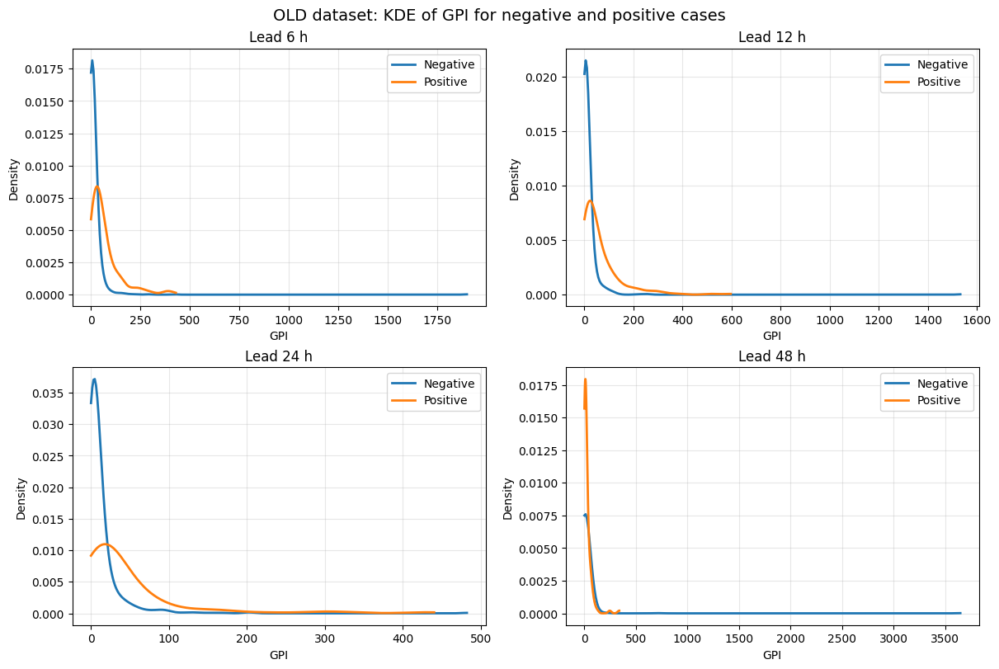

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots\gpi_kde_positive_negative_old.png


In [33]:
# ============================================================
# GPI KDE — OLD
# Positive vs Negative by lead
# ============================================================

GPI_COL = "gpi"

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

for ax, lead in zip(axes, LEADS):
    df = datasets[lead].copy()
    df = df.dropna(subset=[GPI_COL])

    neg = df.loc[df["y"] == 0, GPI_COL].astype(float).values
    pos = df.loc[df["y"] == 1, GPI_COL].astype(float).values

    if len(neg) > 5 and np.nanmax(neg) > np.nanmin(neg):
        xs = np.linspace(np.nanmin(neg), np.nanmax(neg), 300)
        kde = gaussian_kde(neg)
        ax.plot(xs, kde(xs), linewidth=2, label="Negative")

    if len(pos) > 5 and np.nanmax(pos) > np.nanmin(pos):
        xs = np.linspace(np.nanmin(pos), np.nanmax(pos), 300)
        kde = gaussian_kde(pos)
        ax.plot(xs, kde(xs), linewidth=2, label="Positive")

    ax.set_title(f"Lead {lead} h")
    ax.set_xlabel("GPI")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("OLD dataset: KDE of GPI for negative and positive cases", fontsize=14)
plt.savefig(PLOT_DIR / "gpi_kde_positive_negative_old.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", PLOT_DIR / "gpi_kde_positive_negative_old.png")

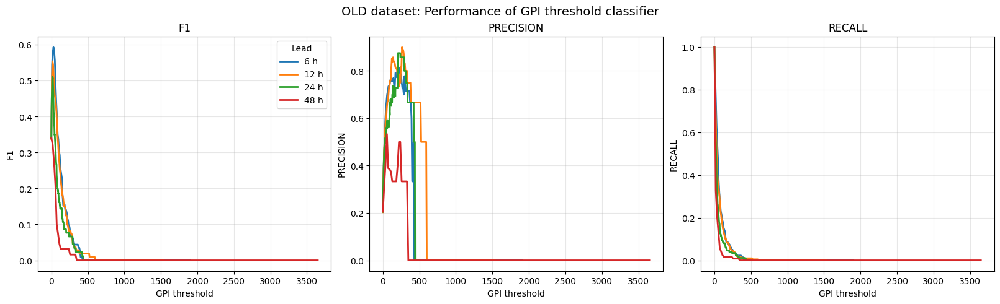


Best GPI threshold by lead:


,lead_h,threshold,f1,precision,recall
0,6,28.674762,0.593220,0.557769,0.633484
1,12,15.407792,0.553903,0.450151,0.719807
2,24,14.533306,0.510539,0.430830,0.626437
3,48,0.000000,0.340782,0.205387,1.000000


In [35]:
# ============================================================
# GPI THRESHOLD CLASSIFIER — OLD
# F1 / Precision / Recall vs GPI threshold
# ============================================================

rows = []

for lead in LEADS:
    df = datasets[lead].copy()
    df = df.dropna(subset=[GPI_COL])

    y_true = df["y"].astype(int).values
    gpi = df[GPI_COL].astype(float).values

    if len(df) == 0:
        continue

    thresholds = np.linspace(np.nanmin(gpi), np.nanmax(gpi), 200)

    for thr in thresholds:
        y_pred = (gpi >= thr).astype(int)

        rows.append({
            "lead_h": lead,
            "threshold": thr,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

gpi_perf = pd.DataFrame(rows)
gpi_perf.to_csv(OUT_DIR / "gpi_threshold_performance_old.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
metric_list = ["f1", "precision", "recall"]

for ax, metric in zip(axes, metric_list):
    for lead in LEADS:
        sub = gpi_perf[gpi_perf["lead_h"] == lead]
        ax.plot(sub["threshold"], sub[metric], linewidth=2, label=f"{lead} h")

    ax.set_title(metric.upper())
    ax.set_xlabel("GPI threshold")
    ax.set_ylabel(metric.upper())
    ax.grid(True, alpha=0.3)

axes[0].legend(title="Lead")
fig.suptitle("OLD dataset: Performance of GPI threshold classifier", fontsize=14)
plt.savefig(PLOT_DIR / "gpi_threshold_classifier_performance_old.png", dpi=220, bbox_inches="tight")
plt.show()

best_gpi = (
    gpi_perf.sort_values(["lead_h", "f1"], ascending=[True, False])
    .groupby("lead_h", as_index=False)
    .first()
)

best_gpi.to_csv(OUT_DIR / "best_gpi_threshold_by_lead_old.csv", index=False)

print("\nBest GPI threshold by lead:")
display(best_gpi[["lead_h", "threshold", "f1", "precision", "recall"]])

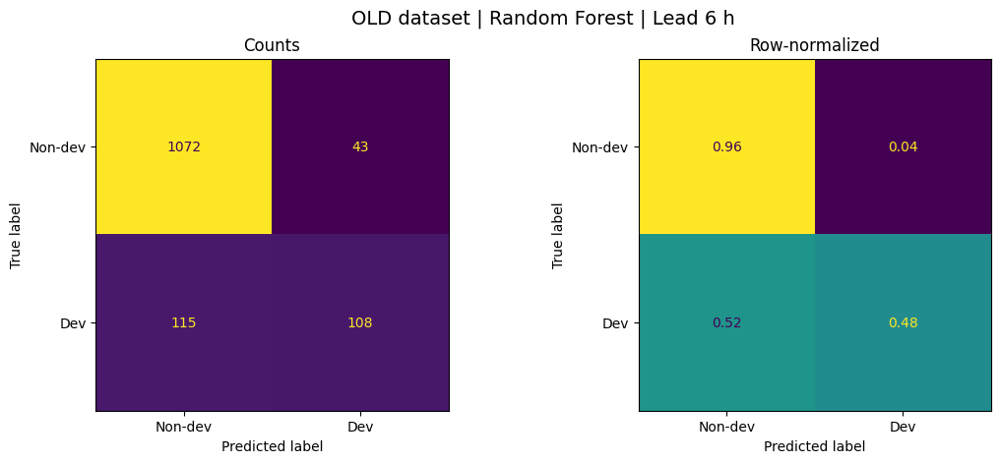

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\confusion_matrix_old_counts_and_normalized_Random_Forest_6h.png


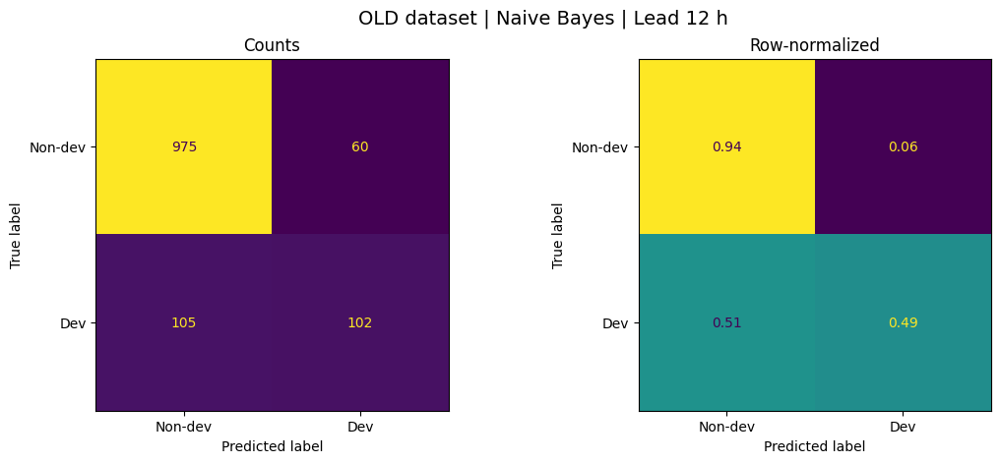

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\confusion_matrix_old_counts_and_normalized_Naive_Bayes_12h.png


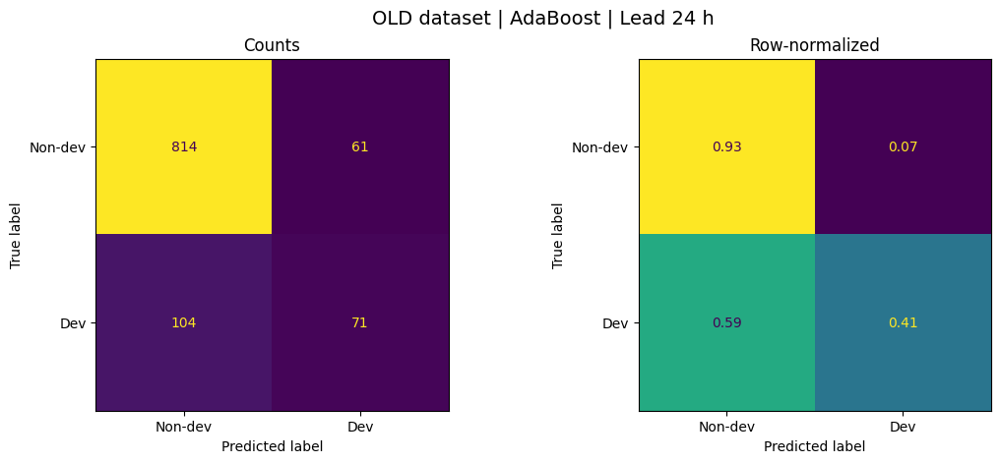

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\confusion_matrix_old_counts_and_normalized_AdaBoost_24h.png


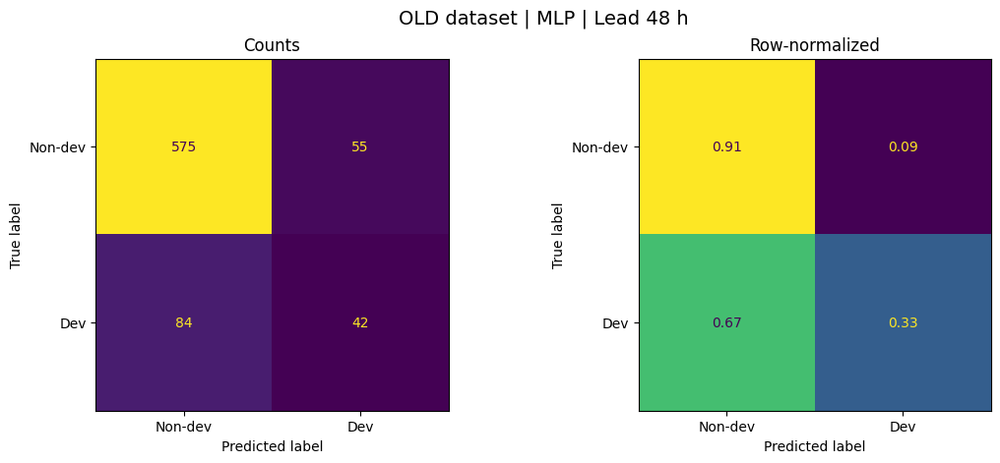

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\confusion_matrix_old_counts_and_normalized_MLP_48h.png


,lead_h,model,tn,fp,fn,tp,total,tn_norm,fp_norm,fn_norm,tp_norm
0,6,Random Forest,1072,43,115,108,1338,0.961435,0.038565,0.515695,0.484305
1,12,Naive Bayes,975,60,105,102,1242,0.942029,0.057971,0.507246,0.492754
2,24,AdaBoost,814,61,104,71,1050,0.930286,0.069714,0.594286,0.405714
3,48,MLP,575,55,84,42,756,0.912698,0.087302,0.666667,0.333333


In [36]:
# ============================================================
# CONFUSION MATRICES — OLD BEST MODEL PER LEAD
# Raw counts and row-normalized matrices are produced together
# Uses OOF predictions from CV
# ============================================================

cm_rows = []

for _, row in best_by_lead.iterrows():
    lead = int(row["lead_h"])
    model_name = row["model"]

    sub = oof_all[
        (oof_all["lead_h"] == lead)
        & (oof_all["model"] == model_name)
    ].copy()

    y_true = sub["y_true"].astype(int).values

    if "y_pred_default" in sub.columns:
        y_pred = sub["y_pred_default"].astype(int).values
    elif "y_pred" in sub.columns:
        y_pred = sub["y_pred"].astype(int).values
    else:
        y_pred = (sub["y_score"].astype(float).values >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize="true")
    tn, fp, fn, tp = cm.ravel()

    cm_rows.append({
        "lead_h": lead,
        "model": model_name,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "total": int(cm.sum()),
        "tn_norm": float(cm_norm[0, 0]),
        "fp_norm": float(cm_norm[0, 1]),
        "fn_norm": float(cm_norm[1, 0]),
        "tp_norm": float(cm_norm[1, 1]),
    })

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-dev", "Dev"]
    ).plot(ax=axes[0], colorbar=False, values_format="d")
    axes[0].set_title("Counts")

    ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=["Non-dev", "Dev"]
    ).plot(ax=axes[1], colorbar=False, values_format=".2f")
    axes[1].set_title("Row-normalized")

    fig.suptitle(f"OLD dataset | {model_name} | Lead {lead} h", fontsize=14)

    safe_model = model_name.replace(" ", "_").replace("/", "_")
    out_png = CM_DIR / f"confusion_matrix_old_counts_and_normalized_{safe_model}_{lead}h.png"
    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)

cm_table = pd.DataFrame(cm_rows)
cm_table.to_csv(CM_DIR / "confusion_matrix_values_best_models_old_counts_and_normalized.csv", index=False)

cm_table

Available models in oof_all:
['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']


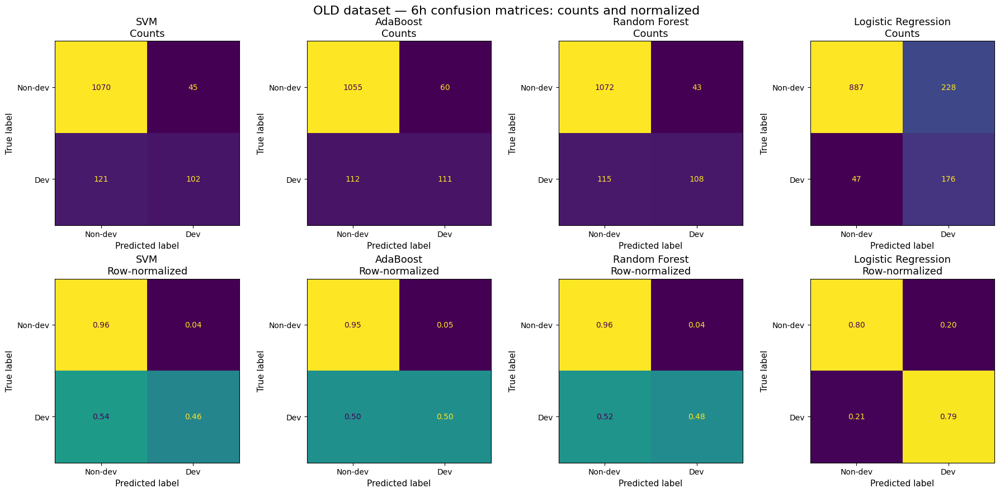

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\combined_figures\old_6h_confusion_matrices_counts_and_normalized_2x4_SVM_AdaBoost_RandomForest_Logistic.png


,dataset,model,lead_h,rows,tn,fp,fn,tp,tn_norm,fp_norm,fn_norm,tp_norm
0,old,SVM,6,1338,1070,45,121,102,0.959641,0.040359,0.542601,0.457399
1,old,AdaBoost,6,1338,1055,60,112,111,0.946188,0.053812,0.502242,0.497758
2,old,Random Forest,6,1338,1072,43,115,108,0.961435,0.038565,0.515695,0.484305
3,old,Logistic Regression,6,1338,887,228,47,176,0.795516,0.204484,0.210762,0.789238


In [37]:
# ============================================================
# OLD — 6H CONFUSION MATRICES IN ONE FIGURE
# Counts and row-normalized matrices are produced together
# SVM, AdaBoost, Random Forest, Logistic Regression
# Uses OOF predictions from 5-fold CV
# ============================================================

LEAD = 6

MODELS_6H = [
    "SVM",
    "AdaBoost",
    "Random Forest",
    "Logistic Regression",
]

OUT_ONEFIG_DIR = CM_DIR / "combined_figures"
OUT_ONEFIG_DIR.mkdir(parents=True, exist_ok=True)

print("Available models in oof_all:")
print(sorted(oof_all["model"].unique()))

missing_models = [m for m in MODELS_6H if m not in oof_all["model"].unique()]
if missing_models:
    raise ValueError(
        f"Missing models in oof_all: {missing_models}\n"
        f"Available models: {sorted(oof_all['model'].unique())}"
    )

fig, axes = plt.subplots(2, 4, figsize=(18, 8.5), constrained_layout=True)

cm_rows_6h = []

for col, model_name in enumerate(MODELS_6H):
    sub = oof_all[
        (oof_all["lead_h"] == LEAD)
        & (oof_all["model"] == model_name)
    ].copy()

    y_true = sub["y_true"].astype(int).values

    if "y_pred_default" in sub.columns:
        y_pred = sub["y_pred_default"].astype(int).values
    elif "y_pred" in sub.columns:
        y_pred = sub["y_pred"].astype(int).values
    else:
        y_pred = (sub["y_score"].astype(float).values >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize="true")
    tn, fp, fn, tp = cm.ravel()

    cm_rows_6h.append({
        "dataset": "old",
        "model": model_name,
        "lead_h": LEAD,
        "rows": len(sub),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "tn_norm": float(cm_norm[0, 0]),
        "fp_norm": float(cm_norm[0, 1]),
        "fn_norm": float(cm_norm[1, 0]),
        "tp_norm": float(cm_norm[1, 1]),
    })

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-dev", "Dev"]
    ).plot(ax=axes[0, col], colorbar=False, values_format="d")
    axes[0, col].set_title(f"{model_name}\nCounts", fontsize=13)
    axes[0, col].set_xlabel("Predicted label", fontsize=11)
    axes[0, col].set_ylabel("True label", fontsize=11)

    ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=["Non-dev", "Dev"]
    ).plot(ax=axes[1, col], colorbar=False, values_format=".2f")
    axes[1, col].set_title(f"{model_name}\nRow-normalized", fontsize=13)
    axes[1, col].set_xlabel("Predicted label", fontsize=11)
    axes[1, col].set_ylabel("True label", fontsize=11)

fig.suptitle("OLD dataset — 6h confusion matrices: counts and normalized", fontsize=16, y=1.02)

out_png = OUT_ONEFIG_DIR / "old_6h_confusion_matrices_counts_and_normalized_2x4_SVM_AdaBoost_RandomForest_Logistic.png"
plt.savefig(out_png, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_png)

cm_summary_old_6h = pd.DataFrame(cm_rows_6h)
cm_summary_old_6h.to_csv(
    OUT_ONEFIG_DIR / "old_6h_confusion_matrix_values_counts_and_normalized.csv",
    index=False
)

cm_summary_old_6h

TUNED THRESHOLD

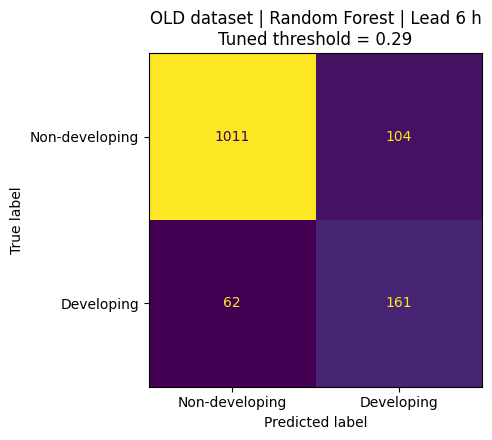

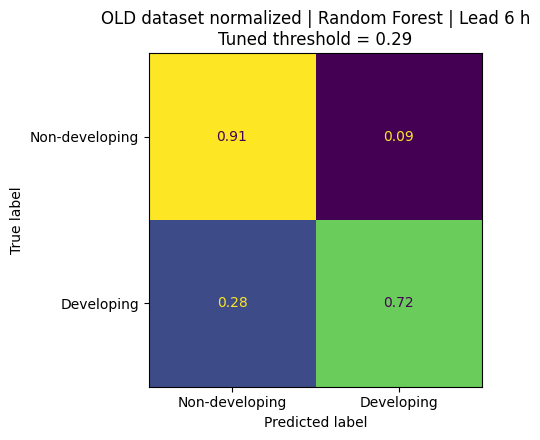

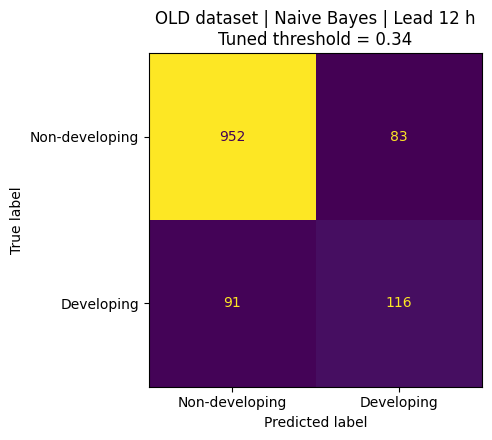

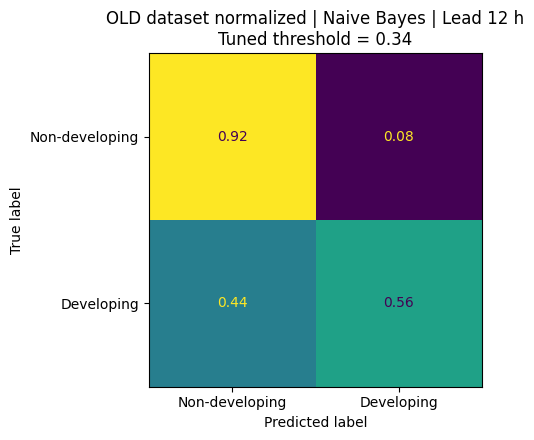

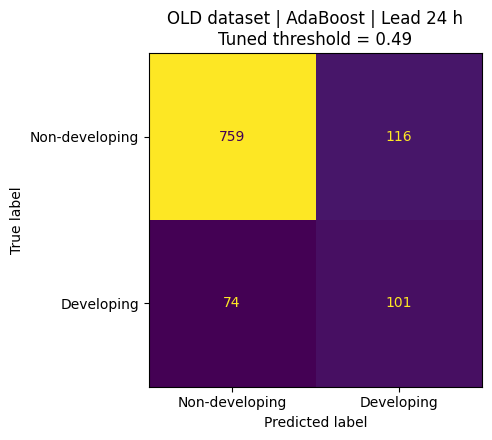

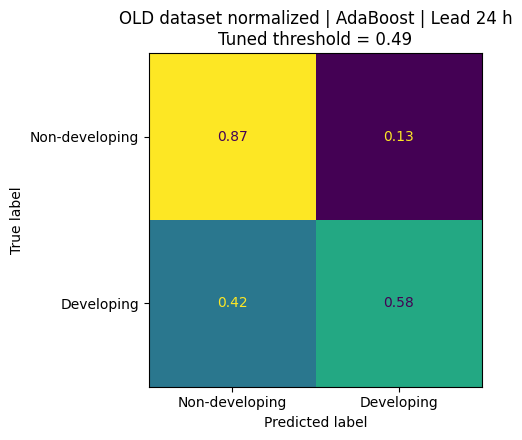

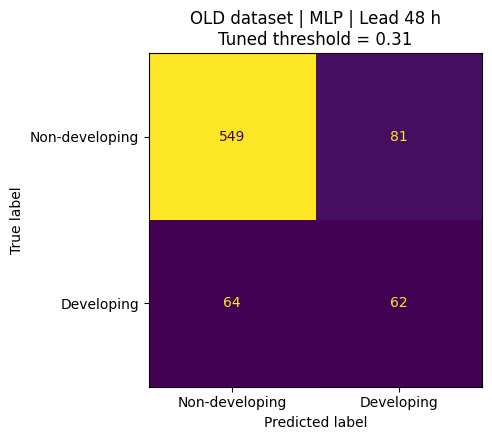

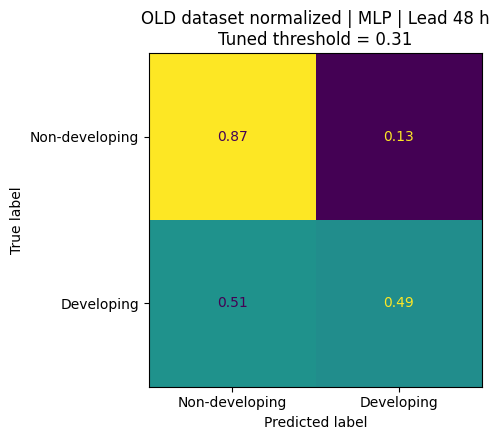

,lead_h,model,best_threshold,tn,fp,fn,tp,total
0,6,Random Forest,0.29,1011,104,62,161,1338
1,12,Naive Bayes,0.34,952,83,91,116,1242
2,24,AdaBoost,0.49,759,116,74,101,1050
3,48,MLP,0.31,549,81,64,62,756


Available models in oof_all:
['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']


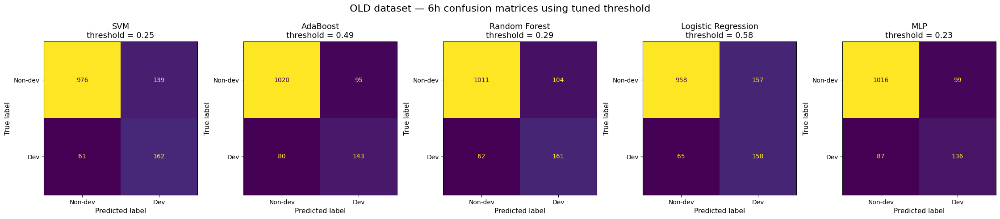

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED\confusion_matrices\combined_figures\old_6h_confusion_matrices_1x5_tuned_SVM_AdaBoost_RandomForest_Logistic_MLP.png


,dataset,model,lead_h,best_threshold,rows,tn,fp,fn,tp
0,old,SVM,6,0.25,1338,976,139,61,162
1,old,AdaBoost,6,0.49,1338,1020,95,80,143
2,old,Random Forest,6,0.29,1338,1011,104,62,161
3,old,Logistic Regression,6,0.58,1338,958,157,65,158
4,old,MLP,6,0.23,1338,1016,99,87,136


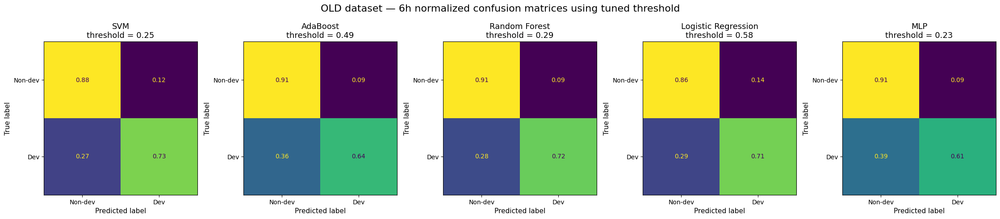

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED\confusion_matrices\combined_figures\old_6h_confusion_matrices_1x5_normalized_tuned_SVM_AdaBoost_RandomForest_Logistic_MLP.png


,dataset,model,lead_h,best_threshold,rows,tn,fp,fn,tp,true_nondev_correct_rate,false_alarm_rate,miss_rate,true_dev_detection_rate
0,old,SVM,6,0.25,1338,976,139,61,162,0.875336,0.124664,0.273543,0.726457
1,old,AdaBoost,6,0.49,1338,1020,95,80,143,0.914798,0.085202,0.358744,0.641256
2,old,Random Forest,6,0.29,1338,1011,104,62,161,0.906726,0.093274,0.278027,0.721973
3,old,Logistic Regression,6,0.58,1338,958,157,65,158,0.859193,0.140807,0.291480,0.708520
4,old,MLP,6,0.23,1338,1016,99,87,136,0.911211,0.088789,0.390135,0.609865


In [40]:
# ============================================================
# CELL 8 — CONFUSION MATRICES WITH TUNED THRESHOLD
# 1. Best model per lead
# 2. 6h 1x5 raw and normalized: SVM, AdaBoost, RF, Logistic, MLP
#
# Uses tuned threshold selected from OOF y_score by max F1
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

# ------------------------------------------------------------
# Dataset naming
# ------------------------------------------------------------

DATASET_DISPLAY = "OLD"     # change to "OLD" if running old dataset
DATASET_SLUG = "old"        # change to "old" if running old dataset

# ------------------------------------------------------------
# Helper: find best threshold by F1
# ------------------------------------------------------------

def get_best_threshold_from_oof(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    thresholds = np.round(np.arange(0.05, 0.951, 0.01), 2)

    rows = []

    for thr in thresholds:
        y_pred = (y_score >= thr).astype(int)

        rows.append({
            "threshold": thr,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

    scan = pd.DataFrame(rows)

    scan = (
        scan
        .sort_values(["f1", "recall", "precision"], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    best_threshold = float(scan.loc[0, "threshold"])

    return best_threshold, scan


def get_tuned_prediction(sub):
    if "y_score" not in sub.columns:
        raise ValueError(
            "Cannot use threshold tuning because y_score column is missing."
        )

    y_true = sub["y_true"].astype(int).values
    y_score = sub["y_score"].astype(float).values

    best_threshold, scan = get_best_threshold_from_oof(y_true, y_score)

    y_pred = (y_score >= best_threshold).astype(int)

    return y_pred, best_threshold, scan


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

OUT_ONEFIG_DIR = CM_DIR / "combined_figures"
OUT_ONEFIG_DIR.mkdir(parents=True, exist_ok=True)

THR_DIR = CM_DIR / "threshold_scans"
THR_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. BEST MODEL PER LEAD — TUNED THRESHOLD
# ============================================================

cm_rows = []

for _, row in best_by_lead.iterrows():
    lead = int(row["lead_h"])
    model_name = row["model"]

    sub = oof_all[
        (oof_all["lead_h"] == lead)
        & (oof_all["model"] == model_name)
    ].copy()

    y_true = sub["y_true"].astype(int).values
    y_pred, best_threshold, scan = get_tuned_prediction(sub)

    safe_model = model_name.replace(" ", "_").replace("/", "_")

    scan_out = THR_DIR / f"threshold_scan_{DATASET_SLUG}_{safe_model}_{lead}h.csv"
    scan.to_csv(scan_out, index=False)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cm_rows.append({
        "lead_h": lead,
        "model": model_name,
        "best_threshold": best_threshold,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "total": int(cm.sum()),
    })

    # ------------------------------
    # Raw count confusion matrix
    # ------------------------------
    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Non-developing", "Developing"],
    ).plot(ax=ax, colorbar=False, values_format="d")

    ax.set_title(
        f"{DATASET_DISPLAY} dataset | {model_name} | Lead {lead} h\n"
        f"Tuned threshold = {best_threshold:.2f}"
    )

    plt.tight_layout()

    out_png = CM_DIR / f"confusion_matrix_{DATASET_SLUG}_tuned_{safe_model}_{lead}h.png"
    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

    # ------------------------------
    # Normalized confusion matrix
    # ------------------------------
    cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize="true")

    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    ConfusionMatrixDisplay(
        cm_norm,
        display_labels=["Non-developing", "Developing"],
    ).plot(ax=ax, colorbar=False, values_format=".2f")

    ax.set_title(
        f"{DATASET_DISPLAY} dataset normalized | {model_name} | Lead {lead} h\n"
        f"Tuned threshold = {best_threshold:.2f}"
    )

    plt.tight_layout()

    out_png_norm = CM_DIR / f"confusion_matrix_{DATASET_SLUG}_tuned_normalized_{safe_model}_{lead}h.png"
    plt.savefig(out_png_norm, dpi=220, bbox_inches="tight")
    plt.show()

cm_table = pd.DataFrame(cm_rows)

cm_table.to_csv(
    CM_DIR / f"confusion_matrix_values_best_models_{DATASET_SLUG}_tuned.csv",
    index=False
)

display(cm_table)


# ============================================================
# 2. 6H 1x5 RAW + NORMALIZED — TUNED THRESHOLD
# ============================================================

LEAD = 6

MODELS_6H = [
    "SVM",
    "AdaBoost",
    "Random Forest",
    "Logistic Regression",
    "MLP",
    "Naive Bayes",
]

print("Available models in oof_all:")
print(sorted(oof_all["model"].unique()))

missing_models = [m for m in MODELS_6H if m not in oof_all["model"].unique()]

if missing_models:
    raise ValueError(
        f"Missing models in oof_all: {missing_models}\n"
        f"Available models: {sorted(oof_all['model'].unique())}"
    )

# ------------------------------------------------------------
# Raw count 1x5
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 5, figsize=(22.5, 4.5))
axes = axes.flatten()

cm_rows_6h = []

for ax, model_name in zip(axes, MODELS_6H):
    sub = oof_all[
        (oof_all["lead_h"] == LEAD)
        & (oof_all["model"] == model_name)
    ].copy()

    y_true = sub["y_true"].astype(int).values
    y_pred, best_threshold, scan = get_tuned_prediction(sub)

    safe_model = model_name.replace(" ", "_").replace("/", "_")

    scan_out = THR_DIR / f"threshold_scan_{DATASET_SLUG}_{safe_model}_{LEAD}h.csv"
    scan.to_csv(scan_out, index=False)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cm_rows_6h.append({
        "dataset": DATASET_SLUG,
        "model": model_name,
        "lead_h": LEAD,
        "best_threshold": best_threshold,
        "rows": len(sub),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    })

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-dev", "Dev"],
    ).plot(
        ax=ax,
        colorbar=False,
        values_format="d",
    )

    ax.set_title(
        f"{model_name}\nthreshold = {best_threshold:.2f}",
        fontsize=13
    )
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)

fig.suptitle(
    f"{DATASET_DISPLAY} dataset — 6h confusion matrices using tuned threshold",
    fontsize=16,
    y=1.03
)

plt.tight_layout()

out_png = OUT_ONEFIG_DIR / f"{DATASET_SLUG}_6h_confusion_matrices_1x5_tuned_SVM_AdaBoost_RandomForest_Logistic_MLP.png"
plt.savefig(out_png, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_png)

cm_summary_6h = pd.DataFrame(cm_rows_6h)

cm_summary_6h.to_csv(
    OUT_ONEFIG_DIR / f"{DATASET_SLUG}_6h_confusion_matrix_values_1x5_tuned.csv",
    index=False,
)

display(cm_summary_6h)


# ------------------------------------------------------------
# Normalized 1x5
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 5, figsize=(22.5, 4.5))
axes = axes.flatten()

cm_rows_6h_norm = []

for ax, model_name in zip(axes, MODELS_6H):
    sub = oof_all[
        (oof_all["lead_h"] == LEAD)
        & (oof_all["model"] == model_name)
    ].copy()

    y_true = sub["y_true"].astype(int).values
    y_pred, best_threshold, scan = get_tuned_prediction(sub)

    cm_count = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize="true")

    tn, fp, fn, tp = cm_count.ravel()

    cm_rows_6h_norm.append({
        "dataset": DATASET_SLUG,
        "model": model_name,
        "lead_h": LEAD,
        "best_threshold": best_threshold,
        "rows": len(sub),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "true_nondev_correct_rate": cm_norm[0, 0],
        "false_alarm_rate": cm_norm[0, 1],
        "miss_rate": cm_norm[1, 0],
        "true_dev_detection_rate": cm_norm[1, 1],
    })

    ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=["Non-dev", "Dev"],
    ).plot(
        ax=ax,
        colorbar=False,
        values_format=".2f",
    )

    ax.set_title(
        f"{model_name}\nthreshold = {best_threshold:.2f}",
        fontsize=13
    )
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)

fig.suptitle(
    f"{DATASET_DISPLAY} dataset — 6h normalized confusion matrices using tuned threshold",
    fontsize=16,
    y=1.03
)

plt.tight_layout()

out_png_norm = OUT_ONEFIG_DIR / f"{DATASET_SLUG}_6h_confusion_matrices_1x5_normalized_tuned_SVM_AdaBoost_RandomForest_Logistic_MLP.png"
plt.savefig(out_png_norm, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_png_norm)

cm_summary_6h_norm = pd.DataFrame(cm_rows_6h_norm)

cm_summary_6h_norm.to_csv(
    OUT_ONEFIG_DIR / f"{DATASET_SLUG}_6h_confusion_matrix_values_1x5_normalized_tuned.csv",
    index=False,
)

display(cm_summary_6h_norm)

NAIVEBAYES (NO SVM AND MLP)

checking: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\oof_predictions_all_models.csv | exists: True

Loaded OLD OOF predictions:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\oof_predictions_all_models.csv
Rows: 39474
Models: ['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']
Dataset values inside oof_all: ['old']

Models used:
['AdaBoost', 'Random Forest', 'Logistic Regression', 'Naive Bayes', 'MLP']


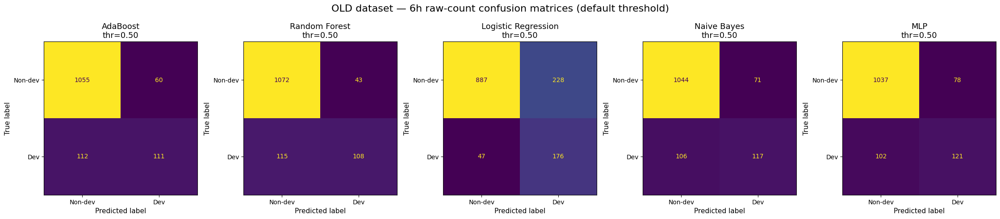

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\combined_figures\old_6h_confusion_matrices_1x5_raw_default_AdaBoost_RF_Logistic_NaiveBayes_MLP.png
Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\combined_figures\old_6h_confusion_matrix_values_1x5_raw_default_AdaBoost_RF_Logistic_NaiveBayes_MLP.csv


,dataset,mode,normalized,model,lead_h,threshold,rows,tn,fp,fn,tp
0,old,default,False,AdaBoost,6,0.5,1338,1055,60,112,111
1,old,default,False,Random Forest,6,0.5,1338,1072,43,115,108
2,old,default,False,Logistic Regression,6,0.5,1338,887,228,47,176
3,old,default,False,Naive Bayes,6,0.5,1338,1044,71,106,117
4,old,default,False,MLP,6,0.5,1338,1037,78,102,121


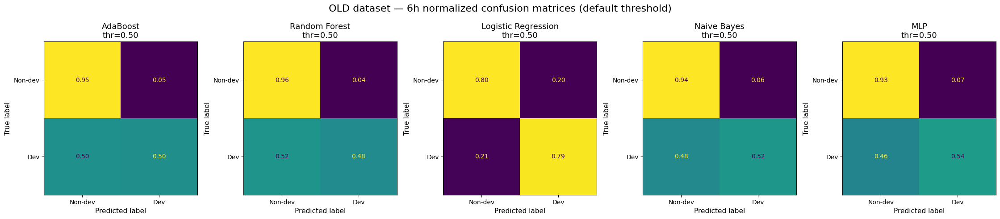

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\combined_figures\old_6h_confusion_matrices_1x5_normalized_default_AdaBoost_RF_Logistic_NaiveBayes_MLP.png
Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\combined_figures\old_6h_confusion_matrix_values_1x5_normalized_default_AdaBoost_RF_Logistic_NaiveBayes_MLP.csv


,dataset,mode,normalized,model,lead_h,threshold,rows,tn,fp,fn,tp,true_nondev_correct_rate,false_alarm_rate,miss_rate,true_dev_detection_rate
0,old,default,True,AdaBoost,6,0.5,1338,1055,60,112,111,0.946188,0.053812,0.502242,0.497758
1,old,default,True,Random Forest,6,0.5,1338,1072,43,115,108,0.961435,0.038565,0.515695,0.484305
2,old,default,True,Logistic Regression,6,0.5,1338,887,228,47,176,0.795516,0.204484,0.210762,0.789238
3,old,default,True,Naive Bayes,6,0.5,1338,1044,71,106,117,0.936323,0.063677,0.475336,0.524664
4,old,default,True,MLP,6,0.5,1338,1037,78,102,121,0.930045,0.069955,0.457399,0.542601


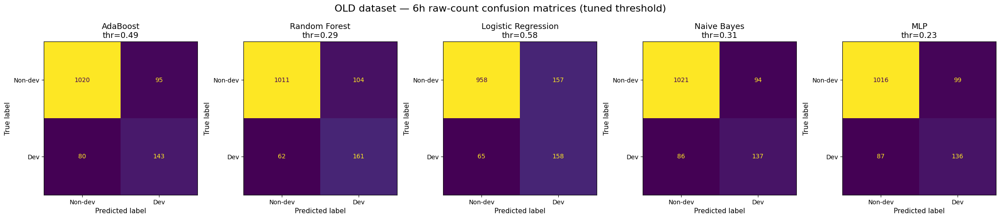

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\combined_figures\old_6h_confusion_matrices_1x5_raw_tuned_AdaBoost_RF_Logistic_NaiveBayes_MLP.png
Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\combined_figures\old_6h_confusion_matrix_values_1x5_raw_tuned_AdaBoost_RF_Logistic_NaiveBayes_MLP.csv


,dataset,mode,normalized,model,lead_h,threshold,rows,tn,fp,fn,tp
0,old,tuned,False,AdaBoost,6,0.49,1338,1020,95,80,143
1,old,tuned,False,Random Forest,6,0.29,1338,1011,104,62,161
2,old,tuned,False,Logistic Regression,6,0.58,1338,958,157,65,158
3,old,tuned,False,Naive Bayes,6,0.31,1338,1021,94,86,137
4,old,tuned,False,MLP,6,0.23,1338,1016,99,87,136


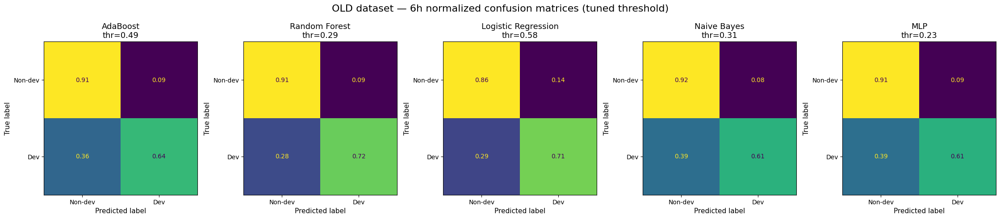

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\combined_figures\old_6h_confusion_matrices_1x5_normalized_tuned_AdaBoost_RF_Logistic_NaiveBayes_MLP.png
Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\confusion_matrices\combined_figures\old_6h_confusion_matrix_values_1x5_normalized_tuned_AdaBoost_RF_Logistic_NaiveBayes_MLP.csv


,dataset,mode,normalized,model,lead_h,threshold,rows,tn,fp,fn,tp,true_nondev_correct_rate,false_alarm_rate,miss_rate,true_dev_detection_rate
0,old,tuned,True,AdaBoost,6,0.49,1338,1020,95,80,143,0.914798,0.085202,0.358744,0.641256
1,old,tuned,True,Random Forest,6,0.29,1338,1011,104,62,161,0.906726,0.093274,0.278027,0.721973
2,old,tuned,True,Logistic Regression,6,0.58,1338,958,157,65,158,0.859193,0.140807,0.291480,0.708520
3,old,tuned,True,Naive Bayes,6,0.31,1338,1021,94,86,137,0.915695,0.084305,0.385650,0.614350
4,old,tuned,True,MLP,6,0.23,1338,1016,99,87,136,0.911211,0.088789,0.390135,0.609865


In [45]:
# ============================================================
# OLD — 6H CONFUSION MATRICES, 5 MODELS
# Models: AdaBoost, Random Forest, Logistic Regression, Naive Bayes, MLP
#
# Produces separate figures:
#   1. Default threshold raw-count confusion matrices
#   2. Default threshold normalized confusion matrices
#   3. Tuned threshold raw-count confusion matrices
#   4. Tuned threshold normalized confusion matrices
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

# ============================================================
# OLD PATHS
# ============================================================

DATASET_DISPLAY = "OLD"
DATASET_SLUG = "old"
LEAD = 6

OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final"
)

CM_DIR = OUT_DIR / "confusion_matrices"
CM_DIR.mkdir(parents=True, exist_ok=True)

OUT_ONEFIG_DIR = CM_DIR / "combined_figures"
OUT_ONEFIG_DIR.mkdir(parents=True, exist_ok=True)

THR_DIR = CM_DIR / "threshold_scans"
THR_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD OLD OOF PREDICTIONS
# ============================================================

oof_candidates = [
    OUT_DIR / "oof_predictions_all_models.csv",
    OUT_DIR / "oof_predictions_allmodels_old.csv",
    OUT_DIR / "oof_predictions_allmodels.csv",
]

oof_fp = None

for fp in oof_candidates:
    print("checking:", fp, "| exists:", fp.exists())
    if fp.exists():
        oof_fp = fp
        break

if oof_fp is None:
    raise FileNotFoundError(
        "No OLD OOF prediction file found. Checked:\n"
        + "\n".join(str(fp) for fp in oof_candidates)
    )

oof_all = pd.read_csv(oof_fp)

print("\nLoaded OLD OOF predictions:")
print(oof_fp)
print("Rows:", len(oof_all))
print("Models:", sorted(oof_all["model"].dropna().unique()))

if "dataset" in oof_all.columns:
    print("Dataset values inside oof_all:", oof_all["dataset"].unique())

# ============================================================
# MODEL SELECTION
# ============================================================

MODEL_CANDIDATES = {
    "AdaBoost": ["AdaBoost"],
    "Random Forest": ["Random Forest", "RandomForest"],
    "Logistic Regression": ["Logistic Regression", "Logistic"],
    "Naive Bayes": ["Naive Bayes", "NaiveBayes", "GaussianNB", "NB"],
    "MLP": ["MLP"],
}

available_models = sorted(oof_all["model"].dropna().unique())

MODELS_6H = []

for display_name, candidates in MODEL_CANDIDATES.items():
    found_model = None

    for c in candidates:
        if c in available_models:
            found_model = c
            break

    if found_model is None:
        raise ValueError(
            f"Could not find model for {display_name}.\n"
            f"Tried: {candidates}\n"
            f"Available models: {available_models}"
        )

    MODELS_6H.append(found_model)

print("\nModels used:")
print(MODELS_6H)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_default_prediction(sub):
    """
    Default threshold prediction.
    Uses y_pred_default if available; otherwise uses y_score >= 0.5.
    """
    if "y_pred_default" in sub.columns:
        return sub["y_pred_default"].astype(int).values

    if "y_pred" in sub.columns:
        return sub["y_pred"].astype(int).values

    if "y_score" in sub.columns:
        return (sub["y_score"].astype(float).values >= 0.5).astype(int)

    raise ValueError("No prediction column found. Need y_pred_default, y_pred, or y_score.")


def get_best_threshold_from_oof(y_true, y_score):
    """
    Select threshold that maximizes F1 using OOF scores.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    thresholds = np.round(np.arange(0.05, 0.951, 0.01), 2)

    rows = []

    for thr in thresholds:
        y_pred = (y_score >= thr).astype(int)

        rows.append({
            "threshold": thr,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

    scan = pd.DataFrame(rows)

    scan = (
        scan
        .sort_values(["f1", "recall", "precision"], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    best_threshold = float(scan.loc[0, "threshold"])

    return best_threshold, scan


def get_tuned_prediction(sub):
    """
    Tuned threshold prediction based on max-F1 threshold from y_score.
    """
    if "y_score" not in sub.columns:
        raise ValueError("Cannot tune threshold because y_score column is missing.")

    y_true = sub["y_true"].astype(int).values
    y_score = sub["y_score"].astype(float).values

    best_threshold, scan = get_best_threshold_from_oof(y_true, y_score)
    y_pred = (y_score >= best_threshold).astype(int)

    return y_pred, best_threshold, scan


def make_confusion_figure(
    oof_all,
    models,
    lead,
    dataset_display,
    dataset_slug,
    mode="default",
    normalized=False,
):
    """
    mode:
      default = default threshold 0.5 / y_pred_default
      tuned   = F1-optimized threshold from y_score

    normalized:
      False = raw count confusion matrix
      True  = row-normalized confusion matrix
    """

    fig, axes = plt.subplots(1, 5, figsize=(22.5, 4.5))
    axes = axes.flatten()

    rows = []

    for ax, model_name in zip(axes, models):
        sub = oof_all[
            (oof_all["lead_h"] == lead)
            & (oof_all["model"] == model_name)
        ].copy()

        if len(sub) == 0:
            ax.set_axis_off()
            ax.set_title(f"{model_name}\nNo data")
            continue

        y_true = sub["y_true"].astype(int).values

        if mode == "default":
            y_pred = get_default_prediction(sub)
            threshold_used = 0.5

        elif mode == "tuned":
            y_pred, threshold_used, scan = get_tuned_prediction(sub)

            safe_model = model_name.replace(" ", "_").replace("/", "_")
            scan_out = THR_DIR / f"threshold_scan_{dataset_slug}_{safe_model}_{lead}h.csv"
            scan.to_csv(scan_out, index=False)

        else:
            raise ValueError("mode must be 'default' or 'tuned'")

        cm_count = confusion_matrix(y_true, y_pred, labels=[0, 1])

        if normalized:
            cm_plot = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize="true")
            values_format = ".2f"
        else:
            cm_plot = cm_count
            values_format = "d"

        tn, fp, fn, tp = cm_count.ravel()

        row = {
            "dataset": dataset_slug,
            "mode": mode,
            "normalized": normalized,
            "model": model_name,
            "lead_h": lead,
            "threshold": threshold_used,
            "rows": len(sub),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }

        if normalized:
            cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize="true")
            row.update({
                "true_nondev_correct_rate": float(cm_norm[0, 0]),
                "false_alarm_rate": float(cm_norm[0, 1]),
                "miss_rate": float(cm_norm[1, 0]),
                "true_dev_detection_rate": float(cm_norm[1, 1]),
            })

        rows.append(row)

        ConfusionMatrixDisplay(
            confusion_matrix=cm_plot,
            display_labels=["Non-dev", "Dev"],
        ).plot(
            ax=ax,
            colorbar=False,
            values_format=values_format,
        )

        if mode == "tuned":
            ax.set_title(f"{model_name}\nthr={threshold_used:.2f}", fontsize=13)
        else:
            ax.set_title(f"{model_name}\nthr=0.50", fontsize=13)

        ax.set_xlabel("Predicted label", fontsize=11)
        ax.set_ylabel("True label", fontsize=11)

    mode_title = "default threshold" if mode == "default" else "tuned threshold"
    norm_title = "normalized" if normalized else "raw-count"

    fig.suptitle(
        f"{dataset_display} dataset — 6h {norm_title} confusion matrices ({mode_title})",
        fontsize=16,
        y=1.03,
    )

    plt.tight_layout()

    suffix_norm = "normalized" if normalized else "raw"

    out_png = (
        OUT_ONEFIG_DIR
        / f"{dataset_slug}_6h_confusion_matrices_1x5_{suffix_norm}_{mode}_AdaBoost_RF_Logistic_NaiveBayes_MLP.png"
    )

    plt.savefig(out_png, dpi=250, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)

    table = pd.DataFrame(rows)

    out_csv = (
        OUT_ONEFIG_DIR
        / f"{dataset_slug}_6h_confusion_matrix_values_1x5_{suffix_norm}_{mode}_AdaBoost_RF_Logistic_NaiveBayes_MLP.csv"
    )

    table.to_csv(out_csv, index=False)

    print("Saved:", out_csv)

    return table

# ============================================================
# PRODUCE 4 FIGURES
# ============================================================

cm_default_raw = make_confusion_figure(
    oof_all=oof_all,
    models=MODELS_6H,
    lead=LEAD,
    dataset_display=DATASET_DISPLAY,
    dataset_slug=DATASET_SLUG,
    mode="default",
    normalized=False,
)

display(cm_default_raw)

cm_default_norm = make_confusion_figure(
    oof_all=oof_all,
    models=MODELS_6H,
    lead=LEAD,
    dataset_display=DATASET_DISPLAY,
    dataset_slug=DATASET_SLUG,
    mode="default",
    normalized=True,
)

display(cm_default_norm)

cm_tuned_raw = make_confusion_figure(
    oof_all=oof_all,
    models=MODELS_6H,
    lead=LEAD,
    dataset_display=DATASET_DISPLAY,
    dataset_slug=DATASET_SLUG,
    mode="tuned",
    normalized=False,
)

display(cm_tuned_raw)

cm_tuned_norm = make_confusion_figure(
    oof_all=oof_all,
    models=MODELS_6H,
    lead=LEAD,
    dataset_display=DATASET_DISPLAY,
    dataset_slug=DATASET_SLUG,
    mode="tuned",
    normalized=True,
)

display(cm_tuned_norm)

Feature importance: Random Forest, lead 6h


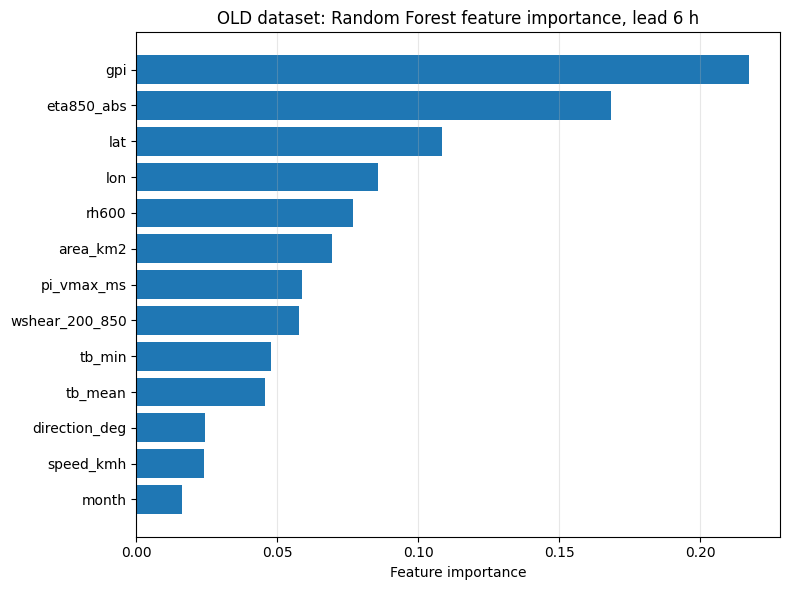

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Random_Forest_6h.png
Feature importance: AdaBoost, lead 6h


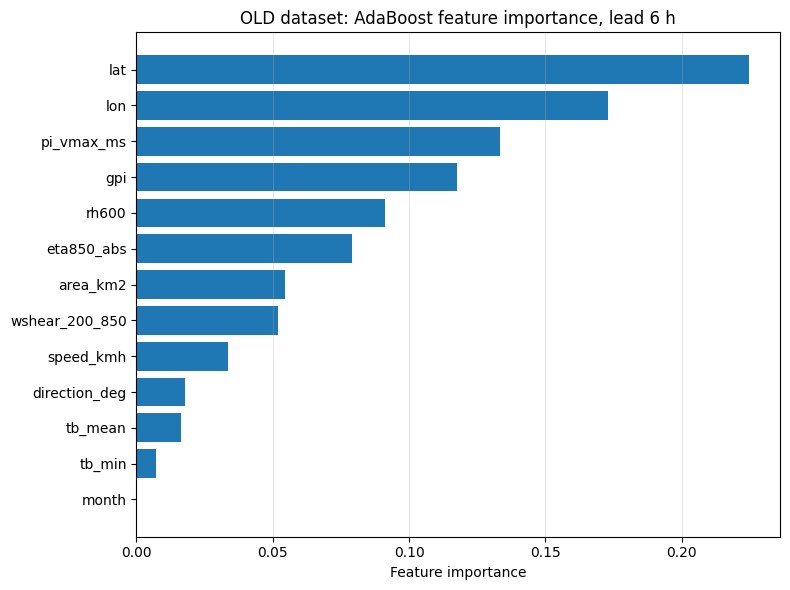

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_AdaBoost_6h.png
Feature importance: Decision Tree, lead 6h


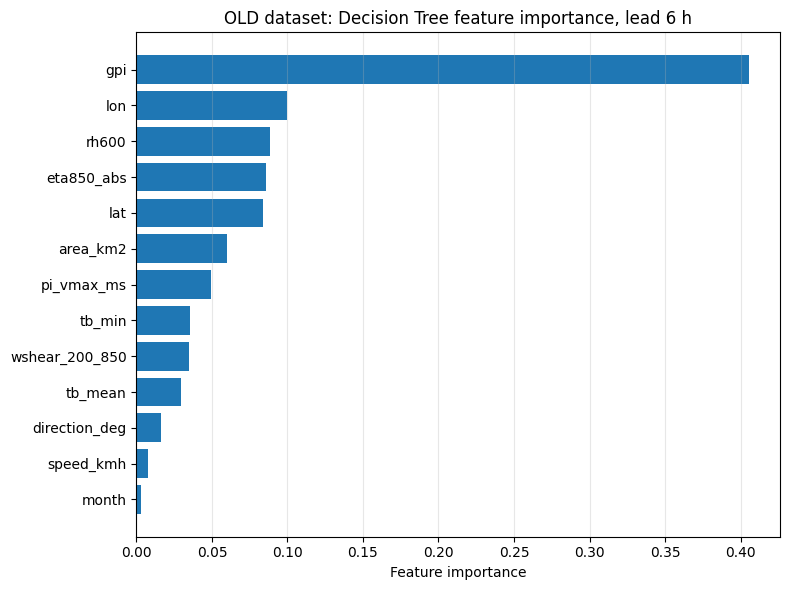

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Decision_Tree_6h.png
Feature importance: Random Forest, lead 12h


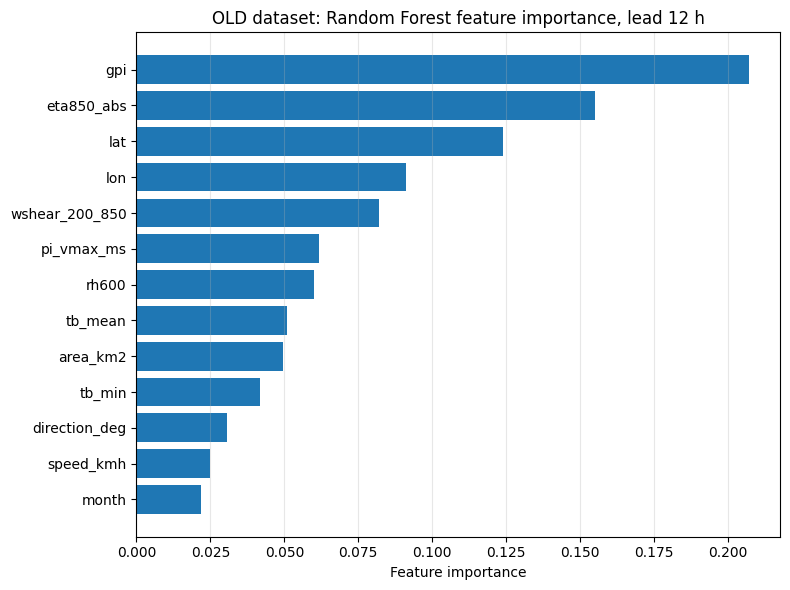

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Random_Forest_12h.png
Feature importance: AdaBoost, lead 12h


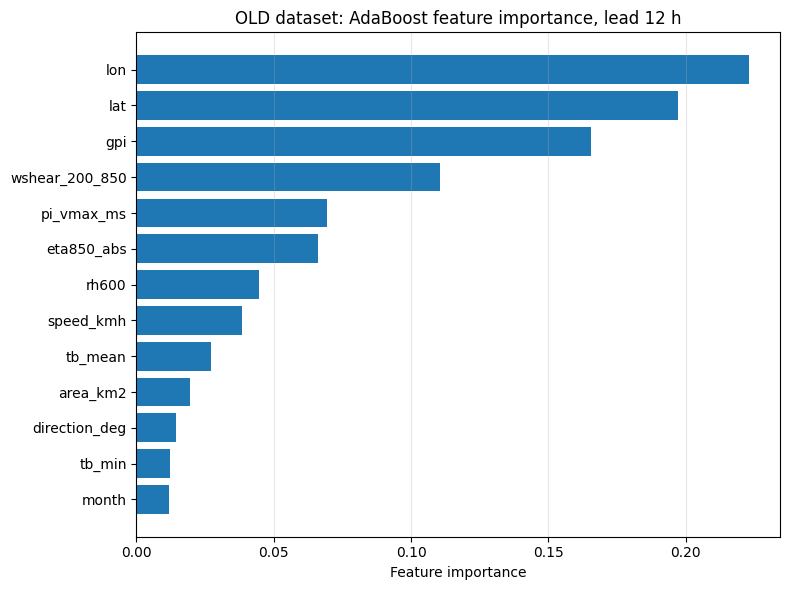

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_AdaBoost_12h.png
Feature importance: Decision Tree, lead 12h


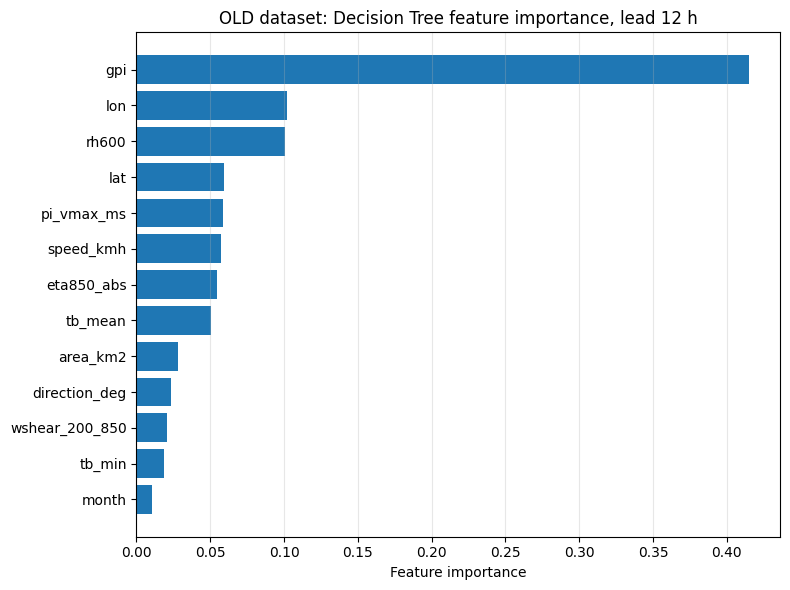

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Decision_Tree_12h.png
Feature importance: Random Forest, lead 24h


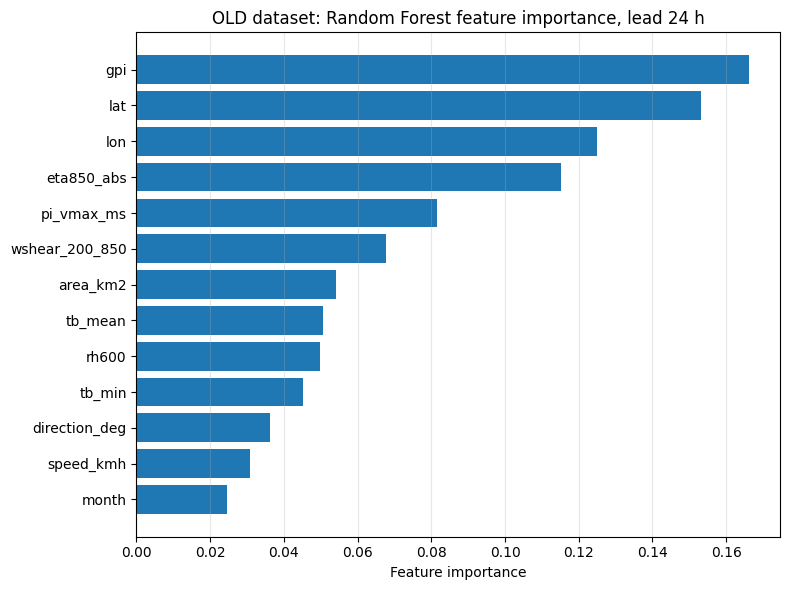

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Random_Forest_24h.png
Feature importance: AdaBoost, lead 24h


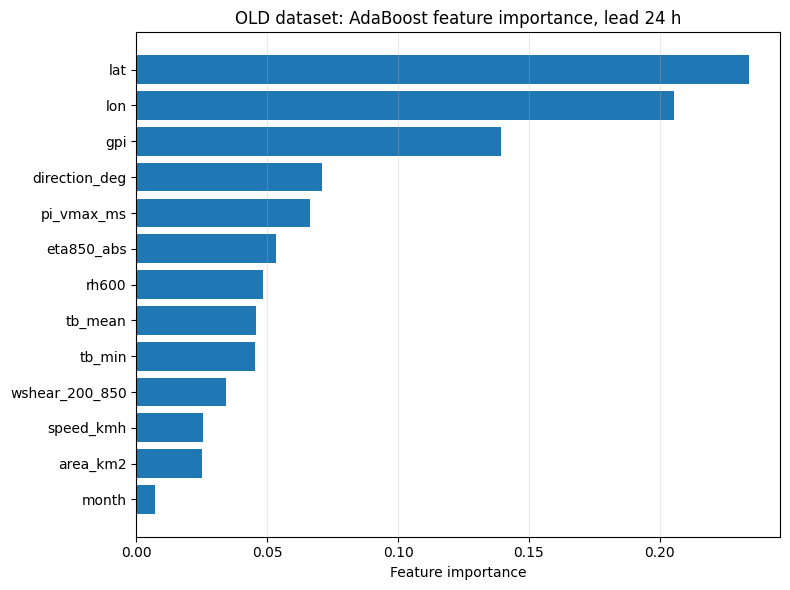

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_AdaBoost_24h.png
Feature importance: Decision Tree, lead 24h


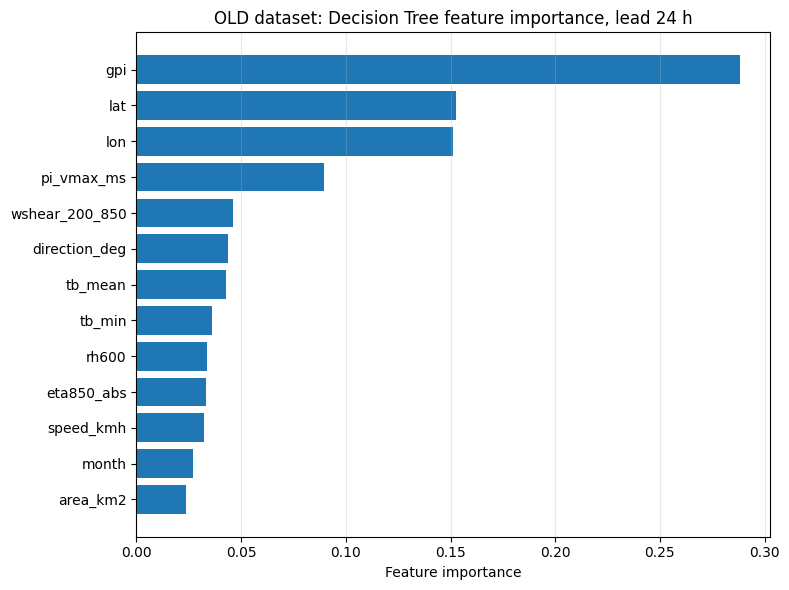

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Decision_Tree_24h.png
Feature importance: Random Forest, lead 48h


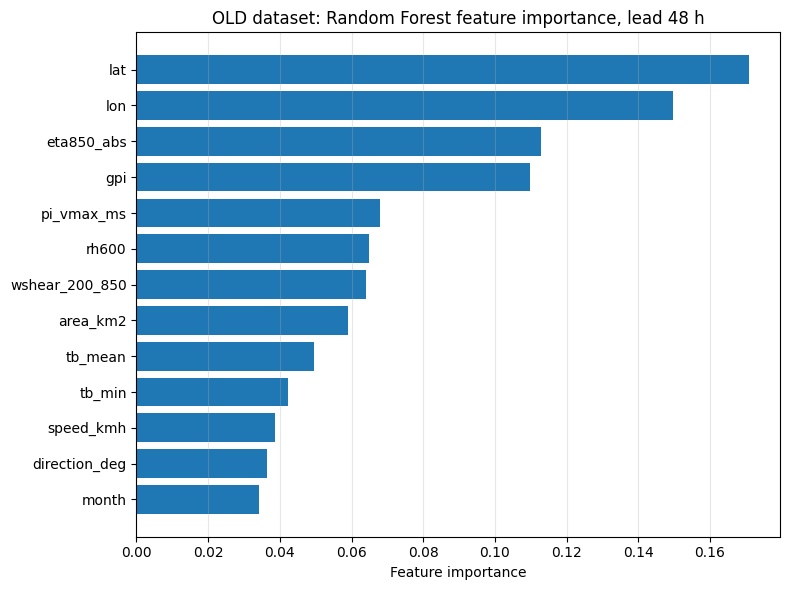

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Random_Forest_48h.png
Feature importance: AdaBoost, lead 48h


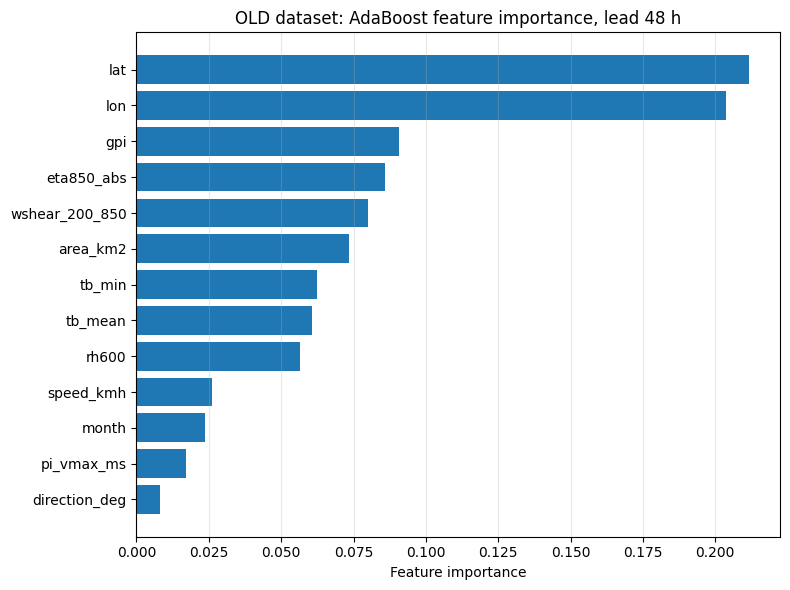

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_AdaBoost_48h.png
Feature importance: Decision Tree, lead 48h


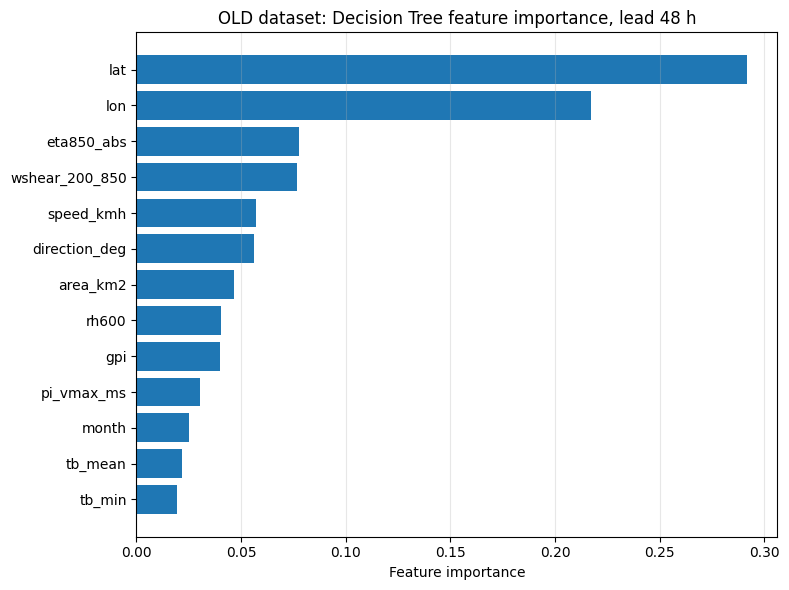

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Decision_Tree_48h.png


,lead_h,model,feature,importance
14,6,AdaBoost,lat,0.224876
13,6,AdaBoost,lon,0.172907
24,6,AdaBoost,pi_vmax_ms,0.133227
25,6,AdaBoost,gpi,0.117671
22,6,AdaBoost,rh600,0.091303
...,...,...,...,...
121,48,Random Forest,tb_mean,0.049514
122,48,Random Forest,tb_min,0.042139
123,48,Random Forest,speed_kmh,0.038603
124,48,Random Forest,direction_deg,0.036527


In [41]:
# ============================================================
# FEATURE IMPORTANCE — OLD TREE MODELS
# Random Forest / AdaBoost / Decision Tree
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

tree_models = {
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=600,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]),

    "AdaBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", AdaBoostClassifier(
            n_estimators=600,
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]),
}

fi_rows = []

for lead in LEADS:
    df = datasets[lead].copy()

    X = df[FEATURE_COLS].copy()
    y = df["y"].astype(int).values

    for model_name, model in tree_models.items():
        print(f"Feature importance: {model_name}, lead {lead}h")

        model.fit(X, y)
        clf = model.named_steps["clf"]

        if not hasattr(clf, "feature_importances_"):
            print(f"[SKIP] {model_name} has no feature_importances_")
            continue

        imp = pd.DataFrame({
            "lead_h": lead,
            "model": model_name,
            "feature": FEATURE_COLS,
            "importance": clf.feature_importances_,
        })

        fi_rows.append(imp)

        imp_plot = imp.sort_values("importance", ascending=True)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(imp_plot["feature"], imp_plot["importance"])
        ax.set_xlabel("Feature importance")
        ax.set_title(f"OLD dataset: {model_name} feature importance, lead {lead} h")
        ax.grid(True, axis="x", alpha=0.3)

        plt.tight_layout()

        safe_model = model_name.replace(" ", "_").replace("/", "_")
        out_png = FI_DIR / f"feature_importance_old_{safe_model}_{lead}h.png"

        plt.savefig(out_png, dpi=220, bbox_inches="tight")
        plt.show()

        print("Saved:", out_png)

if fi_rows:
    fi_all = pd.concat(fi_rows, ignore_index=True)
    fi_all.to_csv(FI_DIR / "feature_importance_tree_models_old.csv", index=False)
    display(fi_all.sort_values(["lead_h", "model", "importance"], ascending=[True, True, False]))

SHAP

datasets not found. Loading case tables from CASE_DIR...
Lead 6h | rows=1338 | positive=223 | negative=1115
Lead 12h | rows=1242 | positive=207 | negative=1035
Lead 24h | rows=1050 | positive=175 | negative=875
Lead 48h | rows=756 | positive=126 | negative=630

SHAP ANALYSIS | MODEL: AdaBoost

------------------------------------------------------------------------------------------
Lead 6h
------------------------------------------------------------------------------------------
Rows used: 565 | positive=125 | negative=440
Background sample: 80 | Explanation sample: 375 | Explanation positives=125


PermutationExplainer explainer: 376it [00:57,  5.64it/s]                         


Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,6,AdaBoost,lat,0.013633,0.003363,1
12,6,AdaBoost,gpi,0.012582,0.003678,2
0,6,AdaBoost,lon,0.007734,0.000698,3
11,6,AdaBoost,pi_vmax_ms,0.007417,0.000119,4
3,6,AdaBoost,area_km2,0.007314,0.001970,5
8,6,AdaBoost,eta850_abs,0.006340,0.001489,6
5,6,AdaBoost,tb_min,0.005223,-0.001659,7
9,6,AdaBoost,rh600,0.004757,0.001534,8
4,6,AdaBoost,tb_mean,0.003837,0.002016,9
6,6,AdaBoost,speed_kmh,0.003039,-0.000204,10


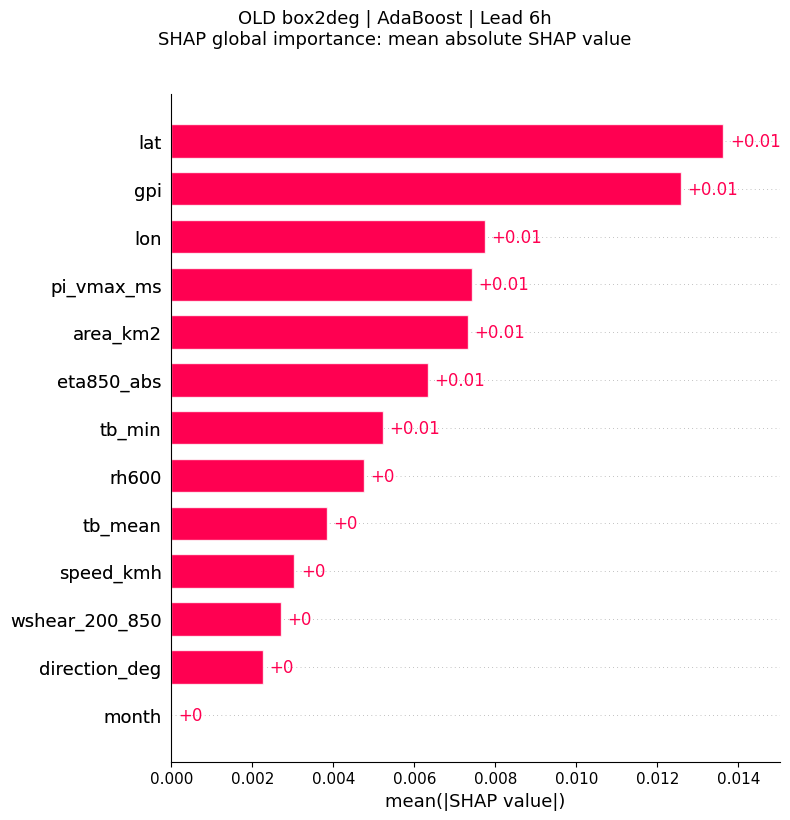

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\shap_bar_old_box2deg_AdaBoost_6h.png


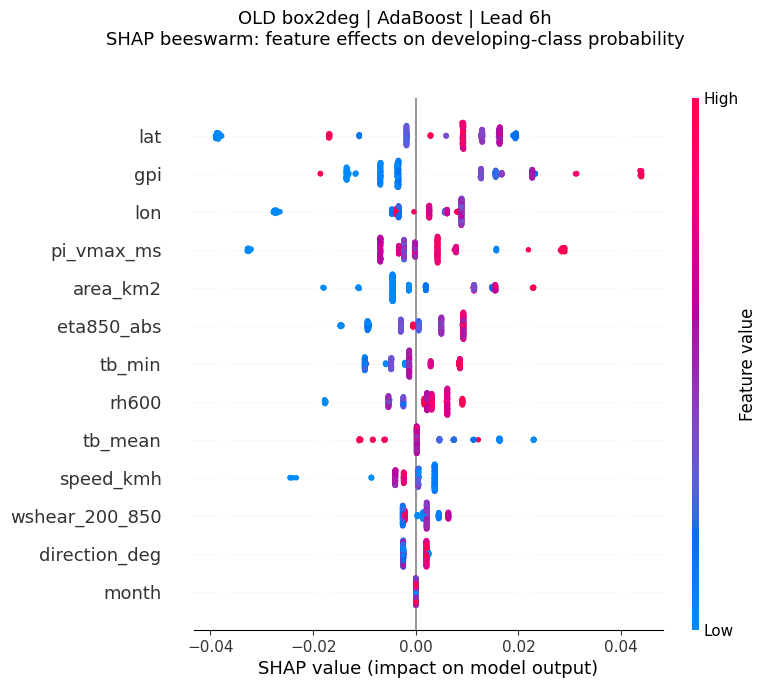

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\shap_beeswarm_old_box2deg_AdaBoost_6h.png


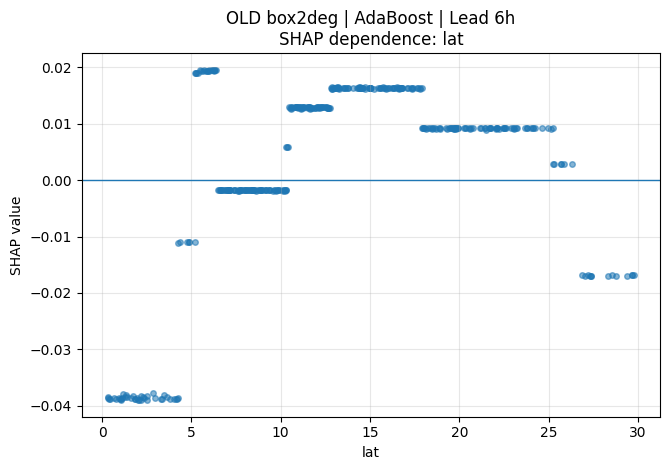

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_6h_dependence_lat.png


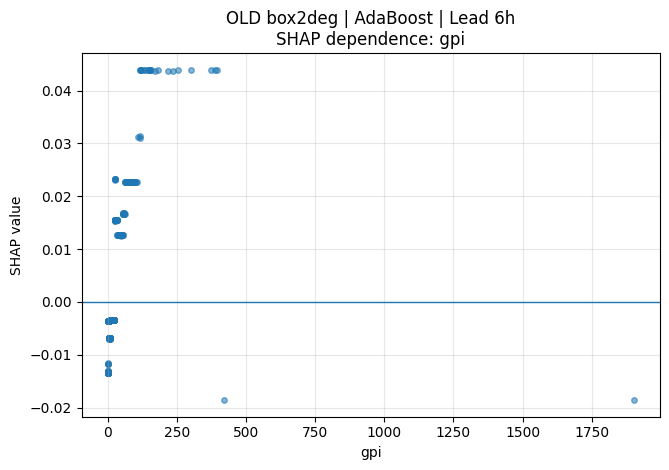

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_6h_dependence_gpi.png


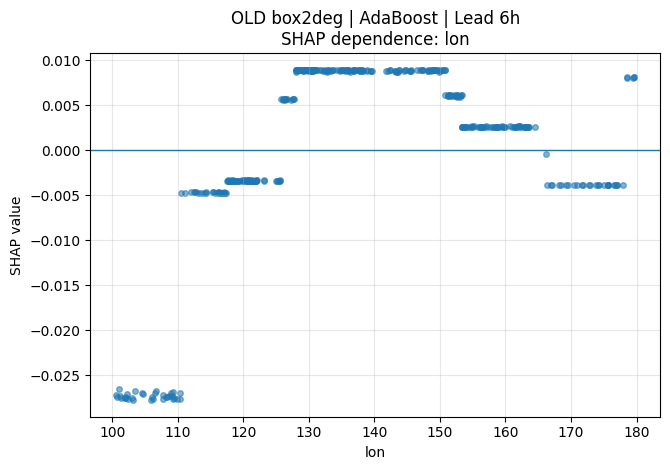

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_6h_dependence_lon.png


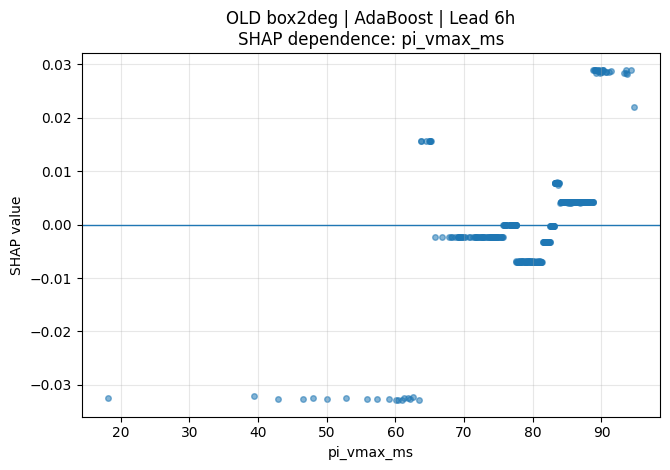

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_6h_dependence_pi_vmax_ms.png


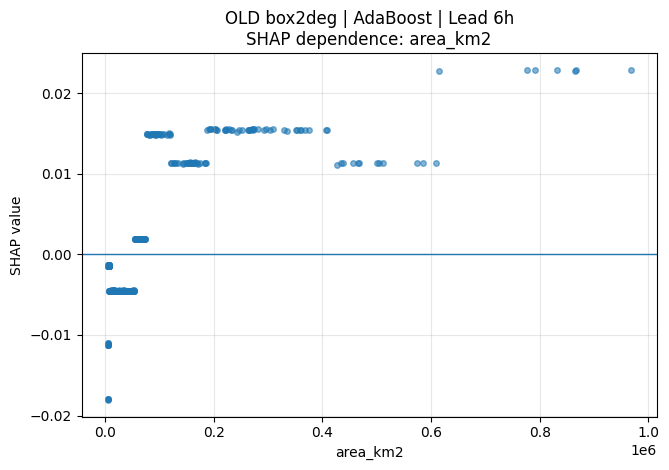

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_6h_dependence_area_km2.png

------------------------------------------------------------------------------------------
Lead 12h
------------------------------------------------------------------------------------------
Rows used: 560 | positive=122 | negative=438
Background sample: 80 | Explanation sample: 372 | Explanation positives=122


PermutationExplainer explainer: 373it [00:57,  5.33it/s]                         

Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,12,AdaBoost,lat,0.015813,0.002614,1
12,12,AdaBoost,gpi,0.012995,0.001107,2
0,12,AdaBoost,lon,0.011476,-0.001815,3
10,12,AdaBoost,wshear_200_850,0.006740,0.000813,4
11,12,AdaBoost,pi_vmax_ms,0.006138,-0.000201,5
4,12,AdaBoost,tb_mean,0.005592,0.000286,6
5,12,AdaBoost,tb_min,0.005372,-0.000335,7
2,12,AdaBoost,month,0.004821,-0.000024,8
3,12,AdaBoost,area_km2,0.004643,-0.000613,9
8,12,AdaBoost,eta850_abs,0.004636,0.000294,10


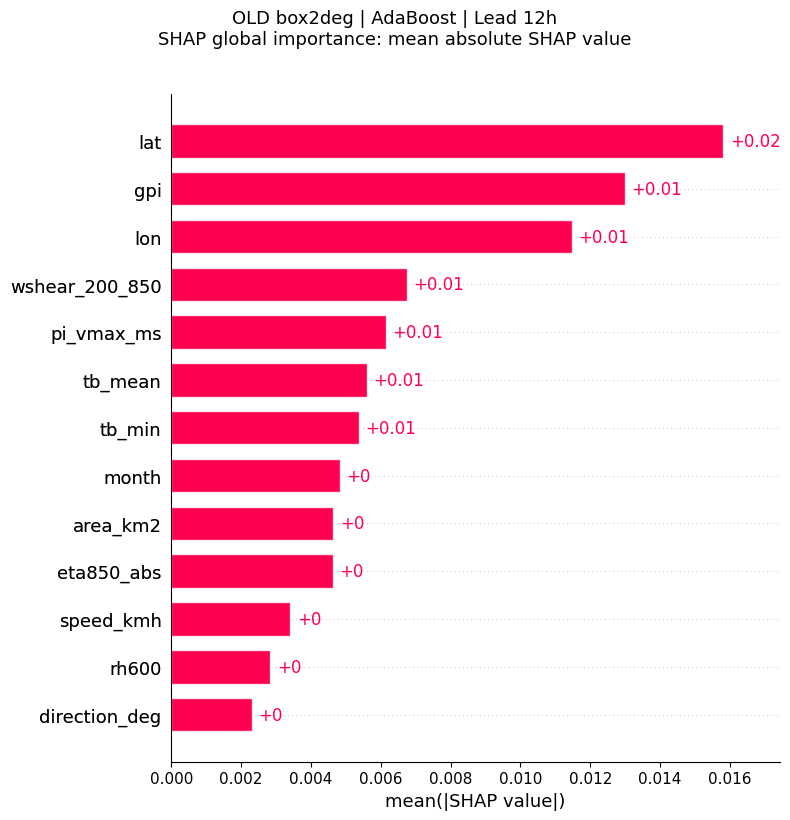

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\shap_bar_old_box2deg_AdaBoost_12h.png


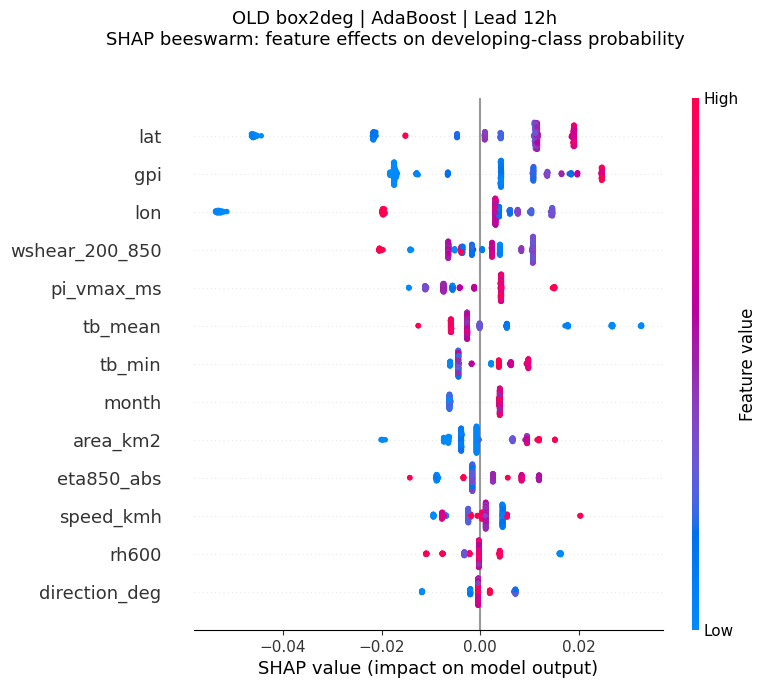

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\shap_beeswarm_old_box2deg_AdaBoost_12h.png


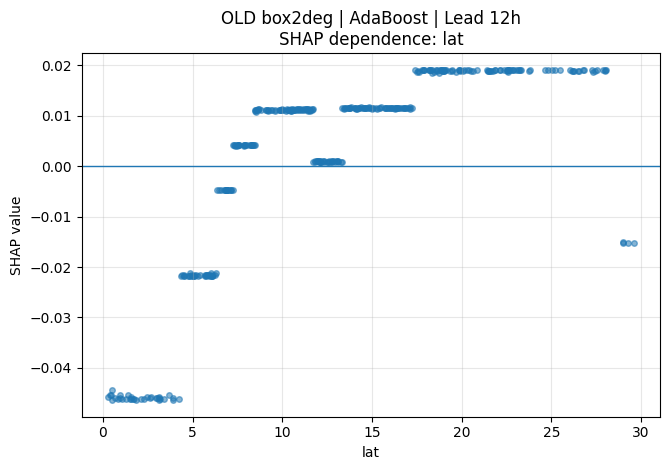

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_12h_dependence_lat.png


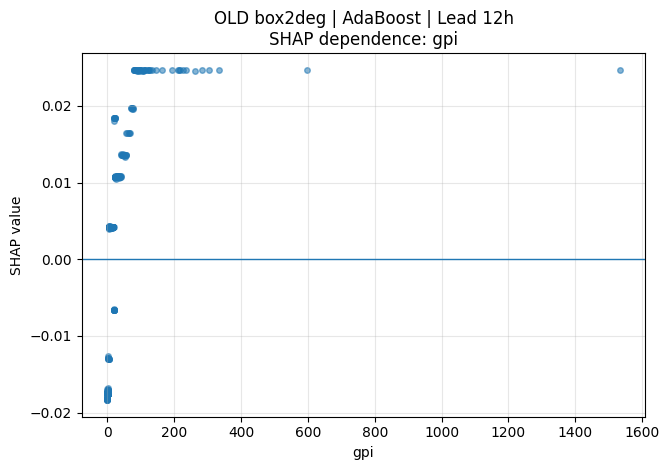

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_12h_dependence_gpi.png


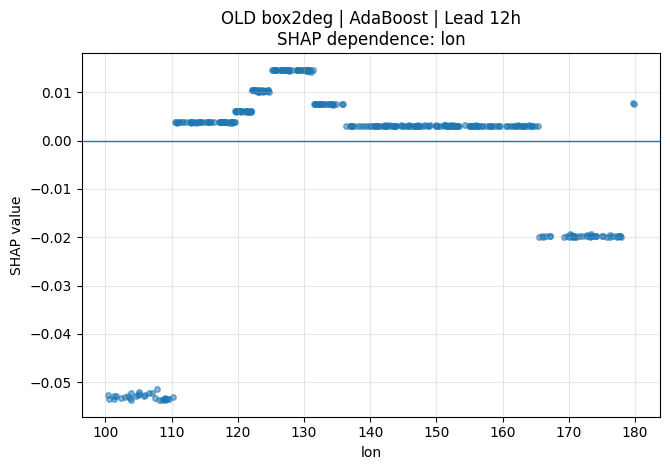

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_12h_dependence_lon.png


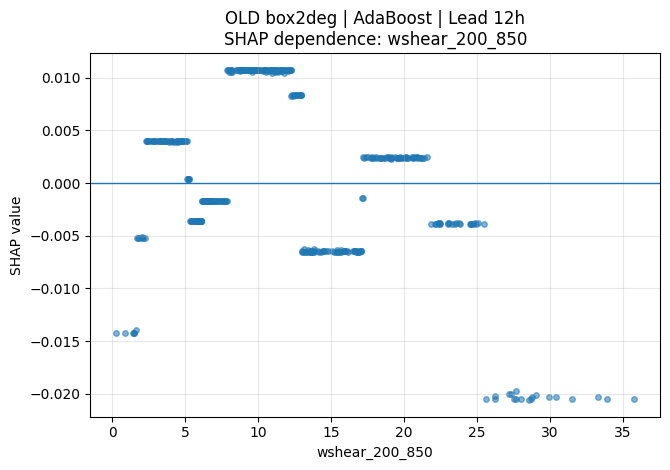

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_12h_dependence_wshear_200_850.png


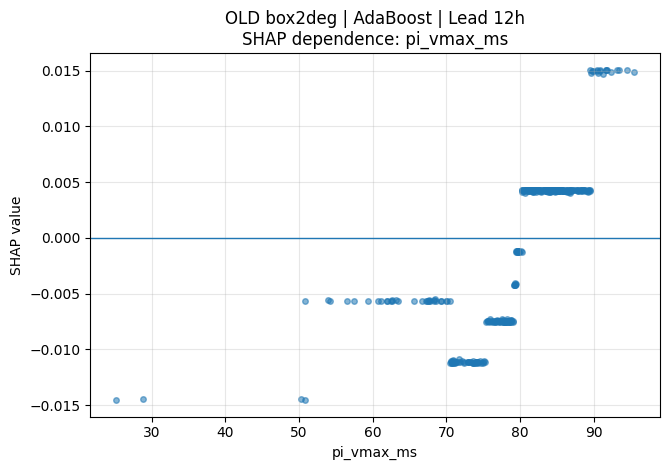

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_12h_dependence_pi_vmax_ms.png

------------------------------------------------------------------------------------------
Lead 24h
------------------------------------------------------------------------------------------
Rows used: 417 | positive=71 | negative=346
Background sample: 80 | Explanation sample: 321 | Explanation positives=71


PermutationExplainer explainer: 322it [00:42,  6.02it/s]                         

Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,24,AdaBoost,lat,0.024319,0.006757,1
10,24,AdaBoost,wshear_200_850,0.009273,0.000670,2
0,24,AdaBoost,lon,0.008154,0.001314,3
12,24,AdaBoost,gpi,0.007720,0.002456,4
9,24,AdaBoost,rh600,0.007212,0.001320,5
8,24,AdaBoost,eta850_abs,0.005383,0.001005,6
4,24,AdaBoost,tb_mean,0.005227,-0.000132,7
6,24,AdaBoost,speed_kmh,0.003980,-0.000162,8
7,24,AdaBoost,direction_deg,0.003943,0.001246,9
11,24,AdaBoost,pi_vmax_ms,0.003663,0.000675,10


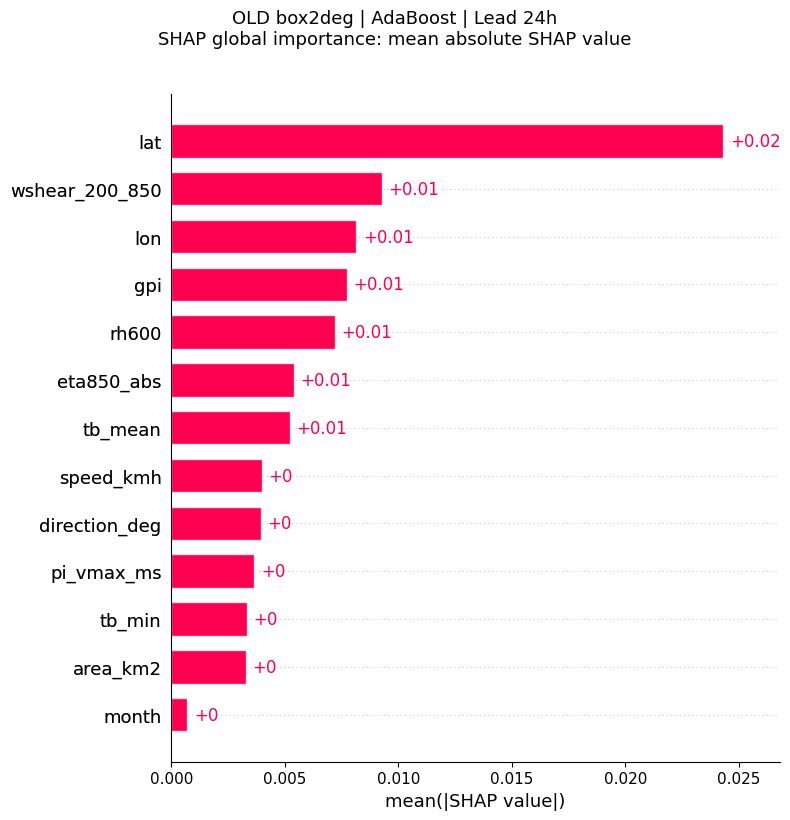

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\shap_bar_old_box2deg_AdaBoost_24h.png


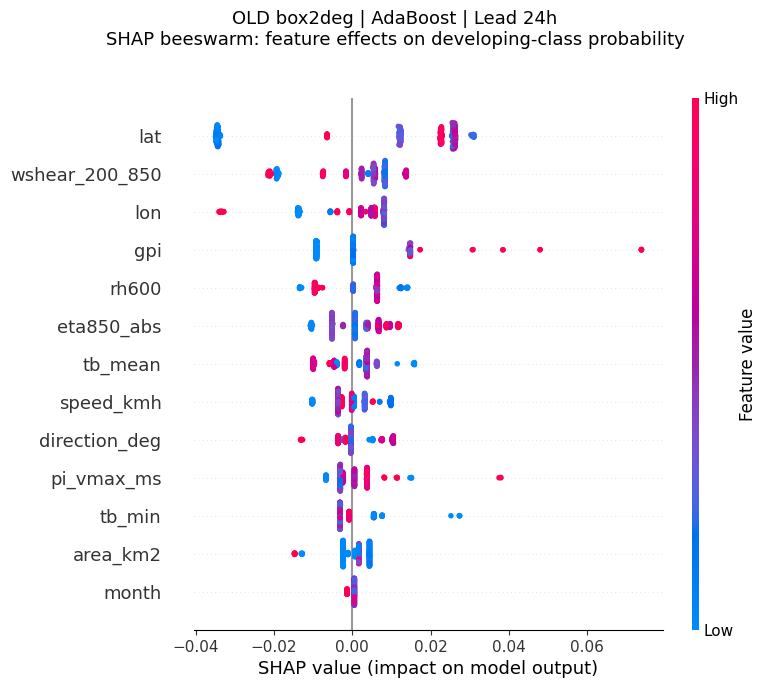

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\shap_beeswarm_old_box2deg_AdaBoost_24h.png


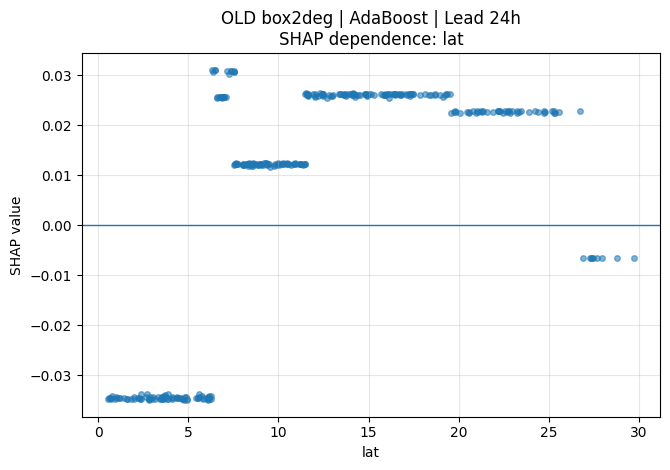

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_24h_dependence_lat.png


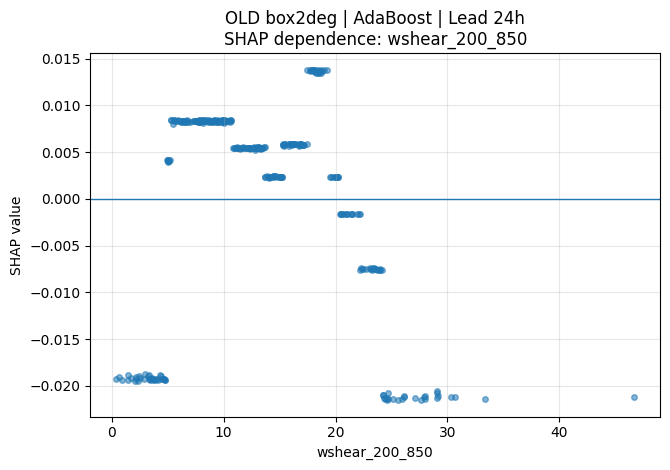

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_24h_dependence_wshear_200_850.png


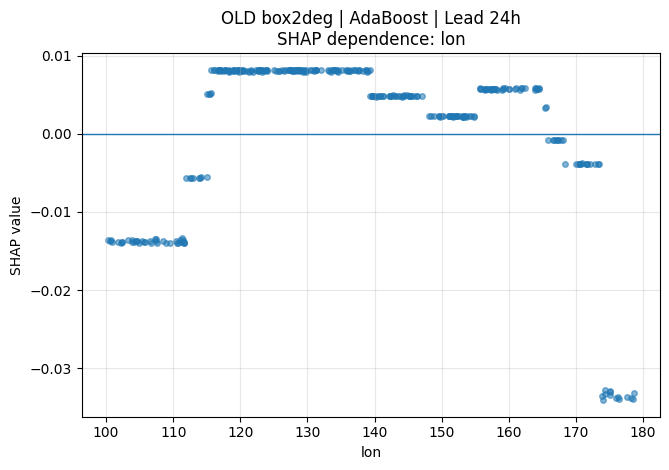

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_24h_dependence_lon.png


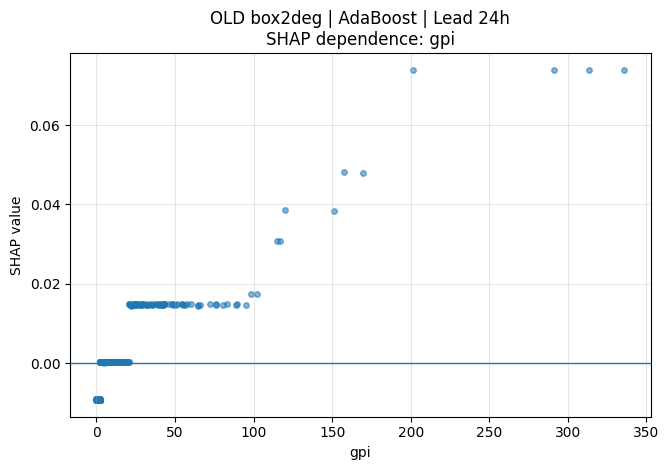

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_24h_dependence_gpi.png


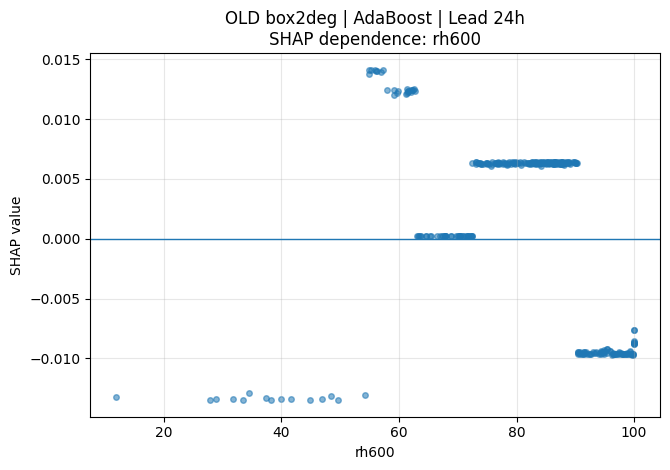

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_24h_dependence_rh600.png

------------------------------------------------------------------------------------------
Lead 48h
------------------------------------------------------------------------------------------
Rows used: 279 | positive=51 | negative=228
Background sample: 80 | Explanation sample: 279 | Explanation positives=51


PermutationExplainer explainer: 280it [00:28,  6.37it/s]                         

Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,48,AdaBoost,lat,0.020306,0.002796,1
0,48,AdaBoost,lon,0.012719,-0.000854,2
12,48,AdaBoost,gpi,0.010864,0.001927,3
6,48,AdaBoost,speed_kmh,0.005517,0.000453,4
10,48,AdaBoost,wshear_200_850,0.005412,0.000582,5
9,48,AdaBoost,rh600,0.005046,0.000246,6
4,48,AdaBoost,tb_mean,0.004782,-0.000791,7
3,48,AdaBoost,area_km2,0.003574,0.000130,8
7,48,AdaBoost,direction_deg,0.003095,0.000371,9
2,48,AdaBoost,month,0.002330,0.000312,10


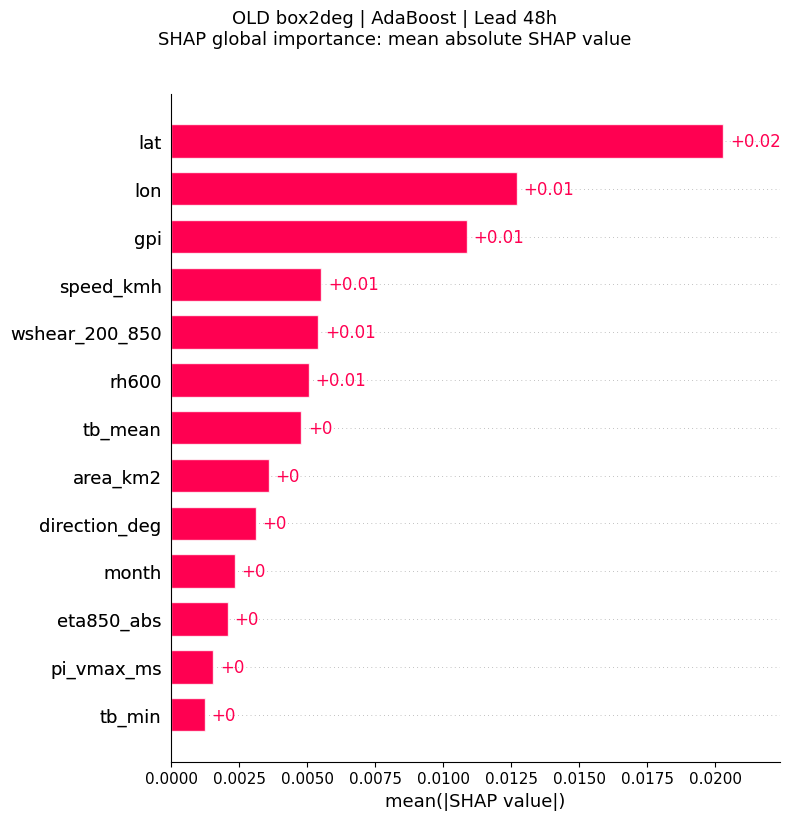

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\shap_bar_old_box2deg_AdaBoost_48h.png


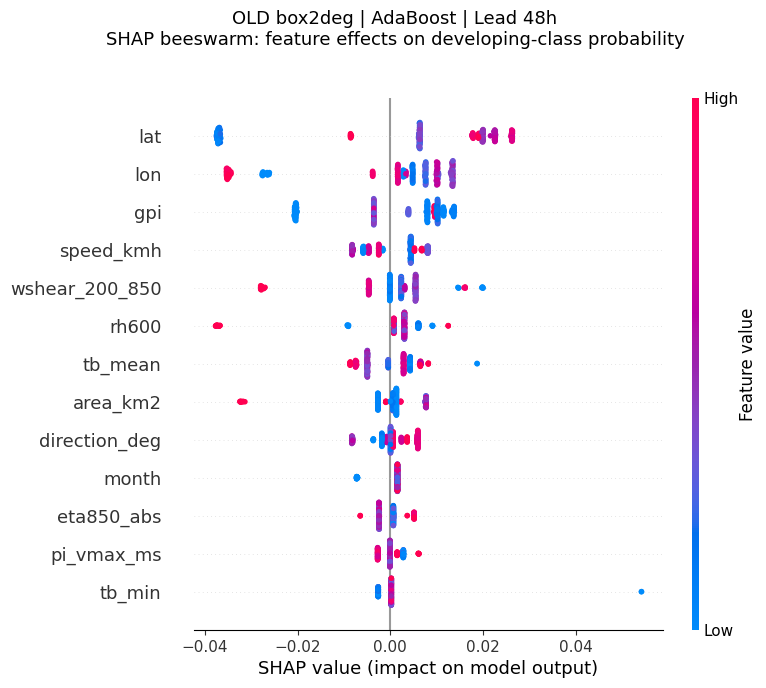

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\shap_beeswarm_old_box2deg_AdaBoost_48h.png


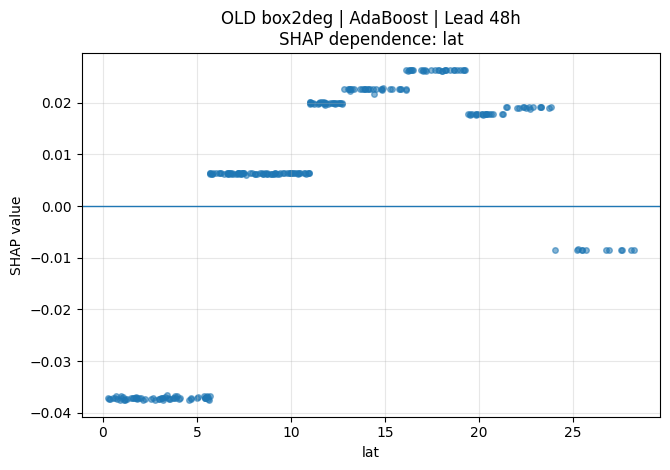

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_48h_dependence_lat.png


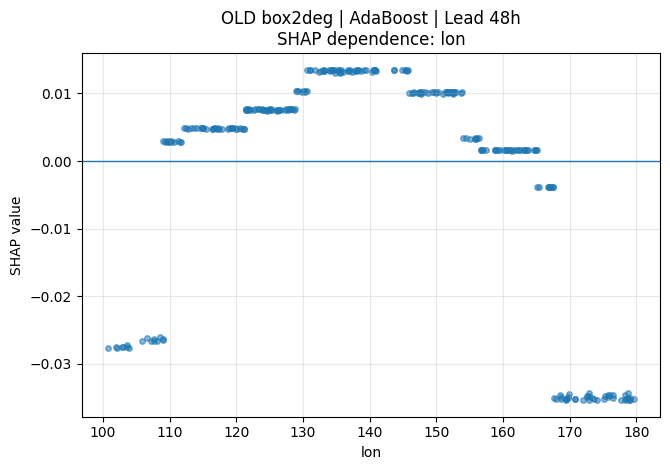

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_48h_dependence_lon.png


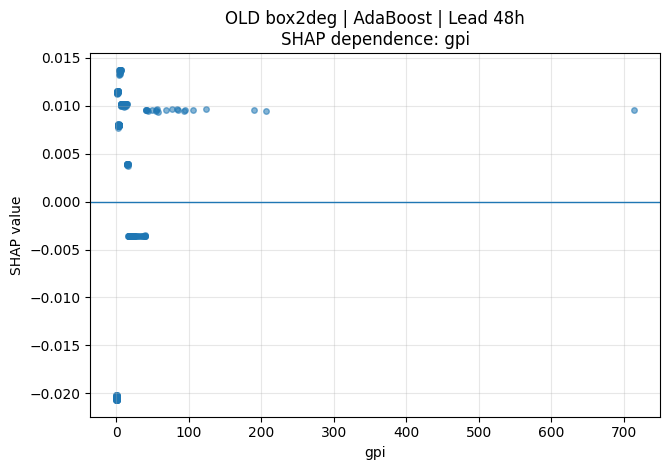

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_48h_dependence_gpi.png


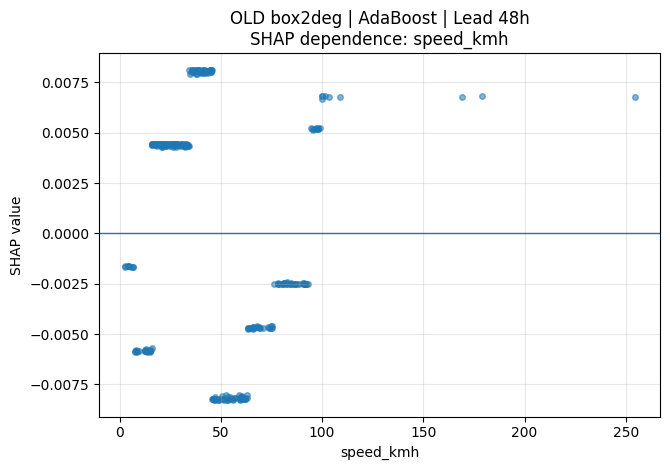

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_48h_dependence_speed_kmh.png


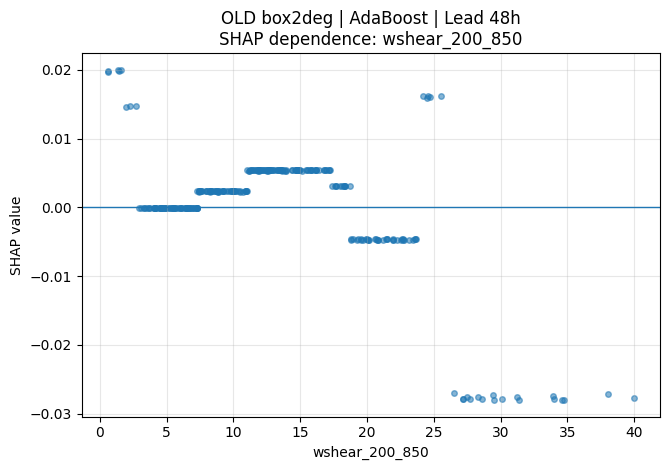

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\AdaBoost\OLD_box2deg__AdaBoost__Lead_48h_dependence_wshear_200_850.png

SHAP ANALYSIS | MODEL: Random Forest

------------------------------------------------------------------------------------------
Lead 6h
------------------------------------------------------------------------------------------
Rows used: 565 | positive=125 | negative=440
Background sample: 80 | Explanation sample: 375 | Explanation positives=125


PermutationExplainer explainer: 376it [01:06,  4.70it/s]                         

Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
12,6,Random Forest,gpi,0.078335,0.026979,1
8,6,Random Forest,eta850_abs,0.065660,0.025271,2
1,6,Random Forest,lat,0.039302,0.010993,3
9,6,Random Forest,rh600,0.036328,0.009037,4
3,6,Random Forest,area_km2,0.034323,0.012120,5
4,6,Random Forest,tb_mean,0.024411,0.007665,6
11,6,Random Forest,pi_vmax_ms,0.023904,0.000521,7
0,6,Random Forest,lon,0.021897,0.004744,8
10,6,Random Forest,wshear_200_850,0.016693,0.002984,9
5,6,Random Forest,tb_min,0.013192,0.003104,10


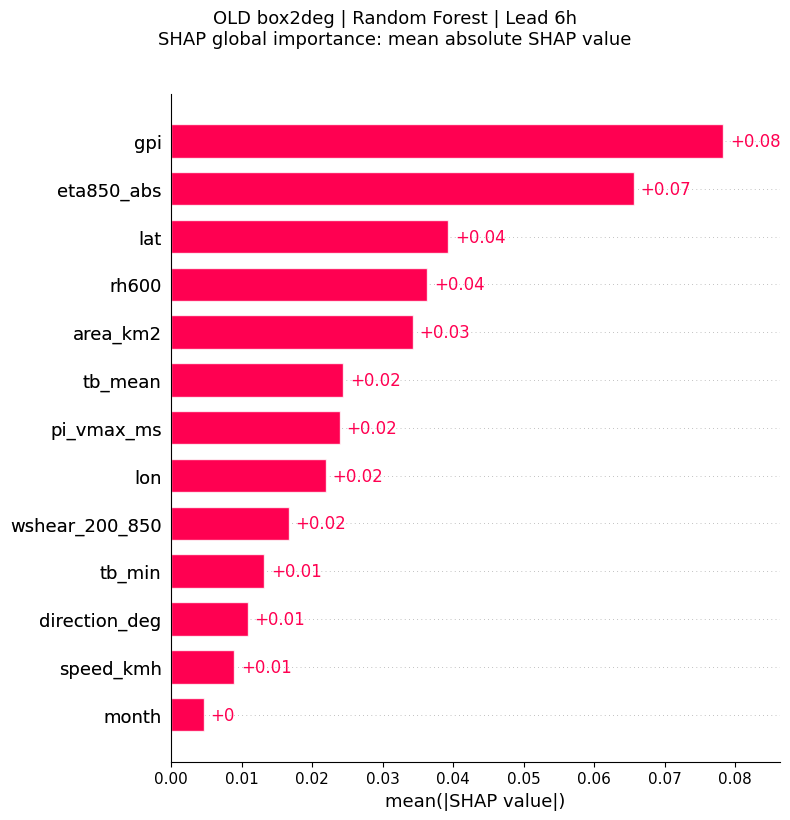

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\shap_bar_old_box2deg_Random_Forest_6h.png


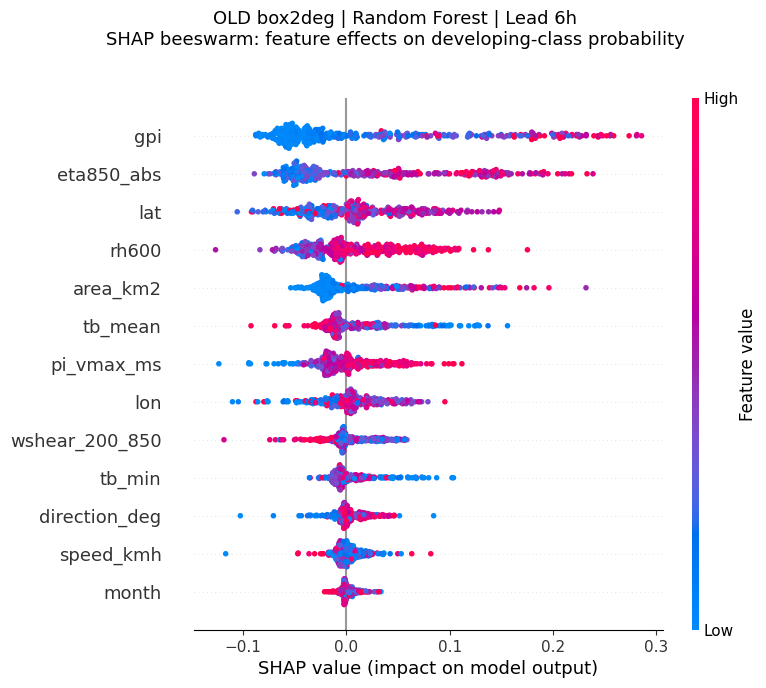

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\shap_beeswarm_old_box2deg_Random_Forest_6h.png


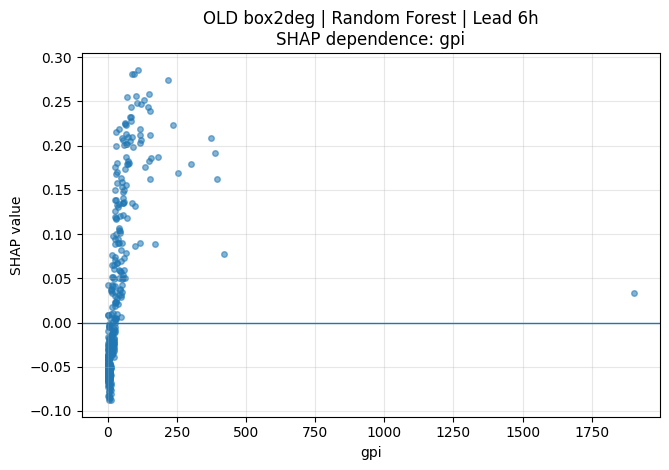

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_6h_dependence_gpi.png


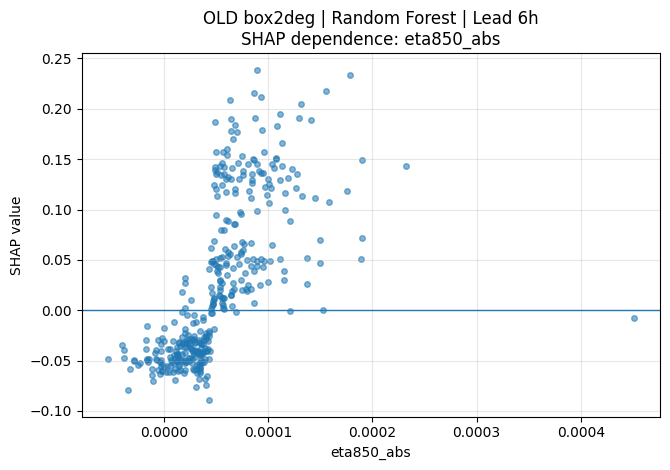

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_6h_dependence_eta850_abs.png


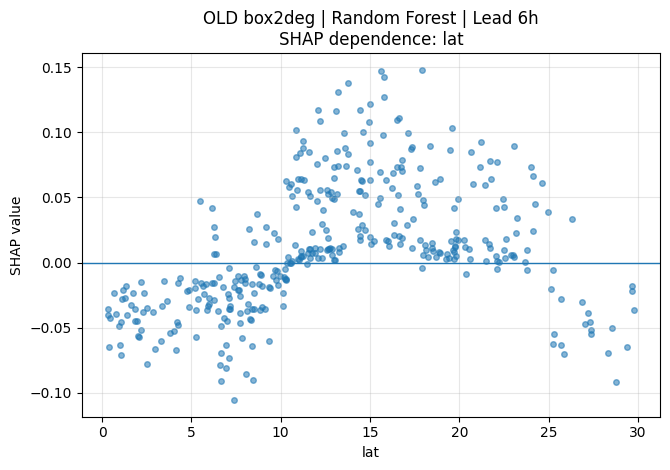

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_6h_dependence_lat.png


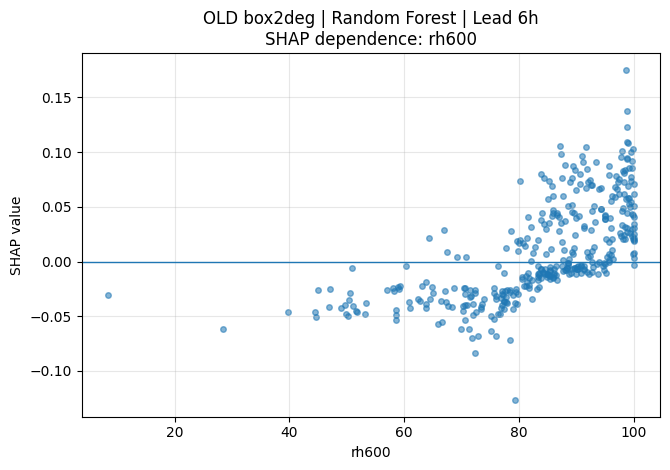

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_6h_dependence_rh600.png


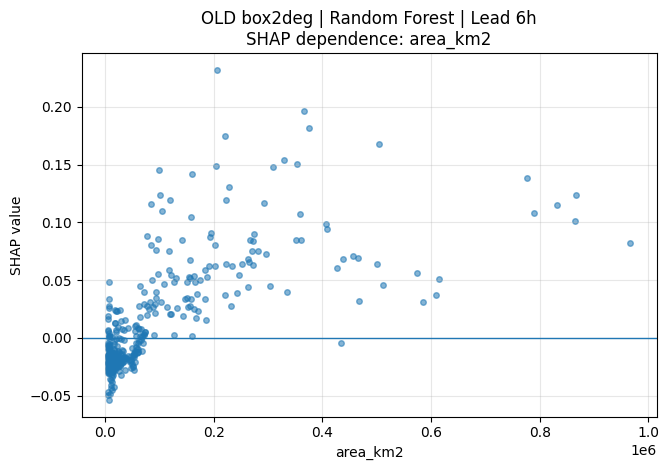

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_6h_dependence_area_km2.png

------------------------------------------------------------------------------------------
Lead 12h
------------------------------------------------------------------------------------------
Rows used: 560 | positive=122 | negative=438
Background sample: 80 | Explanation sample: 372 | Explanation positives=122


PermutationExplainer explainer: 373it [01:05,  4.82it/s]                         

Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
8,12,Random Forest,eta850_abs,0.068315,0.005981,1
12,12,Random Forest,gpi,0.067386,0.006222,2
1,12,Random Forest,lat,0.051076,0.008227,3
10,12,Random Forest,wshear_200_850,0.029312,0.003553,4
9,12,Random Forest,rh600,0.027009,-0.002295,5
0,12,Random Forest,lon,0.026436,-0.000867,6
3,12,Random Forest,area_km2,0.022439,0.000596,7
11,12,Random Forest,pi_vmax_ms,0.021409,0.000591,8
4,12,Random Forest,tb_mean,0.021150,0.002306,9
5,12,Random Forest,tb_min,0.014782,0.000374,10


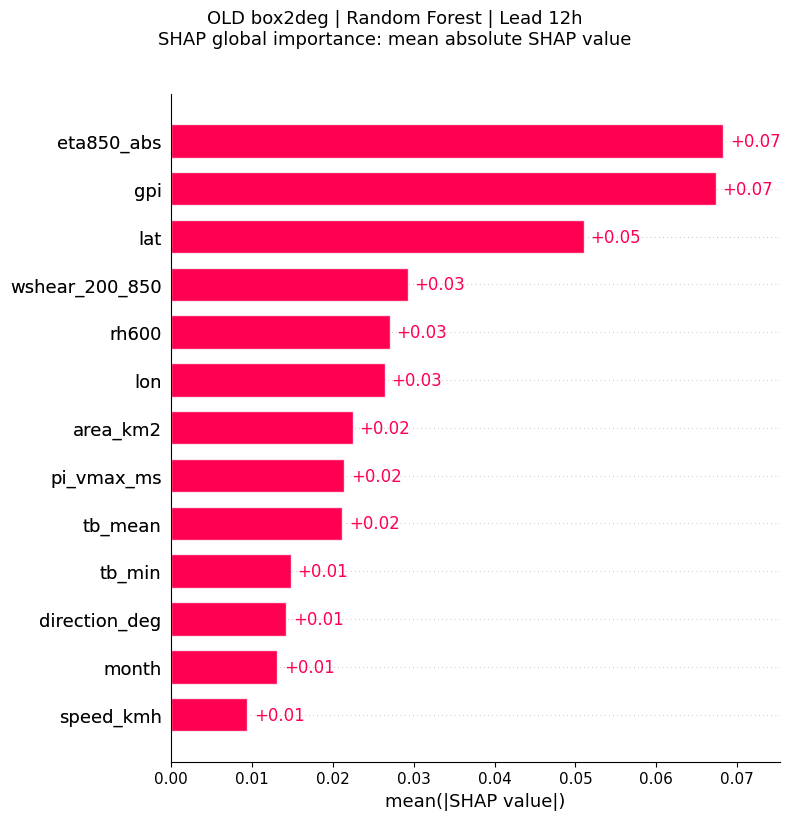

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\shap_bar_old_box2deg_Random_Forest_12h.png


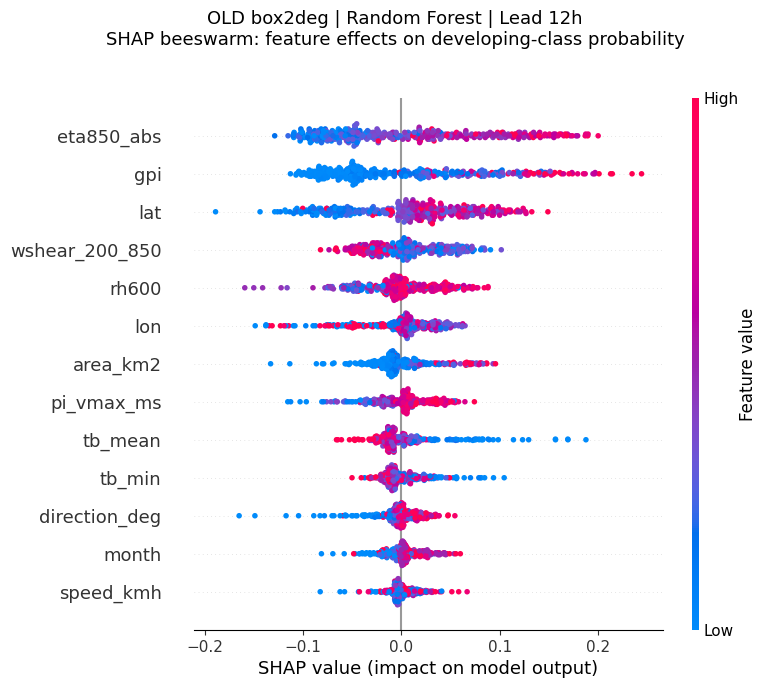

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\shap_beeswarm_old_box2deg_Random_Forest_12h.png


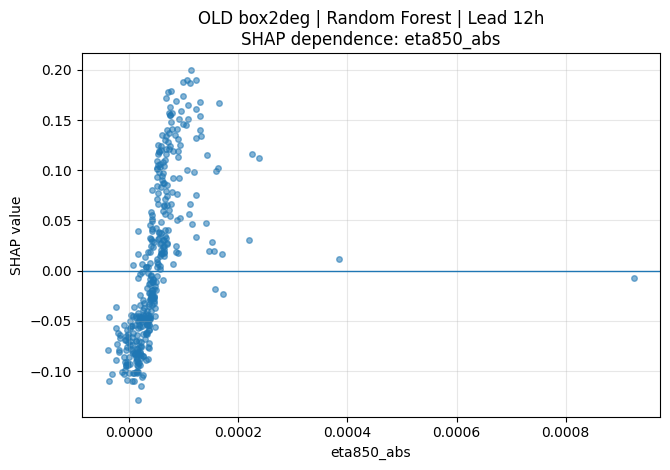

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_12h_dependence_eta850_abs.png


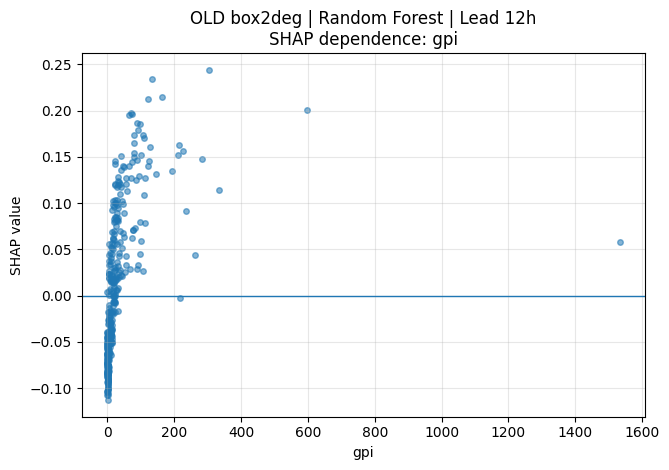

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_12h_dependence_gpi.png


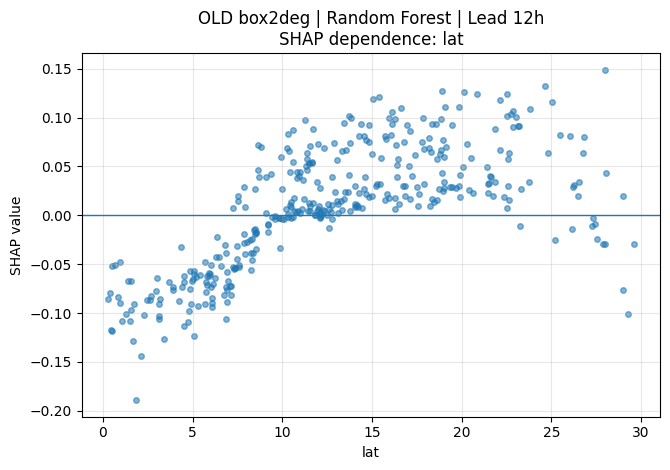

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_12h_dependence_lat.png


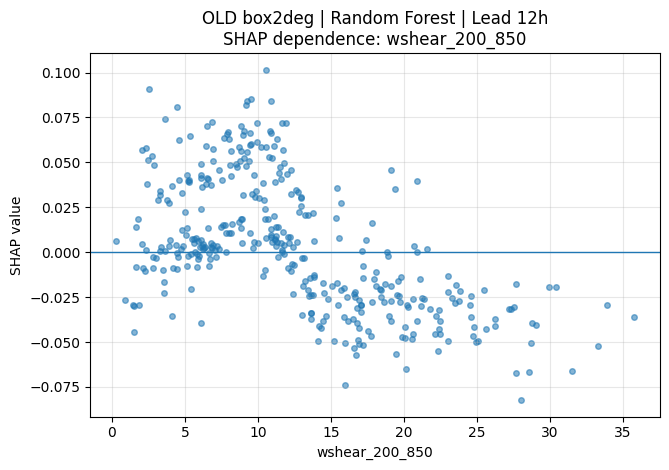

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_12h_dependence_wshear_200_850.png


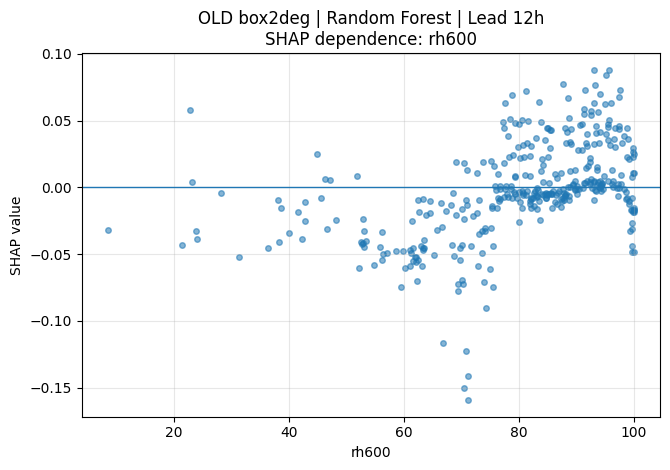

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_12h_dependence_rh600.png

------------------------------------------------------------------------------------------
Lead 24h
------------------------------------------------------------------------------------------
Rows used: 417 | positive=71 | negative=346
Background sample: 80 | Explanation sample: 321 | Explanation positives=71


PermutationExplainer explainer: 322it [00:58,  4.53it/s]                         


Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,24,Random Forest,lat,0.052415,0.016830,1
12,24,Random Forest,gpi,0.041223,0.016651,2
8,24,Random Forest,eta850_abs,0.040085,0.016459,3
10,24,Random Forest,wshear_200_850,0.023891,0.007827,4
11,24,Random Forest,pi_vmax_ms,0.018913,0.004691,5
0,24,Random Forest,lon,0.018512,0.006404,6
4,24,Random Forest,tb_mean,0.018124,0.001163,7
5,24,Random Forest,tb_min,0.015545,-0.001114,8
7,24,Random Forest,direction_deg,0.014088,0.003173,9
3,24,Random Forest,area_km2,0.013528,0.000948,10


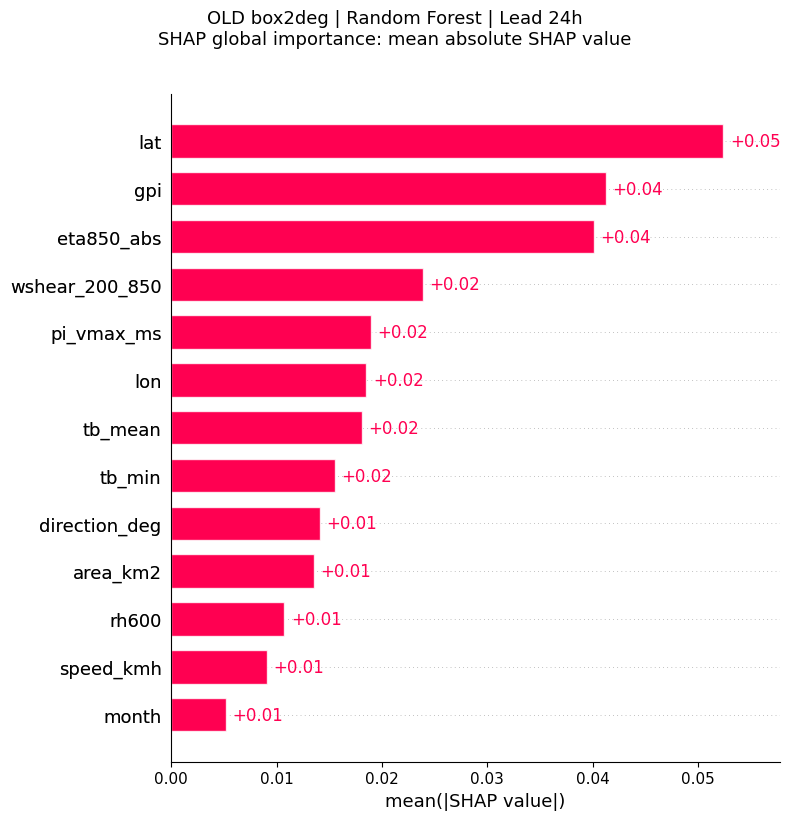

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\shap_bar_old_box2deg_Random_Forest_24h.png


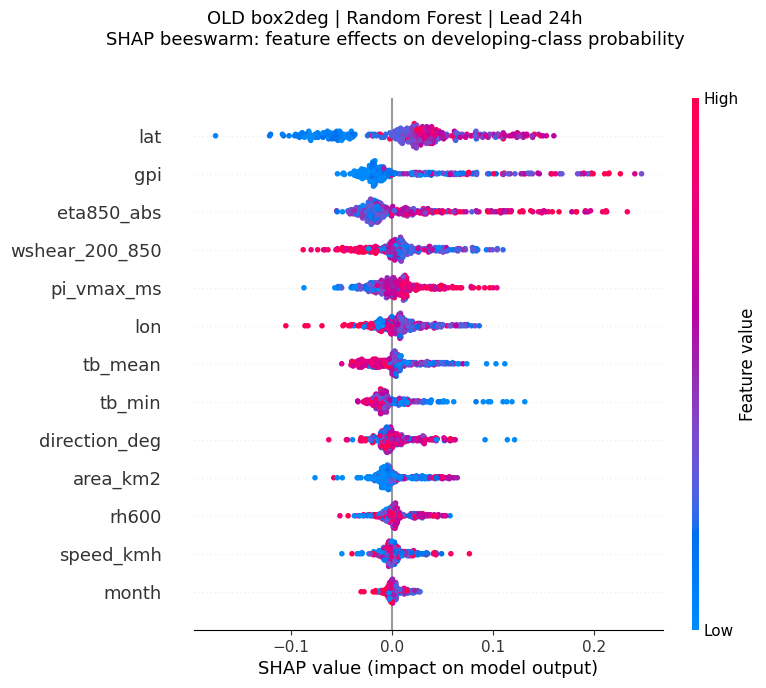

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\shap_beeswarm_old_box2deg_Random_Forest_24h.png


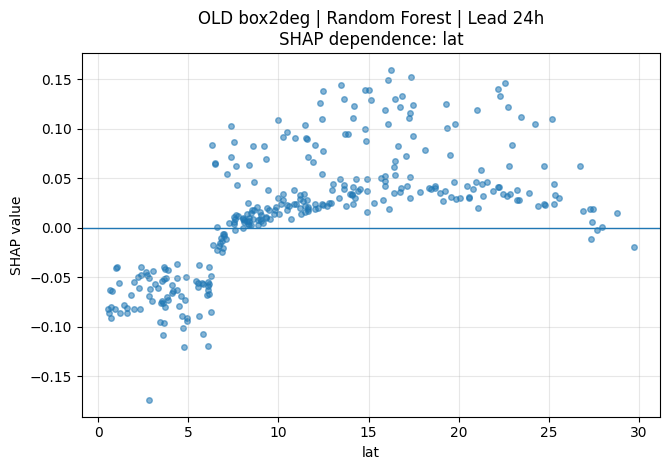

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_24h_dependence_lat.png


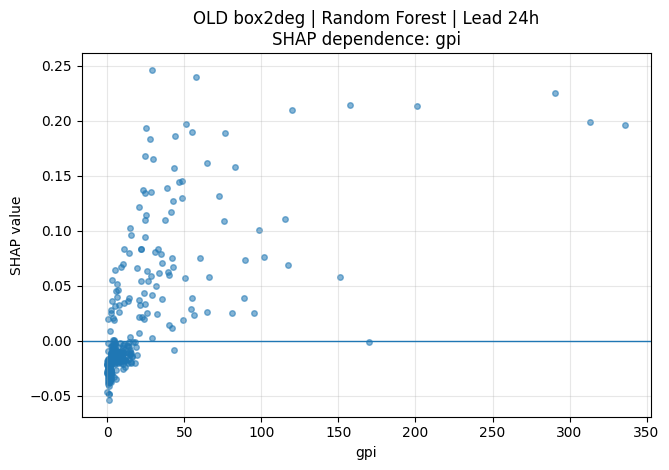

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_24h_dependence_gpi.png


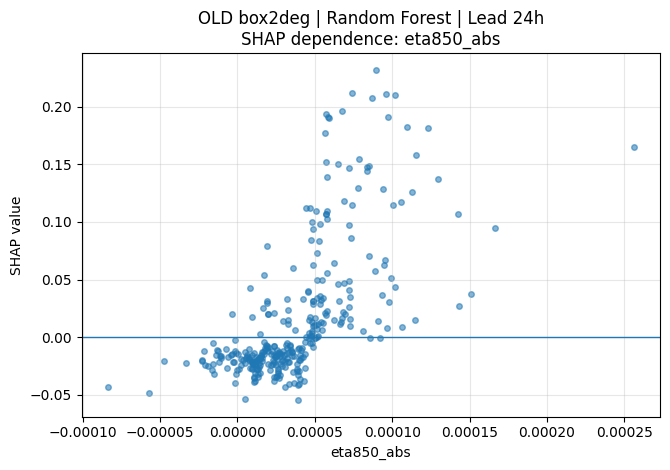

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_24h_dependence_eta850_abs.png


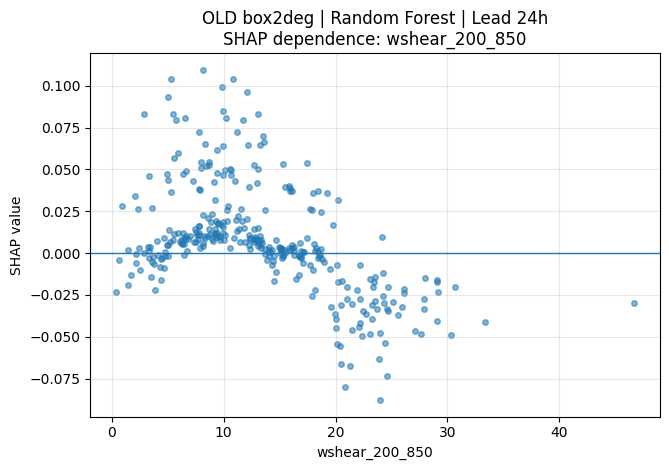

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_24h_dependence_wshear_200_850.png


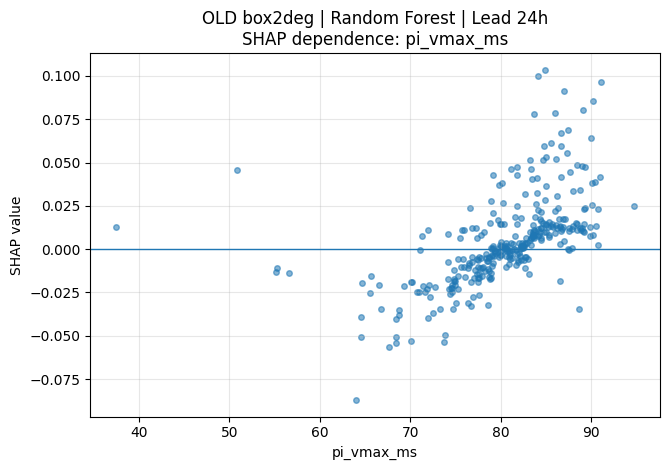

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_24h_dependence_pi_vmax_ms.png

------------------------------------------------------------------------------------------
Lead 48h
------------------------------------------------------------------------------------------
Rows used: 279 | positive=51 | negative=228
Background sample: 80 | Explanation sample: 279 | Explanation positives=51


PermutationExplainer explainer: 280it [00:51,  4.33it/s]                         


Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,48,Random Forest,lat,0.072412,0.012921,1
0,48,Random Forest,lon,0.032347,0.000272,2
12,48,Random Forest,gpi,0.030027,0.006617,3
8,48,Random Forest,eta850_abs,0.022461,0.005387,4
9,48,Random Forest,rh600,0.017589,0.002081,5
10,48,Random Forest,wshear_200_850,0.016379,0.001884,6
4,48,Random Forest,tb_mean,0.012872,0.000365,7
3,48,Random Forest,area_km2,0.012087,0.001454,8
6,48,Random Forest,speed_kmh,0.011501,0.001271,9
11,48,Random Forest,pi_vmax_ms,0.010256,0.003238,10


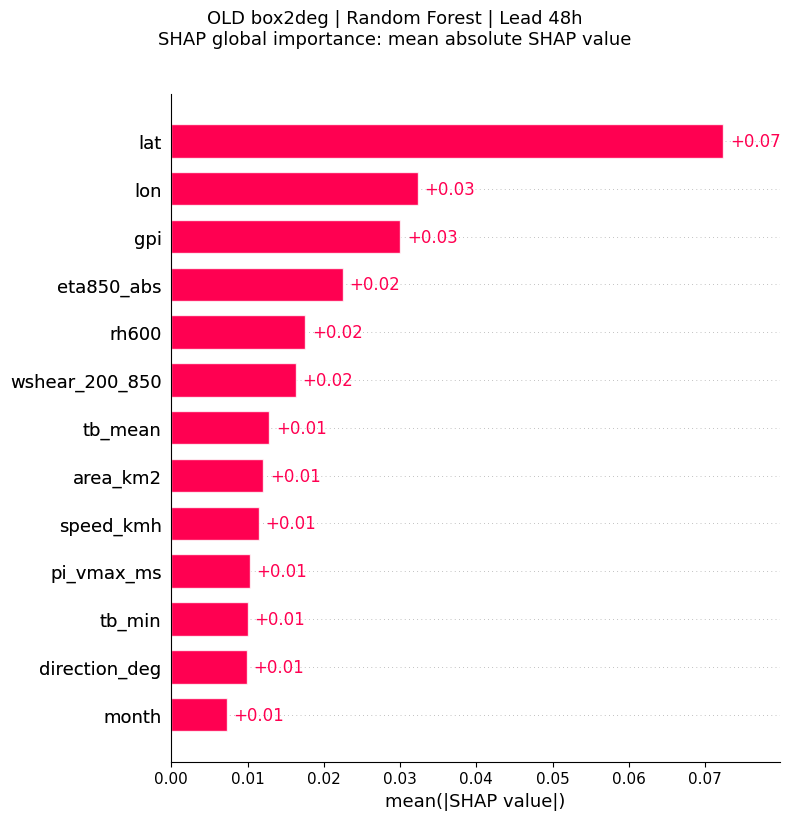

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\shap_bar_old_box2deg_Random_Forest_48h.png


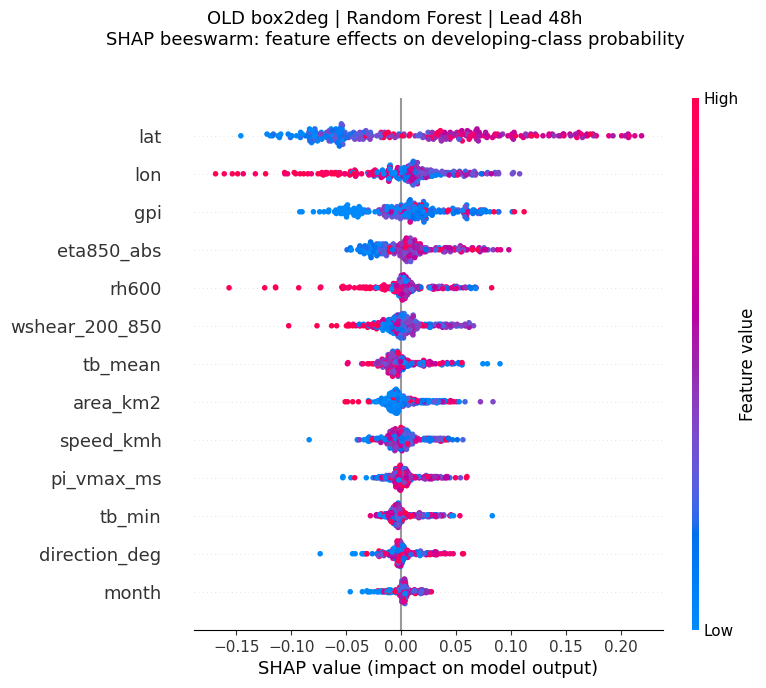

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\shap_beeswarm_old_box2deg_Random_Forest_48h.png


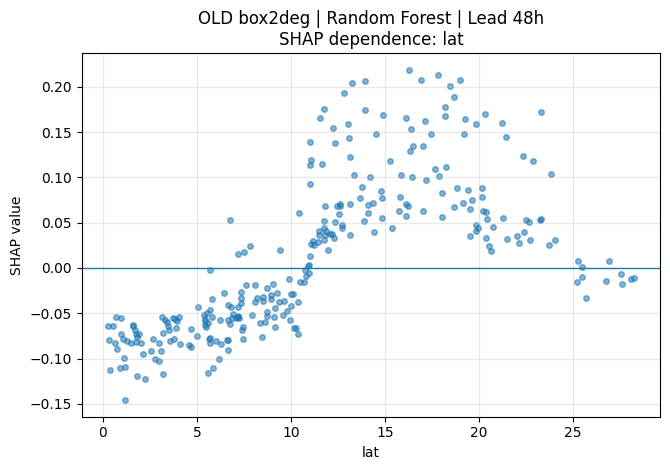

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_48h_dependence_lat.png


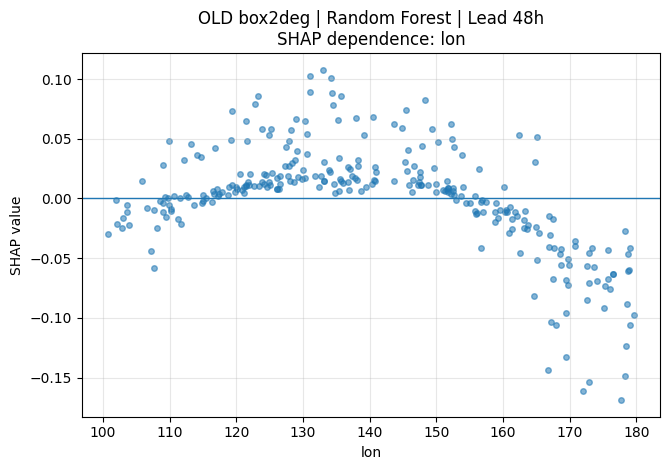

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_48h_dependence_lon.png


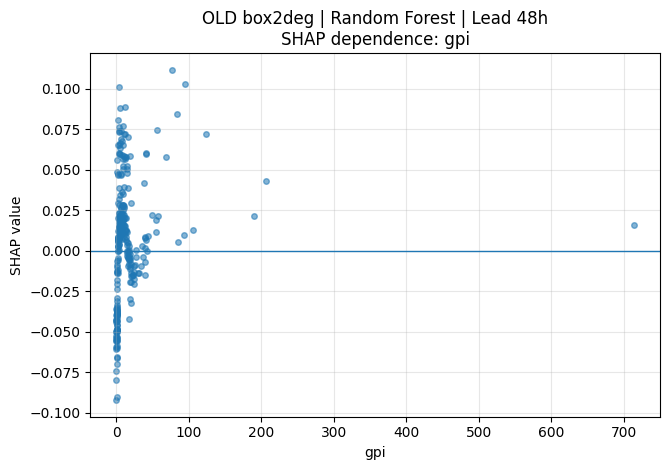

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_48h_dependence_gpi.png


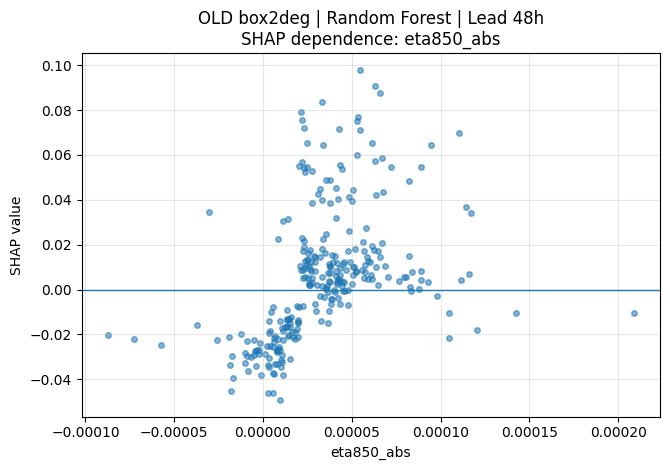

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_48h_dependence_eta850_abs.png


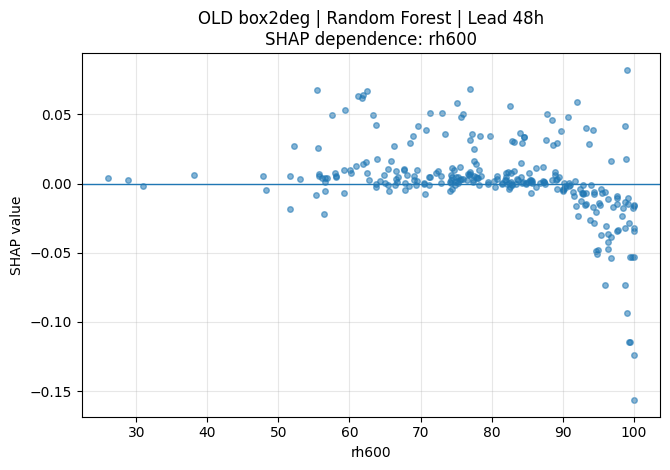

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Random_Forest\OLD_box2deg__Random_Forest__Lead_48h_dependence_rh600.png

SHAP ANALYSIS | MODEL: SVM

------------------------------------------------------------------------------------------
Lead 6h
------------------------------------------------------------------------------------------
Rows used: 565 | positive=125 | negative=440
Background sample: 80 | Explanation sample: 375 | Explanation positives=125


PermutationExplainer explainer: 376it [00:17,  8.98it/s]                         

Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
8,6,SVM,eta850_abs,0.078969,0.036699,1
9,6,SVM,rh600,0.045938,0.015520,2
1,6,SVM,lat,0.042249,0.010989,3
3,6,SVM,area_km2,0.040106,0.014683,4
4,6,SVM,tb_mean,0.038447,0.013052,5
11,6,SVM,pi_vmax_ms,0.037789,-0.007800,6
10,6,SVM,wshear_200_850,0.031680,-0.000993,7
12,6,SVM,gpi,0.026711,0.012088,8
5,6,SVM,tb_min,0.023650,-0.004750,9
0,6,SVM,lon,0.023182,0.004658,10


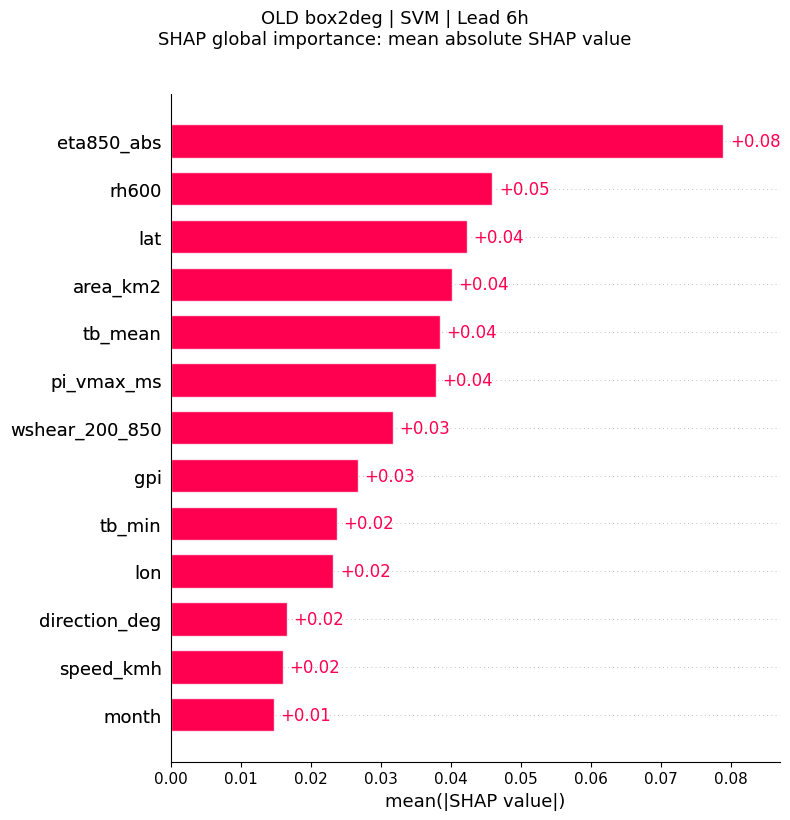

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\shap_bar_old_box2deg_SVM_6h.png


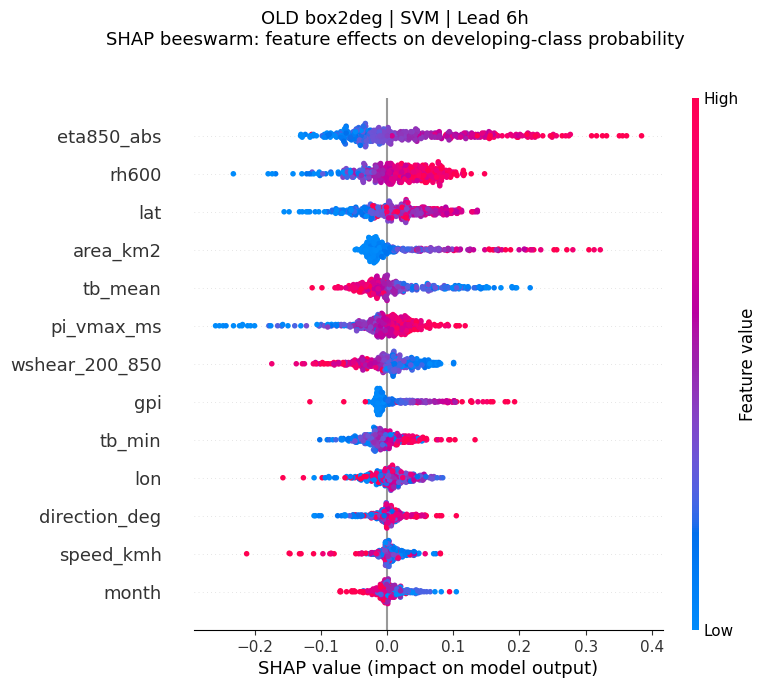

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\shap_beeswarm_old_box2deg_SVM_6h.png


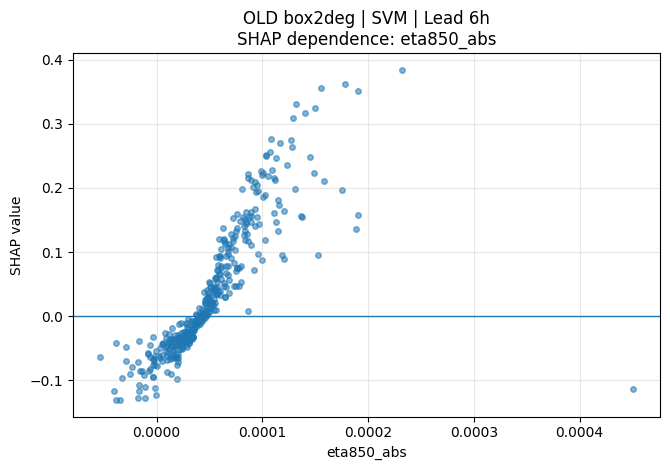

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_6h_dependence_eta850_abs.png


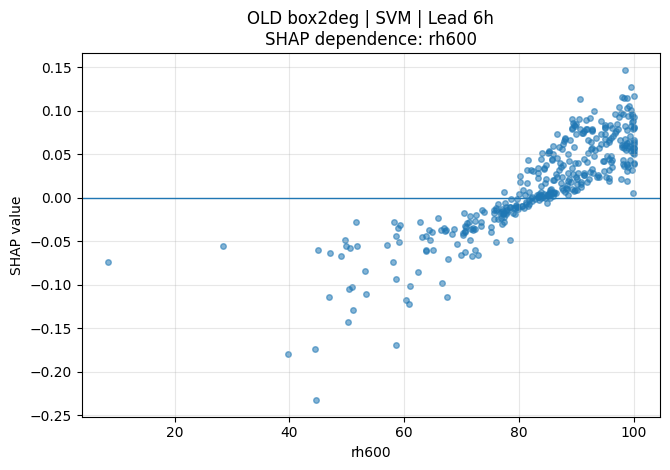

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_6h_dependence_rh600.png


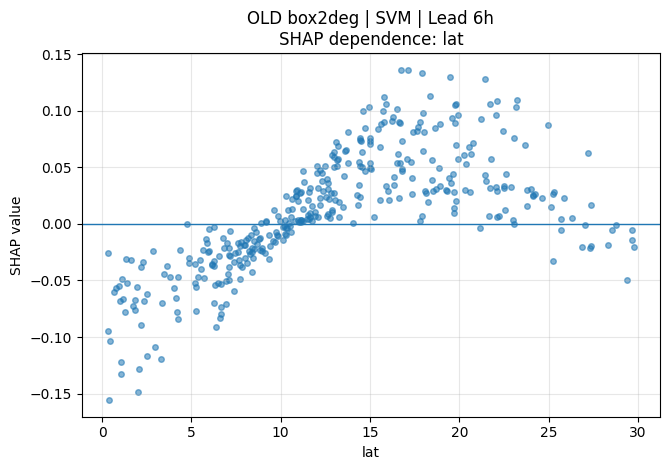

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_6h_dependence_lat.png


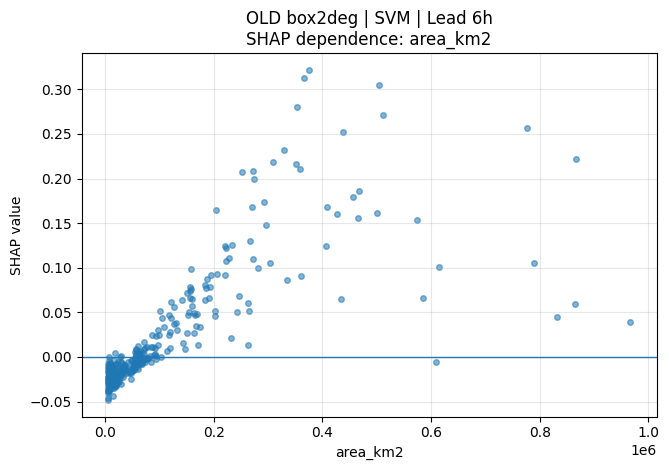

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_6h_dependence_area_km2.png


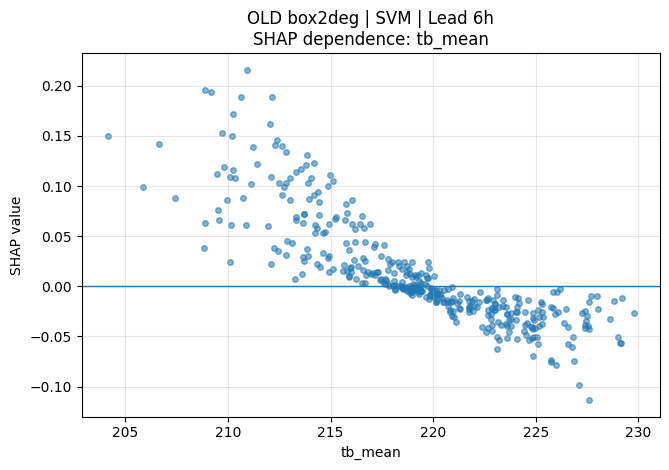

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_6h_dependence_tb_mean.png

------------------------------------------------------------------------------------------
Lead 12h
------------------------------------------------------------------------------------------
Rows used: 560 | positive=122 | negative=438
Background sample: 80 | Explanation sample: 372 | Explanation positives=122


PermutationExplainer explainer: 373it [00:17,  9.07it/s]                         

Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,12,SVM,lat,0.067976,0.008234,1
8,12,SVM,eta850_abs,0.064892,0.006748,2
7,12,SVM,direction_deg,0.037100,-0.003268,3
4,12,SVM,tb_mean,0.035282,-0.001901,4
10,12,SVM,wshear_200_850,0.033720,0.007733,5
3,12,SVM,area_km2,0.032622,-0.003568,6
11,12,SVM,pi_vmax_ms,0.031341,-0.000942,7
2,12,SVM,month,0.030788,0.002568,8
0,12,SVM,lon,0.027944,0.003675,9
9,12,SVM,rh600,0.024233,-0.001841,10


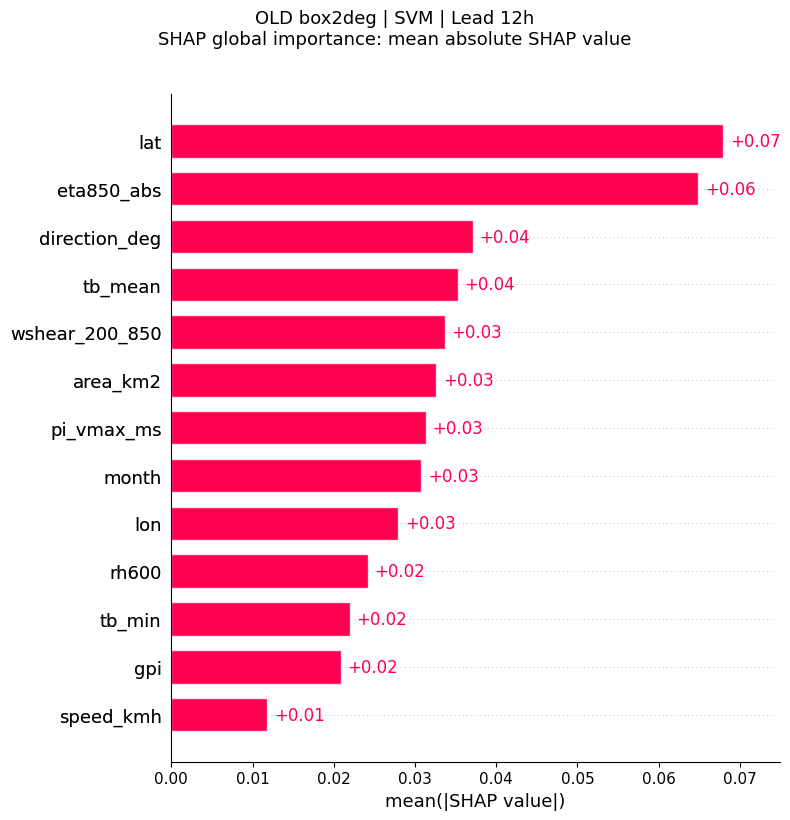

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\shap_bar_old_box2deg_SVM_12h.png


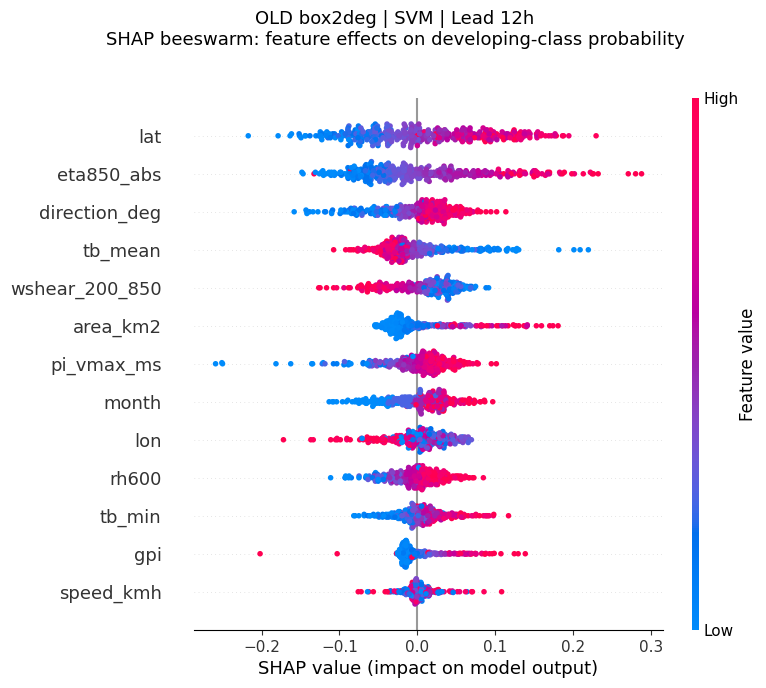

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\shap_beeswarm_old_box2deg_SVM_12h.png


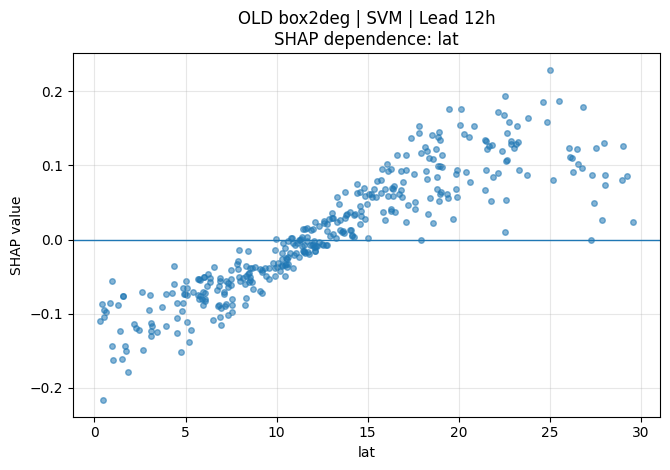

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_12h_dependence_lat.png


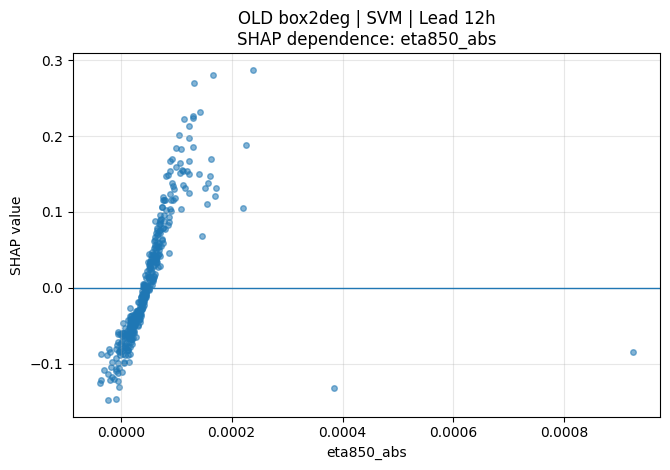

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_12h_dependence_eta850_abs.png


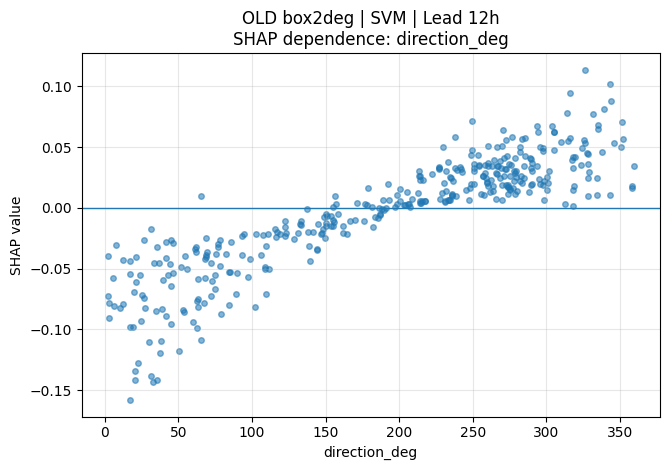

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_12h_dependence_direction_deg.png


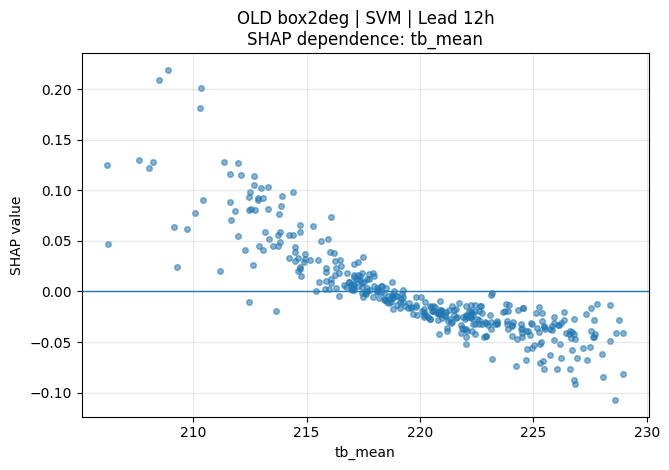

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_12h_dependence_tb_mean.png


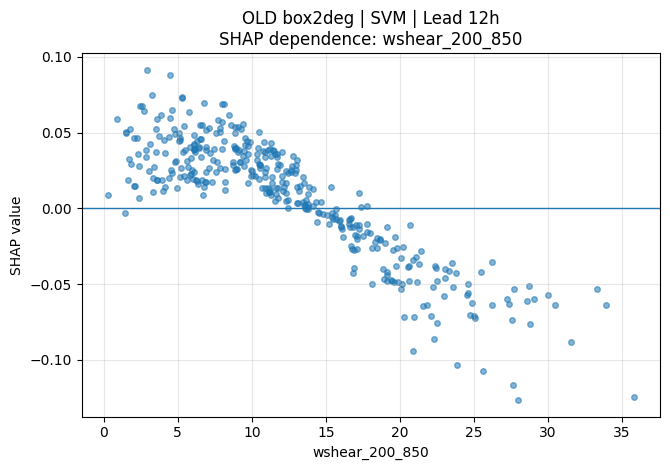

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_12h_dependence_wshear_200_850.png

------------------------------------------------------------------------------------------
Lead 24h
------------------------------------------------------------------------------------------
Rows used: 417 | positive=71 | negative=346
Background sample: 80 | Explanation sample: 321 | Explanation positives=71


PermutationExplainer explainer: 322it [00:13,  6.38it/s]                         

Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
8,24,SVM,eta850_abs,0.049264,0.015000,1
1,24,SVM,lat,0.041763,0.006789,2
11,24,SVM,pi_vmax_ms,0.030204,0.003495,3
0,24,SVM,lon,0.018930,0.004769,4
10,24,SVM,wshear_200_850,0.016181,0.003654,5
4,24,SVM,tb_mean,0.015671,0.000491,6
5,24,SVM,tb_min,0.015607,-0.000186,7
2,24,SVM,month,0.013864,0.001747,8
12,24,SVM,gpi,0.012851,0.005018,9
9,24,SVM,rh600,0.012576,0.002781,10


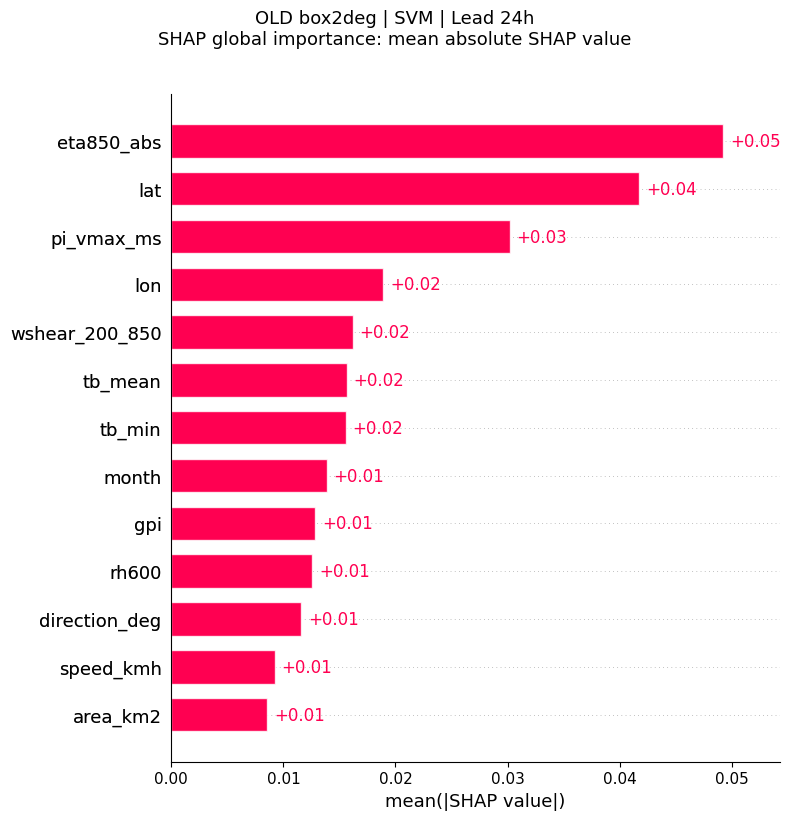

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\shap_bar_old_box2deg_SVM_24h.png


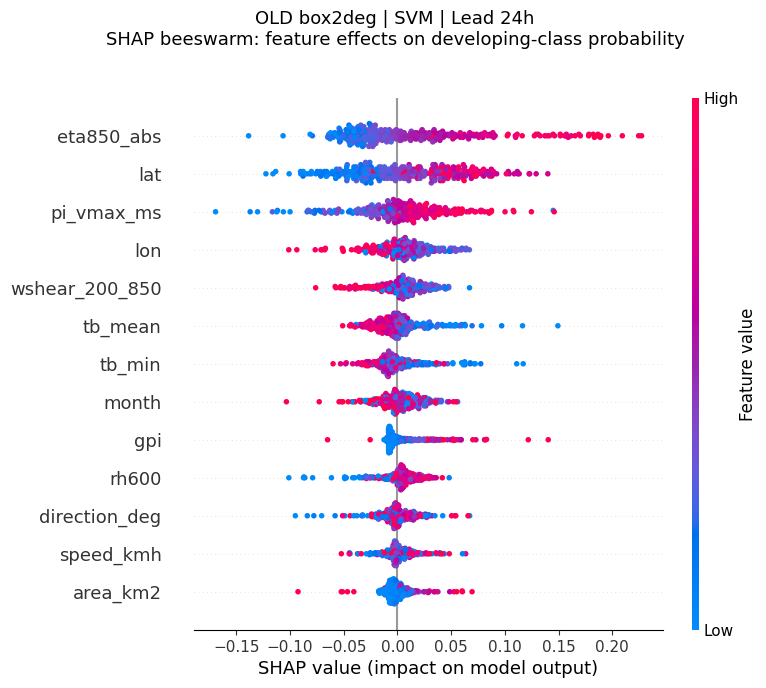

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\shap_beeswarm_old_box2deg_SVM_24h.png


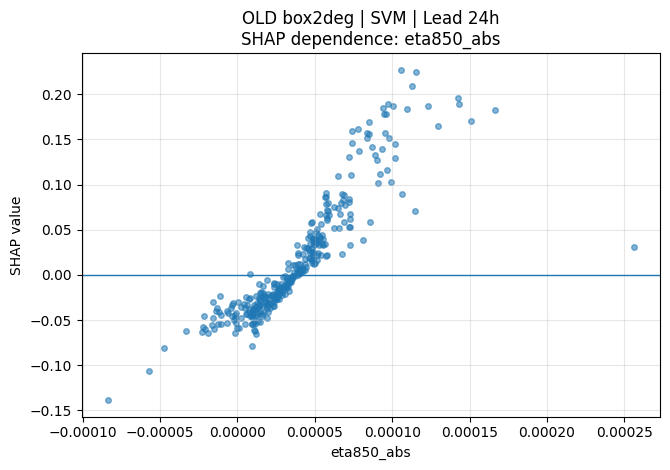

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_24h_dependence_eta850_abs.png


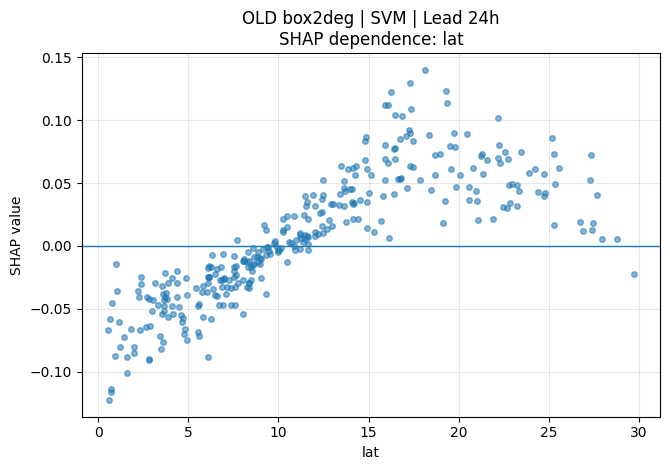

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_24h_dependence_lat.png


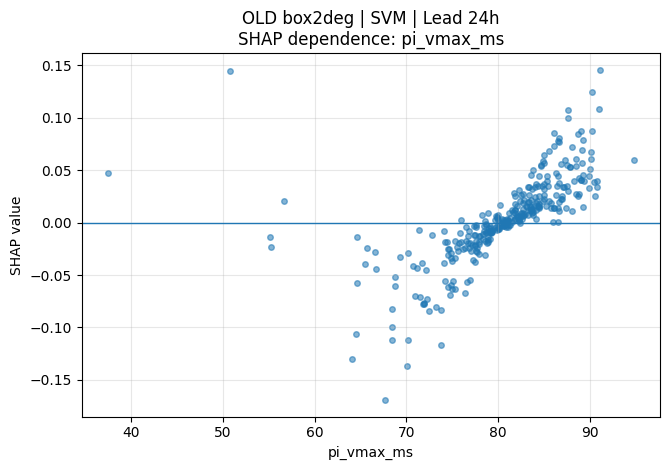

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_24h_dependence_pi_vmax_ms.png


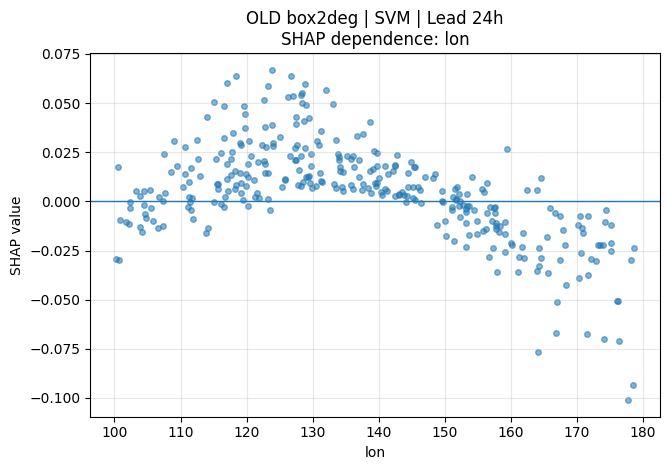

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_24h_dependence_lon.png


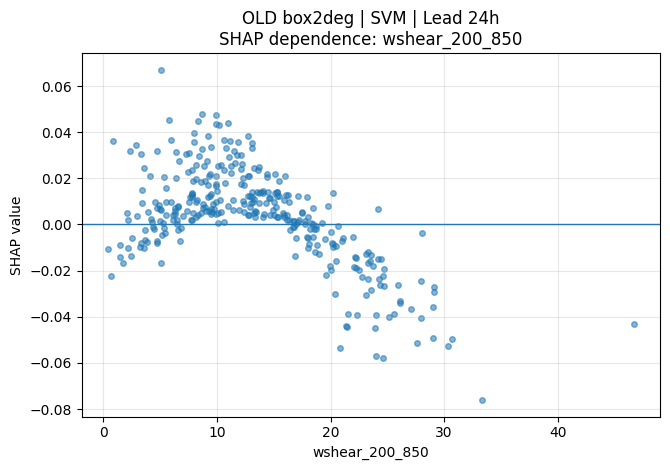

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_24h_dependence_wshear_200_850.png

------------------------------------------------------------------------------------------
Lead 48h
------------------------------------------------------------------------------------------
Rows used: 279 | positive=51 | negative=228
Background sample: 80 | Explanation sample: 279 | Explanation positives=51
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,48,SVM,lat,0.039838,0.005360,1
0,48,SVM,lon,0.017032,-0.003588,2
2,48,SVM,month,0.011378,0.001692,3
10,48,SVM,wshear_200_850,0.011082,0.000937,4
8,48,SVM,eta850_abs,0.011015,0.001473,5
9,48,SVM,rh600,0.009311,0.000670,6
11,48,SVM,pi_vmax_ms,0.006866,0.001542,7
3,48,SVM,area_km2,0.006531,0.000808,8
6,48,SVM,speed_kmh,0.006511,0.000813,9
7,48,SVM,direction_deg,0.006363,-0.000035,10


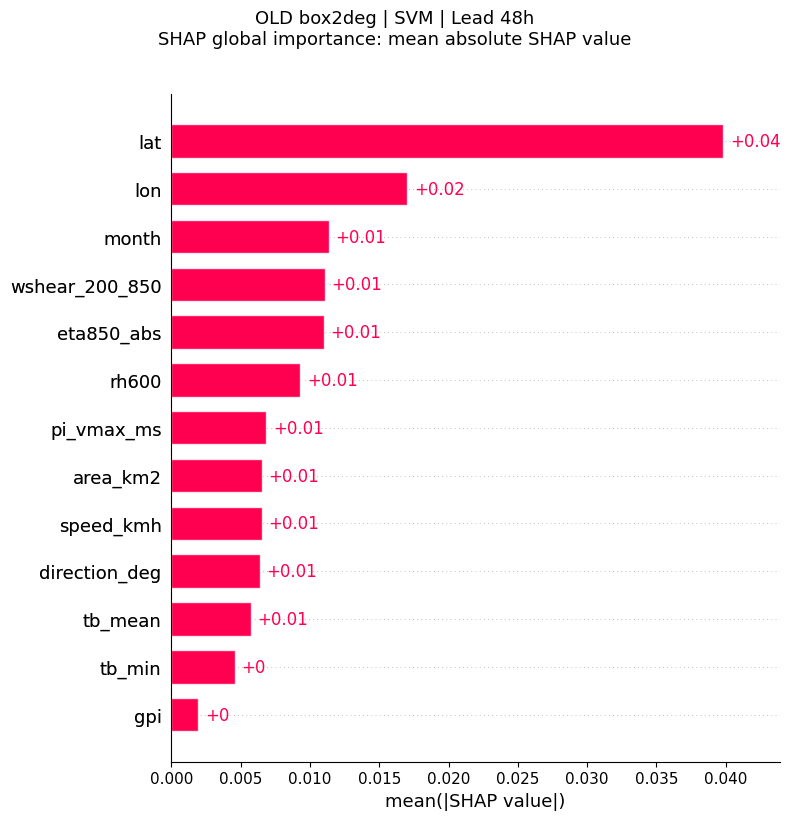

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\shap_bar_old_box2deg_SVM_48h.png


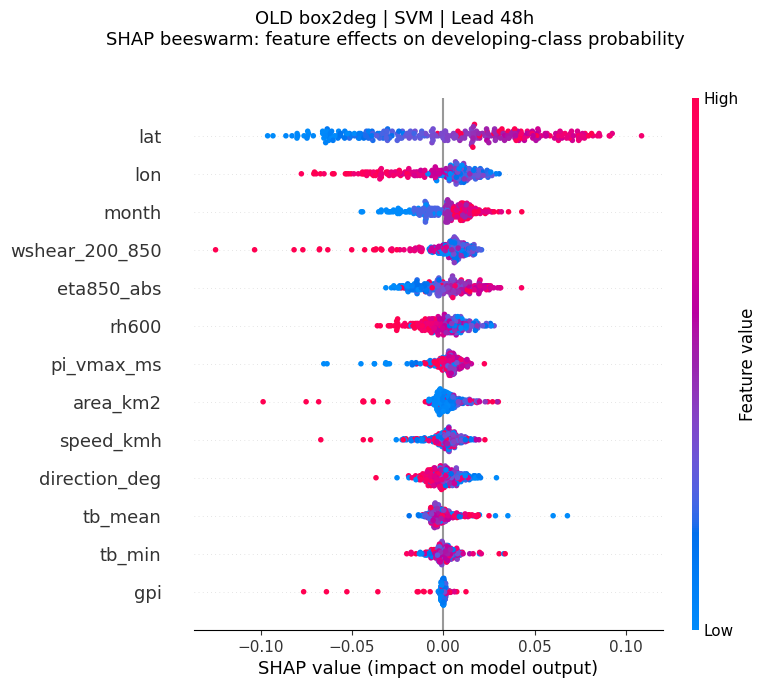

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\shap_beeswarm_old_box2deg_SVM_48h.png


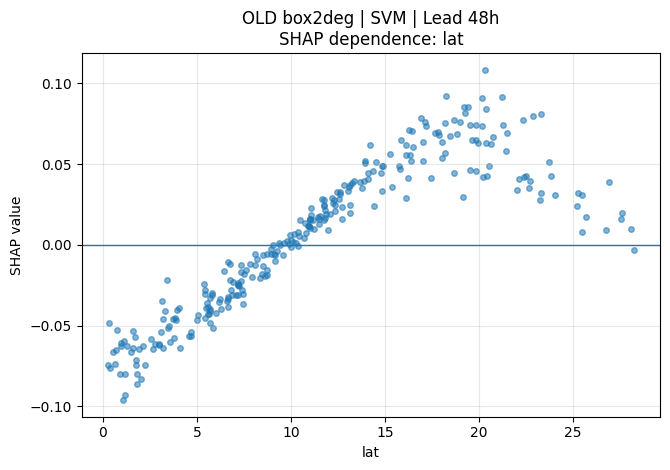

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_48h_dependence_lat.png


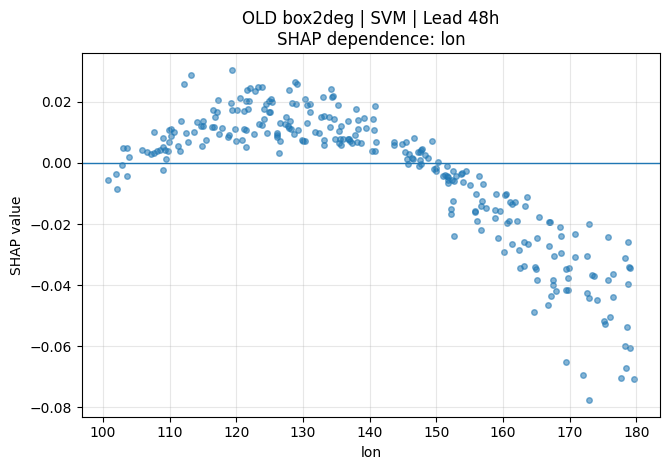

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_48h_dependence_lon.png


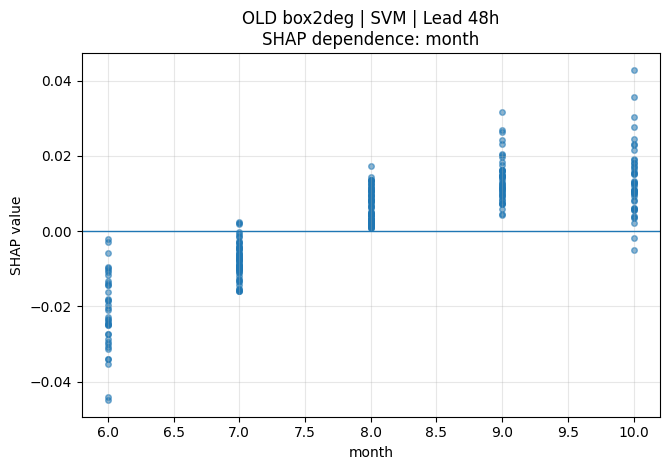

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_48h_dependence_month.png


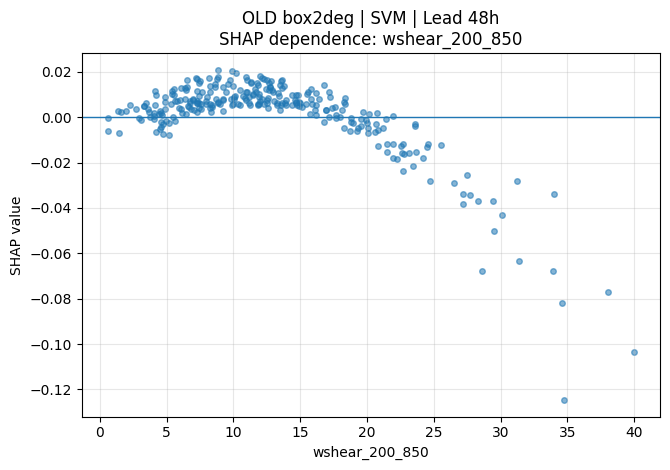

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_48h_dependence_wshear_200_850.png


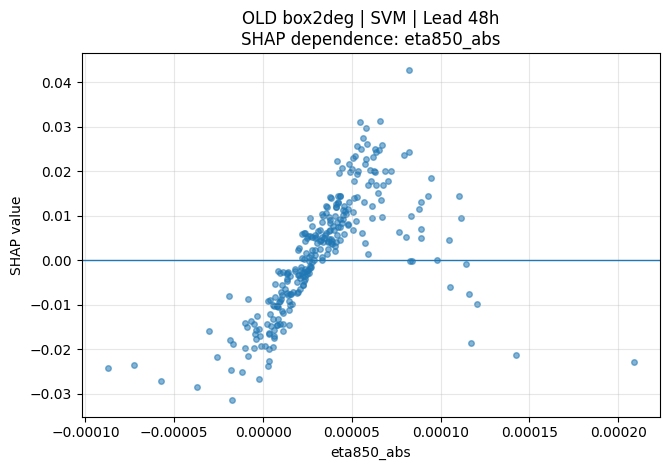

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\SVM\OLD_box2deg__SVM__Lead_48h_dependence_eta850_abs.png

SHAP ANALYSIS | MODEL: Logistic Regression

------------------------------------------------------------------------------------------
Lead 6h
------------------------------------------------------------------------------------------
Rows used: 565 | positive=125 | negative=440
Background sample: 80 | Explanation sample: 375 | Explanation positives=125
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
8,6,Logistic Regression,eta850_abs,0.108607,0.047548,1
11,6,Logistic Regression,pi_vmax_ms,0.101302,-0.002948,2
9,6,Logistic Regression,rh600,0.092705,0.027726,3
4,6,Logistic Regression,tb_mean,0.085234,0.024844,4
1,6,Logistic Regression,lat,0.081554,0.014867,5
5,6,Logistic Regression,tb_min,0.075761,-0.025614,6
10,6,Logistic Regression,wshear_200_850,0.055605,-0.009195,7
3,6,Logistic Regression,area_km2,0.051683,0.017838,8
12,6,Logistic Regression,gpi,0.020377,-0.005702,9
7,6,Logistic Regression,direction_deg,0.011162,0.000121,10


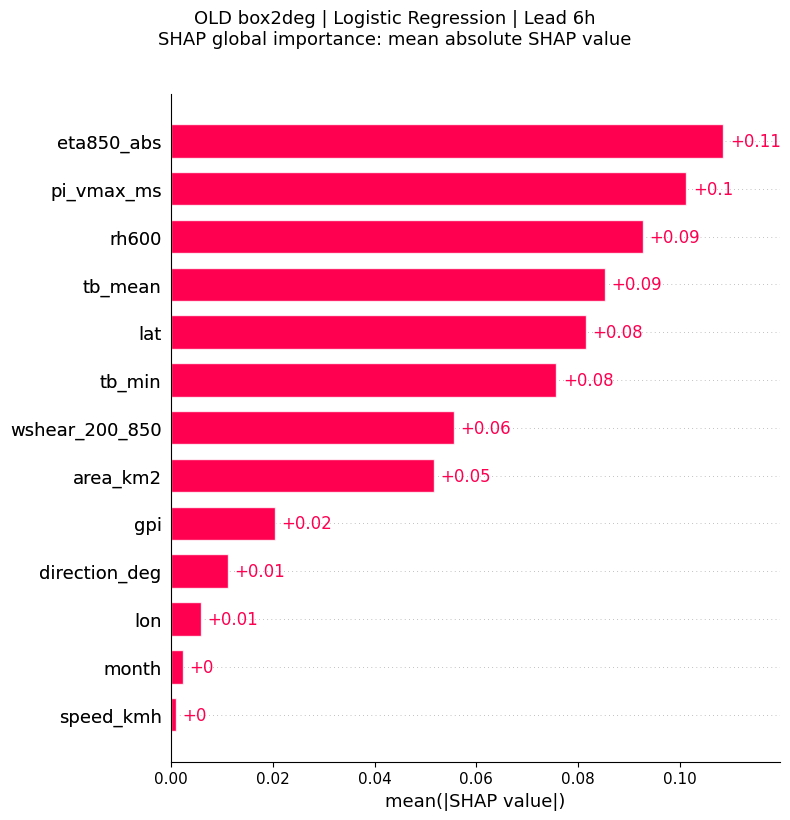

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\shap_bar_old_box2deg_Logistic_Regression_6h.png


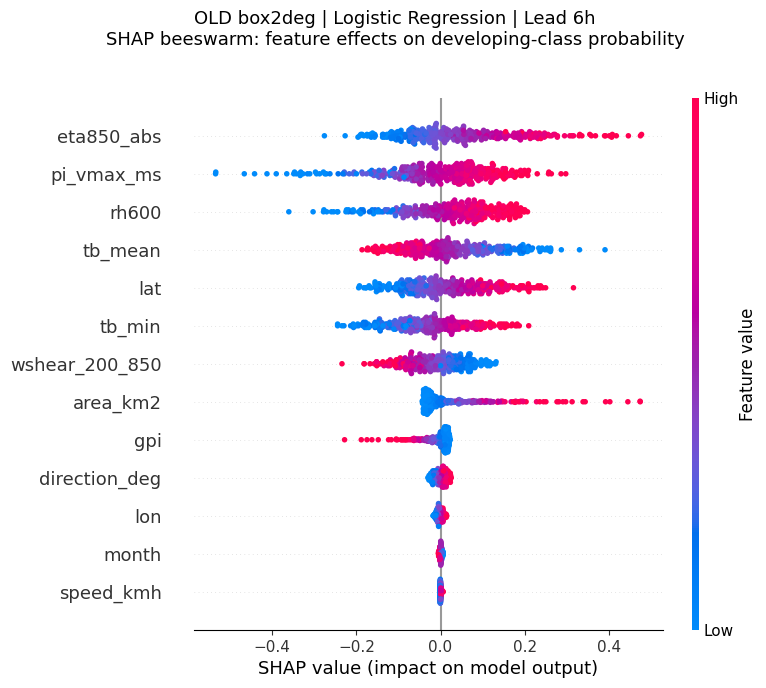

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\shap_beeswarm_old_box2deg_Logistic_Regression_6h.png


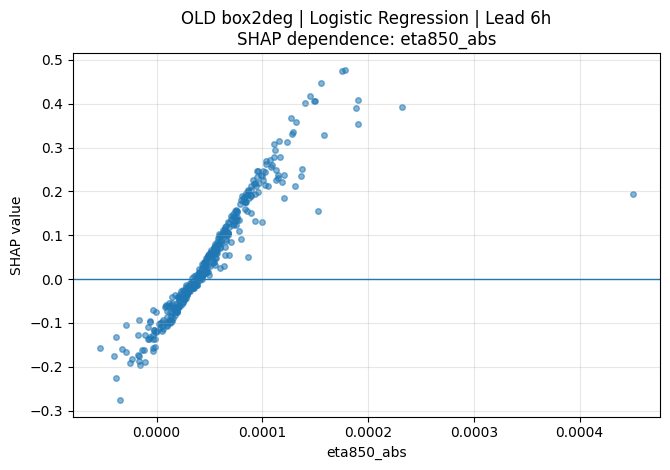

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_6h_dependence_eta850_abs.png


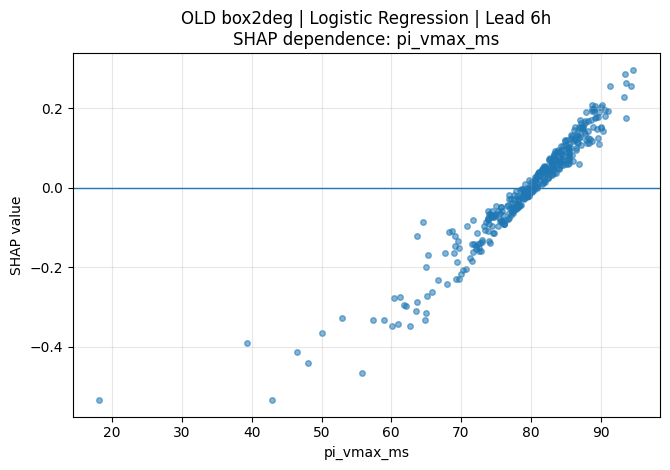

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_6h_dependence_pi_vmax_ms.png


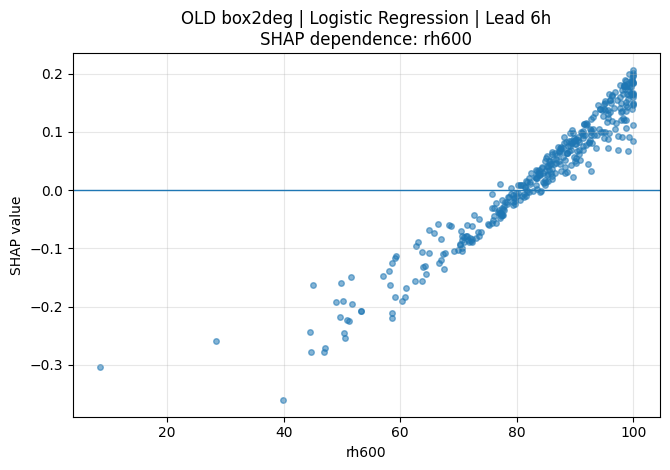

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_6h_dependence_rh600.png


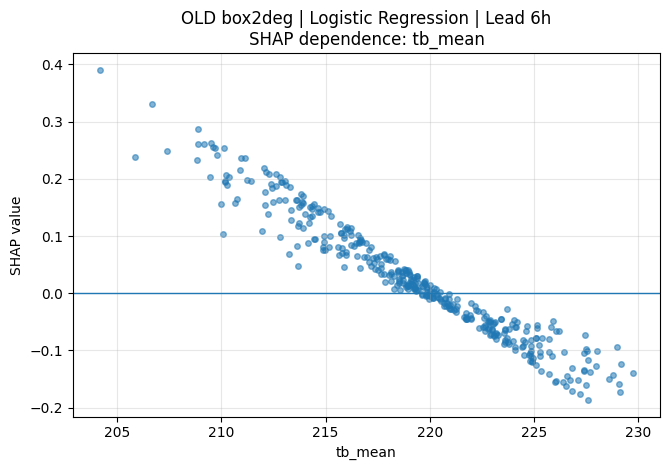

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_6h_dependence_tb_mean.png


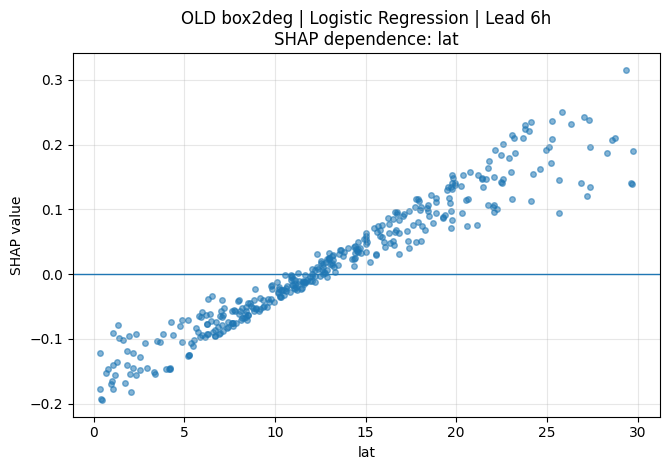

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_6h_dependence_lat.png

------------------------------------------------------------------------------------------
Lead 12h
------------------------------------------------------------------------------------------
Rows used: 560 | positive=122 | negative=438
Background sample: 80 | Explanation sample: 372 | Explanation positives=122
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,12,Logistic Regression,lat,0.146146,0.025496,1
10,12,Logistic Regression,wshear_200_850,0.086946,0.014437,2
8,12,Logistic Regression,eta850_abs,0.070639,0.005774,3
4,12,Logistic Regression,tb_mean,0.070108,-0.007793,4
11,12,Logistic Regression,pi_vmax_ms,0.068766,-0.009120,5
5,12,Logistic Regression,tb_min,0.046044,0.005580,6
9,12,Logistic Regression,rh600,0.043654,-0.004498,7
3,12,Logistic Regression,area_km2,0.042732,-0.010604,8
2,12,Logistic Regression,month,0.033467,-0.001559,9
7,12,Logistic Regression,direction_deg,0.032481,-0.003005,10


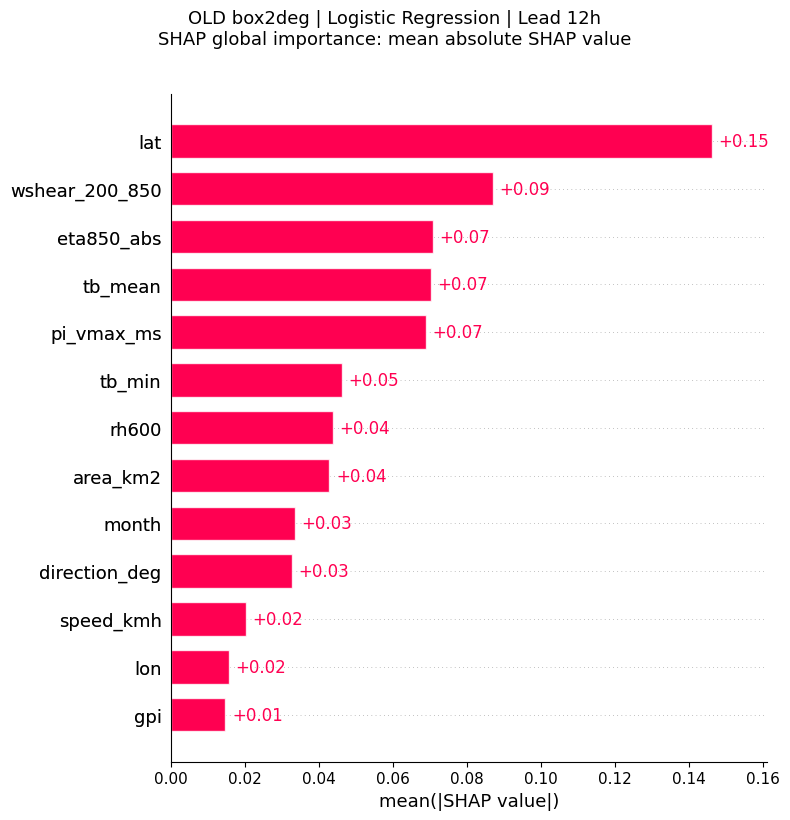

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\shap_bar_old_box2deg_Logistic_Regression_12h.png


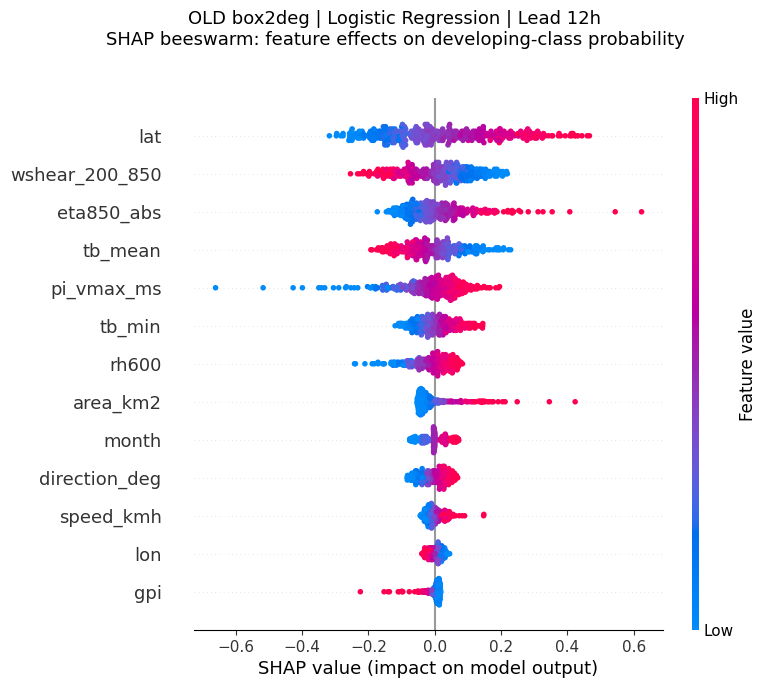

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\shap_beeswarm_old_box2deg_Logistic_Regression_12h.png


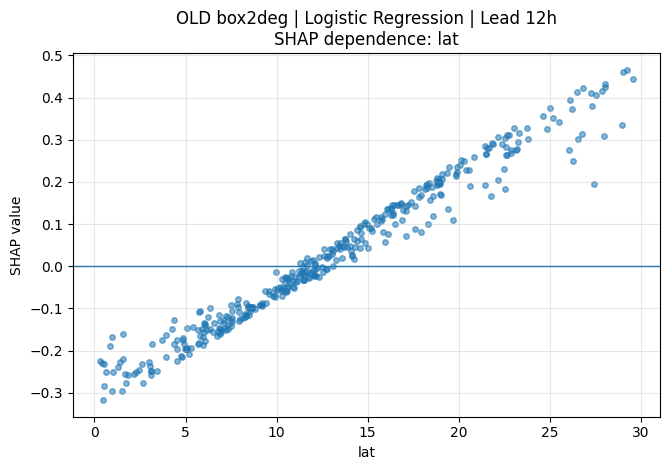

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_12h_dependence_lat.png


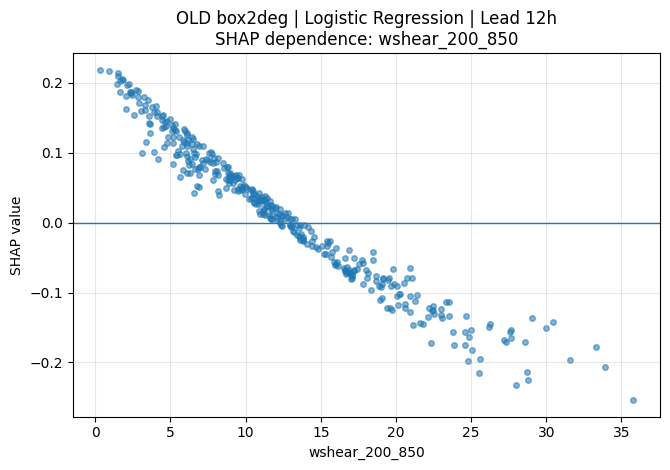

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_12h_dependence_wshear_200_850.png


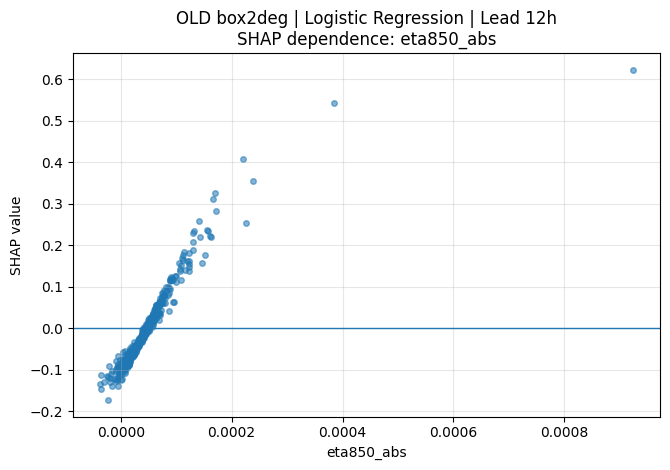

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_12h_dependence_eta850_abs.png


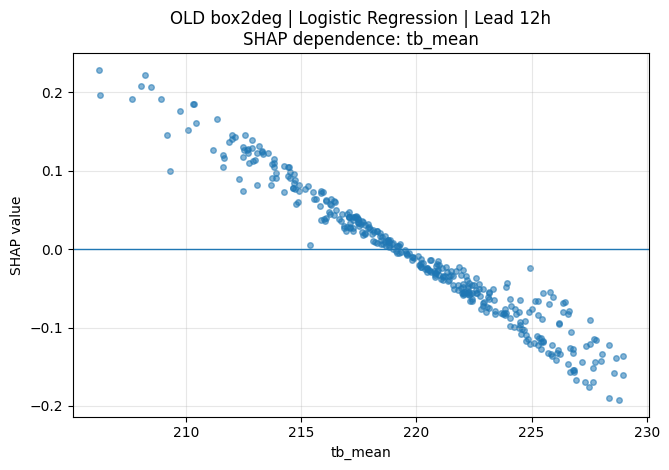

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_12h_dependence_tb_mean.png


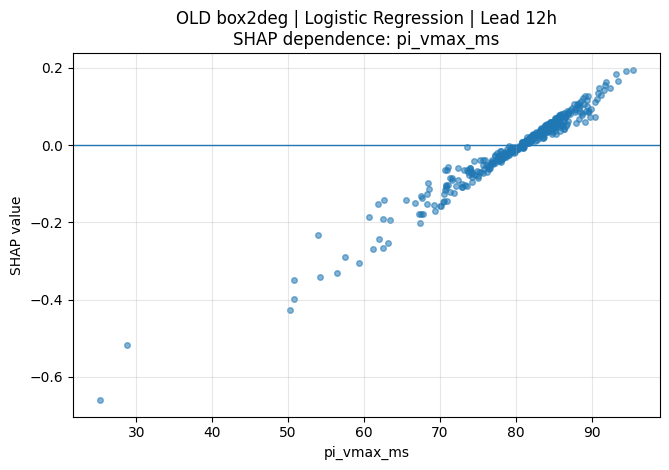

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_12h_dependence_pi_vmax_ms.png

------------------------------------------------------------------------------------------
Lead 24h
------------------------------------------------------------------------------------------
Rows used: 417 | positive=71 | negative=346
Background sample: 80 | Explanation sample: 321 | Explanation positives=71
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,24,Logistic Regression,lat,0.108415,0.012005,1
8,24,Logistic Regression,eta850_abs,0.086830,0.021702,2
11,24,Logistic Regression,pi_vmax_ms,0.066749,0.002794,3
5,24,Logistic Regression,tb_min,0.044572,-0.003623,4
10,24,Logistic Regression,wshear_200_850,0.035176,0.004530,5
9,24,Logistic Regression,rh600,0.024761,0.000871,6
0,24,Logistic Regression,lon,0.024709,0.003812,7
4,24,Logistic Regression,tb_mean,0.023470,-0.001201,8
2,24,Logistic Regression,month,0.021063,-0.000059,9
12,24,Logistic Regression,gpi,0.020026,0.007444,10


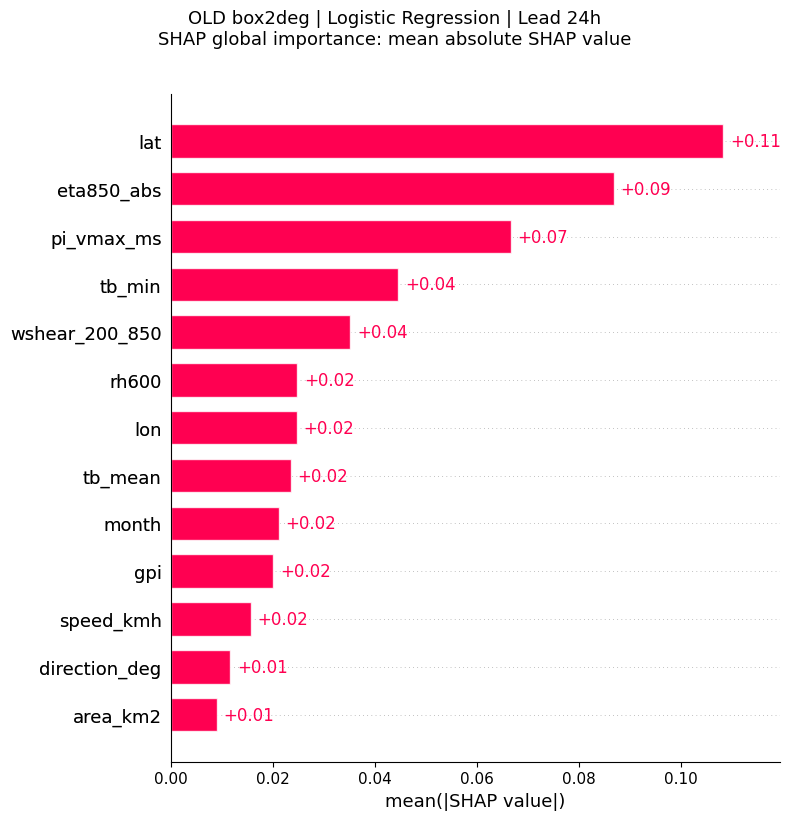

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\shap_bar_old_box2deg_Logistic_Regression_24h.png


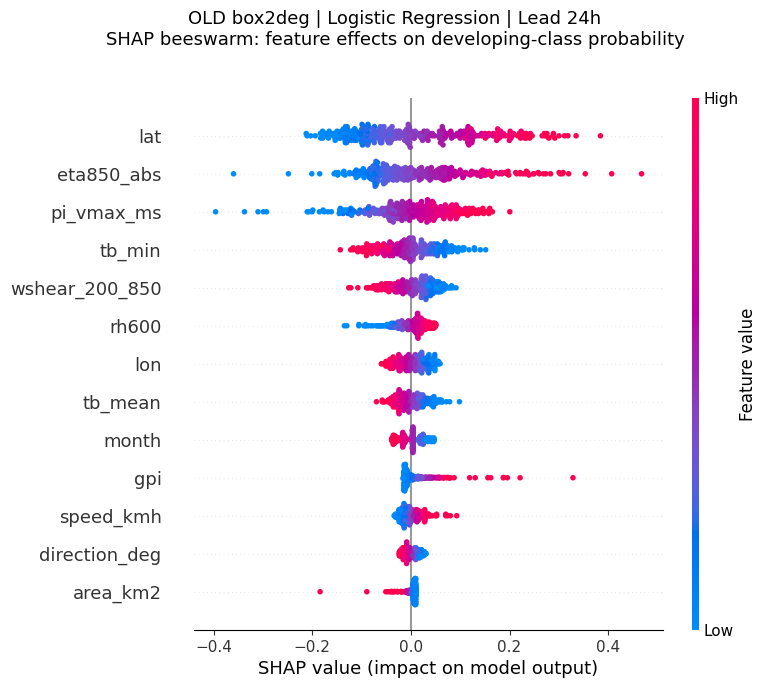

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\shap_beeswarm_old_box2deg_Logistic_Regression_24h.png


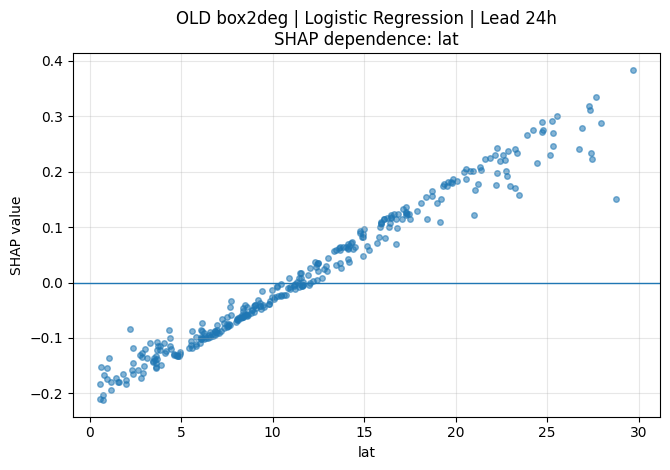

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_24h_dependence_lat.png


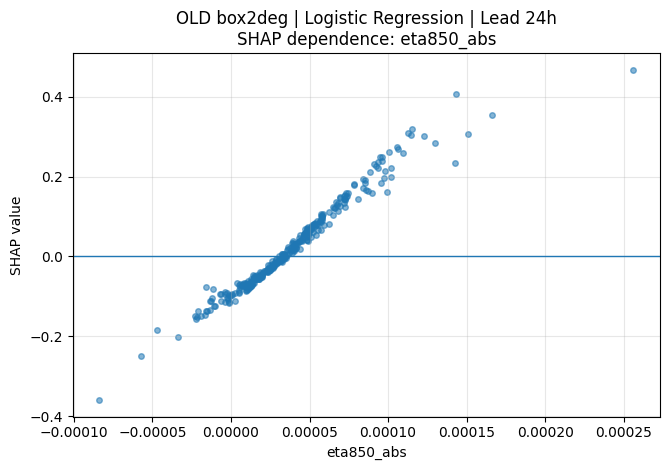

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_24h_dependence_eta850_abs.png


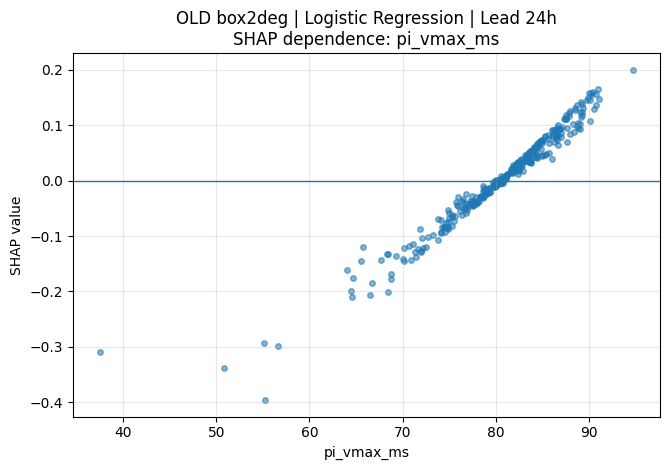

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_24h_dependence_pi_vmax_ms.png


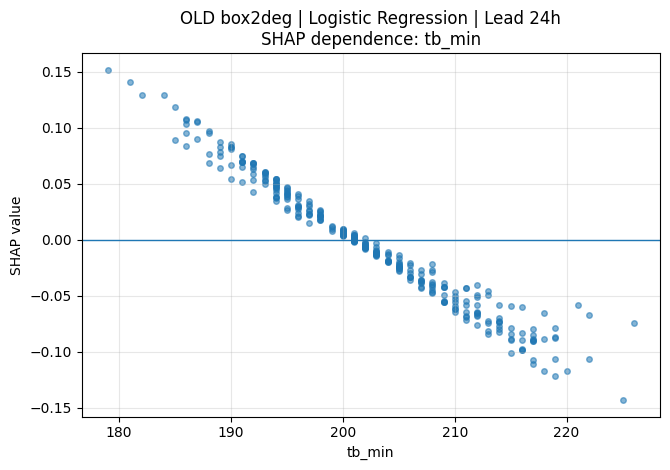

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_24h_dependence_tb_min.png


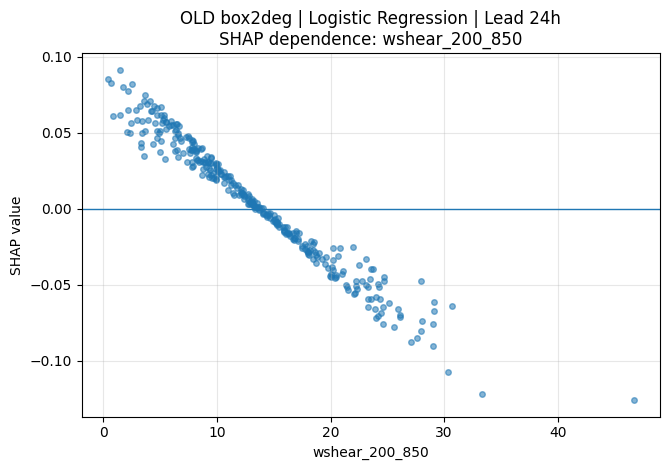

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_24h_dependence_wshear_200_850.png

------------------------------------------------------------------------------------------
Lead 48h
------------------------------------------------------------------------------------------
Rows used: 279 | positive=51 | negative=228
Background sample: 80 | Explanation sample: 279 | Explanation positives=51
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,48,Logistic Regression,lat,0.155814,0.013480,1
0,48,Logistic Regression,lon,0.079338,-0.021360,2
11,48,Logistic Regression,pi_vmax_ms,0.053489,0.008770,3
8,48,Logistic Regression,eta850_abs,0.050642,0.001620,4
10,48,Logistic Regression,wshear_200_850,0.042873,0.000752,5
5,48,Logistic Regression,tb_min,0.032420,-0.007219,6
12,48,Logistic Regression,gpi,0.028304,-0.005843,7
3,48,Logistic Regression,area_km2,0.020044,0.002570,8
2,48,Logistic Regression,month,0.018300,0.001107,9
7,48,Logistic Regression,direction_deg,0.014412,-0.000526,10


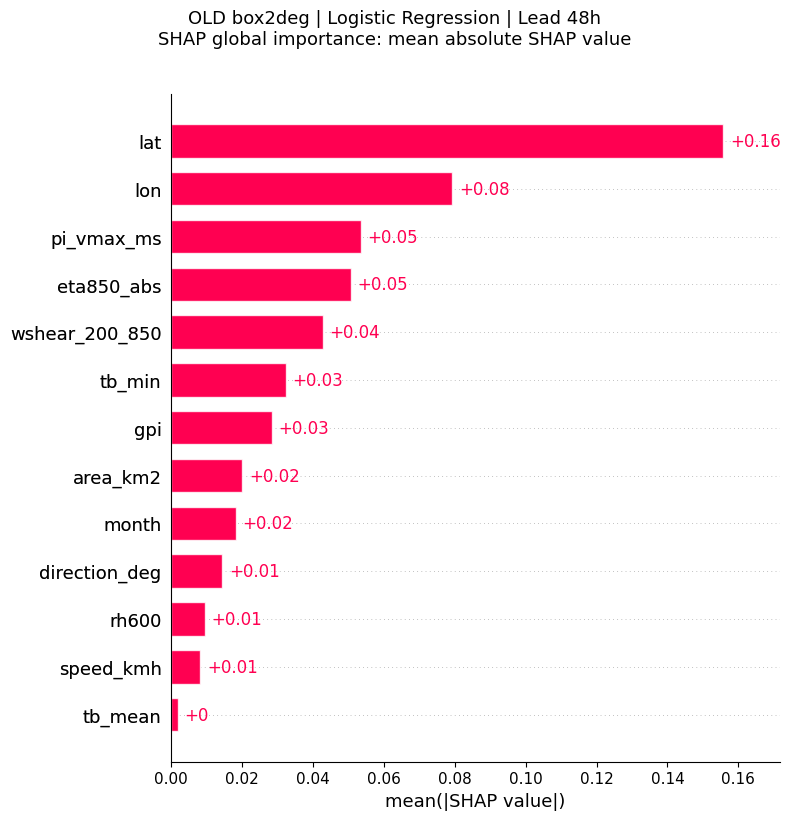

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\shap_bar_old_box2deg_Logistic_Regression_48h.png


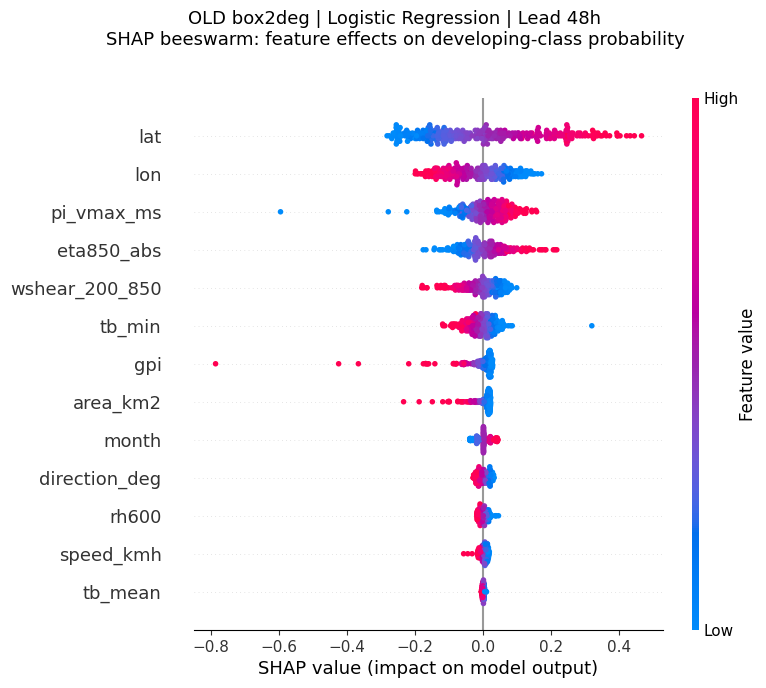

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\shap_beeswarm_old_box2deg_Logistic_Regression_48h.png


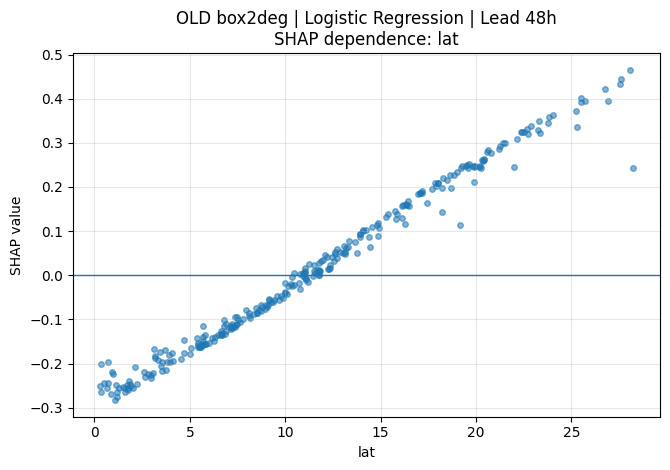

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_48h_dependence_lat.png


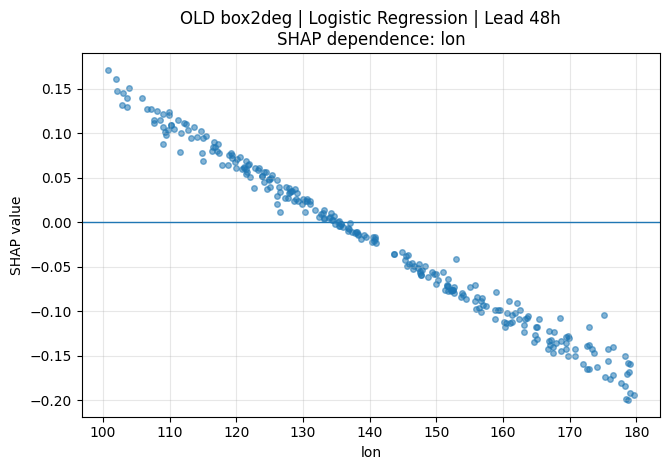

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_48h_dependence_lon.png


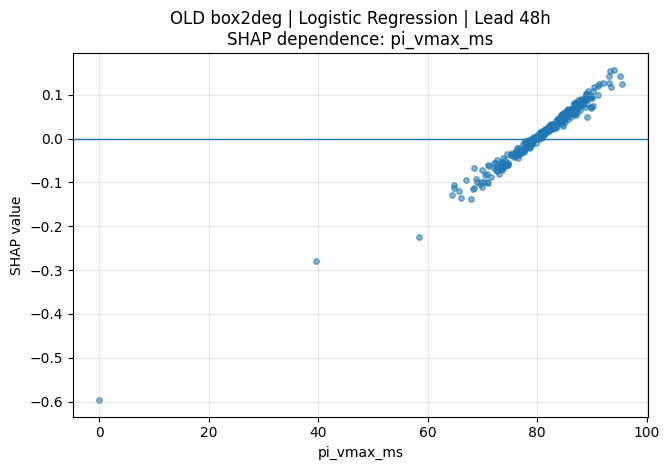

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_48h_dependence_pi_vmax_ms.png


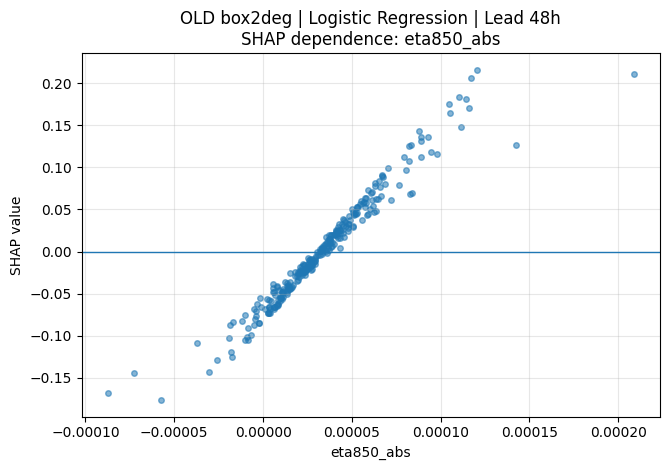

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_48h_dependence_eta850_abs.png


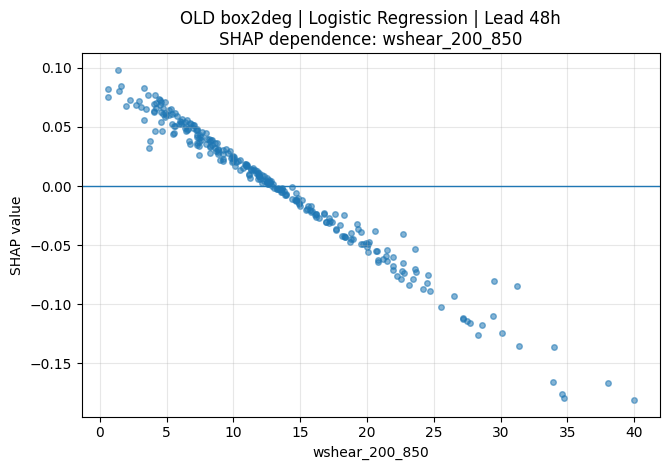

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Logistic_Regression\OLD_box2deg__Logistic_Regression__Lead_48h_dependence_wshear_200_850.png

SHAP ANALYSIS | MODEL: MLP

------------------------------------------------------------------------------------------
Lead 6h
------------------------------------------------------------------------------------------
Rows used: 565 | positive=125 | negative=440
Background sample: 80 | Explanation sample: 375 | Explanation positives=125
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
3,6,MLP,area_km2,0.074072,0.021787,1
8,6,MLP,eta850_abs,0.066813,0.034960,2
5,6,MLP,tb_min,0.065985,-0.021847,3
4,6,MLP,tb_mean,0.063070,0.018641,4
1,6,MLP,lat,0.061300,0.009949,5
12,6,MLP,gpi,0.057181,0.026432,6
10,6,MLP,wshear_200_850,0.054133,0.004148,7
0,6,MLP,lon,0.048128,0.011802,8
11,6,MLP,pi_vmax_ms,0.045166,-0.007474,9
9,6,MLP,rh600,0.043594,0.011236,10


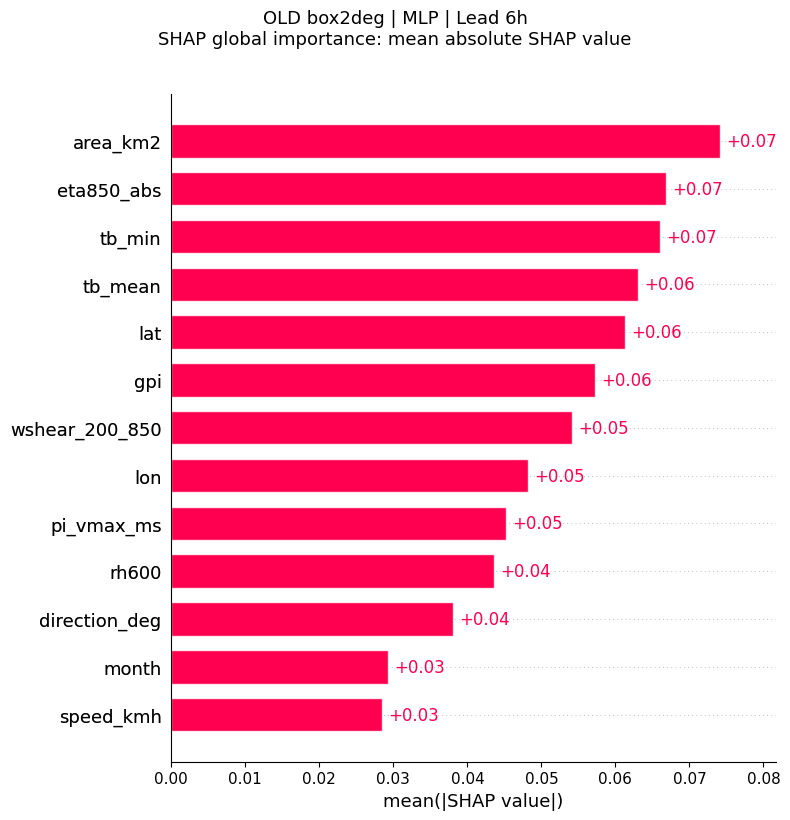

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\shap_bar_old_box2deg_MLP_6h.png


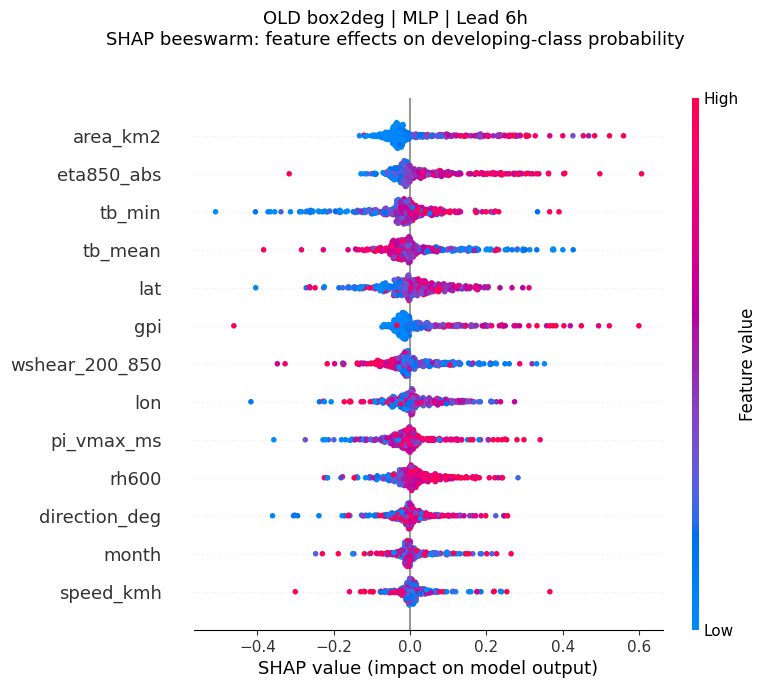

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\shap_beeswarm_old_box2deg_MLP_6h.png


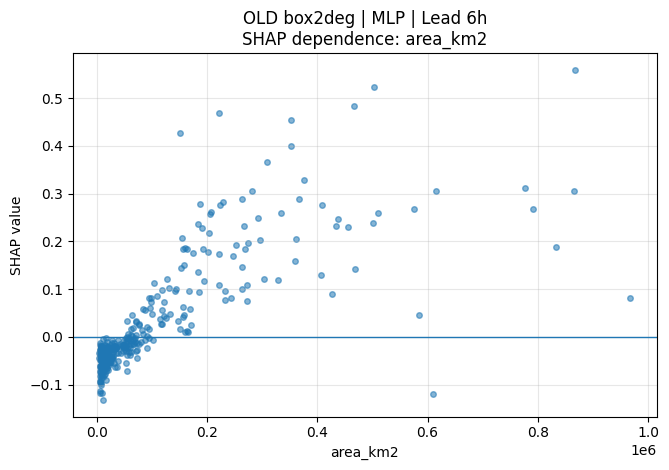

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_6h_dependence_area_km2.png


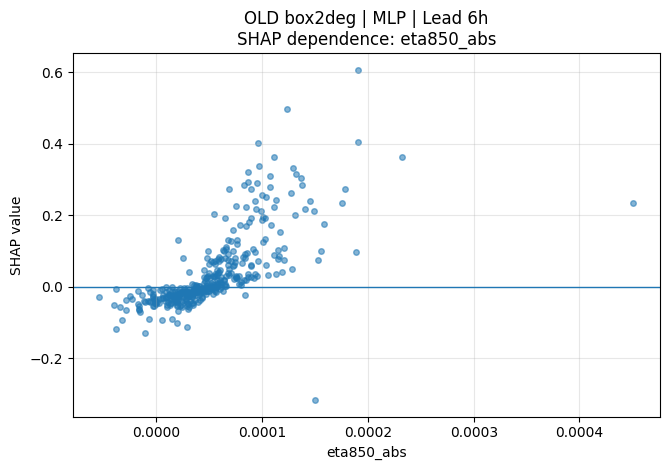

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_6h_dependence_eta850_abs.png


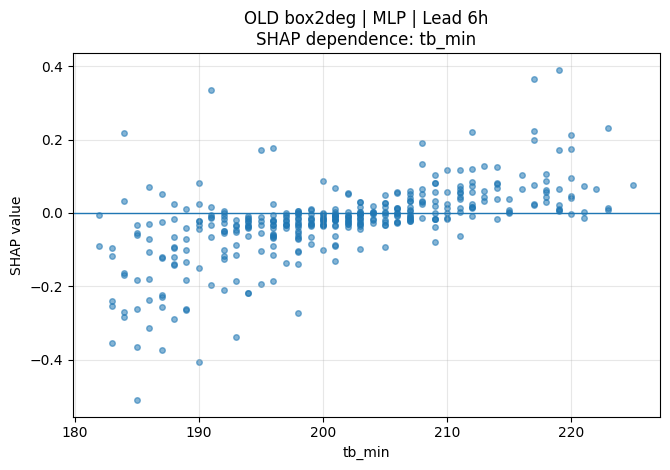

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_6h_dependence_tb_min.png


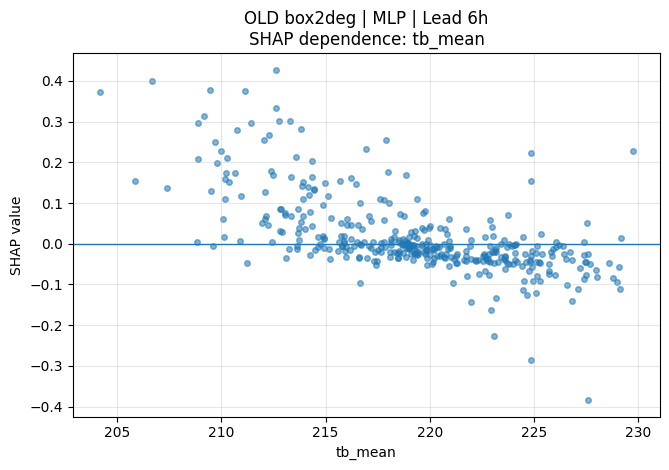

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_6h_dependence_tb_mean.png


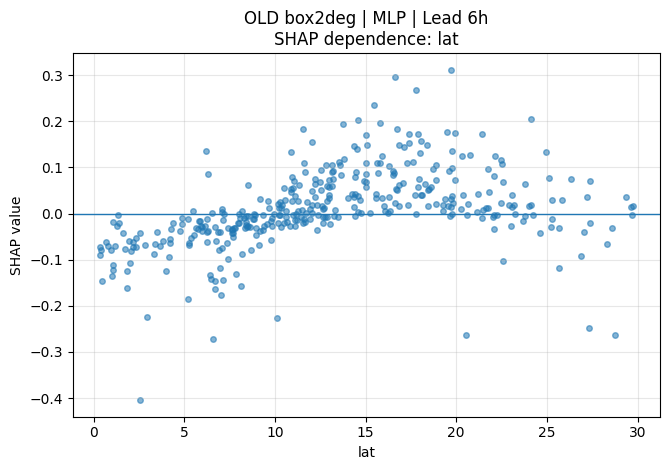

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_6h_dependence_lat.png

------------------------------------------------------------------------------------------
Lead 12h
------------------------------------------------------------------------------------------
Rows used: 560 | positive=122 | negative=438
Background sample: 80 | Explanation sample: 372 | Explanation positives=122
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
8,12,MLP,eta850_abs,0.092146,0.005281,1
1,12,MLP,lat,0.073205,0.007044,2
0,12,MLP,lon,0.064687,0.003843,3
4,12,MLP,tb_mean,0.056571,-0.000711,4
10,12,MLP,wshear_200_850,0.055124,0.012852,5
3,12,MLP,area_km2,0.054448,-0.002304,6
11,12,MLP,pi_vmax_ms,0.054183,-0.000722,7
7,12,MLP,direction_deg,0.052851,-0.011201,8
2,12,MLP,month,0.049829,0.009022,9
5,12,MLP,tb_min,0.048385,0.016714,10


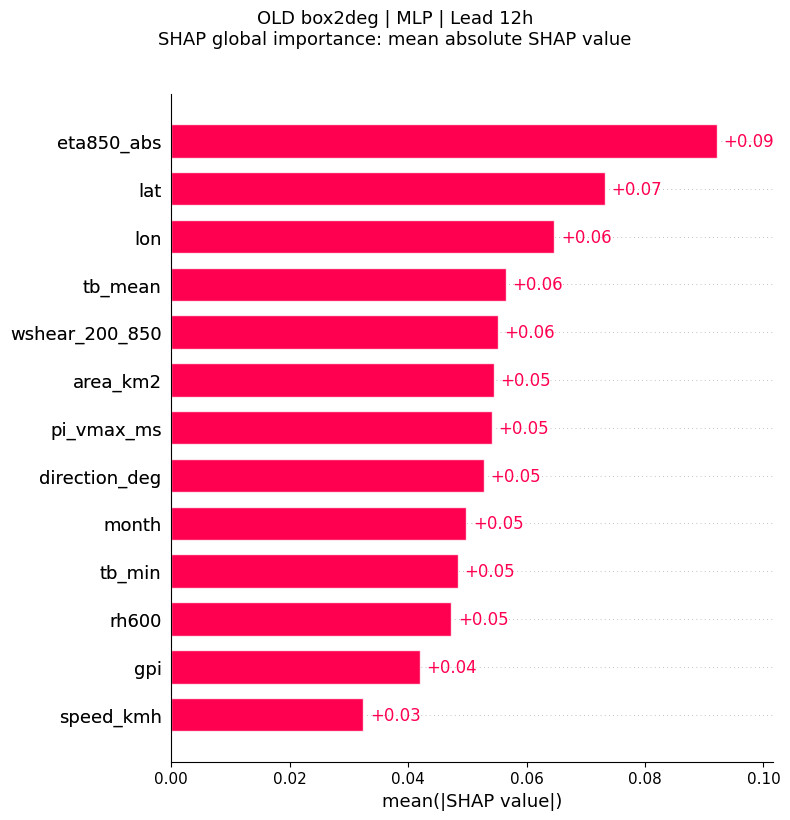

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\shap_bar_old_box2deg_MLP_12h.png


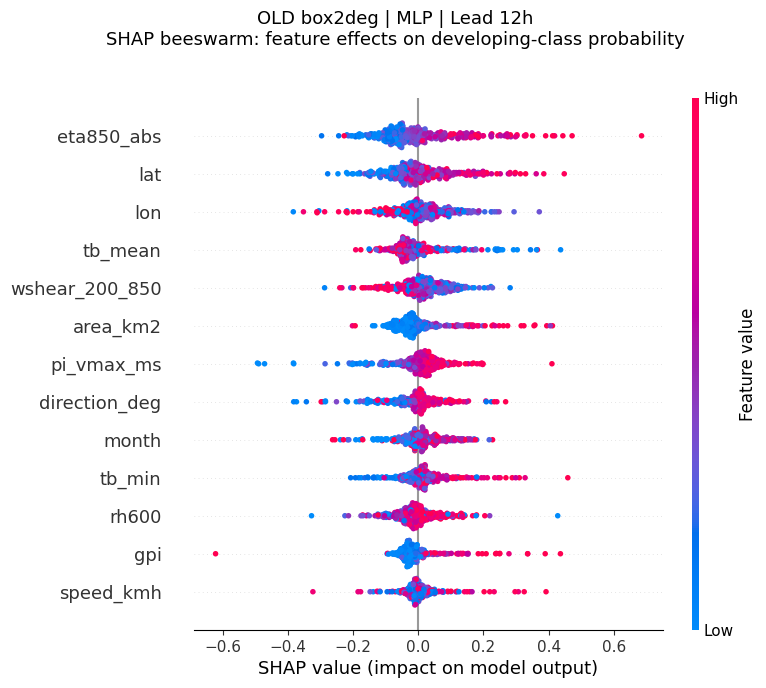

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\shap_beeswarm_old_box2deg_MLP_12h.png


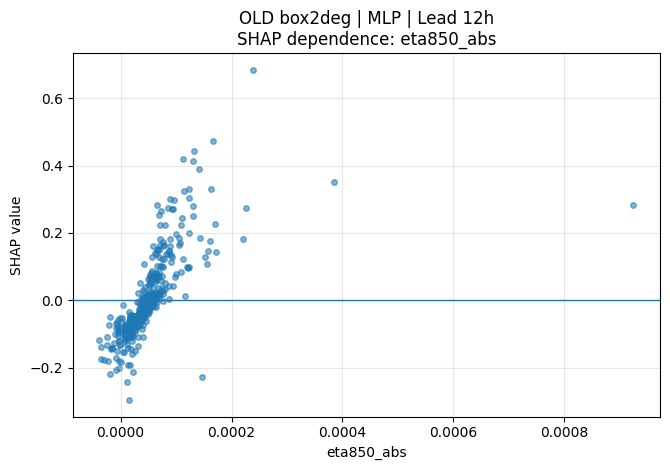

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_12h_dependence_eta850_abs.png


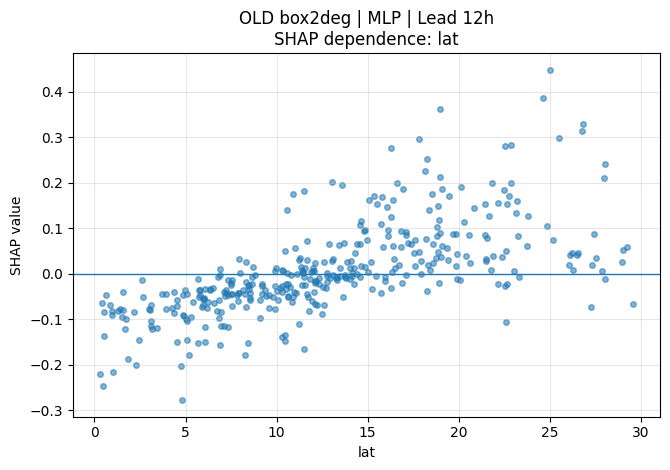

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_12h_dependence_lat.png


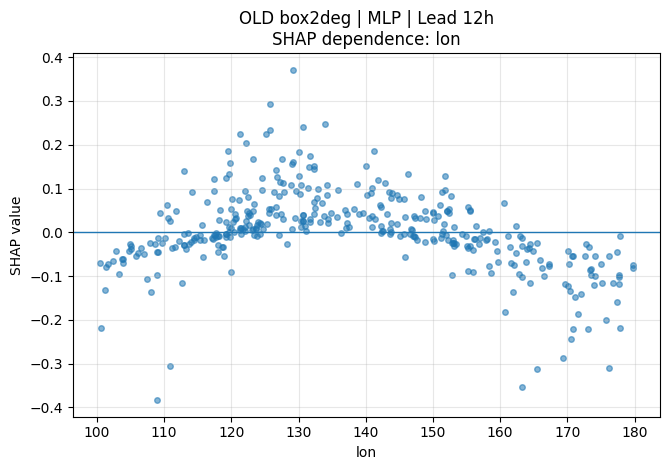

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_12h_dependence_lon.png


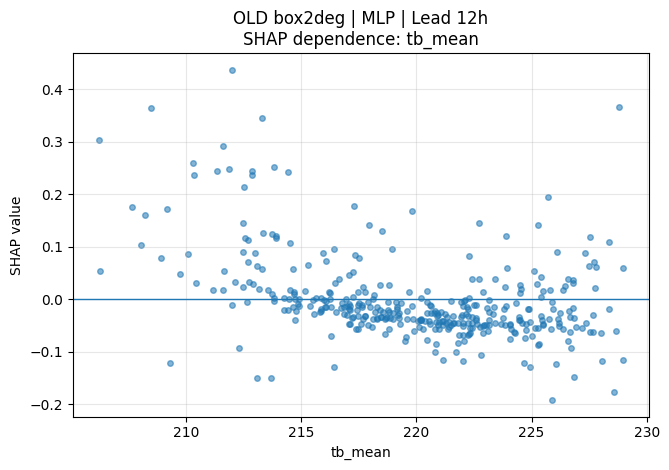

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_12h_dependence_tb_mean.png


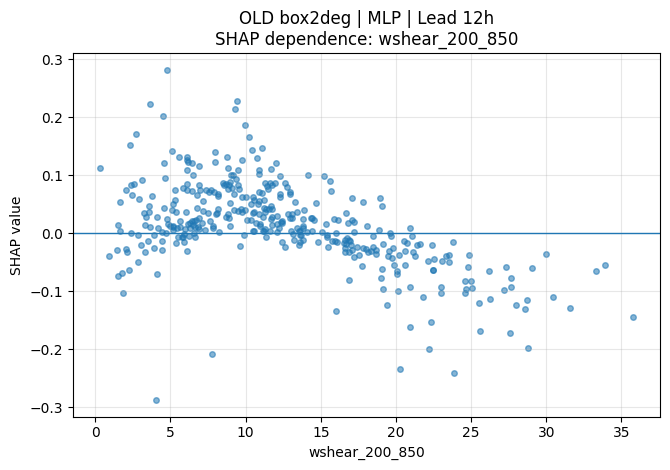

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_12h_dependence_wshear_200_850.png

------------------------------------------------------------------------------------------
Lead 24h
------------------------------------------------------------------------------------------
Rows used: 417 | positive=71 | negative=346
Background sample: 80 | Explanation sample: 321 | Explanation positives=71
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
8,24,MLP,eta850_abs,0.063786,0.024997,1
1,24,MLP,lat,0.059830,0.004949,2
4,24,MLP,tb_mean,0.046271,0.008500,3
5,24,MLP,tb_min,0.045731,0.004276,4
2,24,MLP,month,0.036380,0.005048,5
0,24,MLP,lon,0.035801,0.010158,6
7,24,MLP,direction_deg,0.033679,0.003063,7
11,24,MLP,pi_vmax_ms,0.033519,0.005511,8
10,24,MLP,wshear_200_850,0.033385,0.011872,9
9,24,MLP,rh600,0.033214,0.006329,10


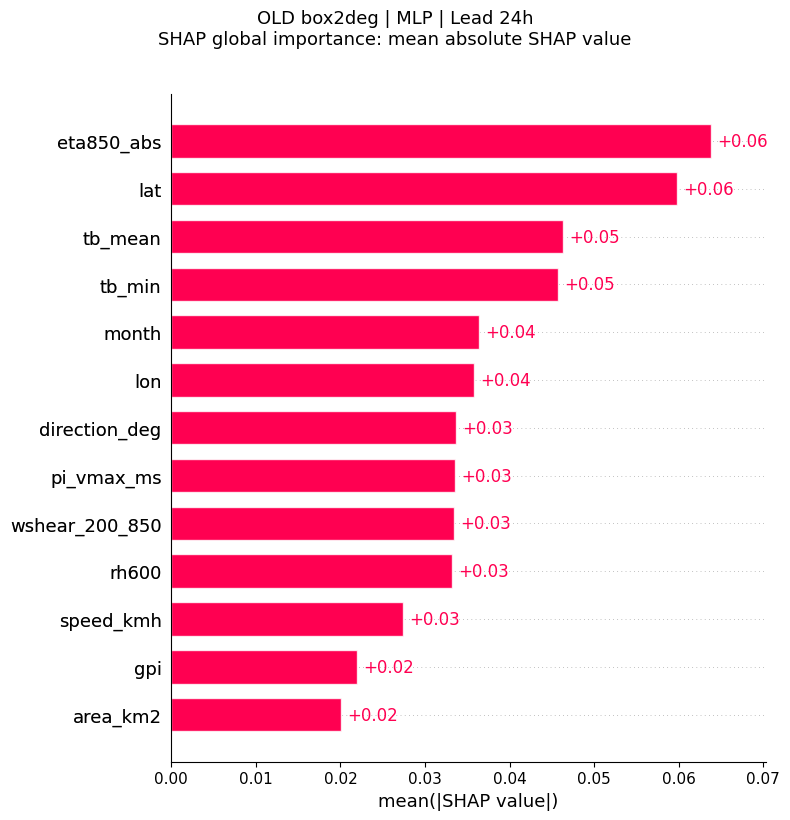

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\shap_bar_old_box2deg_MLP_24h.png


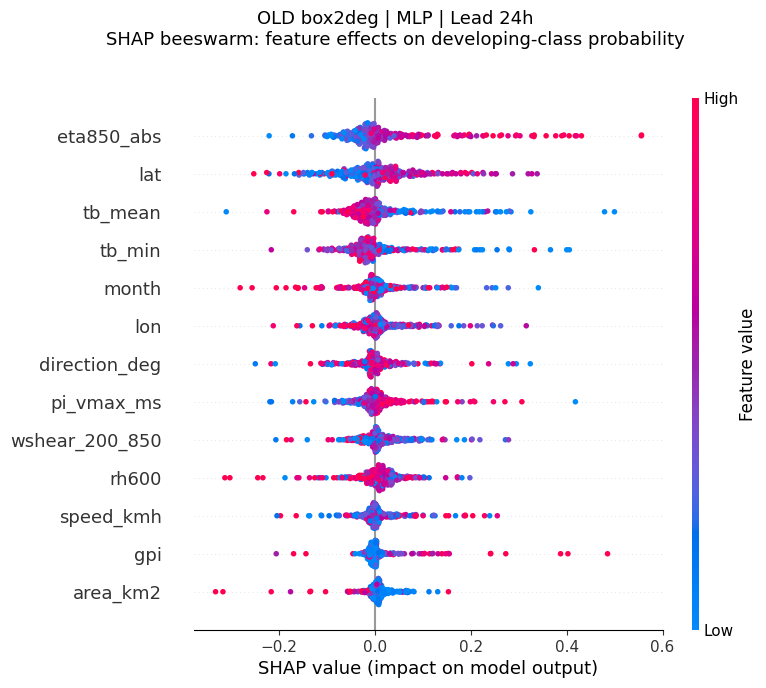

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\shap_beeswarm_old_box2deg_MLP_24h.png


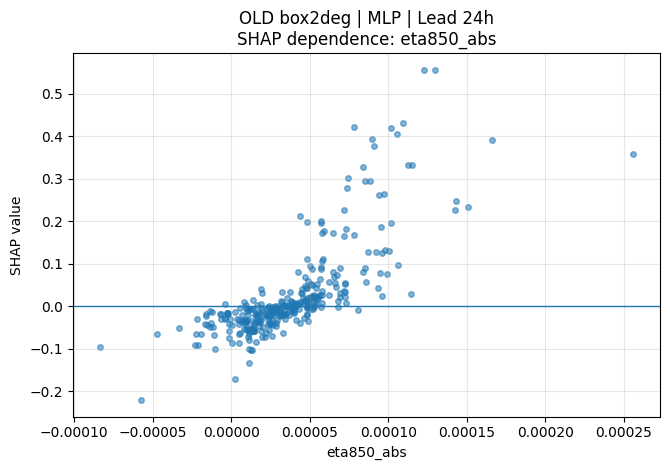

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_24h_dependence_eta850_abs.png


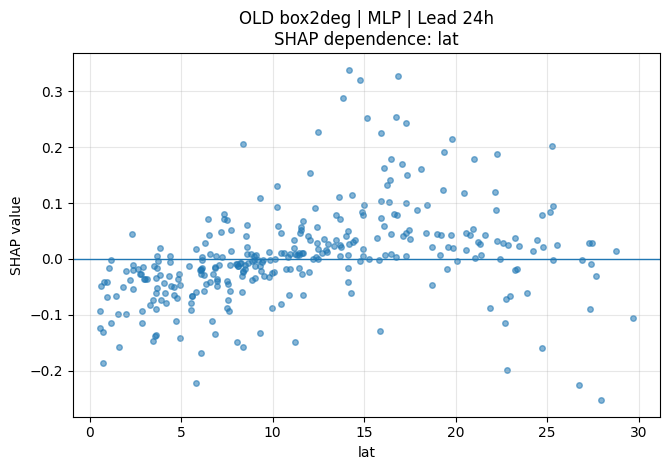

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_24h_dependence_lat.png


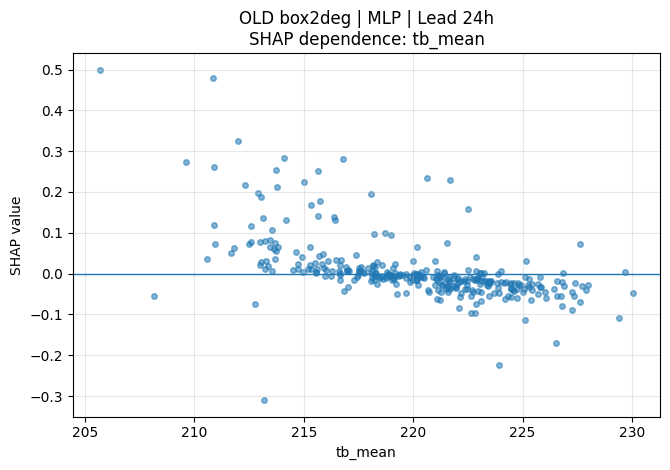

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_24h_dependence_tb_mean.png


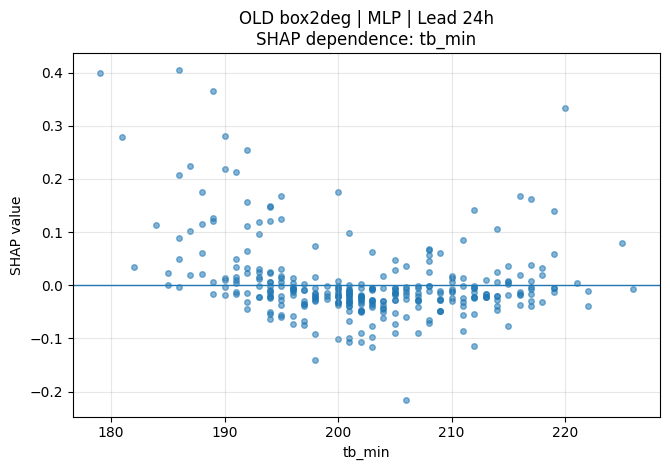

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_24h_dependence_tb_min.png


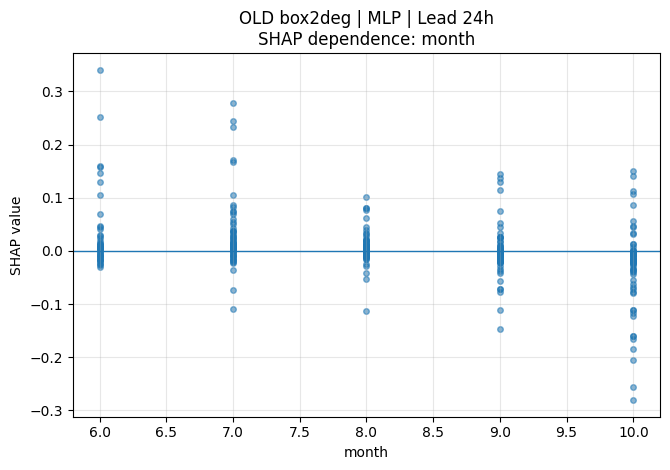

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_24h_dependence_month.png

------------------------------------------------------------------------------------------
Lead 48h
------------------------------------------------------------------------------------------
Rows used: 279 | positive=51 | negative=228
Background sample: 80 | Explanation sample: 279 | Explanation positives=51
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,48,MLP,lat,0.115963,0.022755,1
10,48,MLP,wshear_200_850,0.051053,0.008486,2
0,48,MLP,lon,0.045726,-0.002413,3
2,48,MLP,month,0.045228,0.007934,4
7,48,MLP,direction_deg,0.041363,0.006567,5
3,48,MLP,area_km2,0.040853,0.003488,6
5,48,MLP,tb_min,0.036761,-0.004514,7
4,48,MLP,tb_mean,0.036087,0.000960,8
8,48,MLP,eta850_abs,0.032180,0.005317,9
6,48,MLP,speed_kmh,0.032088,0.002520,10


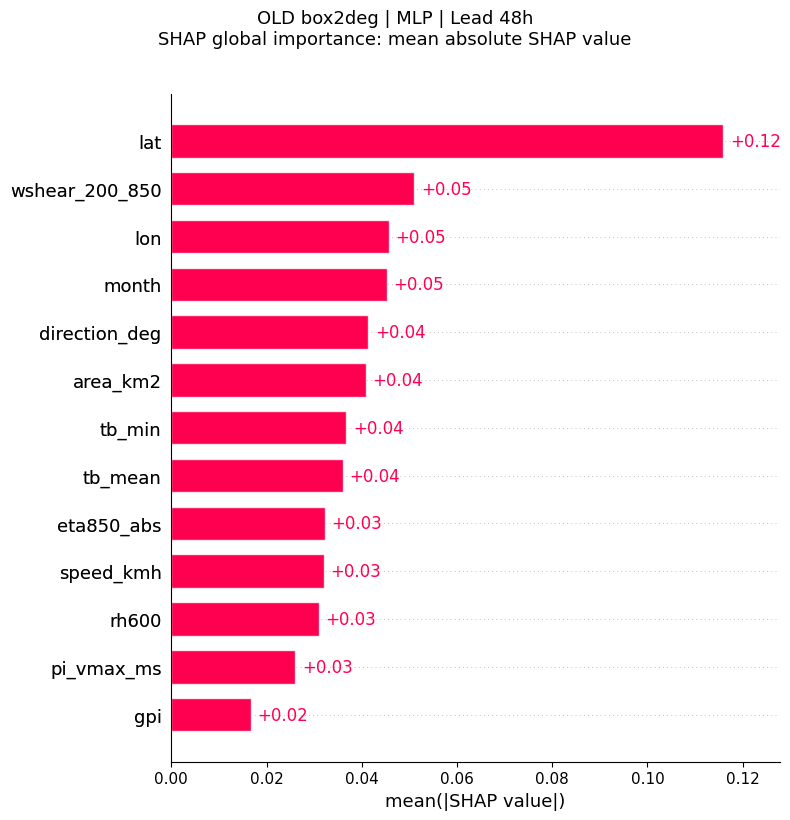

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\shap_bar_old_box2deg_MLP_48h.png


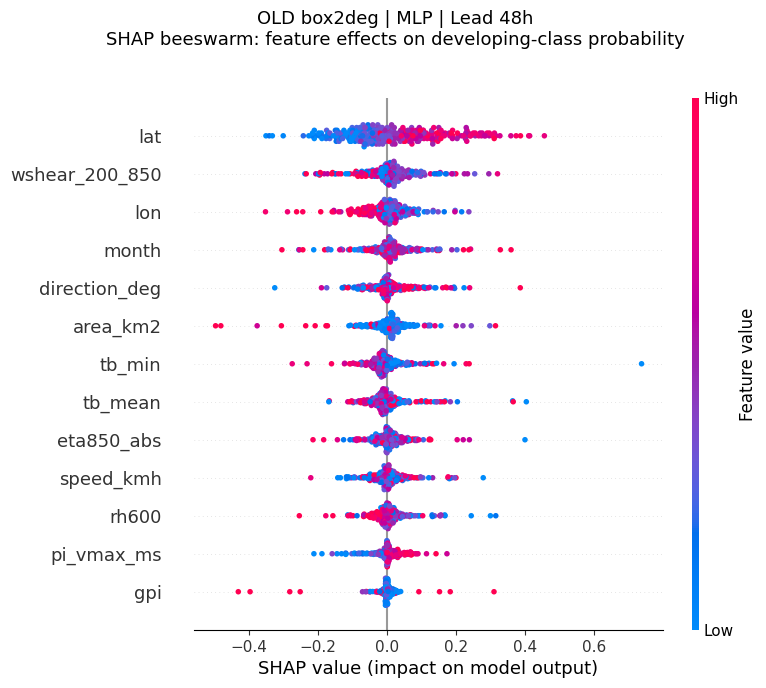

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\shap_beeswarm_old_box2deg_MLP_48h.png


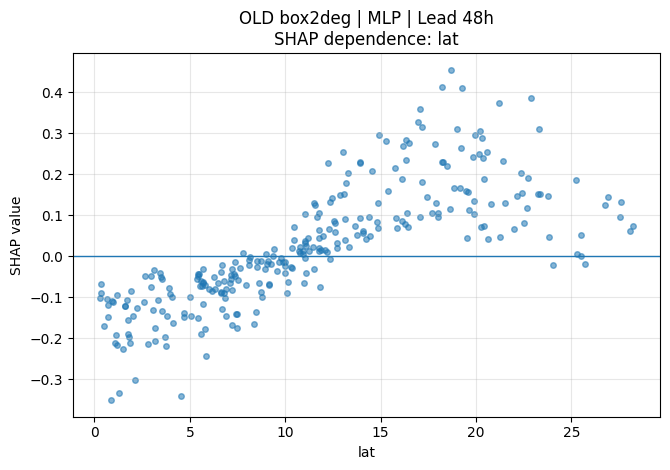

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_48h_dependence_lat.png


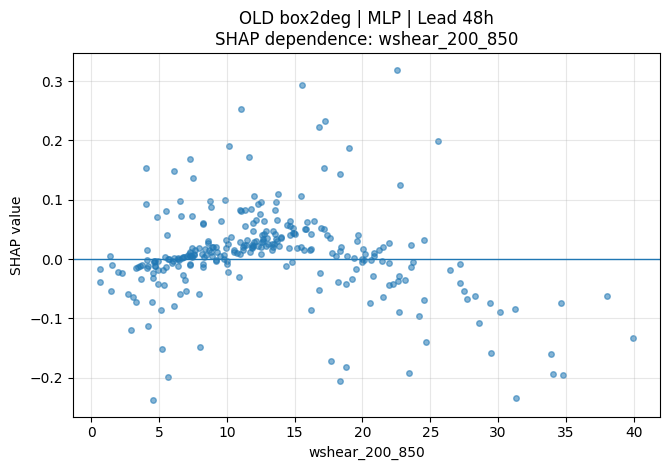

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_48h_dependence_wshear_200_850.png


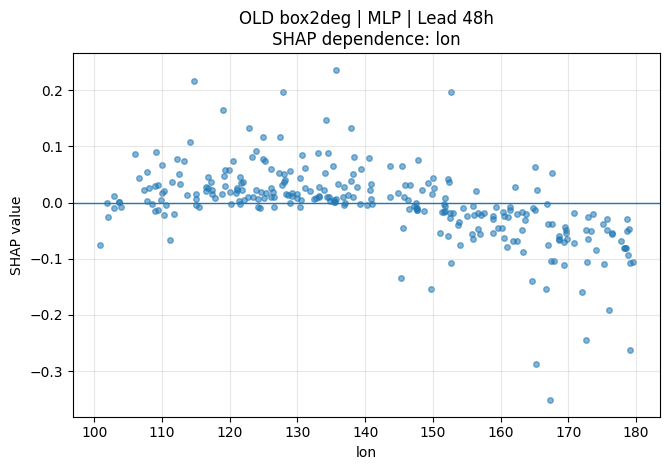

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_48h_dependence_lon.png


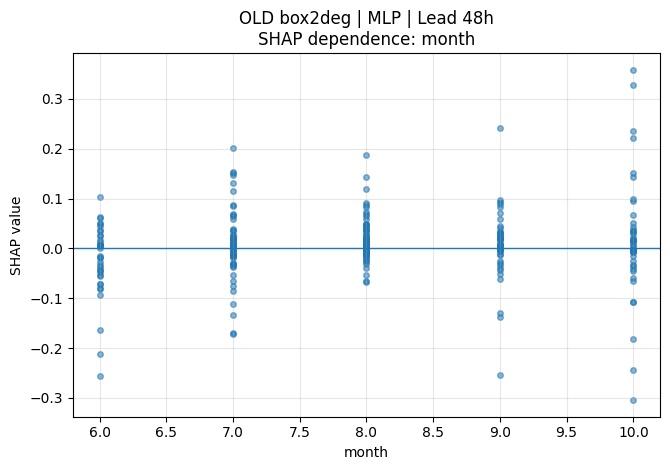

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_48h_dependence_month.png


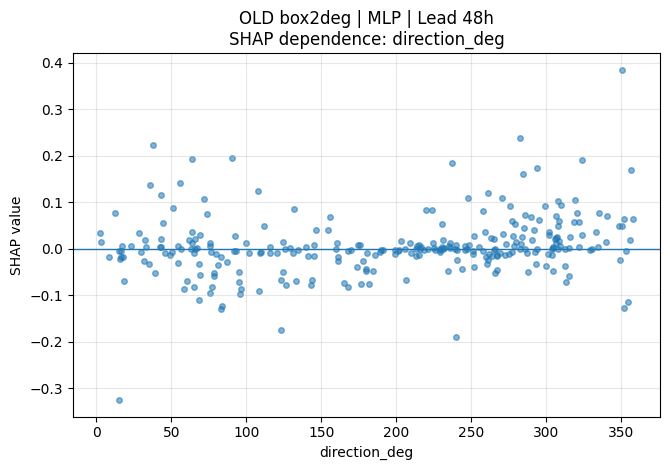

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\MLP\OLD_box2deg__MLP__Lead_48h_dependence_direction_deg.png

Saved combined SHAP importance:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_importance_all_models_all_leads.csv


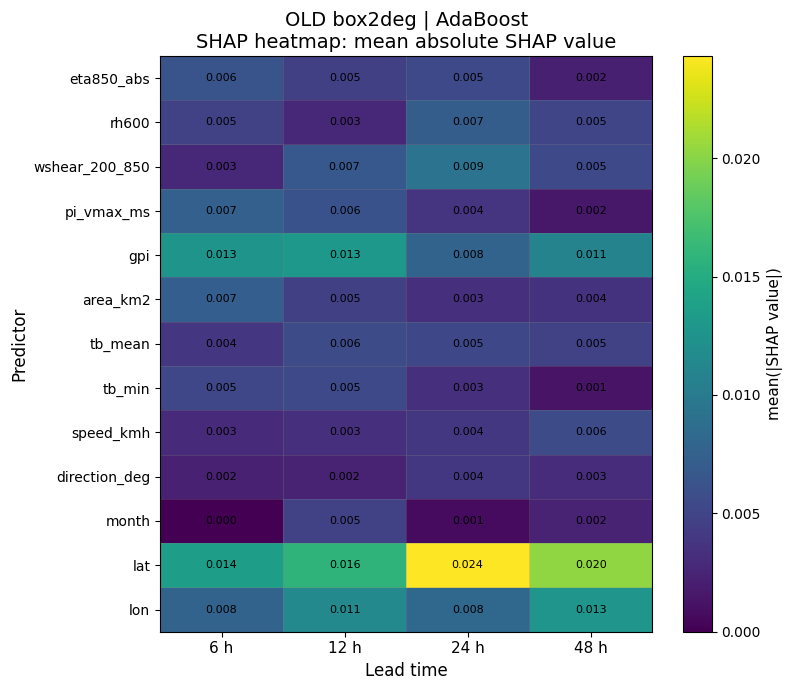

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_AdaBoost.png
Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_AdaBoost.csv


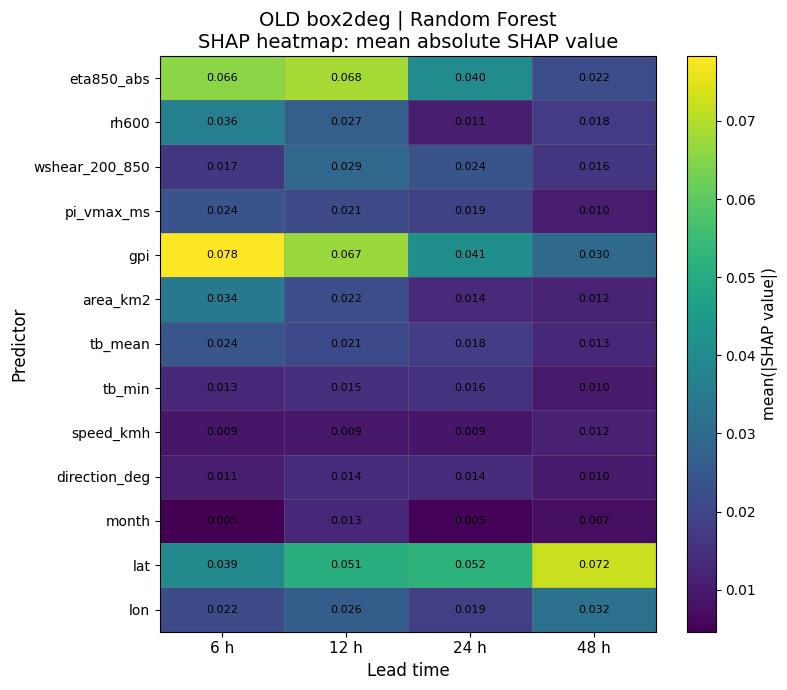

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_Random_Forest.png
Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_Random_Forest.csv


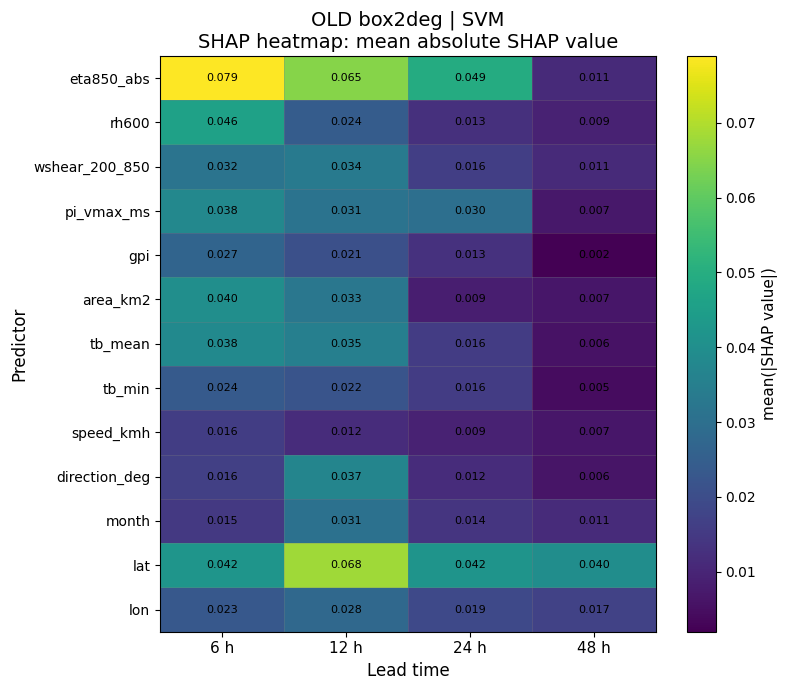

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_SVM.png
Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_SVM.csv


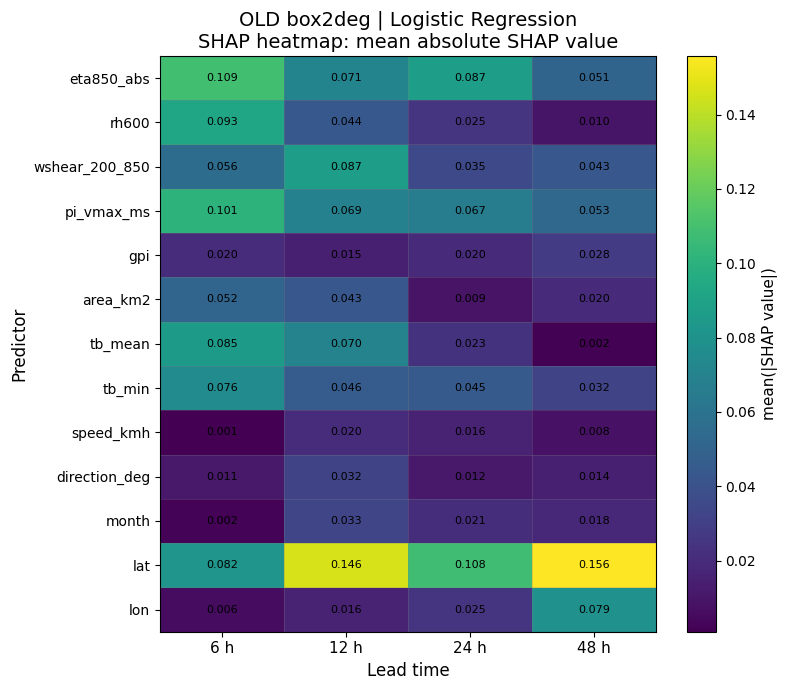

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_Logistic_Regression.png
Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_Logistic_Regression.csv


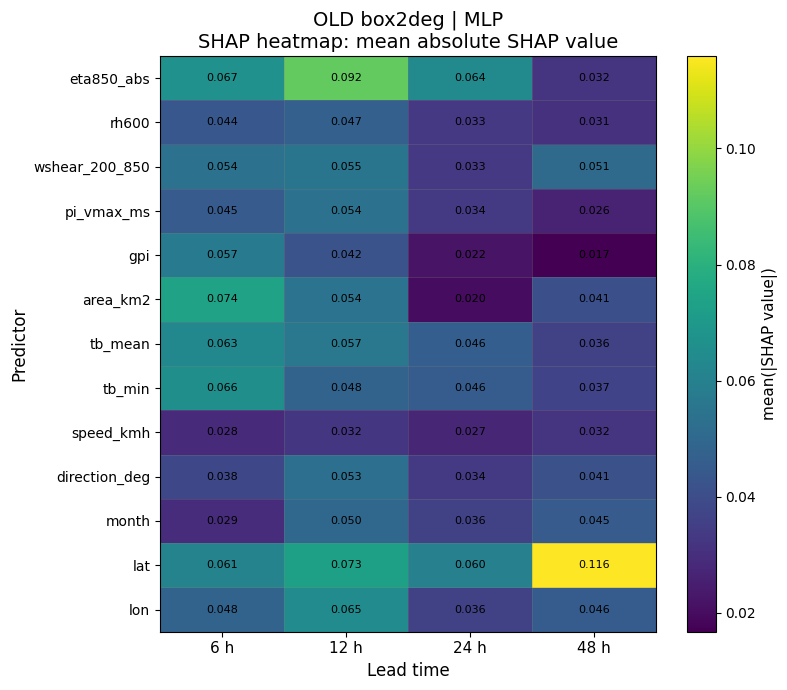

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_MLP.png
Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_MLP.csv

[DONE] SHAP analysis complete.
Main output folder:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots


In [ ]:
# ============================================================
# SHAP PLOTS FOR ML RESULTS
# Compatible with ML_CHECK_LATEST structure
#
# Produces:
#   1. SHAP bar plot
#   2. SHAP beeswarm plot
#   3. SHAP dependence plots for top features
#   4. SHAP heatmap across lead times
#   5. SHAP importance CSV tables
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone

# ------------------------------------------------------------
# Import SHAP
# ------------------------------------------------------------
try:
    import shap
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
SHAP_DIR = OUT_DIR / "shap_plots"
SHAP_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
SHAP_MODEL_NAMES = [
    "AdaBoost",
    "Random Forest",
    "SVM",
    "Logistic Regression",
    "MLP",
]

LEADS_TO_EXPLAIN = LEADS

# Keep these moderate first. Increase later if needed.
SHAP_BACKGROUND_N = 80
SHAP_POS_N = 250
SHAP_NEG_N = 250

N_TOP_DEPENDENCE = 5
SHAP_RANDOM_STATE = RANDOM_STATE

PREDICTOR_ORDER = [
    "eta850_abs",
    "rh600",
    "wshear_200_850",
    "pi_vmax_ms",
    "gpi",
    "area_km2",
    "tb_mean",
    "tb_min",
    "speed_kmh",
    "direction_deg",
    "month",
    "lat",
    "lon",
]

LEAD_ORDER = [6, 12, 24, 48]

# ------------------------------------------------------------
# Load case tables if datasets is not already available
# ------------------------------------------------------------
try:
    datasets
    print("Using existing datasets dictionary.")
except NameError:
    print("datasets not found. Loading case tables from CASE_DIR...")

    datasets = {}

    for L in LEADS_TO_EXPLAIN:
        fp = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

        if not fp.exists():
            raise FileNotFoundError(fp)

        df = pd.read_csv(fp)

        if "time" in df.columns:
            df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)

        df["y"] = df["y"].astype(int)
        datasets[L] = df.copy()

        print(
            f"Lead {L}h | rows={len(df)} | "
            f"positive={int(df['y'].sum())} | "
            f"negative={int((df['y'] == 0).sum())}"
        )

# ------------------------------------------------------------
# Helper: balanced SHAP sample
# ------------------------------------------------------------
def make_shap_samples(X, y, background_n=80, pos_n=250, neg_n=250, random_state=42):
    rng = np.random.default_rng(random_state)

    y = np.asarray(y).astype(int)

    all_idx = np.arange(len(y))
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    bg_n = min(background_n, len(all_idx))
    bg_idx = rng.choice(all_idx, size=bg_n, replace=False)

    pos_take = min(pos_n, len(pos_idx))
    neg_take = min(neg_n, len(neg_idx))

    exp_parts = []

    if pos_take > 0:
        exp_parts.append(rng.choice(pos_idx, size=pos_take, replace=False))

    if neg_take > 0:
        exp_parts.append(rng.choice(neg_idx, size=neg_take, replace=False))

    exp_idx = np.concatenate(exp_parts)
    rng.shuffle(exp_idx)

    X_bg = X.iloc[bg_idx].copy()
    X_exp = X.iloc[exp_idx].copy()
    y_exp = y[exp_idx]

    return X_bg, X_exp, y_exp, exp_idx

# ------------------------------------------------------------
# Helper: prediction function for positive class probability
# ------------------------------------------------------------
def make_predict_positive_func(pipe, feature_cols):
    def predict_positive(z):
        if isinstance(z, pd.DataFrame):
            Xz = z[feature_cols].copy()
        else:
            Xz = pd.DataFrame(z, columns=feature_cols)

        return pipe.predict_proba(Xz)[:, 1]

    return predict_positive

# ------------------------------------------------------------
# Helper: dependence plots
# ------------------------------------------------------------
def save_dependence_plots(shap_values, X_exp, top_features, out_dir, prefix):
    shap_arr = shap_values.values

    for feat in top_features:
        if feat not in X_exp.columns:
            continue

        j = list(X_exp.columns).index(feat)

        fig, ax = plt.subplots(figsize=(6.8, 4.8))

        ax.scatter(
            X_exp[feat].values,
            shap_arr[:, j],
            s=16,
            alpha=0.55
        )

        ax.axhline(0, linewidth=1)
        ax.set_xlabel(feat)
        ax.set_ylabel("SHAP value")
        ax.set_title(f"{prefix}\nSHAP dependence: {feat}")
        ax.grid(True, alpha=0.3)

        plt.tight_layout()

        safe_feat = feat.replace("/", "_").replace(" ", "_")
        safe_prefix = (
            prefix.replace(" ", "_")
            .replace("|", "")
            .replace("/", "_")
        )

        out_png = out_dir / f"{safe_prefix}_dependence_{safe_feat}.png"

        fig.savefig(out_png, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print("Saved:", out_png)

# ------------------------------------------------------------
# Run SHAP
# ------------------------------------------------------------
models_all = get_models(random_state=RANDOM_STATE)

missing_models = [m for m in SHAP_MODEL_NAMES if m not in models_all]
if missing_models:
    raise ValueError(
        f"These models are not available in get_models(): {missing_models}\n"
        f"Available models: {list(models_all.keys())}"
    )

all_shap_importance = []
all_shap_samples = []

for model_name in SHAP_MODEL_NAMES:
    print("\n" + "=" * 90)
    print(f"SHAP ANALYSIS | MODEL: {model_name}")
    print("=" * 90)

    safe_model = model_name.replace(" ", "_").replace("/", "_")
    model_dir = SHAP_DIR / safe_model
    model_dir.mkdir(parents=True, exist_ok=True)

    for L in LEADS_TO_EXPLAIN:
        print("\n" + "-" * 90)
        print(f"Lead {L}h")
        print("-" * 90)

        case_df = datasets[L].copy()

        use_cols = FEATURE_COLS + ["y"]
        case_df = case_df.dropna(subset=use_cols).reset_index(drop=True)

        X = case_df[FEATURE_COLS].copy()
        y = case_df["y"].astype(int).values

        print(
            f"Rows used: {len(case_df)} | "
            f"positive={int(y.sum())} | "
            f"negative={int((y == 0).sum())}"
        )

        # ------------------------------------------------------------
        # Fit final model on all rows for this lead
        # ------------------------------------------------------------
        base_model = clone(models_all[model_name])
        pipe = make_pipeline(model_name, base_model)
        pipe.fit(X, y)

        # ------------------------------------------------------------
        # Balanced SHAP explanation sample
        # ------------------------------------------------------------
        X_bg, X_exp, y_exp, exp_idx = make_shap_samples(
            X=X,
            y=y,
            background_n=SHAP_BACKGROUND_N,
            pos_n=SHAP_POS_N,
            neg_n=SHAP_NEG_N,
            random_state=SHAP_RANDOM_STATE + int(L)
        )

        print(
            f"Background sample: {len(X_bg)} | "
            f"Explanation sample: {len(X_exp)} | "
            f"Explanation positives={int(y_exp.sum())}"
        )

        predict_positive = make_predict_positive_func(pipe, FEATURE_COLS)

        masker = shap.maskers.Independent(X_bg)

        explainer = shap.Explainer(
            predict_positive,
            masker,
            algorithm="permutation",
            feature_names=FEATURE_COLS
        )

        shap_values = explainer(
            X_exp,
            max_evals=2 * len(FEATURE_COLS) + 1,
            batch_size=50
        )

        shap_arr = shap_values.values
        y_prob_exp = pipe.predict_proba(X_exp)[:, 1]

        # ------------------------------------------------------------
        # Save explained sample
        # ------------------------------------------------------------
        sample_out = X_exp.copy()
        sample_out["y_true"] = y_exp
        sample_out["y_prob"] = y_prob_exp
        sample_out["dataset"] = DATASET_NAME
        sample_out["label"] = LABEL_NAME
        sample_out["lead_h"] = L
        sample_out["model"] = model_name

        sample_csv = model_dir / f"shap_explanation_sample_{DATASET_NAME}_{LABEL_NAME}_{safe_model}_{L}h.csv"
        sample_out.to_csv(sample_csv, index=False)

        all_shap_samples.append(sample_out)

        # ------------------------------------------------------------
        # SHAP global importance table
        # ------------------------------------------------------------
        imp = pd.DataFrame({
            "feature": FEATURE_COLS,
            "mean_abs_shap": np.mean(np.abs(shap_arr), axis=0),
            "mean_shap": np.mean(shap_arr, axis=0),
            "std_shap": np.std(shap_arr, axis=0),
        })

        imp["rank"] = imp["mean_abs_shap"].rank(ascending=False, method="dense").astype(int)
        imp = imp.sort_values("mean_abs_shap", ascending=False)

        imp["dataset"] = DATASET_NAME
        imp["label"] = LABEL_NAME
        imp["lead_h"] = L
        imp["model"] = model_name
        imp["n_explain"] = len(X_exp)
        imp["n_background"] = len(X_bg)
        imp["n_positive_explain"] = int(y_exp.sum())
        imp["n_negative_explain"] = int((y_exp == 0).sum())

        all_shap_importance.append(imp)

        imp_csv = model_dir / f"shap_importance_{DATASET_NAME}_{LABEL_NAME}_{safe_model}_{L}h.csv"
        imp.to_csv(imp_csv, index=False)

        print("Top SHAP features:")
        display(imp[["lead_h", "model", "feature", "mean_abs_shap", "mean_shap", "rank"]].head(10))

        # ------------------------------------------------------------
        # Save SHAP values
        # ------------------------------------------------------------
        shap_value_df = pd.DataFrame(
            shap_arr,
            columns=[f"shap_{c}" for c in FEATURE_COLS]
        )

        shap_value_df["y_true"] = y_exp
        shap_value_df["y_prob"] = y_prob_exp
        shap_value_df["dataset"] = DATASET_NAME
        shap_value_df["label"] = LABEL_NAME
        shap_value_df["lead_h"] = L
        shap_value_df["model"] = model_name

        shap_values_csv = model_dir / f"shap_values_{DATASET_NAME}_{LABEL_NAME}_{safe_model}_{L}h.csv"
        shap_value_df.to_csv(shap_values_csv, index=False)

        # ------------------------------------------------------------
        # SHAP bar plot
        # ------------------------------------------------------------
        title_prefix = f"{DATASET_NAME.upper()} {LABEL_NAME} | {model_name} | Lead {L}h"

        bar_png = model_dir / f"shap_bar_{DATASET_NAME}_{LABEL_NAME}_{safe_model}_{L}h.png"

        plt.figure(figsize=(8, 6))
        shap.plots.bar(
            shap_values,
            max_display=len(FEATURE_COLS),
            show=False
        )
        fig = plt.gcf()
        fig.suptitle(
            f"{title_prefix}\nSHAP global importance: mean absolute SHAP value",
            fontsize=13,
            y=1.02
        )
        plt.tight_layout()
        fig.savefig(bar_png, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print("Saved:", bar_png)

        # ------------------------------------------------------------
        # SHAP beeswarm plot
        # ------------------------------------------------------------
        beeswarm_png = model_dir / f"shap_beeswarm_{DATASET_NAME}_{LABEL_NAME}_{safe_model}_{L}h.png"

        plt.figure(figsize=(8.5, 6.5))
        shap.plots.beeswarm(
            shap_values,
            max_display=len(FEATURE_COLS),
            show=False
        )
        fig = plt.gcf()
        fig.suptitle(
            f"{title_prefix}\nSHAP beeswarm: feature effects on developing-class probability",
            fontsize=13,
            y=1.02
        )
        plt.tight_layout()
        fig.savefig(beeswarm_png, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print("Saved:", beeswarm_png)

        # ------------------------------------------------------------
        # SHAP dependence plots for top predictors
        # ------------------------------------------------------------
        top_features = imp["feature"].head(N_TOP_DEPENDENCE).tolist()

        save_dependence_plots(
            shap_values=shap_values,
            X_exp=X_exp,
            top_features=top_features,
            out_dir=model_dir,
            prefix=title_prefix
        )

# ------------------------------------------------------------
# Save combined SHAP outputs
# ------------------------------------------------------------
shap_importance_all = pd.concat(all_shap_importance, ignore_index=True)
shap_importance_all.to_csv(
    SHAP_DIR / "shap_importance_all_models_all_leads.csv",
    index=False
)

shap_samples_all = pd.concat(all_shap_samples, ignore_index=True)
shap_samples_all.to_csv(
    SHAP_DIR / "shap_explanation_samples_all_models_all_leads.csv",
    index=False
)

print("\nSaved combined SHAP importance:")
print(SHAP_DIR / "shap_importance_all_models_all_leads.csv")

# ------------------------------------------------------------
# SHAP HEATMAP ACROSS LEAD TIMES
# rows = predictors
# cols = lead times
# values = mean absolute SHAP value
# ------------------------------------------------------------
for model_name in SHAP_MODEL_NAMES:
    safe_model = model_name.replace(" ", "_").replace("/", "_")

    sub = shap_importance_all[
        shap_importance_all["model"] == model_name
    ].copy()

    heat = sub.pivot_table(
        index="feature",
        columns="lead_h",
        values="mean_abs_shap",
        aggfunc="mean"
    )

    heat = heat.reindex(index=PREDICTOR_ORDER, columns=LEAD_ORDER)

    vals = heat.values.astype(float)

    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(vals, aspect="auto", cmap="viridis")

    ax.set_xticks(np.arange(len(LEAD_ORDER)))
    ax.set_xticklabels([f"{L} h" for L in LEAD_ORDER], fontsize=11)

    ax.set_yticks(np.arange(len(PREDICTOR_ORDER)))
    ax.set_yticklabels(PREDICTOR_ORDER, fontsize=10)

    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8)
            else:
                ax.text(j, i, "NA", ha="center", va="center", fontsize=8)

    ax.set_xlabel("Lead time", fontsize=12)
    ax.set_ylabel("Predictor", fontsize=12)
    ax.set_title(
        f"{DATASET_NAME.upper()} {LABEL_NAME} | {model_name}\n"
        "SHAP heatmap: mean absolute SHAP value",
        fontsize=14
    )

    ax.set_xticks(np.arange(-0.5, len(LEAD_ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(PREDICTOR_ORDER), 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("mean(|SHAP value|)", fontsize=11)

    plt.tight_layout()

    heat_png = SHAP_DIR / f"shap_heatmap_mean_abs_{DATASET_NAME}_{LABEL_NAME}_{safe_model}.png"
    heat_csv = SHAP_DIR / f"shap_heatmap_mean_abs_{DATASET_NAME}_{LABEL_NAME}_{safe_model}.csv"

    fig.savefig(heat_png, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    heat.to_csv(heat_csv)

    print("Saved:", heat_png)
    print("Saved:", heat_csv)

print("\n[DONE] SHAP analysis complete.")
print("Main output folder:")
print(SHAP_DIR)

SHAP Naive Bayes

Using existing datasets dictionary.

SHAP ANALYSIS | MODEL: Naive Bayes

------------------------------------------------------------------------------------------
Lead 6h
------------------------------------------------------------------------------------------
Rows used: 565 | positive=125 | negative=440
Background sample: 80 | Explanation sample: 375 | Explanation positives=125
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
3,6,Naive Bayes,area_km2,0.072657,0.024128,1
9,6,Naive Bayes,rh600,0.072644,0.022739,2
8,6,Naive Bayes,eta850_abs,0.057847,0.024484,3
4,6,Naive Bayes,tb_mean,0.053293,0.015135,4
1,6,Naive Bayes,lat,0.046540,0.014097,5
10,6,Naive Bayes,wshear_200_850,0.041667,-0.000852,6
11,6,Naive Bayes,pi_vmax_ms,0.033847,-0.008271,7
5,6,Naive Bayes,tb_min,0.033737,0.011026,8
0,6,Naive Bayes,lon,0.024874,0.007712,9
12,6,Naive Bayes,gpi,0.019600,0.007432,10


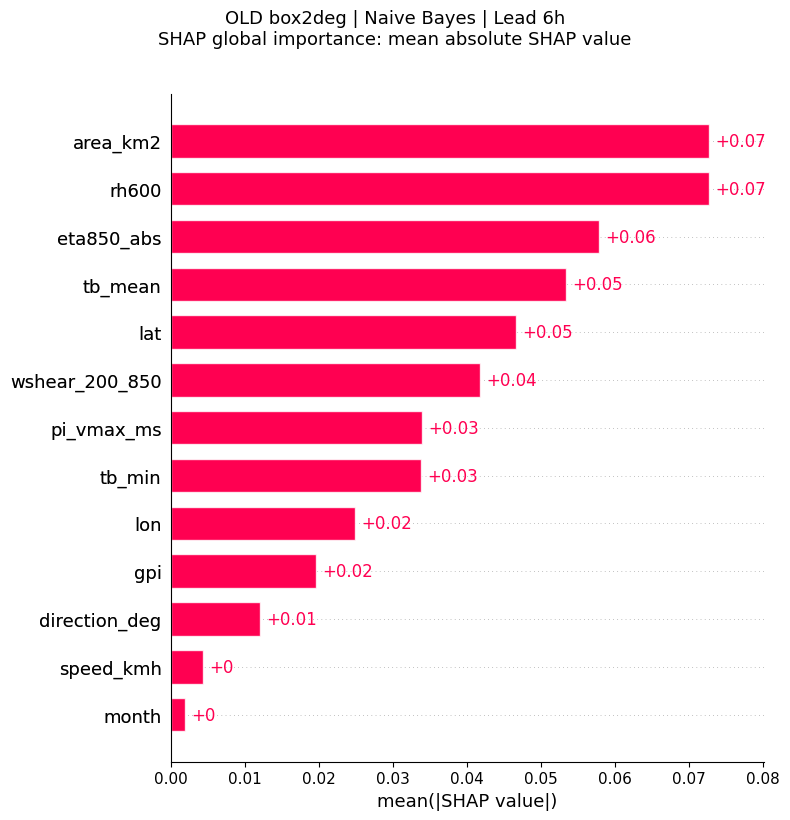

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\shap_bar_old_box2deg_Naive_Bayes_6h.png


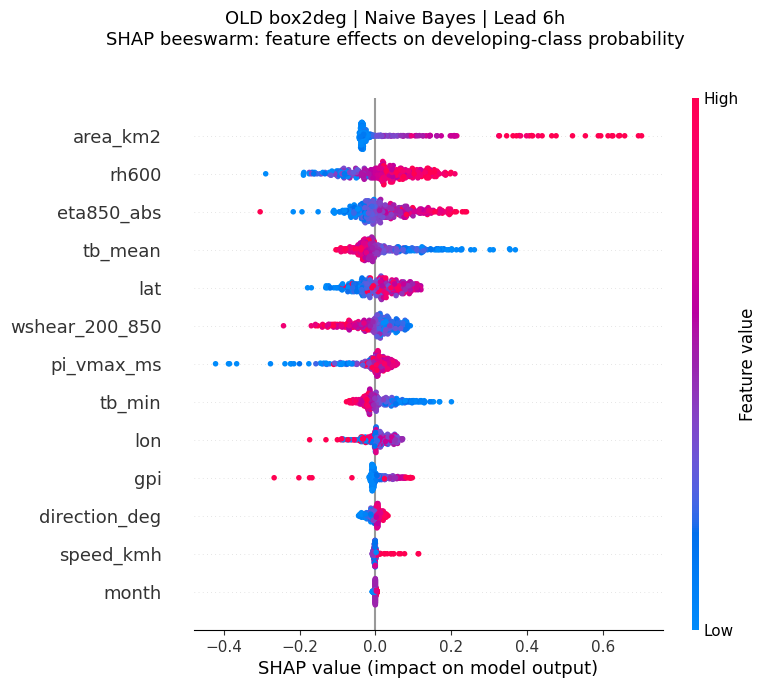

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\shap_beeswarm_old_box2deg_Naive_Bayes_6h.png


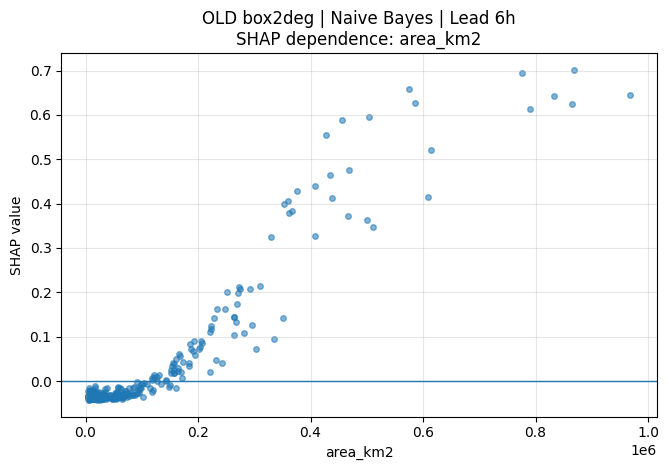

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_6h_dependence_area_km2.png


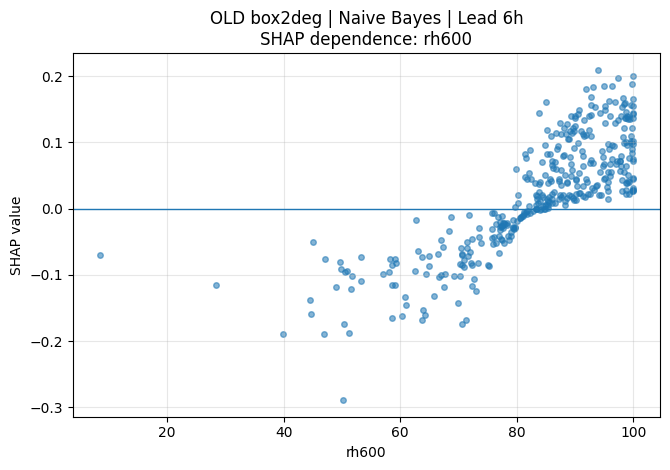

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_6h_dependence_rh600.png


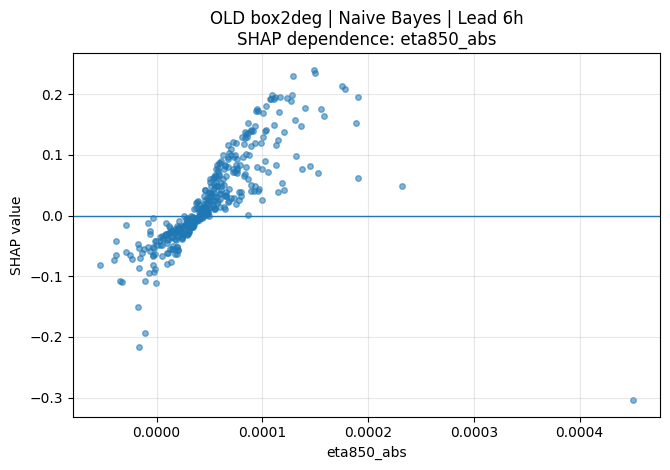

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_6h_dependence_eta850_abs.png


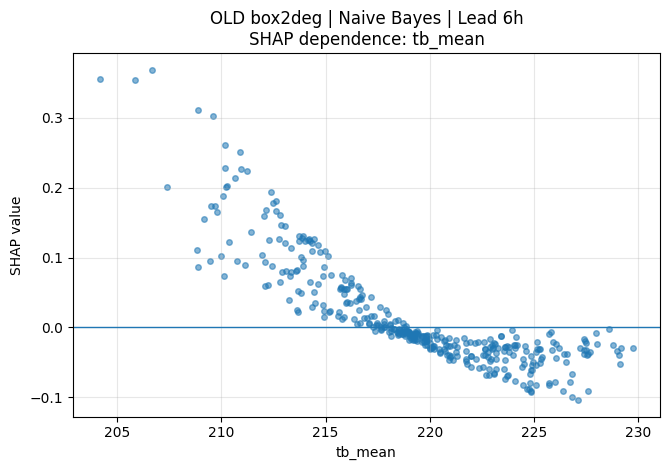

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_6h_dependence_tb_mean.png


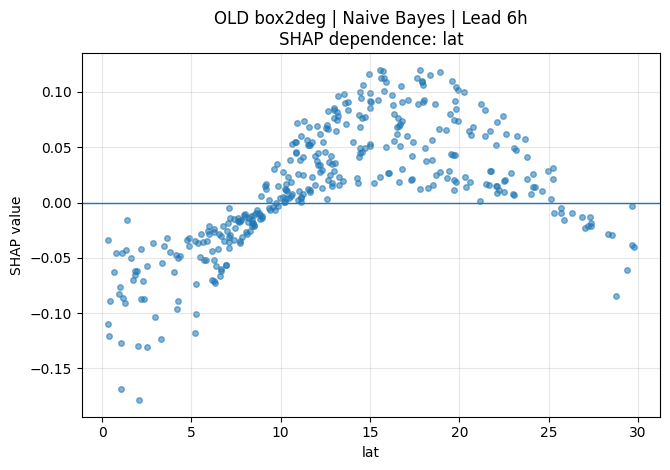

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_6h_dependence_lat.png

------------------------------------------------------------------------------------------
Lead 12h
------------------------------------------------------------------------------------------
Rows used: 560 | positive=122 | negative=438
Background sample: 80 | Explanation sample: 372 | Explanation positives=122
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
3,12,Naive Bayes,area_km2,0.071274,-0.022670,1
10,12,Naive Bayes,wshear_200_850,0.069419,0.020093,2
1,12,Naive Bayes,lat,0.058440,0.012549,3
4,12,Naive Bayes,tb_mean,0.048391,0.002233,4
8,12,Naive Bayes,eta850_abs,0.047613,0.005514,5
9,12,Naive Bayes,rh600,0.037133,-0.003539,6
5,12,Naive Bayes,tb_min,0.032590,-0.000953,7
12,12,Naive Bayes,gpi,0.031072,-0.001380,8
6,12,Naive Bayes,speed_kmh,0.027007,0.001500,9
0,12,Naive Bayes,lon,0.025673,0.001319,10


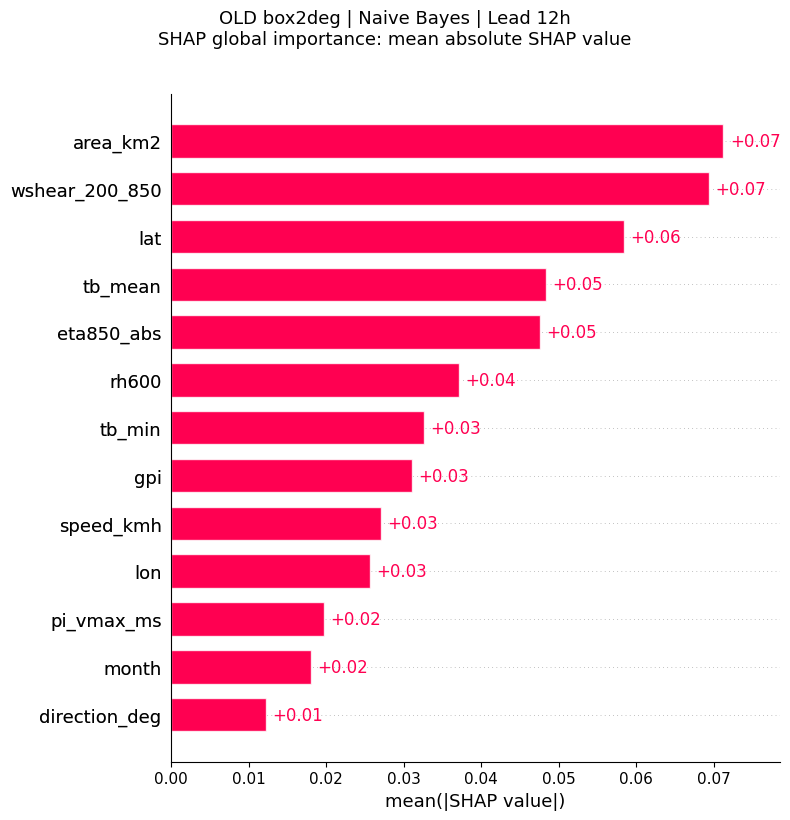

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\shap_bar_old_box2deg_Naive_Bayes_12h.png


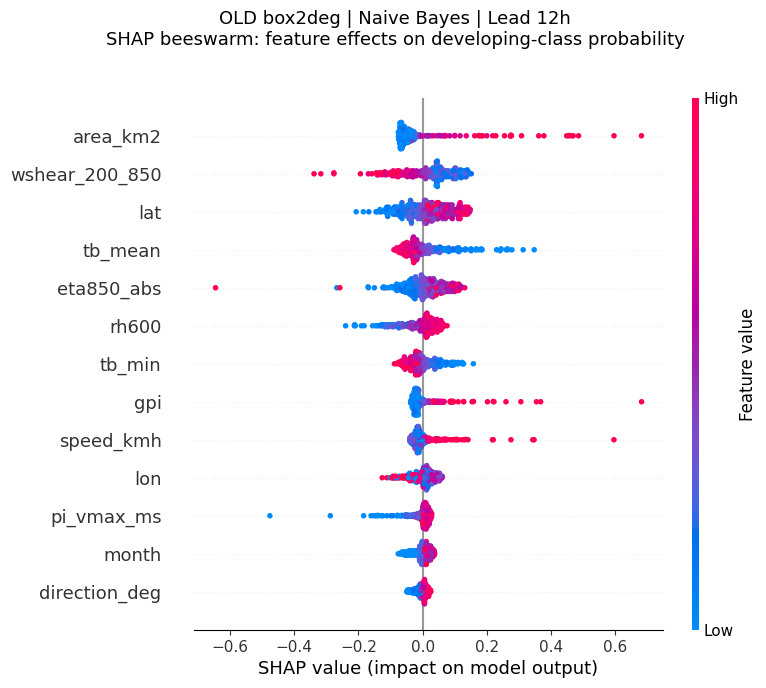

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\shap_beeswarm_old_box2deg_Naive_Bayes_12h.png


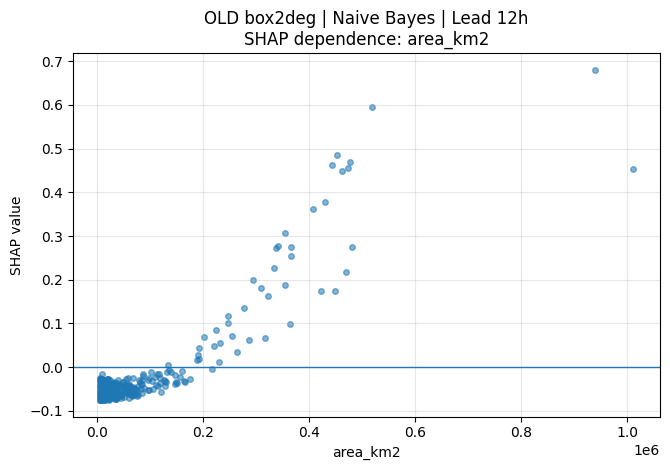

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_12h_dependence_area_km2.png


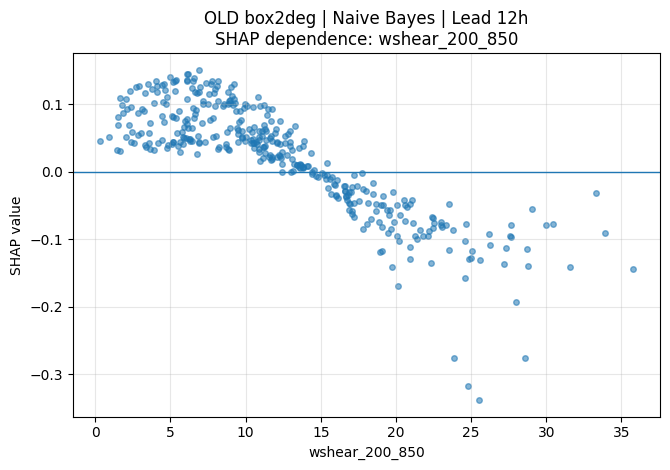

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_12h_dependence_wshear_200_850.png


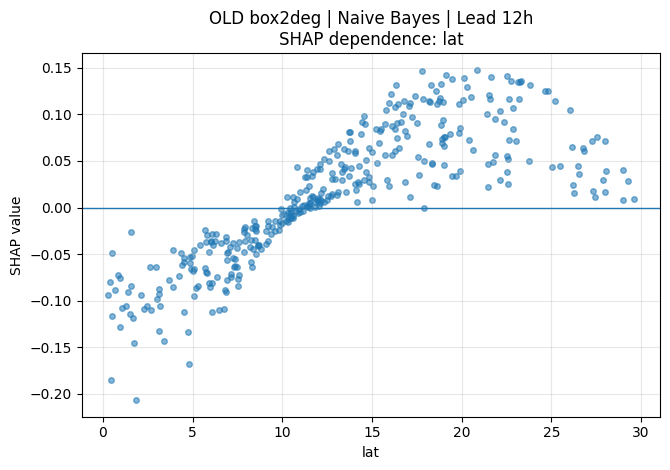

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_12h_dependence_lat.png


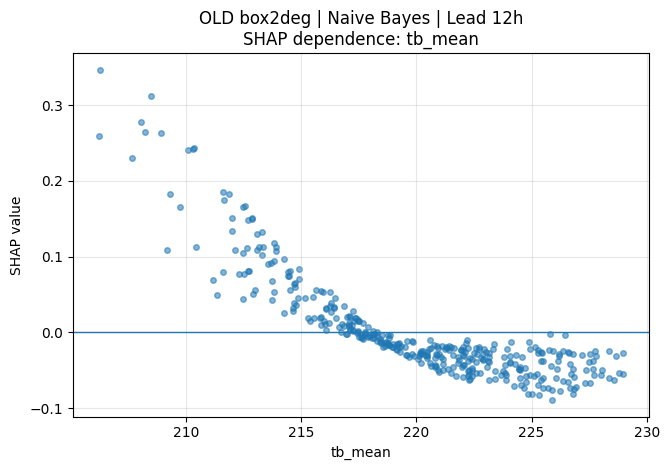

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_12h_dependence_tb_mean.png


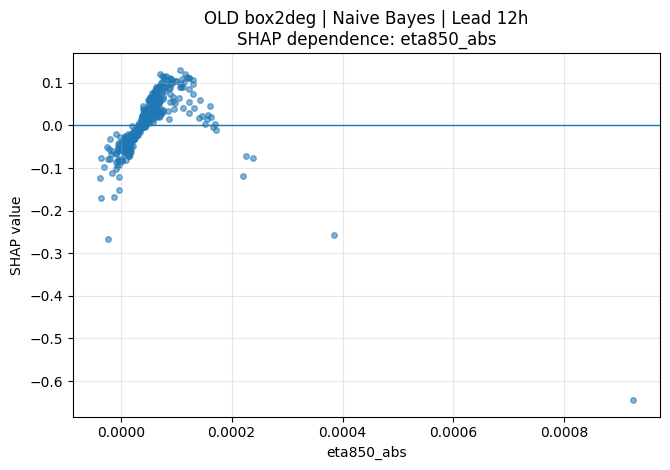

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_12h_dependence_eta850_abs.png

------------------------------------------------------------------------------------------
Lead 24h
------------------------------------------------------------------------------------------
Rows used: 417 | positive=71 | negative=346
Background sample: 80 | Explanation sample: 321 | Explanation positives=71
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
12,24,Naive Bayes,gpi,0.076885,0.035733,1
8,24,Naive Bayes,eta850_abs,0.047279,0.011656,2
1,24,Naive Bayes,lat,0.034634,0.006254,3
10,24,Naive Bayes,wshear_200_850,0.029175,0.006221,4
4,24,Naive Bayes,tb_mean,0.023243,-0.002251,5
9,24,Naive Bayes,rh600,0.019370,0.004611,6
5,24,Naive Bayes,tb_min,0.016103,-0.002376,7
3,24,Naive Bayes,area_km2,0.013348,0.004881,8
0,24,Naive Bayes,lon,0.011446,0.001691,9
6,24,Naive Bayes,speed_kmh,0.007057,0.001220,10


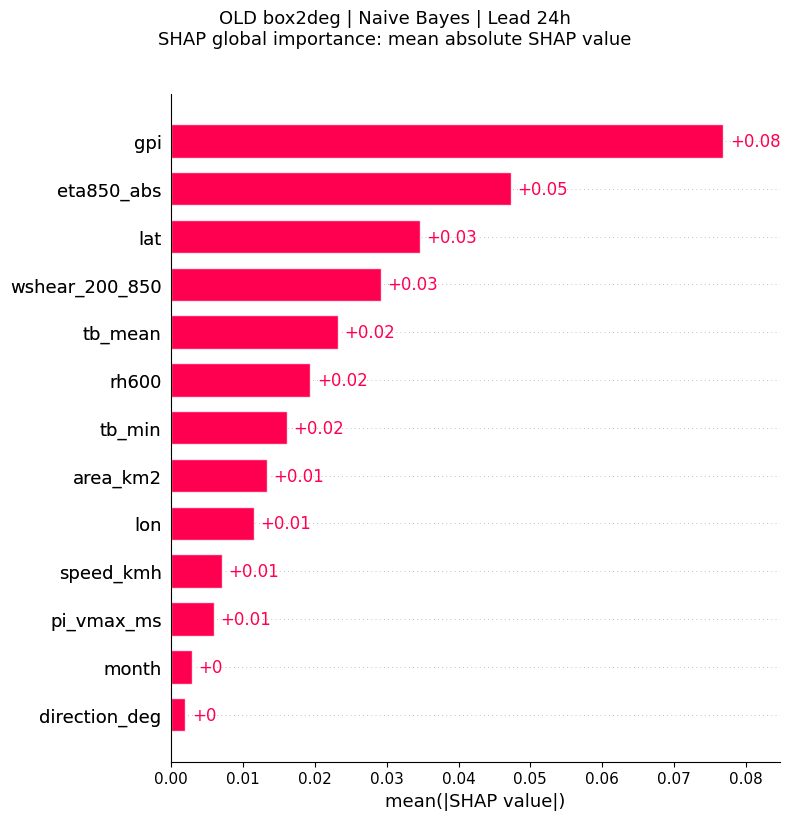

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\shap_bar_old_box2deg_Naive_Bayes_24h.png


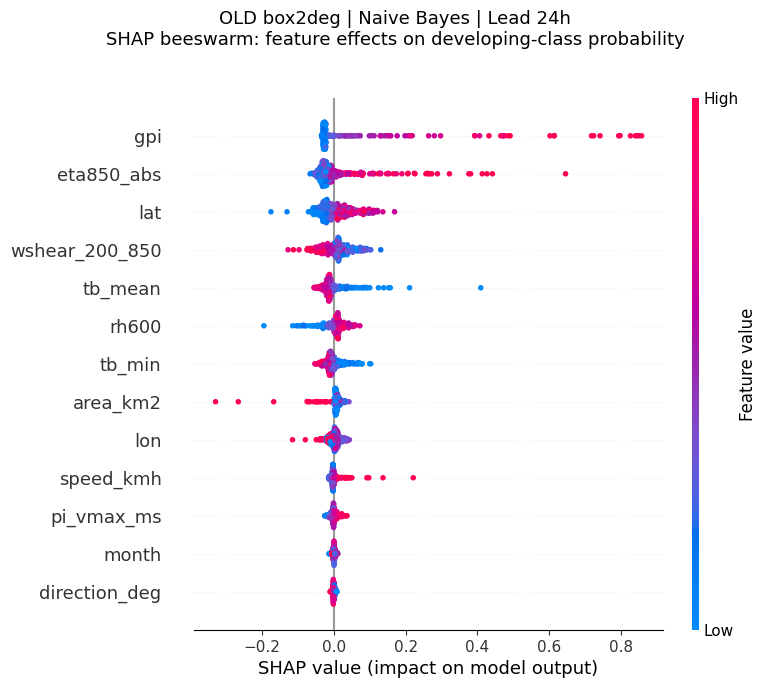

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\shap_beeswarm_old_box2deg_Naive_Bayes_24h.png


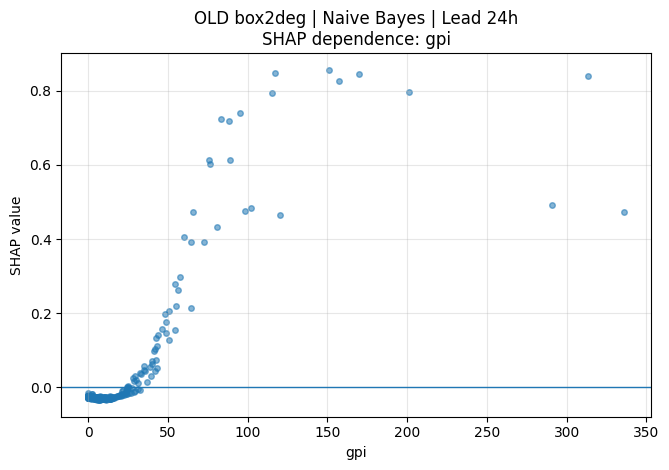

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_24h_dependence_gpi.png


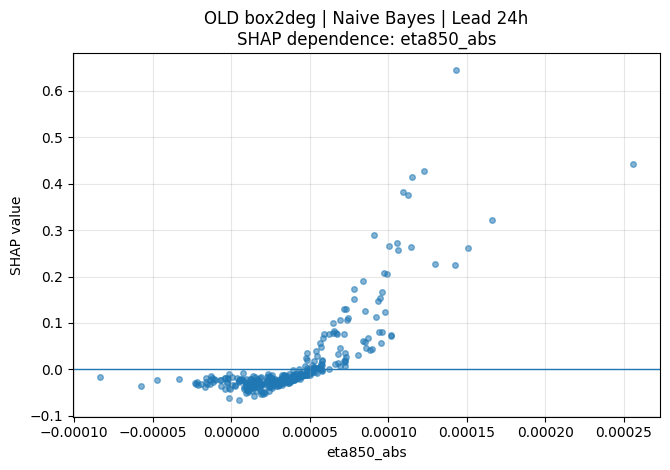

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_24h_dependence_eta850_abs.png


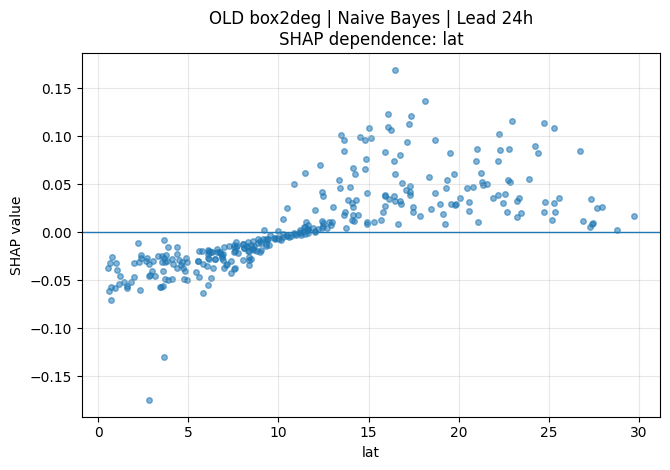

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_24h_dependence_lat.png


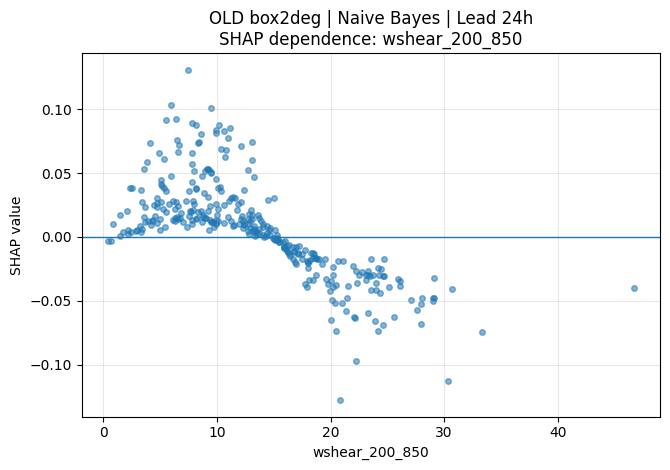

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_24h_dependence_wshear_200_850.png


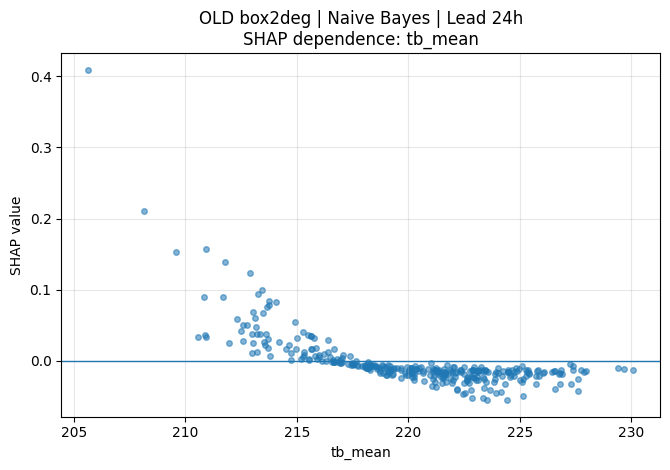

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_24h_dependence_tb_mean.png

------------------------------------------------------------------------------------------
Lead 48h
------------------------------------------------------------------------------------------
Rows used: 279 | positive=51 | negative=228
Background sample: 80 | Explanation sample: 279 | Explanation positives=51
Top SHAP features:


,lead_h,model,feature,mean_abs_shap,mean_shap,rank
1,48,Naive Bayes,lat,0.116070,0.010506,1
0,48,Naive Bayes,lon,0.059567,-0.010602,2
3,48,Naive Bayes,area_km2,0.047660,0.008877,3
8,48,Naive Bayes,eta850_abs,0.046379,0.002372,4
10,48,Naive Bayes,wshear_200_850,0.041764,0.001644,5
5,48,Naive Bayes,tb_min,0.037580,-0.013347,6
11,48,Naive Bayes,pi_vmax_ms,0.037080,0.006154,7
4,48,Naive Bayes,tb_mean,0.025481,-0.006418,8
12,48,Naive Bayes,gpi,0.021490,-0.006302,9
2,48,Naive Bayes,month,0.018886,0.002112,10


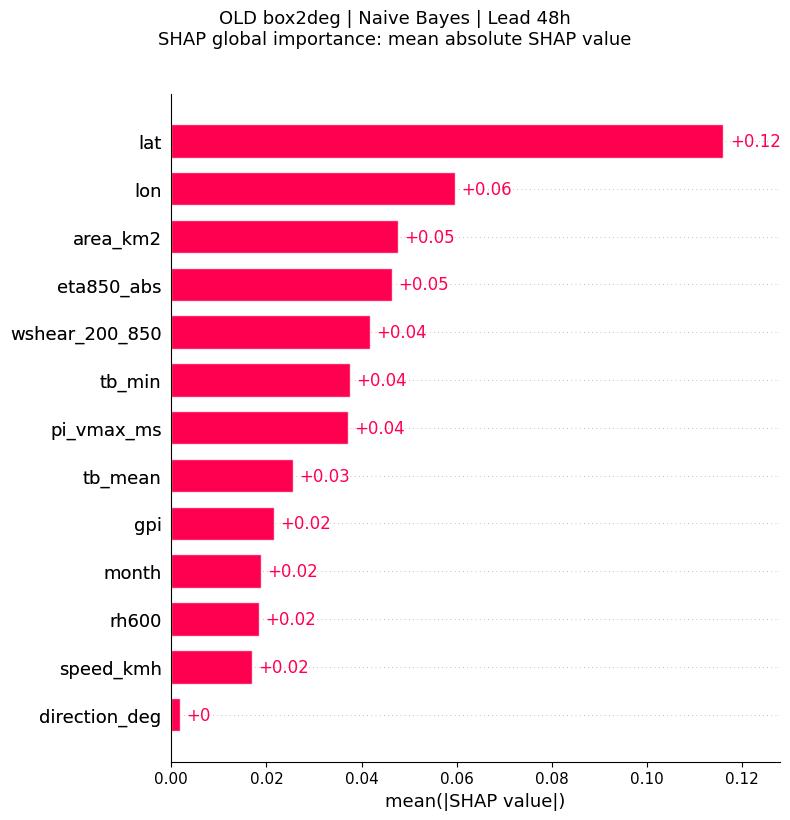

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\shap_bar_old_box2deg_Naive_Bayes_48h.png


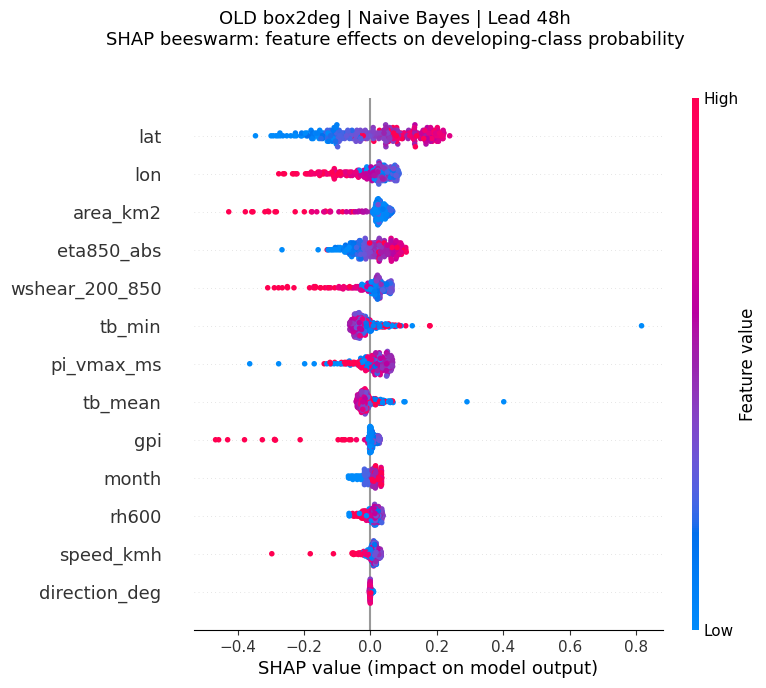

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\shap_beeswarm_old_box2deg_Naive_Bayes_48h.png


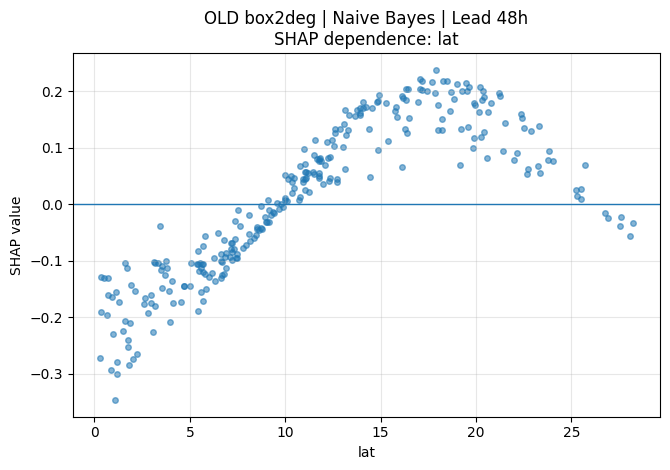

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_48h_dependence_lat.png


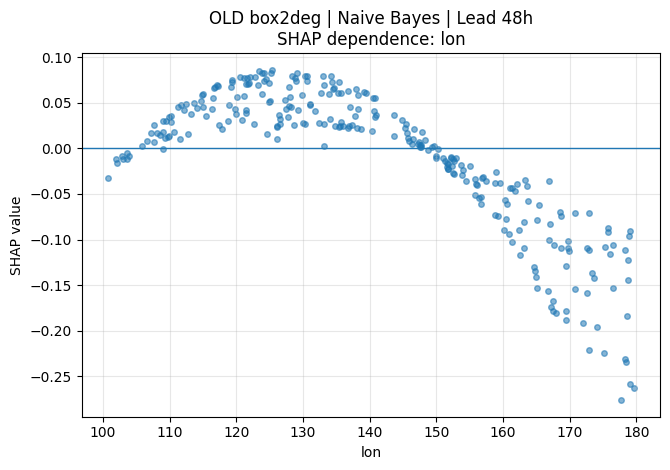

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_48h_dependence_lon.png


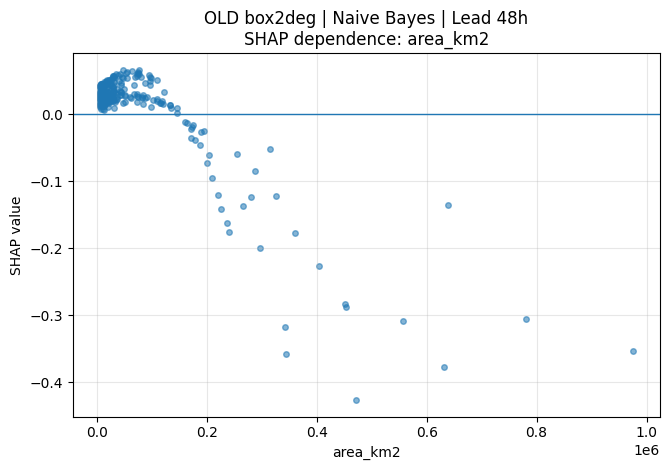

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_48h_dependence_area_km2.png


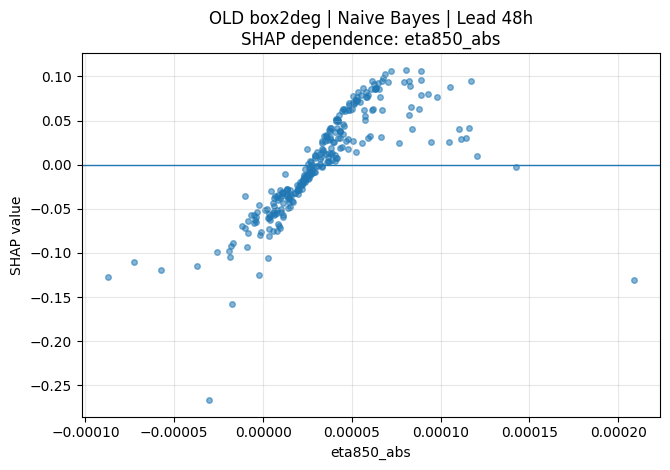

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_48h_dependence_eta850_abs.png


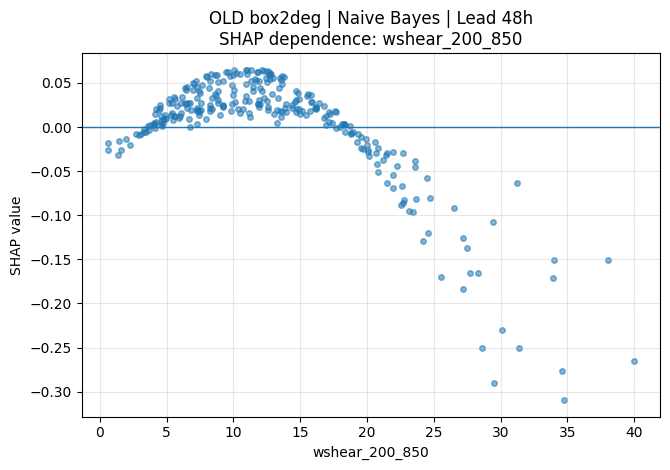

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\Naive_Bayes\OLD_box2deg__Naive_Bayes__Lead_48h_dependence_wshear_200_850.png

Saved combined SHAP importance:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_importance_all_models_all_leads.csv


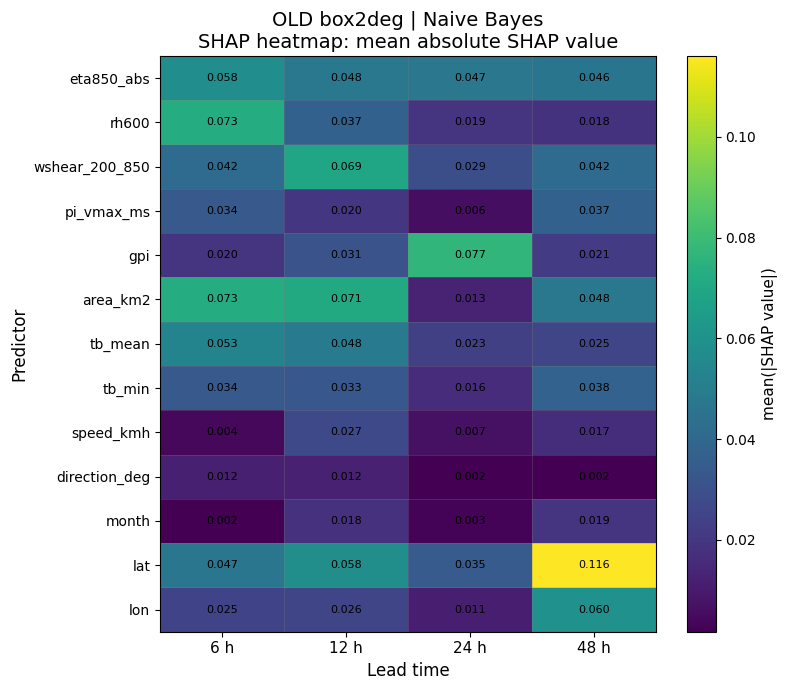

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_Naive_Bayes.png
Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots\shap_heatmap_mean_abs_old_box2deg_Naive_Bayes.csv

[DONE] SHAP analysis complete.
Main output folder:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\shap_plots


In [26]:
# ============================================================
# SHAP PLOTS FOR ML RESULTS
# Compatible with ML_CHECK_LATEST structure
#
# Produces:
#   1. SHAP bar plot
#   2. SHAP beeswarm plot
#   3. SHAP dependence plots for top features
#   4. SHAP heatmap across lead times
#   5. SHAP importance CSV tables
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone

# ------------------------------------------------------------
# Import SHAP
# ------------------------------------------------------------
try:
    import shap
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
SHAP_DIR = OUT_DIR / "shap_plots"
SHAP_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
SHAP_MODEL_NAMES = [
    "Naive Bayes",
]

LEADS_TO_EXPLAIN = LEADS

# Keep these moderate first. Increase later if needed.
SHAP_BACKGROUND_N = 80
SHAP_POS_N = 250
SHAP_NEG_N = 250

N_TOP_DEPENDENCE = 5
SHAP_RANDOM_STATE = RANDOM_STATE

PREDICTOR_ORDER = [
    "eta850_abs",
    "rh600",
    "wshear_200_850",
    "pi_vmax_ms",
    "gpi",
    "area_km2",
    "tb_mean",
    "tb_min",
    "speed_kmh",
    "direction_deg",
    "month",
    "lat",
    "lon",
]

LEAD_ORDER = [6, 12, 24, 48]

# ------------------------------------------------------------
# Load case tables if datasets is not already available
# ------------------------------------------------------------
try:
    datasets
    print("Using existing datasets dictionary.")
except NameError:
    print("datasets not found. Loading case tables from CASE_DIR...")

    datasets = {}

    for L in LEADS_TO_EXPLAIN:
        fp = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

        if not fp.exists():
            raise FileNotFoundError(fp)

        df = pd.read_csv(fp)

        if "time" in df.columns:
            df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)

        df["y"] = df["y"].astype(int)
        datasets[L] = df.copy()

        print(
            f"Lead {L}h | rows={len(df)} | "
            f"positive={int(df['y'].sum())} | "
            f"negative={int((df['y'] == 0).sum())}"
        )

# ------------------------------------------------------------
# Helper: balanced SHAP sample
# ------------------------------------------------------------
def make_shap_samples(X, y, background_n=80, pos_n=250, neg_n=250, random_state=42):
    rng = np.random.default_rng(random_state)

    y = np.asarray(y).astype(int)

    all_idx = np.arange(len(y))
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    bg_n = min(background_n, len(all_idx))
    bg_idx = rng.choice(all_idx, size=bg_n, replace=False)

    pos_take = min(pos_n, len(pos_idx))
    neg_take = min(neg_n, len(neg_idx))

    exp_parts = []

    if pos_take > 0:
        exp_parts.append(rng.choice(pos_idx, size=pos_take, replace=False))

    if neg_take > 0:
        exp_parts.append(rng.choice(neg_idx, size=neg_take, replace=False))

    exp_idx = np.concatenate(exp_parts)
    rng.shuffle(exp_idx)

    X_bg = X.iloc[bg_idx].copy()
    X_exp = X.iloc[exp_idx].copy()
    y_exp = y[exp_idx]

    return X_bg, X_exp, y_exp, exp_idx

# ------------------------------------------------------------
# Helper: prediction function for positive class probability
# ------------------------------------------------------------
def make_predict_positive_func(pipe, feature_cols):
    def predict_positive(z):
        if isinstance(z, pd.DataFrame):
            Xz = z[feature_cols].copy()
        else:
            Xz = pd.DataFrame(z, columns=feature_cols)

        return pipe.predict_proba(Xz)[:, 1]

    return predict_positive

# ------------------------------------------------------------
# Helper: dependence plots
# ------------------------------------------------------------
def save_dependence_plots(shap_values, X_exp, top_features, out_dir, prefix):
    shap_arr = shap_values.values

    for feat in top_features:
        if feat not in X_exp.columns:
            continue

        j = list(X_exp.columns).index(feat)

        fig, ax = plt.subplots(figsize=(6.8, 4.8))

        ax.scatter(
            X_exp[feat].values,
            shap_arr[:, j],
            s=16,
            alpha=0.55
        )

        ax.axhline(0, linewidth=1)
        ax.set_xlabel(feat)
        ax.set_ylabel("SHAP value")
        ax.set_title(f"{prefix}\nSHAP dependence: {feat}")
        ax.grid(True, alpha=0.3)

        plt.tight_layout()

        safe_feat = feat.replace("/", "_").replace(" ", "_")
        safe_prefix = (
            prefix.replace(" ", "_")
            .replace("|", "")
            .replace("/", "_")
        )

        out_png = out_dir / f"{safe_prefix}_dependence_{safe_feat}.png"

        fig.savefig(out_png, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print("Saved:", out_png)

# ------------------------------------------------------------
# Run SHAP
# ------------------------------------------------------------
models_all = get_models(random_state=RANDOM_STATE)

missing_models = [m for m in SHAP_MODEL_NAMES if m not in models_all]
if missing_models:
    raise ValueError(
        f"These models are not available in get_models(): {missing_models}\n"
        f"Available models: {list(models_all.keys())}"
    )

all_shap_importance = []
all_shap_samples = []

for model_name in SHAP_MODEL_NAMES:
    print("\n" + "=" * 90)
    print(f"SHAP ANALYSIS | MODEL: {model_name}")
    print("=" * 90)

    safe_model = model_name.replace(" ", "_").replace("/", "_")
    model_dir = SHAP_DIR / safe_model
    model_dir.mkdir(parents=True, exist_ok=True)

    for L in LEADS_TO_EXPLAIN:
        print("\n" + "-" * 90)
        print(f"Lead {L}h")
        print("-" * 90)

        case_df = datasets[L].copy()

        use_cols = FEATURE_COLS + ["y"]
        case_df = case_df.dropna(subset=use_cols).reset_index(drop=True)

        X = case_df[FEATURE_COLS].copy()
        y = case_df["y"].astype(int).values

        print(
            f"Rows used: {len(case_df)} | "
            f"positive={int(y.sum())} | "
            f"negative={int((y == 0).sum())}"
        )

        # ------------------------------------------------------------
        # Fit final model on all rows for this lead
        # ------------------------------------------------------------
        base_model = clone(models_all[model_name])
        pipe = make_pipeline(model_name, base_model)
        pipe.fit(X, y)

        # ------------------------------------------------------------
        # Balanced SHAP explanation sample
        # ------------------------------------------------------------
        X_bg, X_exp, y_exp, exp_idx = make_shap_samples(
            X=X,
            y=y,
            background_n=SHAP_BACKGROUND_N,
            pos_n=SHAP_POS_N,
            neg_n=SHAP_NEG_N,
            random_state=SHAP_RANDOM_STATE + int(L)
        )

        print(
            f"Background sample: {len(X_bg)} | "
            f"Explanation sample: {len(X_exp)} | "
            f"Explanation positives={int(y_exp.sum())}"
        )

        predict_positive = make_predict_positive_func(pipe, FEATURE_COLS)

        masker = shap.maskers.Independent(X_bg)

        explainer = shap.Explainer(
            predict_positive,
            masker,
            algorithm="permutation",
            feature_names=FEATURE_COLS
        )

        shap_values = explainer(
            X_exp,
            max_evals=2 * len(FEATURE_COLS) + 1,
            batch_size=50
        )

        shap_arr = shap_values.values
        y_prob_exp = pipe.predict_proba(X_exp)[:, 1]

        # ------------------------------------------------------------
        # Save explained sample
        # ------------------------------------------------------------
        sample_out = X_exp.copy()
        sample_out["y_true"] = y_exp
        sample_out["y_prob"] = y_prob_exp
        sample_out["dataset"] = DATASET_NAME
        sample_out["label"] = LABEL_NAME
        sample_out["lead_h"] = L
        sample_out["model"] = model_name

        sample_csv = model_dir / f"shap_explanation_sample_{DATASET_NAME}_{LABEL_NAME}_{safe_model}_{L}h.csv"
        sample_out.to_csv(sample_csv, index=False)

        all_shap_samples.append(sample_out)

        # ------------------------------------------------------------
        # SHAP global importance table
        # ------------------------------------------------------------
        imp = pd.DataFrame({
            "feature": FEATURE_COLS,
            "mean_abs_shap": np.mean(np.abs(shap_arr), axis=0),
            "mean_shap": np.mean(shap_arr, axis=0),
            "std_shap": np.std(shap_arr, axis=0),
        })

        imp["rank"] = imp["mean_abs_shap"].rank(ascending=False, method="dense").astype(int)
        imp = imp.sort_values("mean_abs_shap", ascending=False)

        imp["dataset"] = DATASET_NAME
        imp["label"] = LABEL_NAME
        imp["lead_h"] = L
        imp["model"] = model_name
        imp["n_explain"] = len(X_exp)
        imp["n_background"] = len(X_bg)
        imp["n_positive_explain"] = int(y_exp.sum())
        imp["n_negative_explain"] = int((y_exp == 0).sum())

        all_shap_importance.append(imp)

        imp_csv = model_dir / f"shap_importance_{DATASET_NAME}_{LABEL_NAME}_{safe_model}_{L}h.csv"
        imp.to_csv(imp_csv, index=False)

        print("Top SHAP features:")
        display(imp[["lead_h", "model", "feature", "mean_abs_shap", "mean_shap", "rank"]].head(10))

        # ------------------------------------------------------------
        # Save SHAP values
        # ------------------------------------------------------------
        shap_value_df = pd.DataFrame(
            shap_arr,
            columns=[f"shap_{c}" for c in FEATURE_COLS]
        )

        shap_value_df["y_true"] = y_exp
        shap_value_df["y_prob"] = y_prob_exp
        shap_value_df["dataset"] = DATASET_NAME
        shap_value_df["label"] = LABEL_NAME
        shap_value_df["lead_h"] = L
        shap_value_df["model"] = model_name

        shap_values_csv = model_dir / f"shap_values_{DATASET_NAME}_{LABEL_NAME}_{safe_model}_{L}h.csv"
        shap_value_df.to_csv(shap_values_csv, index=False)

        # ------------------------------------------------------------
        # SHAP bar plot
        # ------------------------------------------------------------
        title_prefix = f"{DATASET_NAME.upper()} {LABEL_NAME} | {model_name} | Lead {L}h"

        bar_png = model_dir / f"shap_bar_{DATASET_NAME}_{LABEL_NAME}_{safe_model}_{L}h.png"

        plt.figure(figsize=(8, 6))
        shap.plots.bar(
            shap_values,
            max_display=len(FEATURE_COLS),
            show=False
        )
        fig = plt.gcf()
        fig.suptitle(
            f"{title_prefix}\nSHAP global importance: mean absolute SHAP value",
            fontsize=13,
            y=1.02
        )
        plt.tight_layout()
        fig.savefig(bar_png, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print("Saved:", bar_png)

        # ------------------------------------------------------------
        # SHAP beeswarm plot
        # ------------------------------------------------------------
        beeswarm_png = model_dir / f"shap_beeswarm_{DATASET_NAME}_{LABEL_NAME}_{safe_model}_{L}h.png"

        plt.figure(figsize=(8.5, 6.5))
        shap.plots.beeswarm(
            shap_values,
            max_display=len(FEATURE_COLS),
            show=False
        )
        fig = plt.gcf()
        fig.suptitle(
            f"{title_prefix}\nSHAP beeswarm: feature effects on developing-class probability",
            fontsize=13,
            y=1.02
        )
        plt.tight_layout()
        fig.savefig(beeswarm_png, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        print("Saved:", beeswarm_png)

        # ------------------------------------------------------------
        # SHAP dependence plots for top predictors
        # ------------------------------------------------------------
        top_features = imp["feature"].head(N_TOP_DEPENDENCE).tolist()

        save_dependence_plots(
            shap_values=shap_values,
            X_exp=X_exp,
            top_features=top_features,
            out_dir=model_dir,
            prefix=title_prefix
        )

# ------------------------------------------------------------
# Save combined SHAP outputs
# ------------------------------------------------------------
shap_importance_all = pd.concat(all_shap_importance, ignore_index=True)
shap_importance_all.to_csv(
    SHAP_DIR / "shap_importance_all_models_all_leads.csv",
    index=False
)

shap_samples_all = pd.concat(all_shap_samples, ignore_index=True)
shap_samples_all.to_csv(
    SHAP_DIR / "shap_explanation_samples_all_models_all_leads.csv",
    index=False
)

print("\nSaved combined SHAP importance:")
print(SHAP_DIR / "shap_importance_all_models_all_leads.csv")

# ------------------------------------------------------------
# SHAP HEATMAP ACROSS LEAD TIMES
# rows = predictors
# cols = lead times
# values = mean absolute SHAP value
# ------------------------------------------------------------
for model_name in SHAP_MODEL_NAMES:
    safe_model = model_name.replace(" ", "_").replace("/", "_")

    sub = shap_importance_all[
        shap_importance_all["model"] == model_name
    ].copy()

    heat = sub.pivot_table(
        index="feature",
        columns="lead_h",
        values="mean_abs_shap",
        aggfunc="mean"
    )

    heat = heat.reindex(index=PREDICTOR_ORDER, columns=LEAD_ORDER)

    vals = heat.values.astype(float)

    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(vals, aspect="auto", cmap="viridis")

    ax.set_xticks(np.arange(len(LEAD_ORDER)))
    ax.set_xticklabels([f"{L} h" for L in LEAD_ORDER], fontsize=11)

    ax.set_yticks(np.arange(len(PREDICTOR_ORDER)))
    ax.set_yticklabels(PREDICTOR_ORDER, fontsize=10)

    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8)
            else:
                ax.text(j, i, "NA", ha="center", va="center", fontsize=8)

    ax.set_xlabel("Lead time", fontsize=12)
    ax.set_ylabel("Predictor", fontsize=12)
    ax.set_title(
        f"{DATASET_NAME.upper()} {LABEL_NAME} | {model_name}\n"
        "SHAP heatmap: mean absolute SHAP value",
        fontsize=14
    )

    ax.set_xticks(np.arange(-0.5, len(LEAD_ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(PREDICTOR_ORDER), 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("mean(|SHAP value|)", fontsize=11)

    plt.tight_layout()

    heat_png = SHAP_DIR / f"shap_heatmap_mean_abs_{DATASET_NAME}_{LABEL_NAME}_{safe_model}.png"
    heat_csv = SHAP_DIR / f"shap_heatmap_mean_abs_{DATASET_NAME}_{LABEL_NAME}_{safe_model}.csv"

    fig.savefig(heat_png, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    heat.to_csv(heat_csv)

    print("Saved:", heat_png)
    print("Saved:", heat_csv)

print("\n[DONE] SHAP analysis complete.")
print("Main output folder:")
print(SHAP_DIR)

ABLATION

Using existing datasets dictionary.
Number of ablation settings: 18

FEATURE ABLATION | lead=6h | rows=1338 | positives=223

Model: AdaBoost
  Running all_features (13 features)
  Running without_lon (12 features)
  Running without_lat (12 features)
  Running without_month (12 features)
  Running without_area_km2 (12 features)
  Running without_tb_mean (12 features)
  Running without_tb_min (12 features)
  Running without_speed_kmh (12 features)
  Running without_direction_deg (12 features)
  Running without_eta850_abs (12 features)
  Running without_rh600 (12 features)
  Running without_wshear_200_850 (12 features)
  Running without_pi_vmax_ms (12 features)
  Running without_gpi (12 features)
  Running without_location_season (10 features)
  Running without_mcs_structure (10 features)
  Running without_mcs_motion (11 features)
  Running without_environment (8 features)

Model: Random Forest
  Running all_features (13 features)
  Running without_lon (12 features)
  Running without_lat 

,lead_h,model,ablation_type,ablation_name,removed_features,baseline_f1_default,f1_default,drop_f1_default,baseline_pr_auc_default,pr_auc_default,drop_pr_auc_default,baseline_f1_tuned,f1_tuned,drop_f1_tuned
0,6,AdaBoost,baseline,all_features,none,0.563452,0.563452,0.000000,0.621793,0.621793,0.000000,0.631818,0.631818,0.000000
1,6,AdaBoost,feature_group_out,without_environment,"eta850_abs,rh600,wshear_200_850,pi_vmax_ms,gpi",0.563452,0.385965,0.177487,0.621793,0.460835,0.160958,0.631818,0.501845,0.129973
2,6,AdaBoost,feature_group_out,without_mcs_structure,"area_km2,tb_mean,tb_min",0.563452,0.549118,0.014333,0.621793,0.594876,0.026917,0.631818,0.618736,0.013082
3,6,AdaBoost,feature_group_out,without_location_season,"lon,lat,month",0.563452,0.551899,0.011553,0.621793,0.591176,0.030618,0.631818,0.608871,0.022947
4,6,AdaBoost,feature_group_out,without_mcs_motion,"speed_kmh,direction_deg",0.563452,0.559194,0.004258,0.621793,0.613233,0.008560,0.631818,0.625000,0.006818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,48,SVM,leave_one_feature_out,without_tb_mean,tb_mean,0.179487,0.200000,-0.020513,0.369222,0.384329,-0.015107,0.463918,0.476427,-0.012509
356,48,SVM,leave_one_feature_out,without_speed_kmh,speed_kmh,0.179487,0.201183,-0.021696,0.369222,0.380586,-0.011363,0.463918,0.467470,-0.003552
357,48,SVM,leave_one_feature_out,without_rh600,rh600,0.179487,0.201258,-0.021771,0.369222,0.355237,0.013985,0.463918,0.457143,0.006775
358,48,SVM,leave_one_feature_out,without_tb_min,tb_min,0.179487,0.207317,-0.027830,0.369222,0.372663,-0.003441,0.463918,0.471698,-0.007781



Individual feature ablation ranked by F1 drop:


,lead_h,model,removed_features,f1_default,drop_f1_default,pr_auc_default,drop_pr_auc_default,roc_auc_default,drop_roc_auc_default
5,6,AdaBoost,lon,0.546875,0.016577,0.600630,0.021163,0.891080,0.005822
6,6,AdaBoost,pi_vmax_ms,0.556391,0.007061,0.610254,0.011540,0.892873,0.004028
7,6,AdaBoost,lat,0.557789,0.005663,0.613847,0.007946,0.883129,0.013773
8,6,AdaBoost,wshear_200_850,0.562660,0.000792,0.615317,0.006477,0.898982,-0.002081
9,6,AdaBoost,tb_mean,0.566416,-0.002964,0.608798,0.012995,0.897165,-0.000263
...,...,...,...,...,...,...,...,...,...
355,48,SVM,tb_mean,0.200000,-0.020513,0.384329,-0.015107,0.794753,-0.009845
356,48,SVM,speed_kmh,0.201183,-0.021696,0.380586,-0.011363,0.796699,-0.011791
357,48,SVM,rh600,0.201258,-0.021771,0.355237,0.013985,0.784788,0.000120
358,48,SVM,tb_min,0.207317,-0.027830,0.372663,-0.003441,0.793884,-0.008976



F1 drop pivot table — AdaBoost:


...

lead_h,6,12,24,48
removed_features,,,,
lon,0.034868,0.009232,0.092842,0.164336
lat,0.031798,0.015220,0.041667,0.093773
eta850_abs,0.017643,0.030199,0.012795,0.011745
month,-0.001494,-0.029902,0.024805,0.068376
wshear_200_850,-0.020827,-0.015039,0.035079,0.047908
gpi,0.027674,-0.011905,0.012795,0.002272
tb_mean,0.006877,0.000855,0.015000,-0.020513
pi_vmax_ms,-0.004204,-0.006373,0.037651,-0.030389
direction_deg,-0.008649,-0.023594,0.036417,-0.014452



F1 drop pivot table — Logistic Regression:


lead_h,6,12,24,48
removed_features,,,,
eta850_abs,0.001143,0.033862,0.010546,0.006200
month,-0.008645,0.013383,0.001706,0.012176
gpi,0.007557,-0.004545,0.014677,-0.000823
wshear_200_850,-0.002204,0.013277,-0.002333,0.005685
area_km2,0.002901,0.009290,0.006773,-0.007098
tb_min,-0.004996,-0.003480,0.025640,-0.006667
lon,-0.004513,0.007495,0.006009,0.000490
pi_vmax_ms,0.004769,-0.002858,-0.003655,0.009382
rh600,-0.000058,0.003968,0.001368,0.000000



F1 drop pivot table — MLP:


lead_h,6,12,24,48
removed_features,,,,
lon,0.028859,0.026582,0.047978,0.169428
wshear_200_850,0.035724,0.031633,-0.006484,0.046493
month,-0.006729,0.052092,0.014214,0.043348
rh600,0.034998,0.013892,-0.037600,0.064755
lat,0.031007,0.017491,0.021571,-0.001199
pi_vmax_ms,0.016809,0.006582,0.029990,-0.010415
tb_min,0.012890,0.022804,-0.003665,0.009709
gpi,0.017904,0.053945,-0.073260,0.040233
direction_deg,-0.005980,0.045010,-0.021429,0.020517


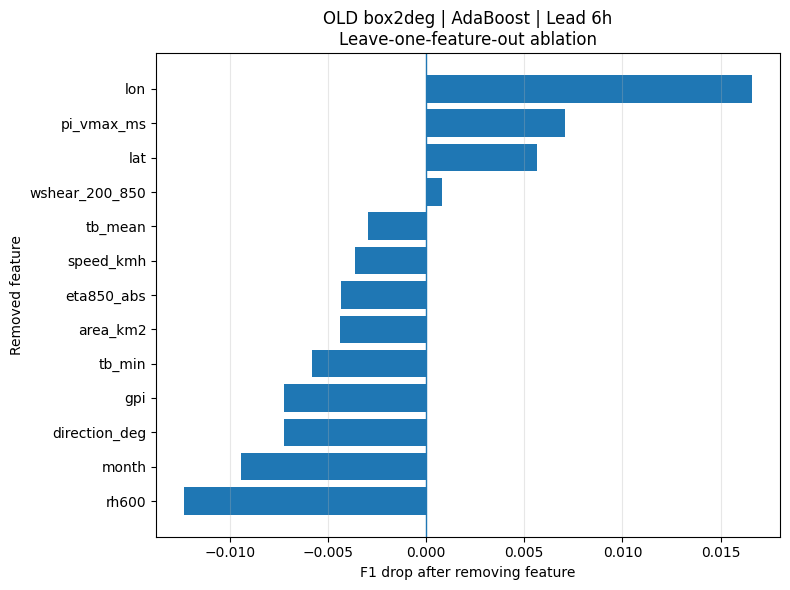

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_AdaBoost_6h.png


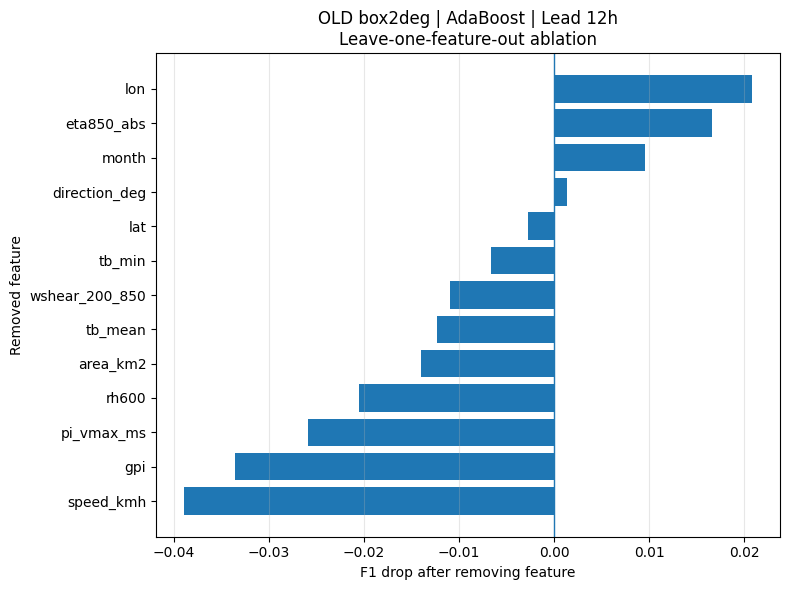

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_AdaBoost_12h.png


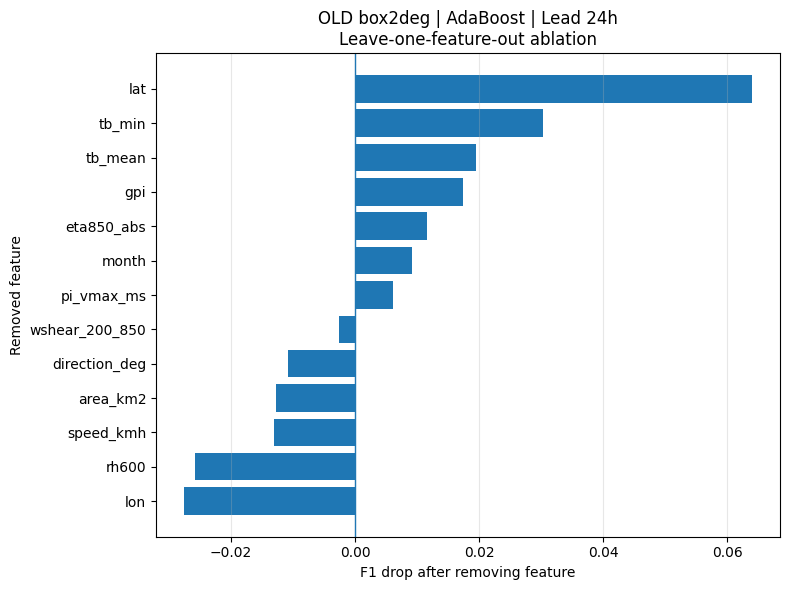

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_AdaBoost_24h.png


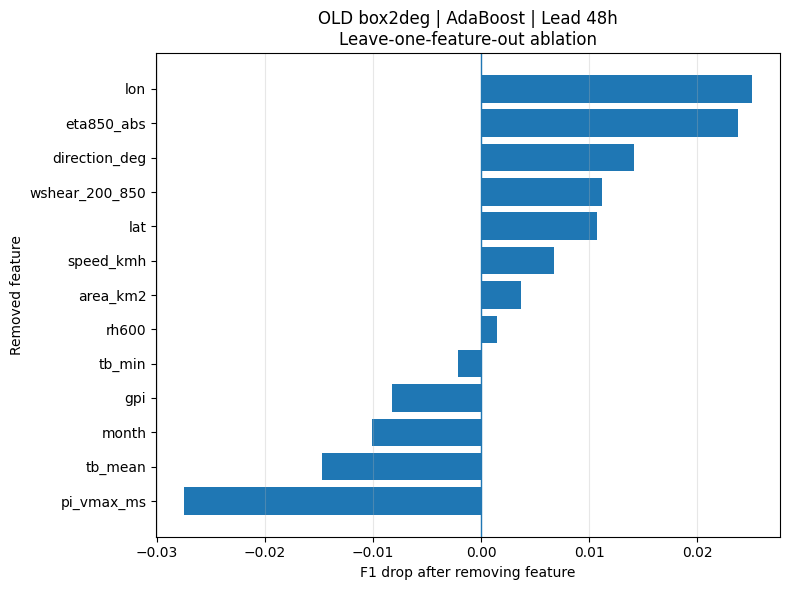

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_AdaBoost_48h.png


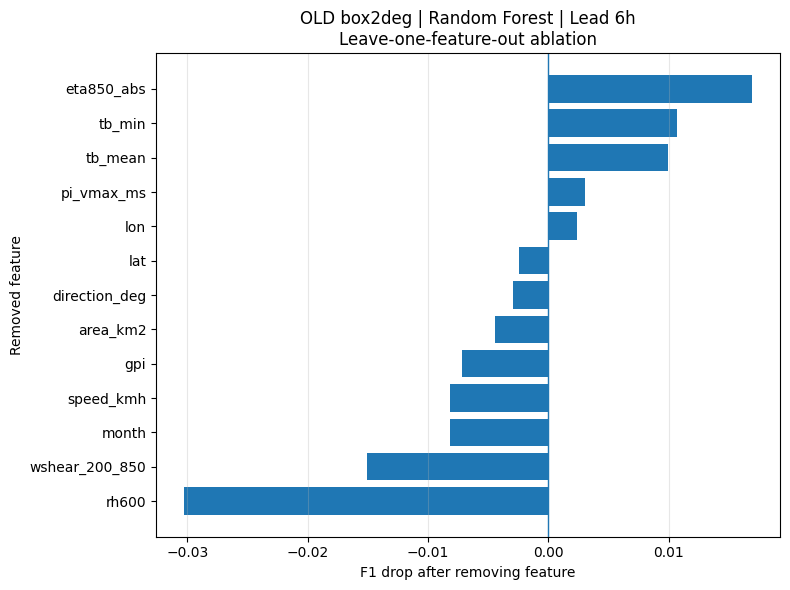

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Random_Forest_6h.png


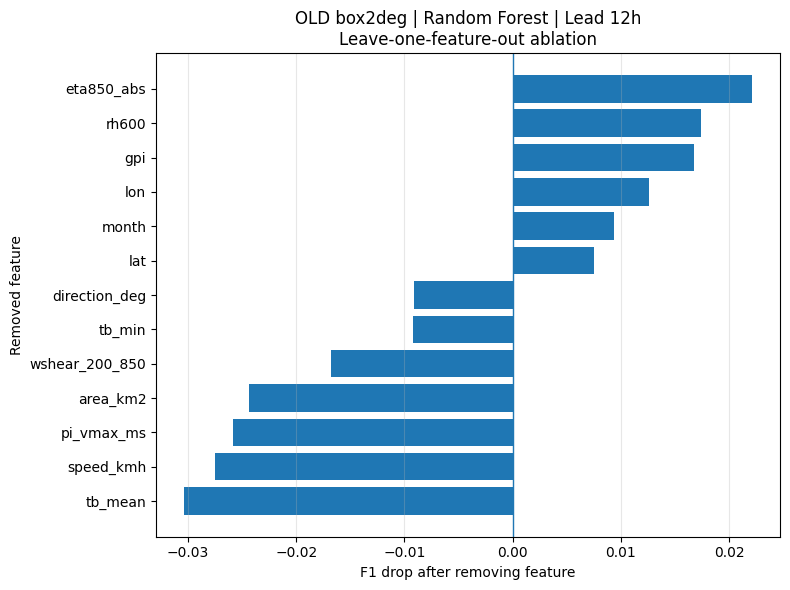

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Random_Forest_12h.png


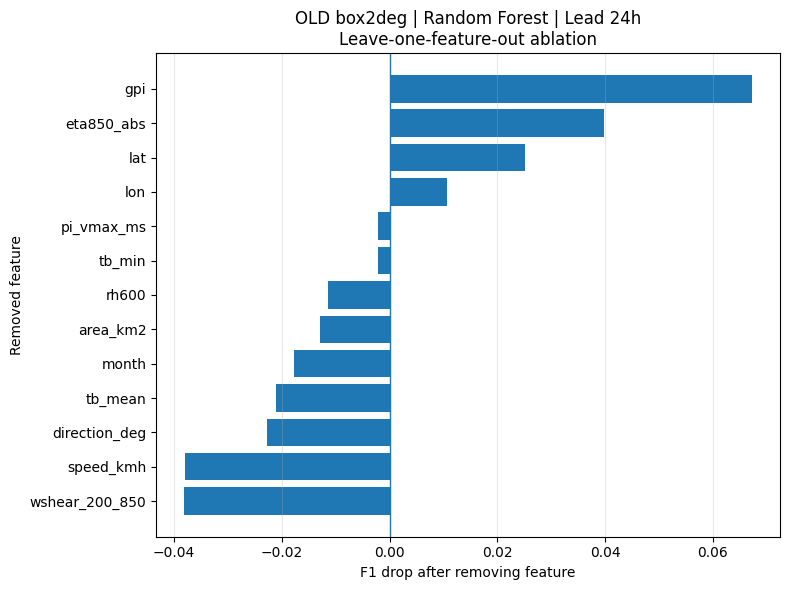

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Random_Forest_24h.png


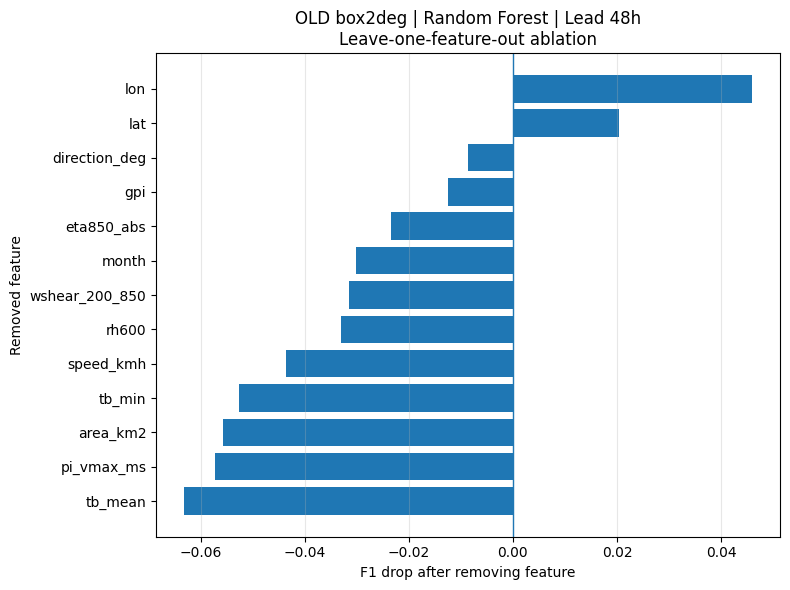

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Random_Forest_48h.png


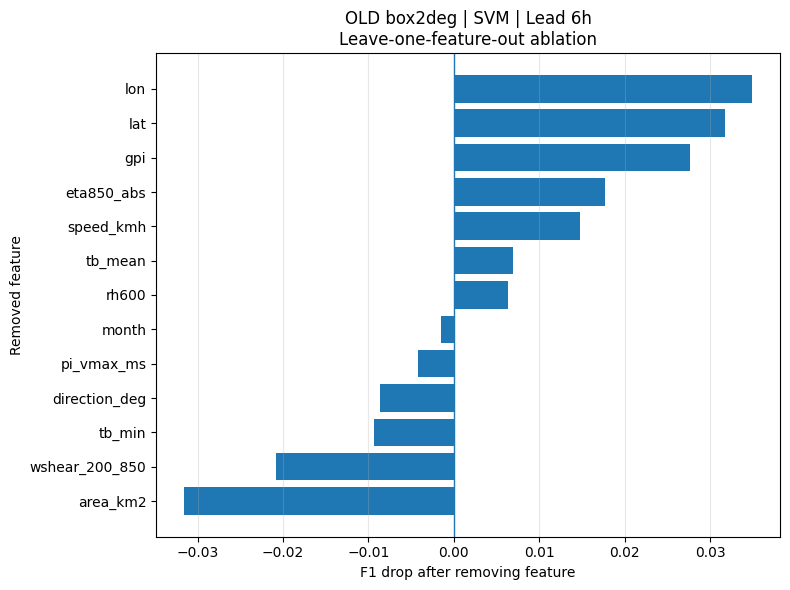

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_SVM_6h.png


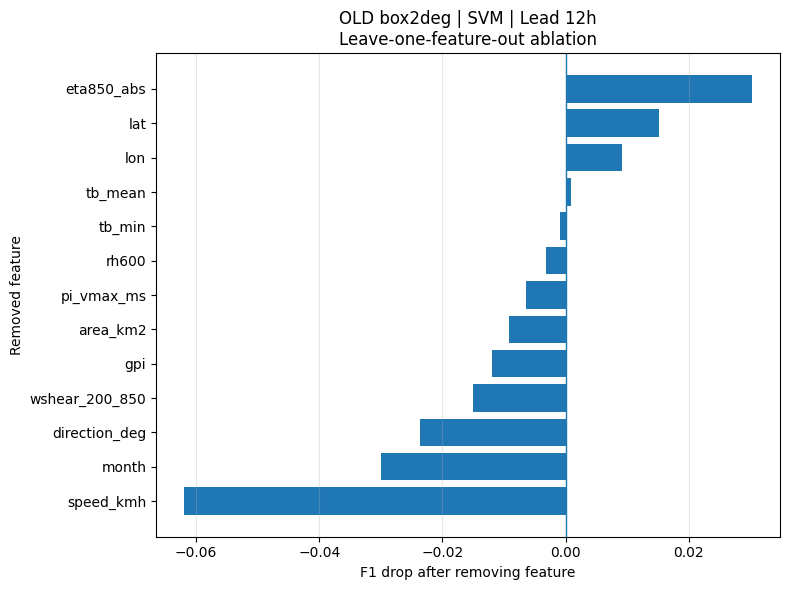

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_SVM_12h.png


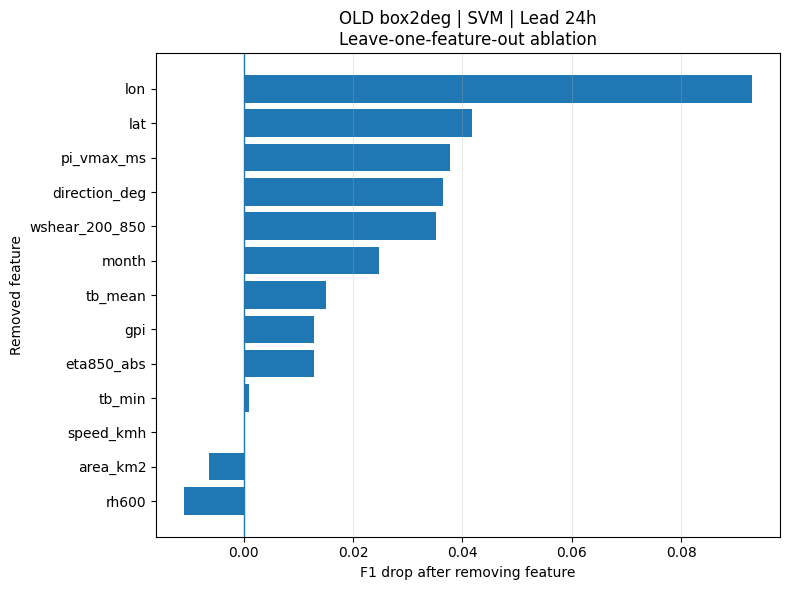

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_SVM_24h.png


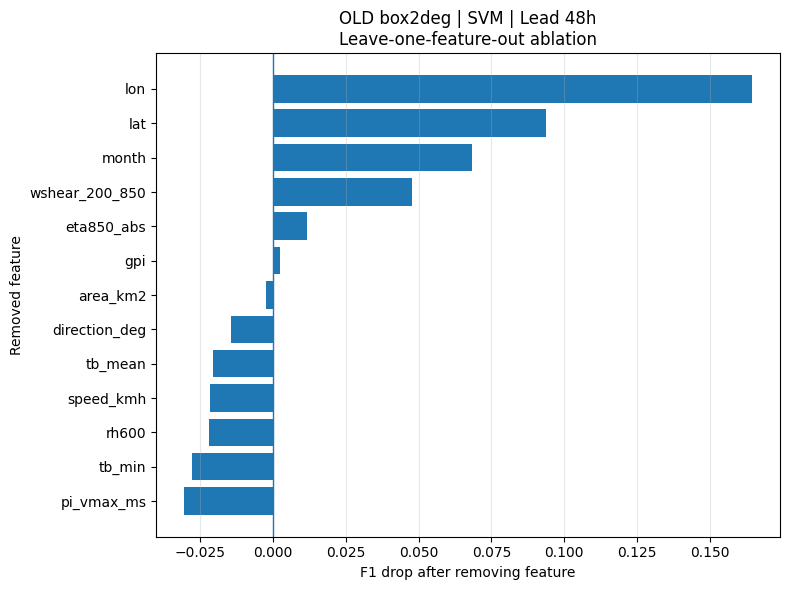

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_SVM_48h.png


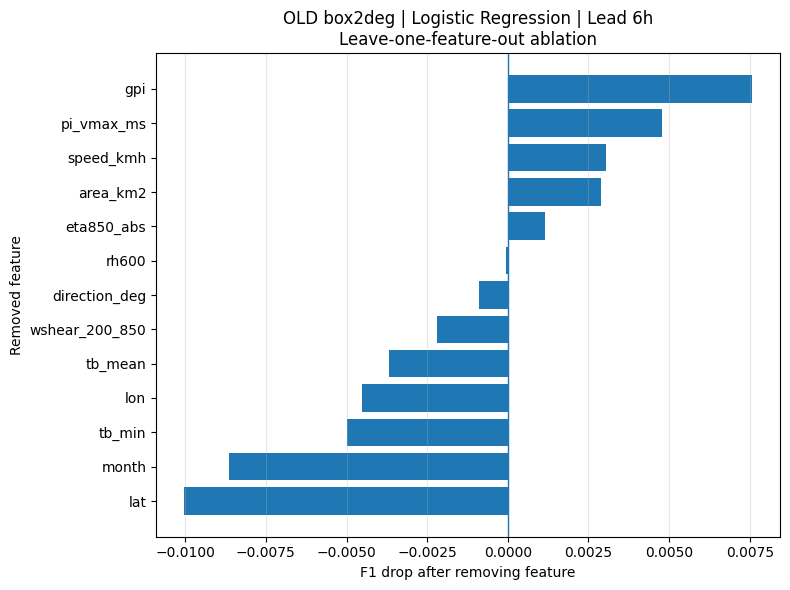

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Logistic_Regression_6h.png


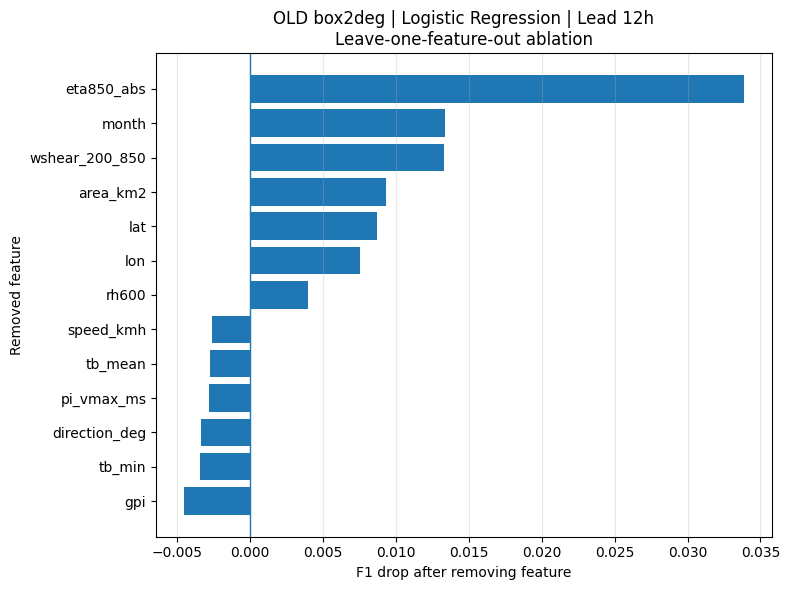

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Logistic_Regression_12h.png


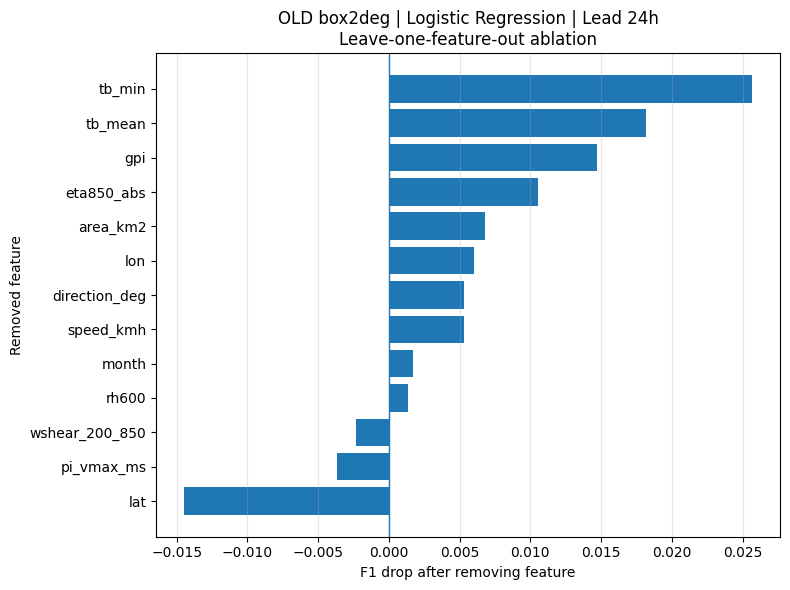

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Logistic_Regression_24h.png


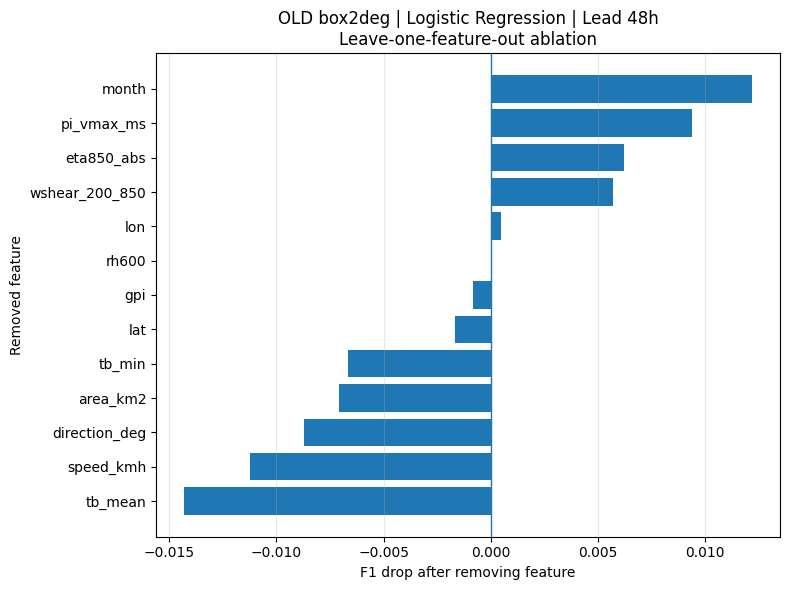

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Logistic_Regression_48h.png


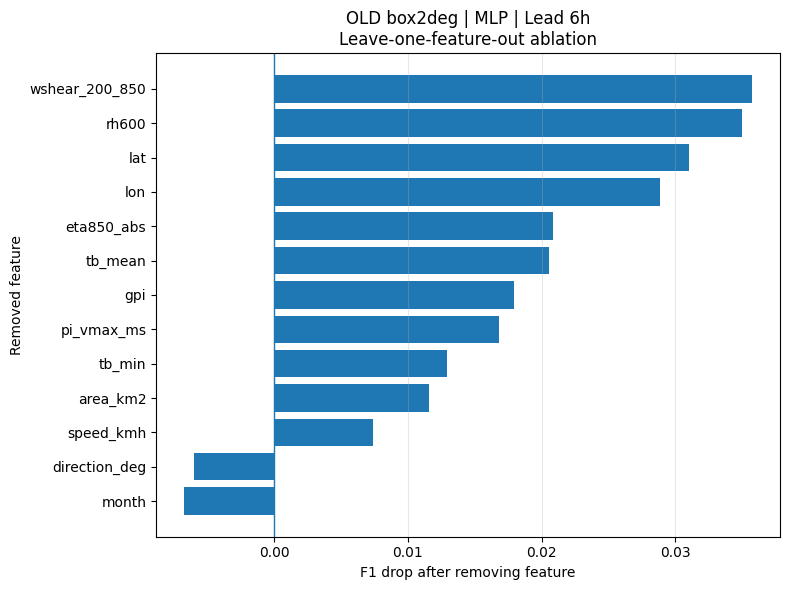

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_MLP_6h.png


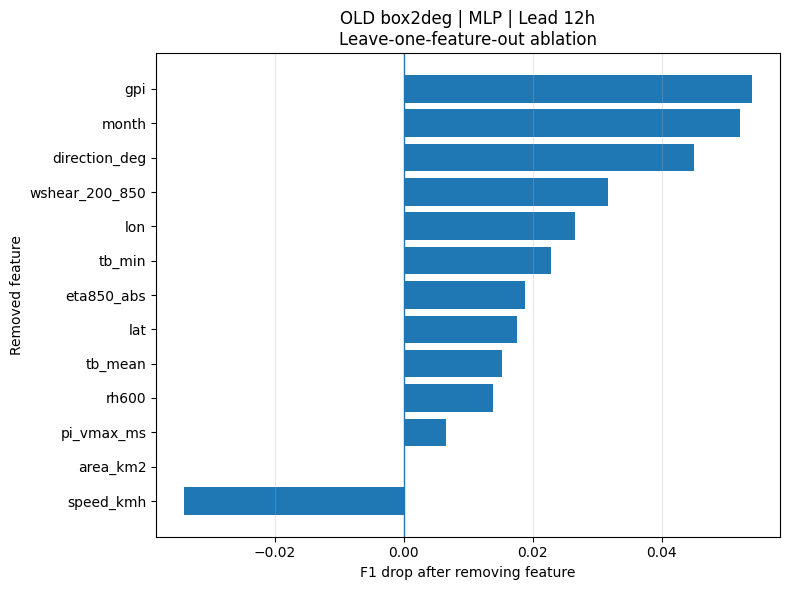

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_MLP_12h.png


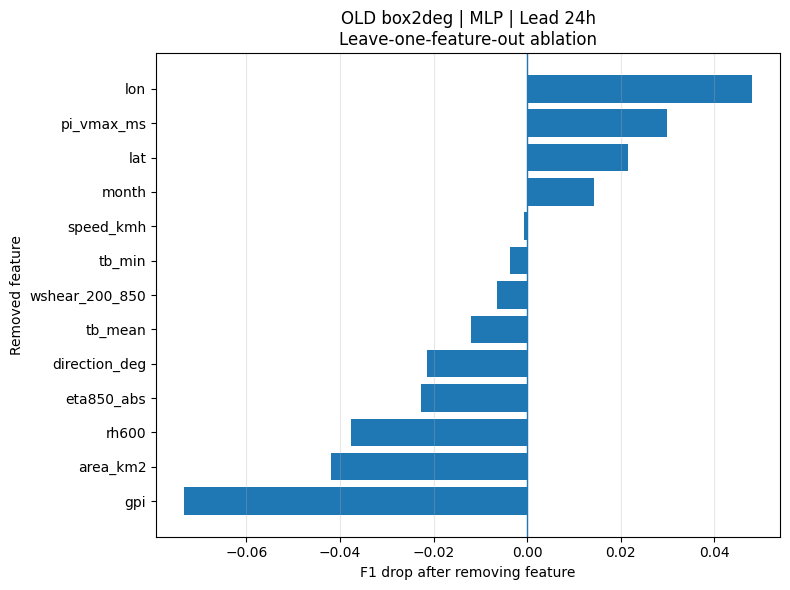

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_MLP_24h.png


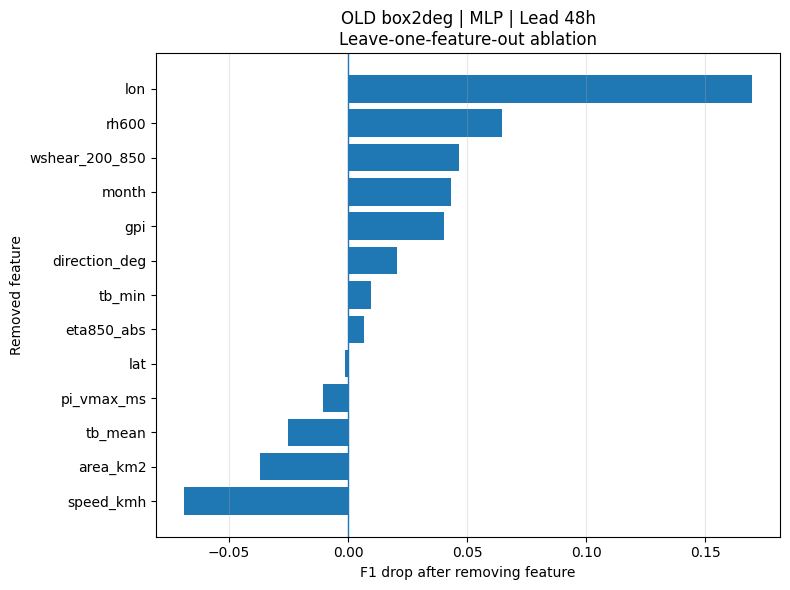

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_MLP_48h.png


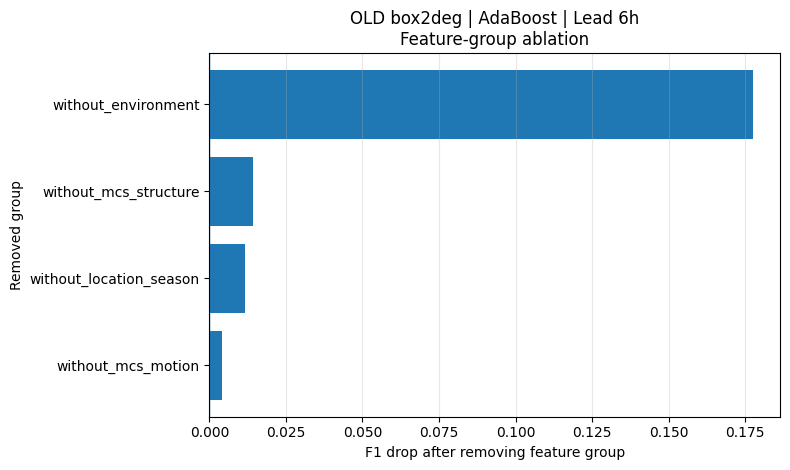

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_AdaBoost_6h.png


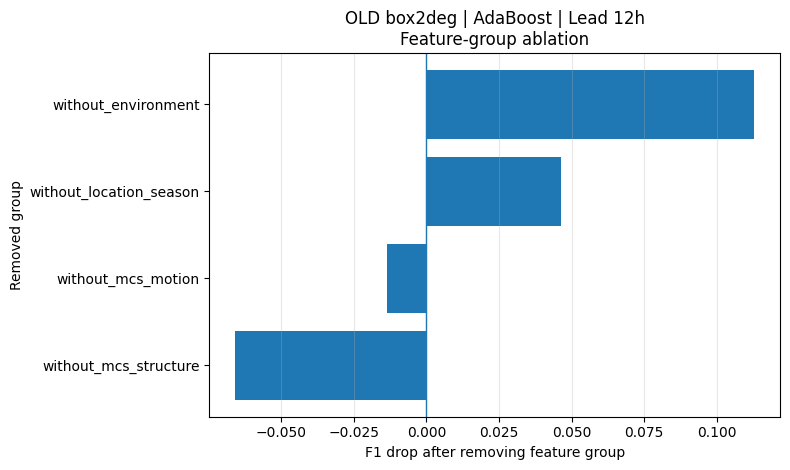

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_AdaBoost_12h.png


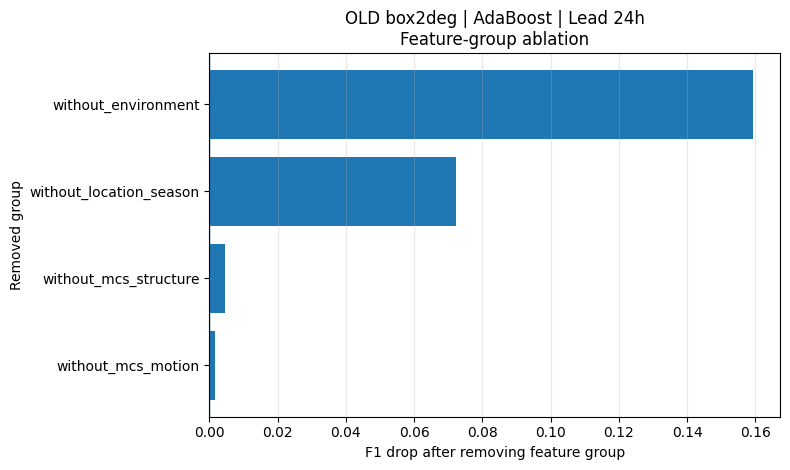

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_AdaBoost_24h.png


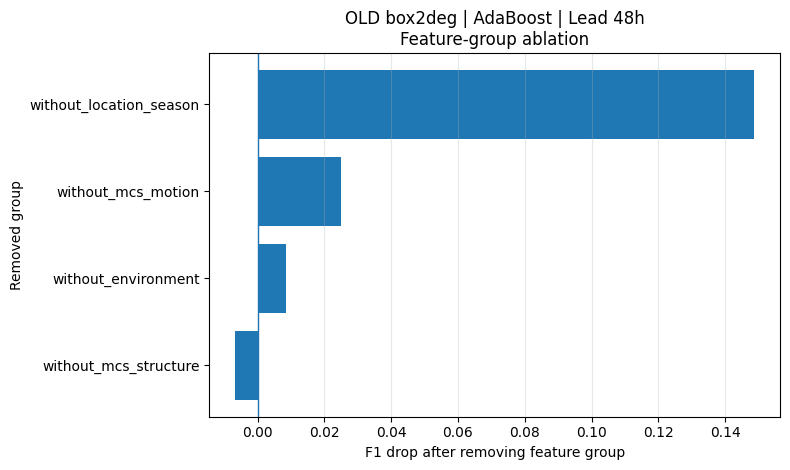

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_AdaBoost_48h.png


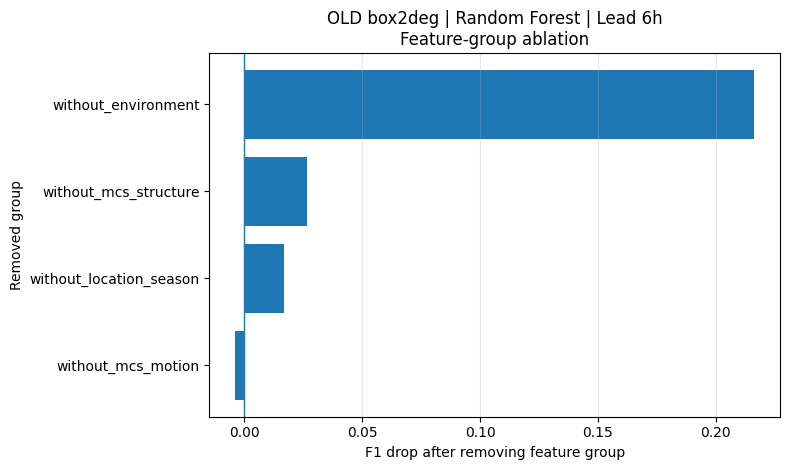

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Random_Forest_6h.png


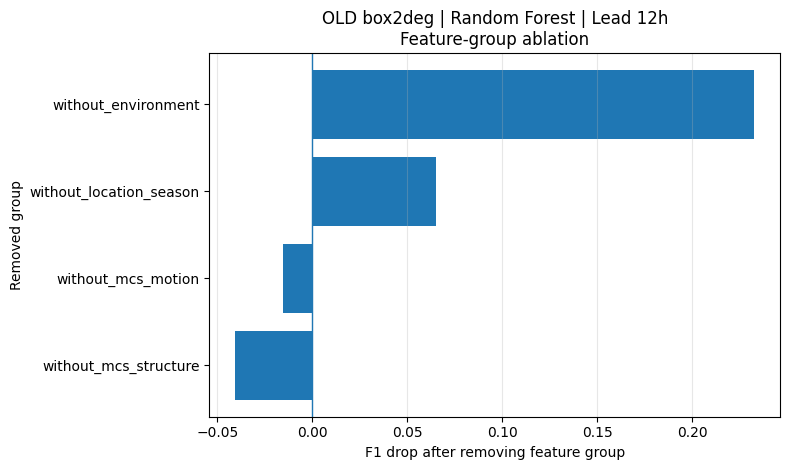

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Random_Forest_12h.png


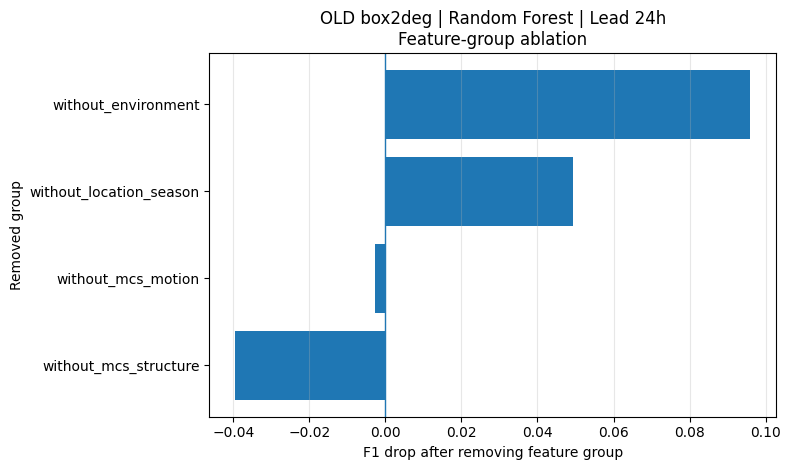

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Random_Forest_24h.png


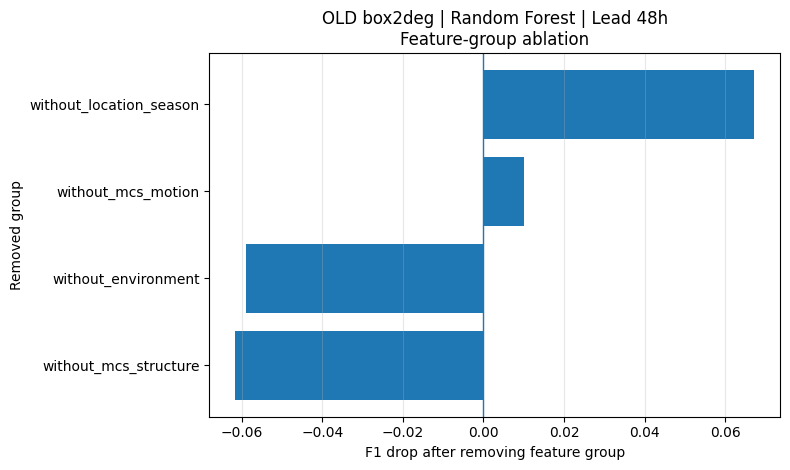

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Random_Forest_48h.png


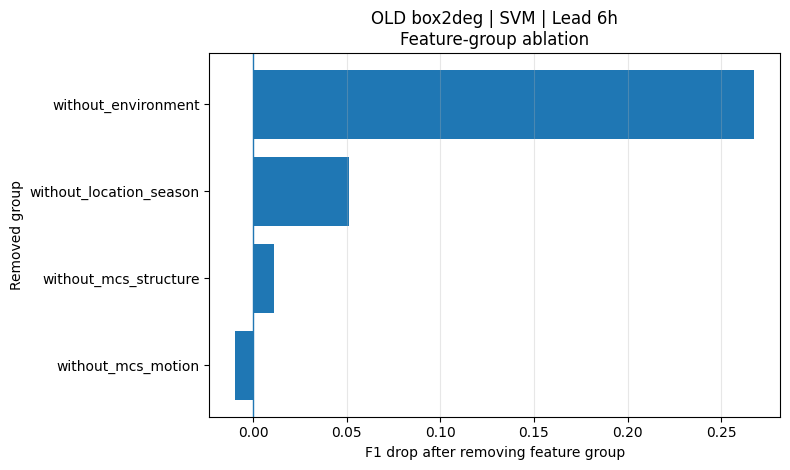

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_SVM_6h.png


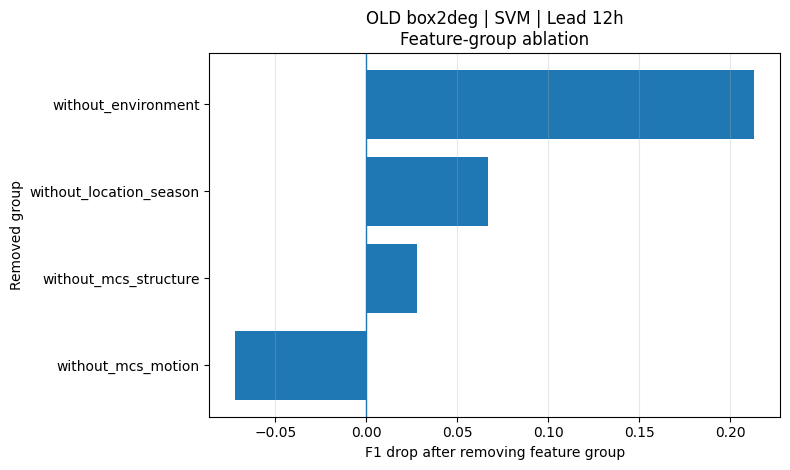

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_SVM_12h.png


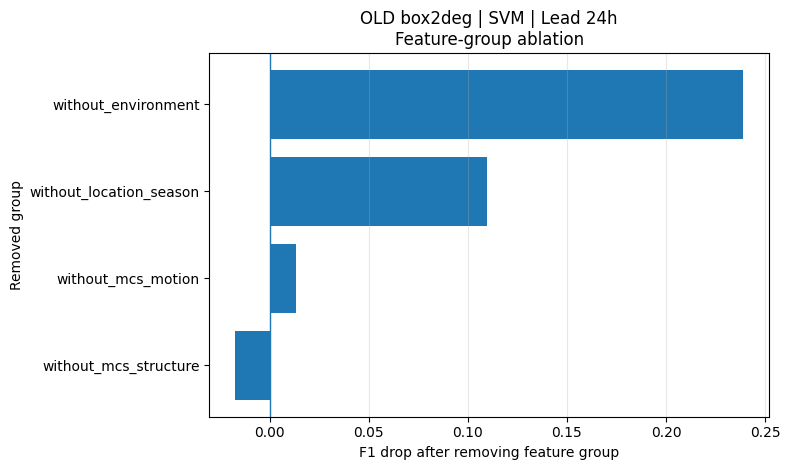

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_SVM_24h.png


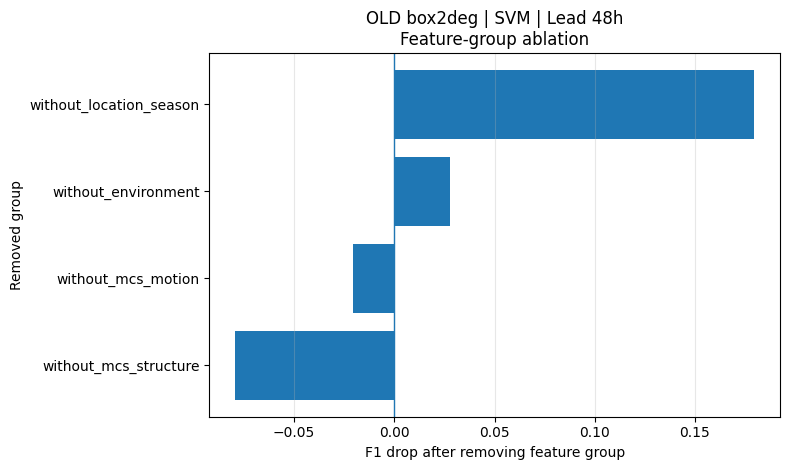

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_SVM_48h.png


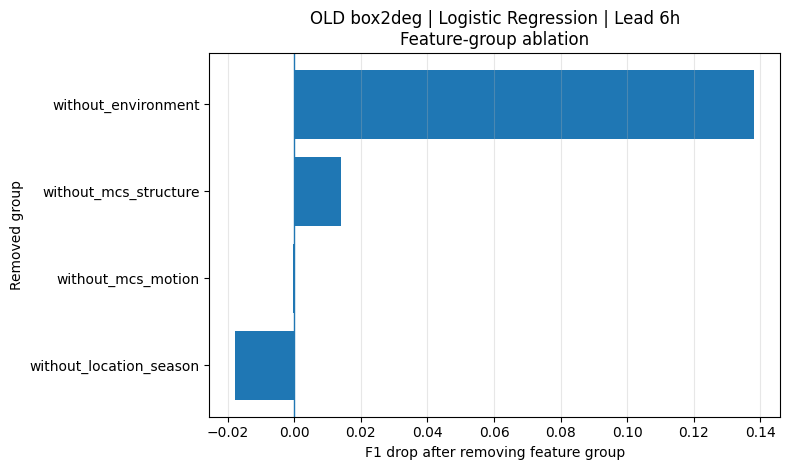

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Logistic_Regression_6h.png


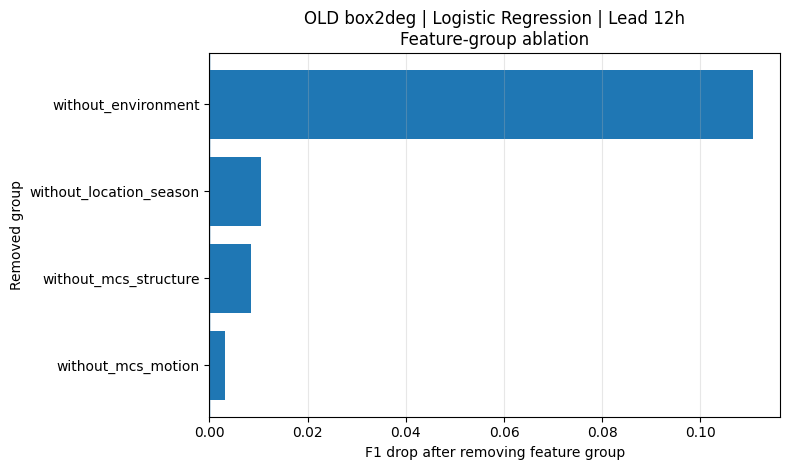

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Logistic_Regression_12h.png


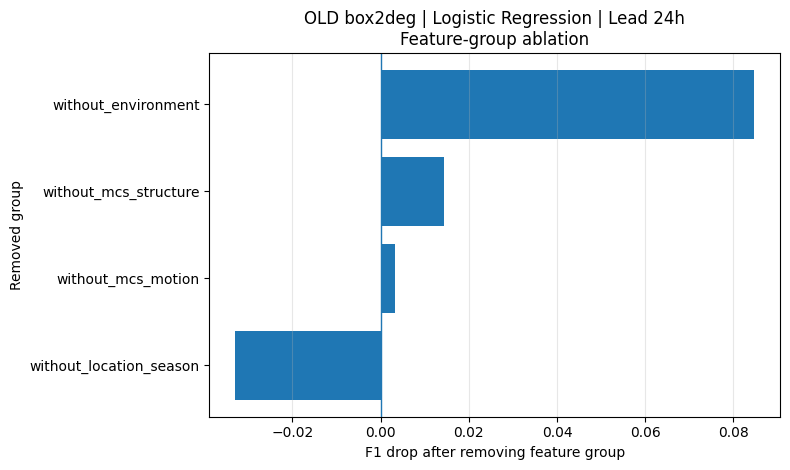

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Logistic_Regression_24h.png


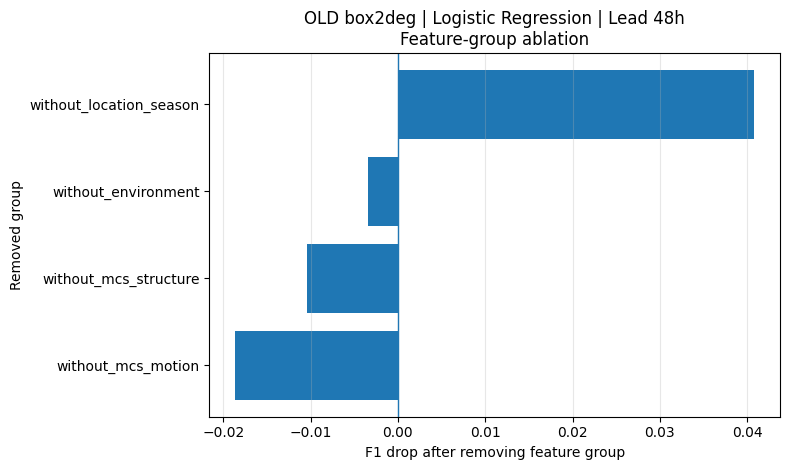

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Logistic_Regression_48h.png


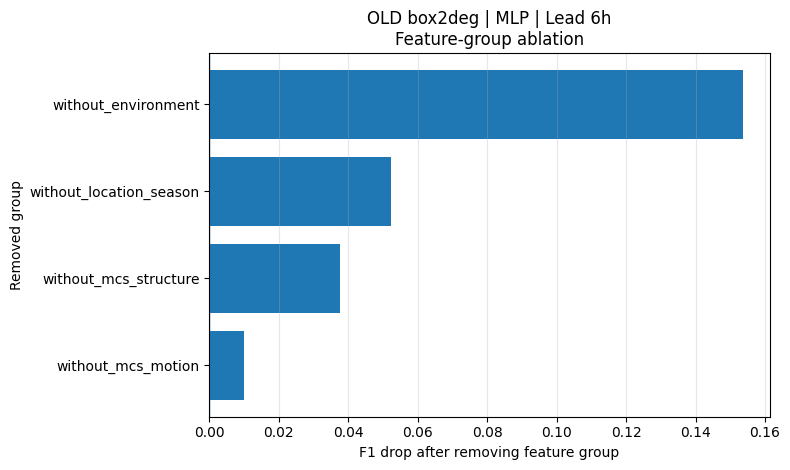

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_MLP_6h.png


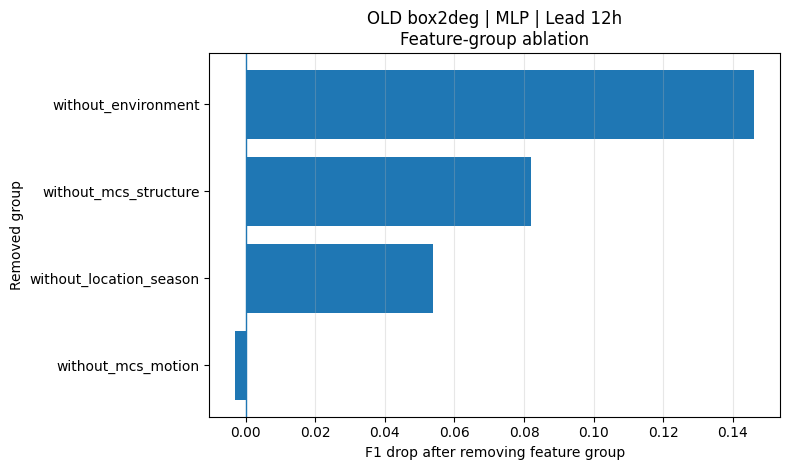

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_MLP_12h.png


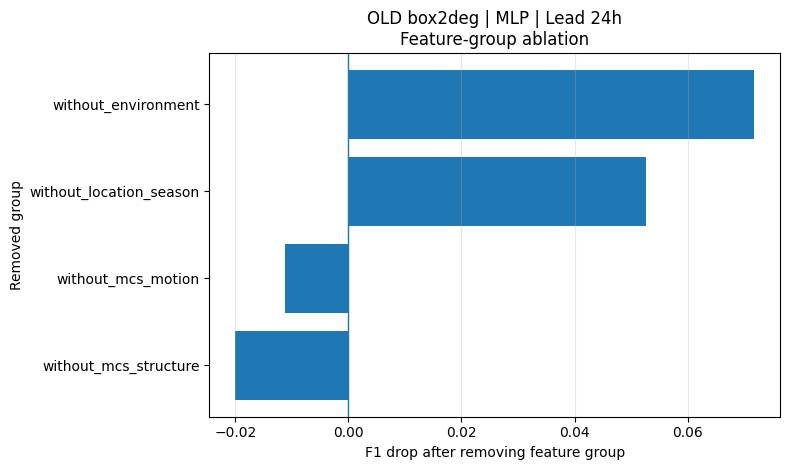

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_MLP_24h.png


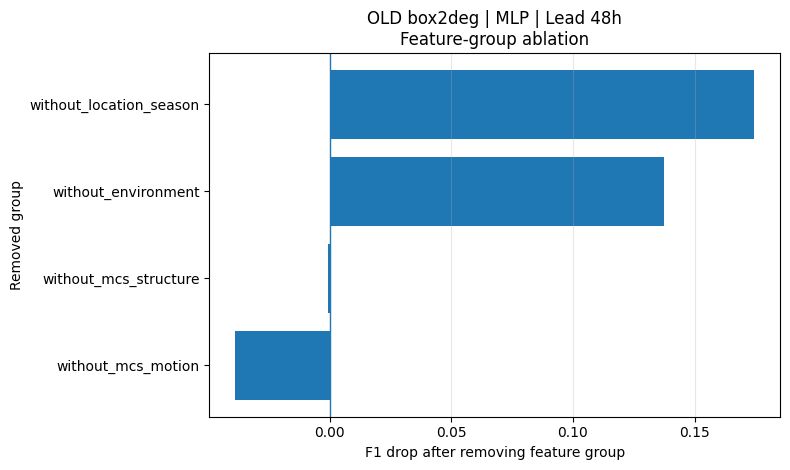

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_MLP_48h.png

[DONE] Feature ablation complete.
Main table:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_impact_vs_baseline.csv


In [ ]:
# ============================================================
# FEATURE ABLATION — LEAVE-ONE-FEATURE-OUT
# Compatible with ML_CHECK_LATEST structure
#
# What this does:
#   1. Uses the same CASE_DIR, OUT_DIR, LEADS, FEATURE_COLS
#   2. Uses the same get_models(), make_pipeline(), get_cv(),
#      safe_metrics(), and threshold_scan() functions
#   3. Retrains the selected model after removing one feature
#   4. Compares each ablation against the full-feature baseline
#   5. Saves CSV tables and plots
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone



# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
ABLATION_DIR = OUT_DIR / "feature_ablation"
ABLATION_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Choose models for ablation
# Start with AdaBoost because it is the main Zhang-style model.
# You can add "Random Forest" later if needed.
# ------------------------------------------------------------
ABLATION_MODEL_NAMES = [
    "AdaBoost",
    "Random Forest",
    "SVM",
    "Logistic Regression",
    "MLP",
]

# ------------------------------------------------------------
# Load case tables if datasets is not already loaded
# ------------------------------------------------------------
try:
    datasets
    print("Using existing datasets dictionary.")
except NameError:
    print("datasets not found. Loading case tables from CASE_DIR...")

    datasets = {}

    for L in LEADS:
        fp = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

        if not fp.exists():
            raise FileNotFoundError(fp)

        df = pd.read_csv(fp)
        df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)
        df["y"] = df["y"].astype(int)

        datasets[L] = df.copy()

        print(
            f"Lead {L}h | rows={len(df)} | "
            f"positive={int(df['y'].sum())} | "
            f"negative={int((df['y'] == 0).sum())}"
        )

# ------------------------------------------------------------
# Feature ablation specifications
# ------------------------------------------------------------
ABLATION_SPECS = []

# Baseline: all features
ABLATION_SPECS.append({
    "ablation_type": "baseline",
    "ablation_name": "all_features",
    "removed_features": [],
})

# Individual leave-one-feature-out
for f in FEATURE_COLS:
    ABLATION_SPECS.append({
        "ablation_type": "leave_one_feature_out",
        "ablation_name": f"without_{f}",
        "removed_features": [f],
    })

# Optional physical group ablations
GROUP_ABLATIONS = {
    "without_location_season": ["lon", "lat", "month"],
    "without_mcs_structure": ["area_km2", "tb_mean", "tb_min"],
    "without_mcs_motion": ["speed_kmh", "direction_deg"],
    "without_environment": ["eta850_abs", "rh600", "wshear_200_850", "pi_vmax_ms", "gpi"],
}

for group_name, removed in GROUP_ABLATIONS.items():
    removed_existing = [f for f in removed if f in FEATURE_COLS]

    if len(removed_existing) > 0:
        ABLATION_SPECS.append({
            "ablation_type": "feature_group_out",
            "ablation_name": group_name,
            "removed_features": removed_existing,
        })

print("Number of ablation settings:", len(ABLATION_SPECS))

# ------------------------------------------------------------
# Helper: run one ablation with CV
# ------------------------------------------------------------
def run_one_ablation_cv(
    case_df,
    lead_h,
    model_name,
    model,
    feature_cols_used,
    ablation_type,
    ablation_name,
    removed_features,
    dataset_name=DATASET_NAME,
    label_name=LABEL_NAME,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS
):
    df = case_df.copy()

    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)

    X = df[feature_cols_used].copy()
    y = df["y"].astype(int).values

    groups = df["track_id"].astype(str).values if "track_id" in df.columns else None

    cv, cv_name, n_splits_eff = get_cv(
        y=y,
        groups=groups,
        n_splits=n_splits,
        random_state=random_state
    )

    pipe = make_pipeline(model_name, clone(model))

    fold_rows = []
    oof_rows = []

    if groups is not None:
        splitter = cv.split(X, y, groups)
    else:
        splitter = cv.split(X, y)

    for fold_id, (train_idx, test_idx) in enumerate(splitter, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        pipe.fit(X_train, y_train)

        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        else:
            y_score = pipe.decision_function(X_test)
            y_score = (
                y_score - np.nanmin(y_score)
            ) / (
                np.nanmax(y_score) - np.nanmin(y_score) + 1e-12
            )

        fold_metric = safe_metrics(y_test, y_score, threshold=0.5)

        fold_metric.update({
            "dataset": dataset_name,
            "label": label_name,
            "lead_h": lead_h,
            "model": model_name,
            "ablation_type": ablation_type,
            "ablation_name": ablation_name,
            "removed_features": ",".join(removed_features) if removed_features else "none",
            "n_features_used": len(feature_cols_used),
            "fold": fold_id,
            "cv": cv_name,
            "n_splits": n_splits_eff,
            "train_n": len(train_idx),
            "test_n": len(test_idx),
            "train_pos": int(y_train.sum()),
            "test_pos": int(y_test.sum()),
            "train_neg": int((y_train == 0).sum()),
            "test_neg": int((y_test == 0).sum()),
        })

        fold_rows.append(fold_metric)

        oof = pd.DataFrame({
            "dataset": dataset_name,
            "label": label_name,
            "lead_h": lead_h,
            "model": model_name,
            "ablation_type": ablation_type,
            "ablation_name": ablation_name,
            "removed_features": ",".join(removed_features) if removed_features else "none",
            "fold": fold_id,
            "y_true": y_test,
            "y_score": y_score,
            "y_pred_default": (y_score >= 0.5).astype(int),
        })

        if all(c in df.columns for c in ID_COLS):
            id_part = df.iloc[test_idx][ID_COLS].reset_index(drop=True)
            oof = pd.concat([id_part, oof.reset_index(drop=True)], axis=1)

        oof_rows.append(oof)

    fold_df = pd.DataFrame(fold_rows)
    oof_df = pd.concat(oof_rows, ignore_index=True)

    # ------------------------------------------------------------
    # OOF default-threshold metrics
    # ------------------------------------------------------------
    default_metrics = safe_metrics(
        oof_df["y_true"].values,
        oof_df["y_score"].values,
        threshold=0.5
    )

    # ------------------------------------------------------------
    # OOF tuned-threshold metrics
    # ------------------------------------------------------------
    scan = threshold_scan(
        oof_df["y_true"].values,
        oof_df["y_score"].values
    )

    if len(scan) > 0:
        best_tuned = scan.iloc[0].to_dict()
    else:
        best_tuned = {
            "threshold": np.nan,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "roc_auc": np.nan,
            "pr_auc": np.nan,
        }

    summary_row = {
        "dataset": dataset_name,
        "label": label_name,
        "lead_h": lead_h,
        "model": model_name,
        "ablation_type": ablation_type,
        "ablation_name": ablation_name,
        "removed_features": ",".join(removed_features) if removed_features else "none",
        "features_used": ",".join(feature_cols_used),
        "n_features_used": len(feature_cols_used),
        "cv": cv_name,
        "n_splits": n_splits_eff,
        "n_samples": len(df),
        "n_positive": int(np.sum(y == 1)),
        "n_negative": int(np.sum(y == 0)),

        "threshold_default": 0.5,
        "accuracy_default": default_metrics["accuracy"],
        "precision_default": default_metrics["precision"],
        "recall_default": default_metrics["recall"],
        "f1_default": default_metrics["f1"],
        "roc_auc_default": default_metrics["roc_auc"],
        "pr_auc_default": default_metrics["pr_auc"],
        "tn_default": default_metrics["tn"],
        "fp_default": default_metrics["fp"],
        "fn_default": default_metrics["fn"],
        "tp_default": default_metrics["tp"],

        "threshold_tuned": best_tuned.get("threshold", np.nan),
        "accuracy_tuned": best_tuned.get("accuracy", np.nan),
        "precision_tuned": best_tuned.get("precision", np.nan),
        "recall_tuned": best_tuned.get("recall", np.nan),
        "f1_tuned": best_tuned.get("f1", np.nan),
        "roc_auc_tuned": best_tuned.get("roc_auc", np.nan),
        "pr_auc_tuned": best_tuned.get("pr_auc", np.nan),
    }

    scan["dataset"] = dataset_name
    scan["label"] = label_name
    scan["lead_h"] = lead_h
    scan["model"] = model_name
    scan["ablation_type"] = ablation_type
    scan["ablation_name"] = ablation_name
    scan["removed_features"] = ",".join(removed_features) if removed_features else "none"

    return fold_df, oof_df, pd.DataFrame([summary_row]), scan


# ------------------------------------------------------------
# Run ablation
# ------------------------------------------------------------
models_all = get_models(random_state=RANDOM_STATE)

missing_models = [m for m in ABLATION_MODEL_NAMES if m not in models_all]
if missing_models:
    raise ValueError(
        f"These models are not available in get_models(): {missing_models}\n"
        f"Available models: {list(models_all.keys())}"
    )

all_ablation_folds = []
all_ablation_oof = []
all_ablation_summary = []
all_ablation_scans = []

for L in LEADS:
    case_df = datasets[L].copy()

    print("\n" + "=" * 90)
    print(
        f"FEATURE ABLATION | lead={L}h | "
        f"rows={len(case_df)} | positives={int(case_df['y'].sum())}"
    )
    print("=" * 90)

    for model_name in ABLATION_MODEL_NAMES:
        base_model = models_all[model_name]

        print(f"\nModel: {model_name}")

        for spec in ABLATION_SPECS:
            removed = spec["removed_features"]
            feature_cols_used = [f for f in FEATURE_COLS if f not in removed]

            if len(feature_cols_used) == 0:
                print(f"[SKIP] {spec['ablation_name']} removes all features.")
                continue

            print(
                f"  Running {spec['ablation_name']} "
                f"({len(feature_cols_used)} features)"
            )

            try:
                fold_df, oof_df, summary_df, scan_df = run_one_ablation_cv(
                    case_df=case_df,
                    lead_h=L,
                    model_name=model_name,
                    model=base_model,
                    feature_cols_used=feature_cols_used,
                    ablation_type=spec["ablation_type"],
                    ablation_name=spec["ablation_name"],
                    removed_features=removed,
                    dataset_name=DATASET_NAME,
                    label_name=LABEL_NAME,
                    random_state=RANDOM_STATE,
                    n_splits=N_SPLITS
                )

                all_ablation_folds.append(fold_df)
                all_ablation_oof.append(oof_df)
                all_ablation_summary.append(summary_df)
                all_ablation_scans.append(scan_df)

            except Exception as e:
                print(f"  [ERROR] {model_name} | lead {L}h | {spec['ablation_name']}: {e}")

                err = pd.DataFrame([{
                    "dataset": DATASET_NAME,
                    "label": LABEL_NAME,
                    "lead_h": L,
                    "model": model_name,
                    "ablation_type": spec["ablation_type"],
                    "ablation_name": spec["ablation_name"],
                    "removed_features": ",".join(removed) if removed else "none",
                    "error": str(e),
                }])

                all_ablation_summary.append(err)

# ------------------------------------------------------------
# Save raw outputs
# ------------------------------------------------------------
ablation_folds = pd.concat(all_ablation_folds, ignore_index=True)
ablation_oof = pd.concat(all_ablation_oof, ignore_index=True)
ablation_summary = pd.concat(all_ablation_summary, ignore_index=True)
ablation_scans = pd.concat(all_ablation_scans, ignore_index=True)

ablation_folds.to_csv(ABLATION_DIR / "feature_ablation_fold_results.csv", index=False)
ablation_oof.to_csv(ABLATION_DIR / "feature_ablation_oof_predictions.csv", index=False)
ablation_summary.to_csv(ABLATION_DIR / "feature_ablation_summary.csv", index=False)
ablation_scans.to_csv(ABLATION_DIR / "feature_ablation_threshold_scans.csv", index=False)

print("\n[SAVED]")
print(ABLATION_DIR / "feature_ablation_fold_results.csv")
print(ABLATION_DIR / "feature_ablation_oof_predictions.csv")
print(ABLATION_DIR / "feature_ablation_summary.csv")
print(ABLATION_DIR / "feature_ablation_threshold_scans.csv")

# ------------------------------------------------------------
# Compare each ablation against full-feature baseline
# Positive drop means performance became worse after removal.
# ------------------------------------------------------------
summary_ok = ablation_summary[ablation_summary["error"].isna() if "error" in ablation_summary.columns else slice(None)].copy()

baseline = summary_ok[
    summary_ok["ablation_name"] == "all_features"
].copy()

baseline_cols = [
    "lead_h", "model",
    "f1_default", "precision_default", "recall_default",
    "roc_auc_default", "pr_auc_default",
    "f1_tuned", "precision_tuned", "recall_tuned",
    "roc_auc_tuned", "pr_auc_tuned",
]

baseline = baseline[baseline_cols].copy()
baseline = baseline.rename(columns={
    "f1_default": "baseline_f1_default",
    "precision_default": "baseline_precision_default",
    "recall_default": "baseline_recall_default",
    "roc_auc_default": "baseline_roc_auc_default",
    "pr_auc_default": "baseline_pr_auc_default",
    "f1_tuned": "baseline_f1_tuned",
    "precision_tuned": "baseline_precision_tuned",
    "recall_tuned": "baseline_recall_tuned",
    "roc_auc_tuned": "baseline_roc_auc_tuned",
    "pr_auc_tuned": "baseline_pr_auc_tuned",
})

impact = summary_ok.merge(
    baseline,
    on=["lead_h", "model"],
    how="left"
)

impact["drop_f1_default"] = impact["baseline_f1_default"] - impact["f1_default"]
impact["drop_precision_default"] = impact["baseline_precision_default"] - impact["precision_default"]
impact["drop_recall_default"] = impact["baseline_recall_default"] - impact["recall_default"]
impact["drop_roc_auc_default"] = impact["baseline_roc_auc_default"] - impact["roc_auc_default"]
impact["drop_pr_auc_default"] = impact["baseline_pr_auc_default"] - impact["pr_auc_default"]

impact["drop_f1_tuned"] = impact["baseline_f1_tuned"] - impact["f1_tuned"]
impact["drop_precision_tuned"] = impact["baseline_precision_tuned"] - impact["precision_tuned"]
impact["drop_recall_tuned"] = impact["baseline_recall_tuned"] - impact["recall_tuned"]
impact["drop_roc_auc_tuned"] = impact["baseline_roc_auc_tuned"] - impact["roc_auc_tuned"]
impact["drop_pr_auc_tuned"] = impact["baseline_pr_auc_tuned"] - impact["pr_auc_tuned"]

impact = impact.sort_values(
    ["lead_h", "model", "ablation_type", "drop_f1_default"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

impact.to_csv(ABLATION_DIR / "feature_ablation_impact_vs_baseline.csv", index=False)

print("\nFeature ablation impact table:")
display(
    impact[
        [
            "lead_h", "model", "ablation_type", "ablation_name", "removed_features",
            "baseline_f1_default", "f1_default", "drop_f1_default",
            "baseline_pr_auc_default", "pr_auc_default", "drop_pr_auc_default",
            "baseline_f1_tuned", "f1_tuned", "drop_f1_tuned",
        ]
    ]
)

# ------------------------------------------------------------
# Save ranked individual-feature ablation table
# ------------------------------------------------------------
individual_impact = impact[
    impact["ablation_type"] == "leave_one_feature_out"
].copy()

individual_impact = individual_impact.sort_values(
    ["lead_h", "model", "drop_f1_default"],
    ascending=[True, True, False]
)

individual_impact.to_csv(
    ABLATION_DIR / "feature_ablation_individual_ranked_by_drop_f1.csv",
    index=False
)

print("\nIndividual feature ablation ranked by F1 drop:")
display(
    individual_impact[
        [
            "lead_h", "model", "removed_features",
            "f1_default", "drop_f1_default",
            "pr_auc_default", "drop_pr_auc_default",
            "roc_auc_default", "drop_roc_auc_default",
        ]
    ]
)

# ------------------------------------------------------------
# Pivot table: F1 drop by feature and lead
# ------------------------------------------------------------
for model_name in ABLATION_MODEL_NAMES:
    sub = individual_impact[individual_impact["model"] == model_name].copy()

    if len(sub) == 0:
        continue

    pivot_drop_f1 = sub.pivot(
        index="removed_features",
        columns="lead_h",
        values="drop_f1_default"
    )

    pivot_drop_f1 = pivot_drop_f1.reindex(
        pivot_drop_f1.mean(axis=1).sort_values(ascending=False).index
    )

    safe_model = model_name.replace(" ", "_").replace("/", "_")

    pivot_fp = ABLATION_DIR / f"feature_ablation_pivot_drop_f1_{safe_model}.csv"
    pivot_drop_f1.to_csv(pivot_fp)

    print(f"\nF1 drop pivot table — {model_name}:")
    display(pivot_drop_f1)

# ------------------------------------------------------------
# Plots: individual feature F1 drop by lead/model
# ------------------------------------------------------------
for model_name in ABLATION_MODEL_NAMES:
    for L in LEADS:
        sub = individual_impact[
            (individual_impact["model"] == model_name)
            & (individual_impact["lead_h"] == L)
        ].copy()

        if len(sub) == 0:
            continue

        sub = sub.sort_values("drop_f1_default", ascending=True)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(sub["removed_features"], sub["drop_f1_default"])
        ax.axvline(0, linewidth=1)
        ax.set_xlabel("F1 drop after removing feature")
        ax.set_ylabel("Removed feature")
        ax.set_title(
            f"{DATASET_NAME.upper()} {LABEL_NAME} | {model_name} | Lead {L}h\n"
            "Leave-one-feature-out ablation"
        )
        ax.grid(True, axis="x", alpha=0.3)

        plt.tight_layout()

        safe_model = model_name.replace(" ", "_").replace("/", "_")
        out_png = ABLATION_DIR / f"feature_ablation_drop_f1_{safe_model}_{L}h.png"

        plt.savefig(out_png, dpi=220, bbox_inches="tight")
        plt.show()

        print("Saved:", out_png)

# ------------------------------------------------------------
# Plots: feature-group ablation
# ------------------------------------------------------------
group_impact = impact[
    impact["ablation_type"] == "feature_group_out"
].copy()

if len(group_impact) > 0:
    for model_name in ABLATION_MODEL_NAMES:
        for L in LEADS:
            sub = group_impact[
                (group_impact["model"] == model_name)
                & (group_impact["lead_h"] == L)
            ].copy()

            if len(sub) == 0:
                continue

            sub = sub.sort_values("drop_f1_default", ascending=True)

            fig, ax = plt.subplots(figsize=(8, 4.8))
            ax.barh(sub["ablation_name"], sub["drop_f1_default"])
            ax.axvline(0, linewidth=1)
            ax.set_xlabel("F1 drop after removing feature group")
            ax.set_ylabel("Removed group")
            ax.set_title(
                f"{DATASET_NAME.upper()} {LABEL_NAME} | {model_name} | Lead {L}h\n"
                "Feature-group ablation"
            )
            ax.grid(True, axis="x", alpha=0.3)

            plt.tight_layout()

            safe_model = model_name.replace(" ", "_").replace("/", "_")
            out_png = ABLATION_DIR / f"feature_group_ablation_drop_f1_{safe_model}_{L}h.png"

            plt.savefig(out_png, dpi=220, bbox_inches="tight")
            plt.show()

            print("Saved:", out_png)

print("\n[DONE] Feature ablation complete.")
print("Main table:")
print(ABLATION_DIR / "feature_ablation_impact_vs_baseline.csv")

Naive Bayes

Using existing datasets dictionary.
Number of ablation settings: 18

FEATURE ABLATION | lead=6h | rows=1338 | positives=223

Model: Naive Bayes
  Running all_features (13 features)
  Running without_lon (12 features)
  Running without_lat (12 features)
  Running without_month (12 features)
  Running without_area_km2 (12 features)
  Running without_tb_mean (12 features)
  Running without_tb_min (12 features)
  Running without_speed_kmh (12 features)
  Running without_direction_deg (12 features)
  Running without_eta850_abs (12 features)
  Running without_rh600 (12 features)
  Running without_wshear_200_850 (12 features)
  Running without_pi_vmax_ms (12 features)
  Running without_gpi (12 features)
  Running without_location_season (10 features)
  Running without_mcs_structure (10 features)
  Running without_mcs_motion (11 features)
  Running without_environment (8 features)

FEATURE ABLATION | lead=12h | rows=1242 | positives=207

Model: Naive Bayes
  Running all_features (13 features)


,lead_h,model,ablation_type,ablation_name,removed_features,baseline_f1_default,f1_default,drop_f1_default,baseline_pr_auc_default,pr_auc_default,drop_pr_auc_default,baseline_f1_tuned,f1_tuned,drop_f1_tuned
0,6,Naive Bayes,baseline,all_features,none,0.569343,0.569343,0.000000,0.544356,0.544356,0.000000,0.606897,0.606897,0.000000
1,6,Naive Bayes,feature_group_out,without_environment,"eta850_abs,rh600,wshear_200_850,pi_vmax_ms,gpi",0.569343,0.377581,0.191762,0.544356,0.427199,0.117157,0.606897,0.492872,0.114025
2,6,Naive Bayes,feature_group_out,without_location_season,"lon,lat,month",0.569343,0.517588,0.051755,0.544356,0.497768,0.046588,0.606897,0.569038,0.037859
3,6,Naive Bayes,feature_group_out,without_mcs_structure,"area_km2,tb_mean,tb_min",0.569343,0.519481,0.049863,0.544356,0.557503,-0.013147,0.606897,0.597458,0.009439
4,6,Naive Bayes,feature_group_out,without_mcs_motion,"speed_kmh,direction_deg",0.569343,0.590571,-0.021228,0.544356,0.561512,-0.017156,0.606897,0.619145,-0.012248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,48,Naive Bayes,leave_one_feature_out,without_rh600,rh600,0.349727,0.359673,-0.009946,0.299080,0.304344,-0.005265,0.388679,0.387716,0.000963
68,48,Naive Bayes,leave_one_feature_out,without_pi_vmax_ms,pi_vmax_ms,0.349727,0.362162,-0.012435,0.299080,0.298346,0.000733,0.388679,0.386282,0.002398
69,48,Naive Bayes,leave_one_feature_out,without_tb_min,tb_min,0.349727,0.366048,-0.016321,0.299080,0.303818,-0.004738,0.388679,0.388060,0.000620
70,48,Naive Bayes,leave_one_feature_out,without_area_km2,area_km2,0.349727,0.371191,-0.021464,0.299080,0.302582,-0.003503,0.388679,0.395181,-0.006501



Individual feature ablation ranked by F1 drop:


,lead_h,model,removed_features,f1_default,drop_f1_default,pr_auc_default,drop_pr_auc_default,roc_auc_default,drop_roc_auc_default
5,6,Naive Bayes,eta850_abs,0.516624,0.052719,0.523670,0.020686,0.842434,0.017225
6,6,Naive Bayes,lat,0.523929,0.045414,0.514747,0.029609,0.834604,0.025056
7,6,Naive Bayes,wshear_200_850,0.527919,0.041424,0.528803,0.015553,0.854644,0.005015
8,6,Naive Bayes,pi_vmax_ms,0.529703,0.039640,0.540770,0.003586,0.861702,-0.002043
9,6,Naive Bayes,tb_mean,0.534704,0.034639,0.549389,-0.005033,0.866480,-0.006821
10,6,Naive Bayes,rh600,0.537468,0.031875,0.535494,0.008862,0.856969,0.002691
11,6,Naive Bayes,gpi,0.539216,0.030127,0.520823,0.023533,0.850176,0.009483
12,6,Naive Bayes,lon,0.540541,0.028803,0.529717,0.014639,0.849959,0.009701
13,6,Naive Bayes,tb_min,0.551378,0.017965,0.557634,-0.013278,0.867735,-0.008076
14,6,Naive Bayes,direction_deg,0.560197,0.009147,0.545588,-0.001232,0.859969,-0.000310



F1 drop pivot table — Naive Bayes:


lead_h,6,12,24,48
removed_features,,,,
gpi,0.030127,0.071971,-0.021572,0.062731
wshear_200_850,0.041424,0.058593,0.019579,0.011852
eta850_abs,0.052719,0.047032,0.005883,0.019630
lon,0.028803,0.045882,0.015625,0.031778
lat,0.045414,0.037439,0.016901,0.019830
pi_vmax_ms,0.039640,0.025068,0.014308,-0.012435
tb_mean,0.034639,0.019894,0.016932,-0.005112
tb_min,0.017965,0.030118,0.023438,-0.016321
rh600,0.031875,0.018410,0.000000,-0.009946


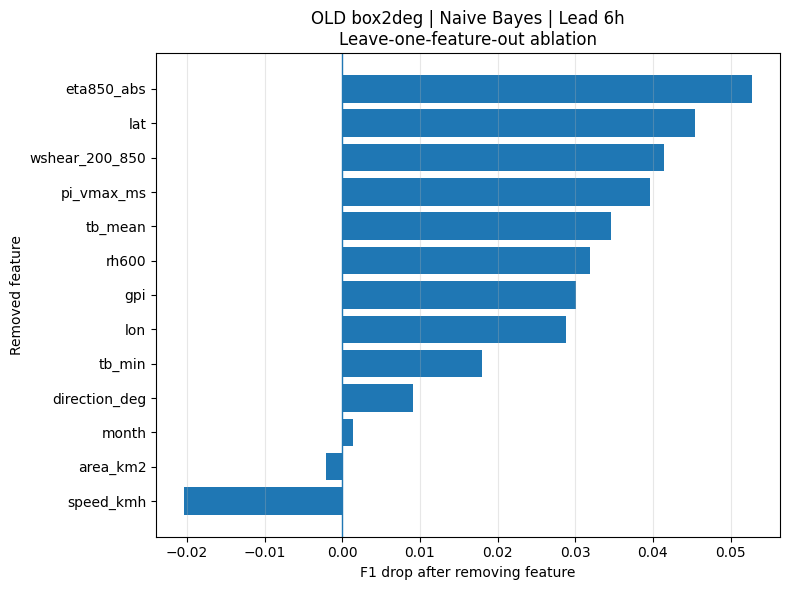

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Naive_Bayes_6h.png


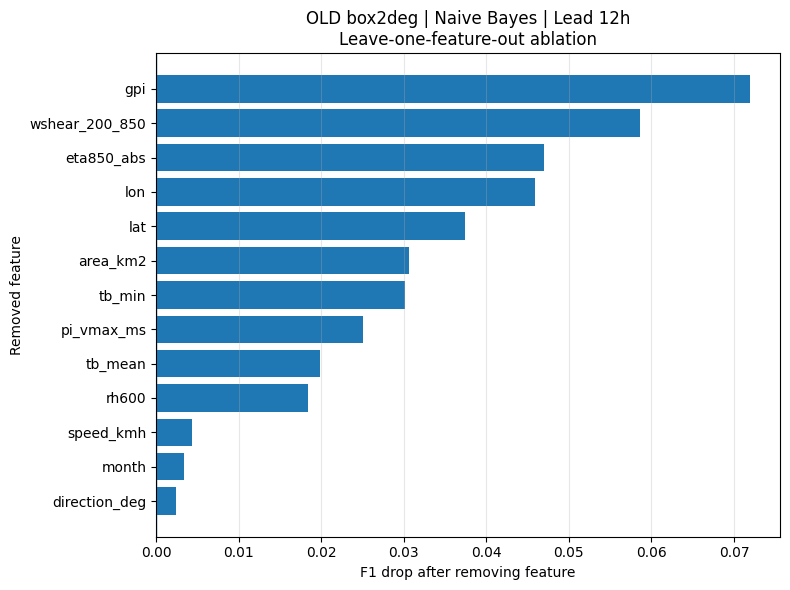

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Naive_Bayes_12h.png


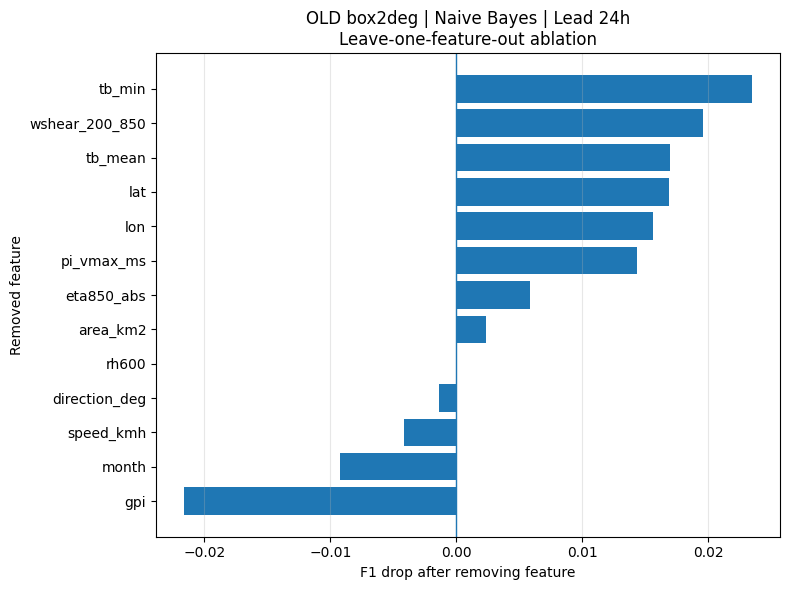

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Naive_Bayes_24h.png


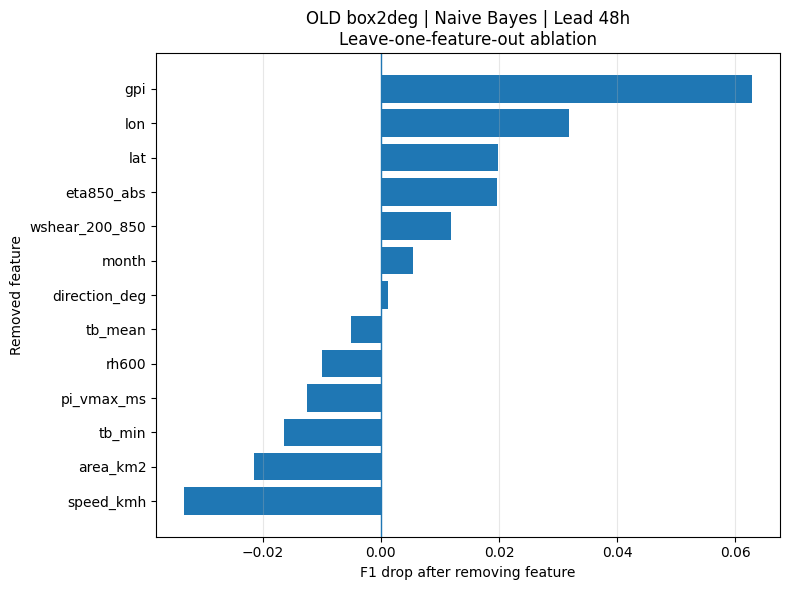

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_drop_f1_Naive_Bayes_48h.png


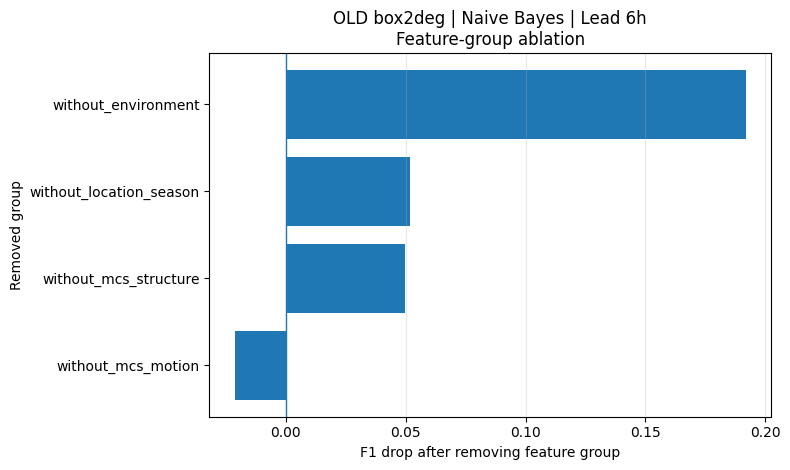

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Naive_Bayes_6h.png


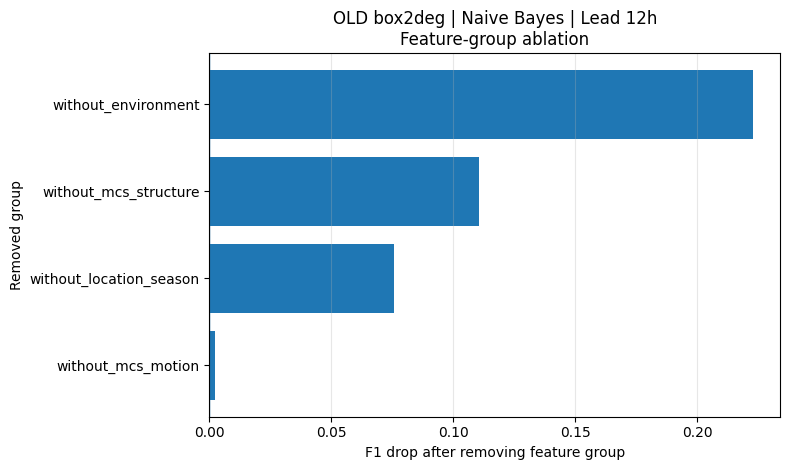

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Naive_Bayes_12h.png


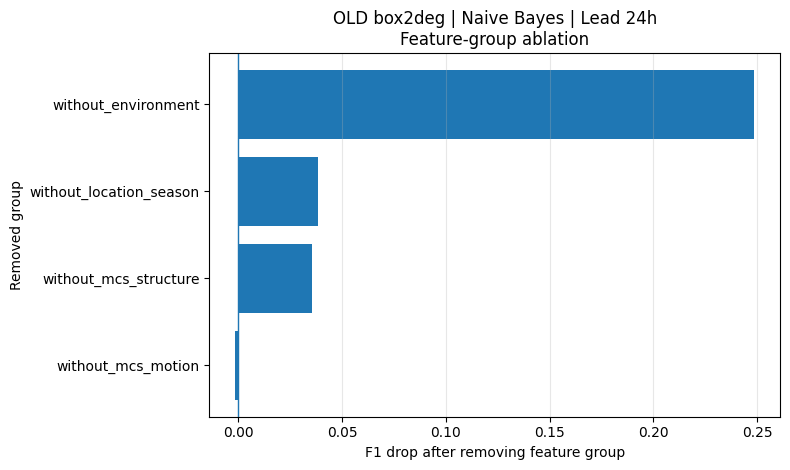

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Naive_Bayes_24h.png


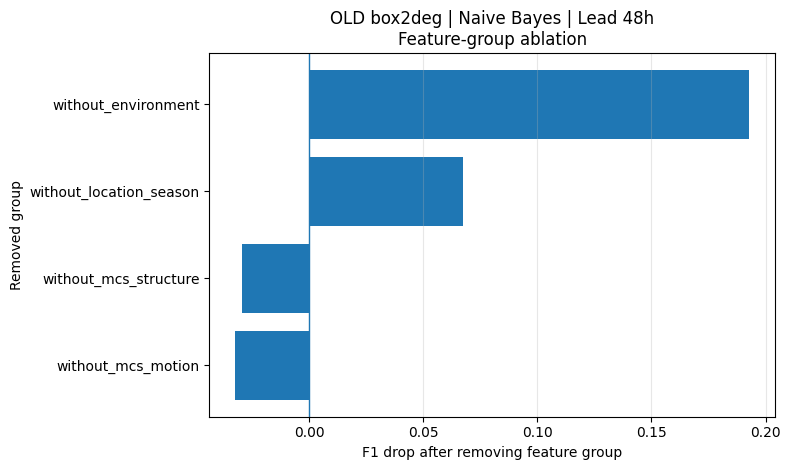

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_group_ablation_drop_f1_Naive_Bayes_48h.png

[DONE] Feature ablation complete.
Main table:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_impact_vs_baseline.csv
Loaded rows: 52
Models available: ['Naive Bayes']
Leads available: [np.int64(6), np.int64(12), np.int64(24), np.int64(48)]
[SKIP] No rows found for model: AdaBoost
[SKIP] No rows found for model: Random Forest
[SKIP] No rows found for model: SVM
[SKIP] No rows found for model: Logistic Regression
[SKIP] No rows found for model: MLP


In [ ]:
# ============================================================
# FEATURE ABLATION — LEAVE-ONE-FEATURE-OUT
# Compatible with ML_CHECK_LATEST structure
#
# What this does:
#   1. Uses the same CASE_DIR, OUT_DIR, LEADS, FEATURE_COLS
#   2. Uses the same get_models(), make_pipeline(), get_cv(),
#      safe_metrics(), and threshold_scan() functions
#   3. Retrains the selected model after removing one feature
#   4. Compares each ablation against the full-feature baseline
#   5. Saves CSV tables and plots
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone



# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
ABLATION_DIR = OUT_DIR / "feature_ablation"
ABLATION_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Choose models for ablation
# Start with AdaBoost because it is the main Zhang-style model.
# You can add "Random Forest" later if needed.
# ------------------------------------------------------------
ABLATION_MODEL_NAMES = [
    "Naive Bayes",
]

# ------------------------------------------------------------
# Load case tables if datasets is not already loaded
# ------------------------------------------------------------
try:
    datasets
    print("Using existing datasets dictionary.")
except NameError:
    print("datasets not found. Loading case tables from CASE_DIR...")

    datasets = {}

    for L in LEADS:
        fp = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

        if not fp.exists():
            raise FileNotFoundError(fp)

        df = pd.read_csv(fp)
        df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)
        df["y"] = df["y"].astype(int)

        datasets[L] = df.copy()

        print(
            f"Lead {L}h | rows={len(df)} | "
            f"positive={int(df['y'].sum())} | "
            f"negative={int((df['y'] == 0).sum())}"
        )

# ------------------------------------------------------------
# Feature ablation specifications
# ------------------------------------------------------------
ABLATION_SPECS = []

# Baseline: all features
ABLATION_SPECS.append({
    "ablation_type": "baseline",
    "ablation_name": "all_features",
    "removed_features": [],
})

# Individual leave-one-feature-out
for f in FEATURE_COLS:
    ABLATION_SPECS.append({
        "ablation_type": "leave_one_feature_out",
        "ablation_name": f"without_{f}",
        "removed_features": [f],
    })

# Optional physical group ablations
GROUP_ABLATIONS = {
    "without_location_season": ["lon", "lat", "month"],
    "without_mcs_structure": ["area_km2", "tb_mean", "tb_min"],
    "without_mcs_motion": ["speed_kmh", "direction_deg"],
    "without_environment": ["eta850_abs", "rh600", "wshear_200_850", "pi_vmax_ms", "gpi"],
}

for group_name, removed in GROUP_ABLATIONS.items():
    removed_existing = [f for f in removed if f in FEATURE_COLS]

    if len(removed_existing) > 0:
        ABLATION_SPECS.append({
            "ablation_type": "feature_group_out",
            "ablation_name": group_name,
            "removed_features": removed_existing,
        })

print("Number of ablation settings:", len(ABLATION_SPECS))

# ------------------------------------------------------------
# Helper: run one ablation with CV
# ------------------------------------------------------------
def run_one_ablation_cv(
    case_df,
    lead_h,
    model_name,
    model,
    feature_cols_used,
    ablation_type,
    ablation_name,
    removed_features,
    dataset_name=DATASET_NAME,
    label_name=LABEL_NAME,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS
):
    df = case_df.copy()

    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)

    X = df[feature_cols_used].copy()
    y = df["y"].astype(int).values

    groups = df["track_id"].astype(str).values if "track_id" in df.columns else None

    cv, cv_name, n_splits_eff = get_cv(
        y=y,
        groups=groups,
        n_splits=n_splits,
        random_state=random_state
    )

    pipe = make_pipeline(model_name, clone(model))

    fold_rows = []
    oof_rows = []

    if groups is not None:
        splitter = cv.split(X, y, groups)
    else:
        splitter = cv.split(X, y)

    for fold_id, (train_idx, test_idx) in enumerate(splitter, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        pipe.fit(X_train, y_train)

        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        else:
            y_score = pipe.decision_function(X_test)
            y_score = (
                y_score - np.nanmin(y_score)
            ) / (
                np.nanmax(y_score) - np.nanmin(y_score) + 1e-12
            )

        fold_metric = safe_metrics(y_test, y_score, threshold=0.5)

        fold_metric.update({
            "dataset": dataset_name,
            "label": label_name,
            "lead_h": lead_h,
            "model": model_name,
            "ablation_type": ablation_type,
            "ablation_name": ablation_name,
            "removed_features": ",".join(removed_features) if removed_features else "none",
            "n_features_used": len(feature_cols_used),
            "fold": fold_id,
            "cv": cv_name,
            "n_splits": n_splits_eff,
            "train_n": len(train_idx),
            "test_n": len(test_idx),
            "train_pos": int(y_train.sum()),
            "test_pos": int(y_test.sum()),
            "train_neg": int((y_train == 0).sum()),
            "test_neg": int((y_test == 0).sum()),
        })

        fold_rows.append(fold_metric)

        oof = pd.DataFrame({
            "dataset": dataset_name,
            "label": label_name,
            "lead_h": lead_h,
            "model": model_name,
            "ablation_type": ablation_type,
            "ablation_name": ablation_name,
            "removed_features": ",".join(removed_features) if removed_features else "none",
            "fold": fold_id,
            "y_true": y_test,
            "y_score": y_score,
            "y_pred_default": (y_score >= 0.5).astype(int),
        })

        if all(c in df.columns for c in ID_COLS):
            id_part = df.iloc[test_idx][ID_COLS].reset_index(drop=True)
            oof = pd.concat([id_part, oof.reset_index(drop=True)], axis=1)

        oof_rows.append(oof)

    fold_df = pd.DataFrame(fold_rows)
    oof_df = pd.concat(oof_rows, ignore_index=True)

    # ------------------------------------------------------------
    # OOF default-threshold metrics
    # ------------------------------------------------------------
    default_metrics = safe_metrics(
        oof_df["y_true"].values,
        oof_df["y_score"].values,
        threshold=0.5
    )

    # ------------------------------------------------------------
    # OOF tuned-threshold metrics
    # ------------------------------------------------------------
    scan = threshold_scan(
        oof_df["y_true"].values,
        oof_df["y_score"].values
    )

    if len(scan) > 0:
        best_tuned = scan.iloc[0].to_dict()
    else:
        best_tuned = {
            "threshold": np.nan,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "roc_auc": np.nan,
            "pr_auc": np.nan,
        }

    summary_row = {
        "dataset": dataset_name,
        "label": label_name,
        "lead_h": lead_h,
        "model": model_name,
        "ablation_type": ablation_type,
        "ablation_name": ablation_name,
        "removed_features": ",".join(removed_features) if removed_features else "none",
        "features_used": ",".join(feature_cols_used),
        "n_features_used": len(feature_cols_used),
        "cv": cv_name,
        "n_splits": n_splits_eff,
        "n_samples": len(df),
        "n_positive": int(np.sum(y == 1)),
        "n_negative": int(np.sum(y == 0)),

        "threshold_default": 0.5,
        "accuracy_default": default_metrics["accuracy"],
        "precision_default": default_metrics["precision"],
        "recall_default": default_metrics["recall"],
        "f1_default": default_metrics["f1"],
        "roc_auc_default": default_metrics["roc_auc"],
        "pr_auc_default": default_metrics["pr_auc"],
        "tn_default": default_metrics["tn"],
        "fp_default": default_metrics["fp"],
        "fn_default": default_metrics["fn"],
        "tp_default": default_metrics["tp"],

        "threshold_tuned": best_tuned.get("threshold", np.nan),
        "accuracy_tuned": best_tuned.get("accuracy", np.nan),
        "precision_tuned": best_tuned.get("precision", np.nan),
        "recall_tuned": best_tuned.get("recall", np.nan),
        "f1_tuned": best_tuned.get("f1", np.nan),
        "roc_auc_tuned": best_tuned.get("roc_auc", np.nan),
        "pr_auc_tuned": best_tuned.get("pr_auc", np.nan),
    }

    scan["dataset"] = dataset_name
    scan["label"] = label_name
    scan["lead_h"] = lead_h
    scan["model"] = model_name
    scan["ablation_type"] = ablation_type
    scan["ablation_name"] = ablation_name
    scan["removed_features"] = ",".join(removed_features) if removed_features else "none"

    return fold_df, oof_df, pd.DataFrame([summary_row]), scan


# ------------------------------------------------------------
# Run ablation
# ------------------------------------------------------------
models_all = get_models(random_state=RANDOM_STATE)

missing_models = [m for m in ABLATION_MODEL_NAMES if m not in models_all]
if missing_models:
    raise ValueError(
        f"These models are not available in get_models(): {missing_models}\n"
        f"Available models: {list(models_all.keys())}"
    )

all_ablation_folds = []
all_ablation_oof = []
all_ablation_summary = []
all_ablation_scans = []

for L in LEADS:
    case_df = datasets[L].copy()

    print("\n" + "=" * 90)
    print(
        f"FEATURE ABLATION | lead={L}h | "
        f"rows={len(case_df)} | positives={int(case_df['y'].sum())}"
    )
    print("=" * 90)

    for model_name in ABLATION_MODEL_NAMES:
        base_model = models_all[model_name]

        print(f"\nModel: {model_name}")

        for spec in ABLATION_SPECS:
            removed = spec["removed_features"]
            feature_cols_used = [f for f in FEATURE_COLS if f not in removed]

            if len(feature_cols_used) == 0:
                print(f"[SKIP] {spec['ablation_name']} removes all features.")
                continue

            print(
                f"  Running {spec['ablation_name']} "
                f"({len(feature_cols_used)} features)"
            )

            try:
                fold_df, oof_df, summary_df, scan_df = run_one_ablation_cv(
                    case_df=case_df,
                    lead_h=L,
                    model_name=model_name,
                    model=base_model,
                    feature_cols_used=feature_cols_used,
                    ablation_type=spec["ablation_type"],
                    ablation_name=spec["ablation_name"],
                    removed_features=removed,
                    dataset_name=DATASET_NAME,
                    label_name=LABEL_NAME,
                    random_state=RANDOM_STATE,
                    n_splits=N_SPLITS
                )

                all_ablation_folds.append(fold_df)
                all_ablation_oof.append(oof_df)
                all_ablation_summary.append(summary_df)
                all_ablation_scans.append(scan_df)

            except Exception as e:
                print(f"  [ERROR] {model_name} | lead {L}h | {spec['ablation_name']}: {e}")

                err = pd.DataFrame([{
                    "dataset": DATASET_NAME,
                    "label": LABEL_NAME,
                    "lead_h": L,
                    "model": model_name,
                    "ablation_type": spec["ablation_type"],
                    "ablation_name": spec["ablation_name"],
                    "removed_features": ",".join(removed) if removed else "none",
                    "error": str(e),
                }])

                all_ablation_summary.append(err)

# ------------------------------------------------------------
# Save raw outputs
# ------------------------------------------------------------
ablation_folds = pd.concat(all_ablation_folds, ignore_index=True)
ablation_oof = pd.concat(all_ablation_oof, ignore_index=True)
ablation_summary = pd.concat(all_ablation_summary, ignore_index=True)
ablation_scans = pd.concat(all_ablation_scans, ignore_index=True)

ablation_folds.to_csv(ABLATION_DIR / "feature_ablation_fold_results.csv", index=False)
ablation_oof.to_csv(ABLATION_DIR / "feature_ablation_oof_predictions.csv", index=False)
ablation_summary.to_csv(ABLATION_DIR / "feature_ablation_summary.csv", index=False)
ablation_scans.to_csv(ABLATION_DIR / "feature_ablation_threshold_scans.csv", index=False)

print("\n[SAVED]")
print(ABLATION_DIR / "feature_ablation_fold_results.csv")
print(ABLATION_DIR / "feature_ablation_oof_predictions.csv")
print(ABLATION_DIR / "feature_ablation_summary.csv")
print(ABLATION_DIR / "feature_ablation_threshold_scans.csv")

# ------------------------------------------------------------
# Compare each ablation against full-feature baseline
# Positive drop means performance became worse after removal.
# ------------------------------------------------------------
summary_ok = ablation_summary[ablation_summary["error"].isna() if "error" in ablation_summary.columns else slice(None)].copy()

baseline = summary_ok[
    summary_ok["ablation_name"] == "all_features"
].copy()

baseline_cols = [
    "lead_h", "model",
    "f1_default", "precision_default", "recall_default",
    "roc_auc_default", "pr_auc_default",
    "f1_tuned", "precision_tuned", "recall_tuned",
    "roc_auc_tuned", "pr_auc_tuned",
]

baseline = baseline[baseline_cols].copy()
baseline = baseline.rename(columns={
    "f1_default": "baseline_f1_default",
    "precision_default": "baseline_precision_default",
    "recall_default": "baseline_recall_default",
    "roc_auc_default": "baseline_roc_auc_default",
    "pr_auc_default": "baseline_pr_auc_default",
    "f1_tuned": "baseline_f1_tuned",
    "precision_tuned": "baseline_precision_tuned",
    "recall_tuned": "baseline_recall_tuned",
    "roc_auc_tuned": "baseline_roc_auc_tuned",
    "pr_auc_tuned": "baseline_pr_auc_tuned",
})

impact = summary_ok.merge(
    baseline,
    on=["lead_h", "model"],
    how="left"
)

impact["drop_f1_default"] = impact["baseline_f1_default"] - impact["f1_default"]
impact["drop_precision_default"] = impact["baseline_precision_default"] - impact["precision_default"]
impact["drop_recall_default"] = impact["baseline_recall_default"] - impact["recall_default"]
impact["drop_roc_auc_default"] = impact["baseline_roc_auc_default"] - impact["roc_auc_default"]
impact["drop_pr_auc_default"] = impact["baseline_pr_auc_default"] - impact["pr_auc_default"]

impact["drop_f1_tuned"] = impact["baseline_f1_tuned"] - impact["f1_tuned"]
impact["drop_precision_tuned"] = impact["baseline_precision_tuned"] - impact["precision_tuned"]
impact["drop_recall_tuned"] = impact["baseline_recall_tuned"] - impact["recall_tuned"]
impact["drop_roc_auc_tuned"] = impact["baseline_roc_auc_tuned"] - impact["roc_auc_tuned"]
impact["drop_pr_auc_tuned"] = impact["baseline_pr_auc_tuned"] - impact["pr_auc_tuned"]

impact = impact.sort_values(
    ["lead_h", "model", "ablation_type", "drop_f1_default"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

impact.to_csv(ABLATION_DIR / "feature_ablation_impact_vs_baseline.csv", index=False)

print("\nFeature ablation impact table:")
display(
    impact[
        [
            "lead_h", "model", "ablation_type", "ablation_name", "removed_features",
            "baseline_f1_default", "f1_default", "drop_f1_default",
            "baseline_pr_auc_default", "pr_auc_default", "drop_pr_auc_default",
            "baseline_f1_tuned", "f1_tuned", "drop_f1_tuned",
        ]
    ]
)

# ------------------------------------------------------------
# Save ranked individual-feature ablation table
# ------------------------------------------------------------
individual_impact = impact[
    impact["ablation_type"] == "leave_one_feature_out"
].copy()

individual_impact = individual_impact.sort_values(
    ["lead_h", "model", "drop_f1_default"],
    ascending=[True, True, False]
)

individual_impact.to_csv(
    ABLATION_DIR / "feature_ablation_individual_ranked_by_drop_f1.csv",
    index=False
)

print("\nIndividual feature ablation ranked by F1 drop:")
display(
    individual_impact[
        [
            "lead_h", "model", "removed_features",
            "f1_default", "drop_f1_default",
            "pr_auc_default", "drop_pr_auc_default",
            "roc_auc_default", "drop_roc_auc_default",
        ]
    ]
)

# ------------------------------------------------------------
# Pivot table: F1 drop by feature and lead
# ------------------------------------------------------------
for model_name in ABLATION_MODEL_NAMES:
    sub = individual_impact[individual_impact["model"] == model_name].copy()

    if len(sub) == 0:
        continue

    pivot_drop_f1 = sub.pivot(
        index="removed_features",
        columns="lead_h",
        values="drop_f1_default"
    )

    pivot_drop_f1 = pivot_drop_f1.reindex(
        pivot_drop_f1.mean(axis=1).sort_values(ascending=False).index
    )

    safe_model = model_name.replace(" ", "_").replace("/", "_")

    pivot_fp = ABLATION_DIR / f"feature_ablation_pivot_drop_f1_{safe_model}.csv"
    pivot_drop_f1.to_csv(pivot_fp)

    print(f"\nF1 drop pivot table — {model_name}:")
    display(pivot_drop_f1)

# ------------------------------------------------------------
# Plots: individual feature F1 drop by lead/model
# ------------------------------------------------------------
for model_name in ABLATION_MODEL_NAMES:
    for L in LEADS:
        sub = individual_impact[
            (individual_impact["model"] == model_name)
            & (individual_impact["lead_h"] == L)
        ].copy()

        if len(sub) == 0:
            continue

        sub = sub.sort_values("drop_f1_default", ascending=True)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(sub["removed_features"], sub["drop_f1_default"])
        ax.axvline(0, linewidth=1)
        ax.set_xlabel("F1 drop after removing feature")
        ax.set_ylabel("Removed feature")
        ax.set_title(
            f"{DATASET_NAME.upper()} {LABEL_NAME} | {model_name} | Lead {L}h\n"
            "Leave-one-feature-out ablation"
        )
        ax.grid(True, axis="x", alpha=0.3)

        plt.tight_layout()

        safe_model = model_name.replace(" ", "_").replace("/", "_")
        out_png = ABLATION_DIR / f"feature_ablation_drop_f1_{safe_model}_{L}h.png"

        plt.savefig(out_png, dpi=220, bbox_inches="tight")
        plt.show()

        print("Saved:", out_png)

# ------------------------------------------------------------
# Plots: feature-group ablation
# ------------------------------------------------------------
group_impact = impact[
    impact["ablation_type"] == "feature_group_out"
].copy()

if len(group_impact) > 0:
    for model_name in ABLATION_MODEL_NAMES:
        for L in LEADS:
            sub = group_impact[
                (group_impact["model"] == model_name)
                & (group_impact["lead_h"] == L)
            ].copy()

            if len(sub) == 0:
                continue

            sub = sub.sort_values("drop_f1_default", ascending=True)

            fig, ax = plt.subplots(figsize=(8, 4.8))
            ax.barh(sub["ablation_name"], sub["drop_f1_default"])
            ax.axvline(0, linewidth=1)
            ax.set_xlabel("F1 drop after removing feature group")
            ax.set_ylabel("Removed group")
            ax.set_title(
                f"{DATASET_NAME.upper()} {LABEL_NAME} | {model_name} | Lead {L}h\n"
                "Feature-group ablation"
            )
            ax.grid(True, axis="x", alpha=0.3)

            plt.tight_layout()

            safe_model = model_name.replace(" ", "_").replace("/", "_")
            out_png = ABLATION_DIR / f"feature_group_ablation_drop_f1_{safe_model}_{L}h.png"

            plt.savefig(out_png, dpi=220, bbox_inches="tight")
            plt.show()

            print("Saved:", out_png)

print("\n[DONE] Feature ablation complete.")
print("Main table:")
print(ABLATION_DIR / "feature_ablation_impact_vs_baseline.csv")

# ============================================================
# FEATURE ABLATION HEATMAP
# Rows   = predictors
# Cols   = lead times
# Values = F1 drop after removing each feature
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
# If already defined in your notebook, this will use it.
# Otherwise, set the folder manually.
try:
    ABLATION_DIR
except NameError:
    ABLATION_DIR = OUT_DIR / "feature_ablation"

CSV_FP = ABLATION_DIR / "feature_ablation_impact_vs_baseline.csv"

# Choose what to plot
TARGET_DATASET = "OLD"       # e.g. "OLD" or "NEW"
TARGET_LABEL   = "box2deg"   # e.g. "box2deg" or "300km"
MODELS_TO_PLOT = ["AdaBoost", "Random Forest", "SVM", "Logistic Regression", "MLP"]   # or ["AdaBoost", "Random Forest"]

# metric options:
#   drop_f1_default
#   drop_f1_tuned
#   drop_pr_auc_default
#   drop_pr_auc_tuned
METRIC_COL = "drop_f1_default"
TITLE_METRIC = "F1 drop"

# exact predictor order requested
PREDICTOR_ORDER = [
    "eta850_abs",
    "rh600",
    "wshear_200_850",
    "pi_vmax_ms",
    "gpi",
    "area_km2",
    "tb_mean",
    "tb_min",
    "speed_kmh",
    "direction_deg",
    "month",
    "lat",
    "lon",
]

LEAD_ORDER = [6, 12, 24, 48]

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
df = pd.read_csv(CSV_FP)

# keep only individual leave-one-feature-out rows
df = df[df["ablation_type"] == "leave_one_feature_out"].copy()

# optional filter by dataset/label if columns exist
if "dataset" in df.columns:
    df = df[df["dataset"].astype(str).str.upper() == TARGET_DATASET.upper()].copy()

if "label" in df.columns:
    df = df[df["label"].astype(str) == TARGET_LABEL].copy()

print("Loaded rows:", len(df))
print("Models available:", sorted(df["model"].unique()))
print("Leads available:", sorted(df["lead_h"].unique()))

# ------------------------------------------------------------
# MAKE HEATMAP FOR EACH MODEL
# ------------------------------------------------------------
for model_name in MODELS_TO_PLOT:
    sub = df[df["model"] == model_name].copy()

    if len(sub) == 0:
        print(f"[SKIP] No rows found for model: {model_name}")
        continue

    heat = sub.pivot_table(
        index="removed_features",
        columns="lead_h",
        values=METRIC_COL,
        aggfunc="mean"
    )

    heat = heat.reindex(index=PREDICTOR_ORDER, columns=LEAD_ORDER)

    vals = heat.values.astype(float)

    # robust color scaling centered at zero
    finite_vals = vals[np.isfinite(vals)]
    if len(finite_vals) == 0:
        print(f"[SKIP] No finite values for model: {model_name}")
        continue

    vmax = np.nanmax(np.abs(finite_vals))
    vmin = -vmax
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(vals, cmap="RdBu_r", norm=norm, aspect="auto")

    # ticks
    ax.set_xticks(np.arange(len(LEAD_ORDER)))
    ax.set_xticklabels([f"{l} h" for l in LEAD_ORDER], fontsize=11)

    ax.set_yticks(np.arange(len(PREDICTOR_ORDER)))
    ax.set_yticklabels(PREDICTOR_ORDER, fontsize=10)

    # annotate each cell
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if np.isfinite(v):
                txt_color = "white" if abs(v) > 0.5 * vmax else "black"
                ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                        fontsize=9, color=txt_color)
            else:
                ax.text(j, i, "NA", ha="center", va="center",
                        fontsize=8, color="black")

    # title
    ax.set_title(
        f"{TARGET_DATASET} {TARGET_LABEL} | {model_name}\n"
        f"Feature ablation heatmap ({TITLE_METRIC})",
        fontsize=14
    )

    ax.set_xlabel("Lead time", fontsize=12)
    ax.set_ylabel("Removed predictor", fontsize=12)

    # minor grid to separate cells
    ax.set_xticks(np.arange(-0.5, len(LEAD_ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(PREDICTOR_ORDER), 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(TITLE_METRIC, fontsize=11)

    plt.tight_layout()

    safe_model = model_name.replace(" ", "_").replace("/", "_")
    out_png = ABLATION_DIR / f"feature_ablation_heatmap_{TARGET_DATASET}_{TARGET_LABEL}_{safe_model}_{METRIC_COL}.png"
    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)
    print()

Loaded rows: 260
Models available: ['AdaBoost', 'Logistic Regression', 'MLP', 'Random Forest', 'SVM']
Leads available: [np.int64(6), np.int64(12), np.int64(24), np.int64(48)]


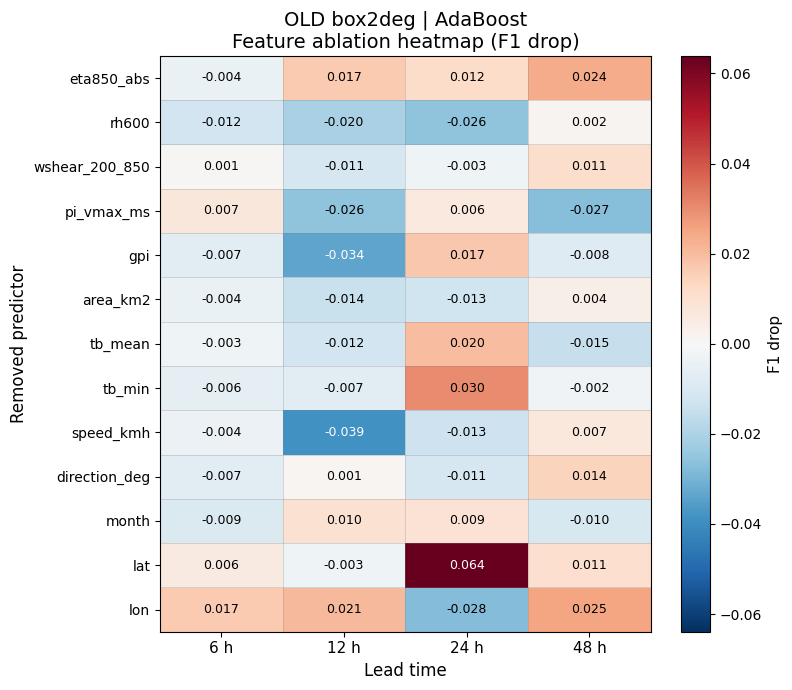

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_heatmap_OLD_box2deg_AdaBoost_drop_f1_default.png



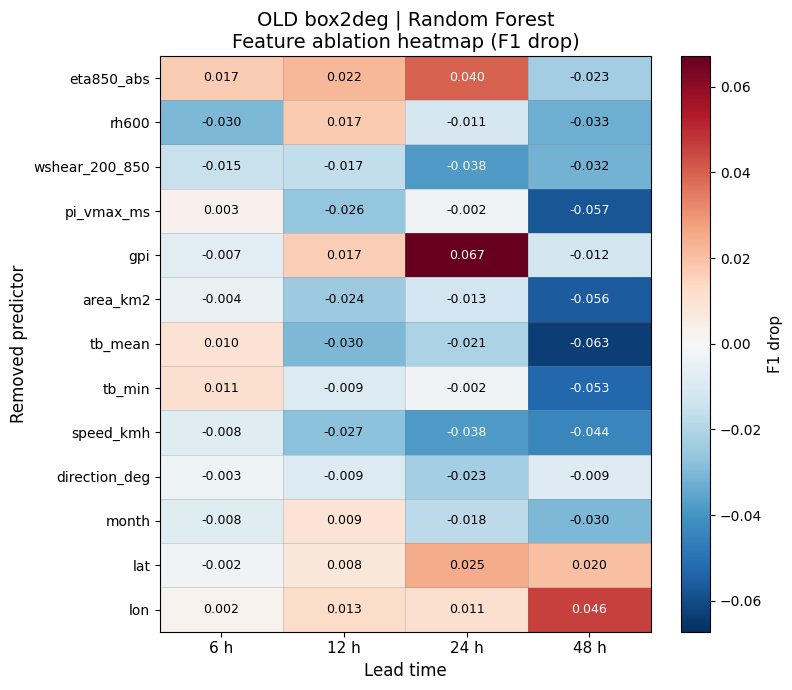

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_heatmap_OLD_box2deg_Random_Forest_drop_f1_default.png



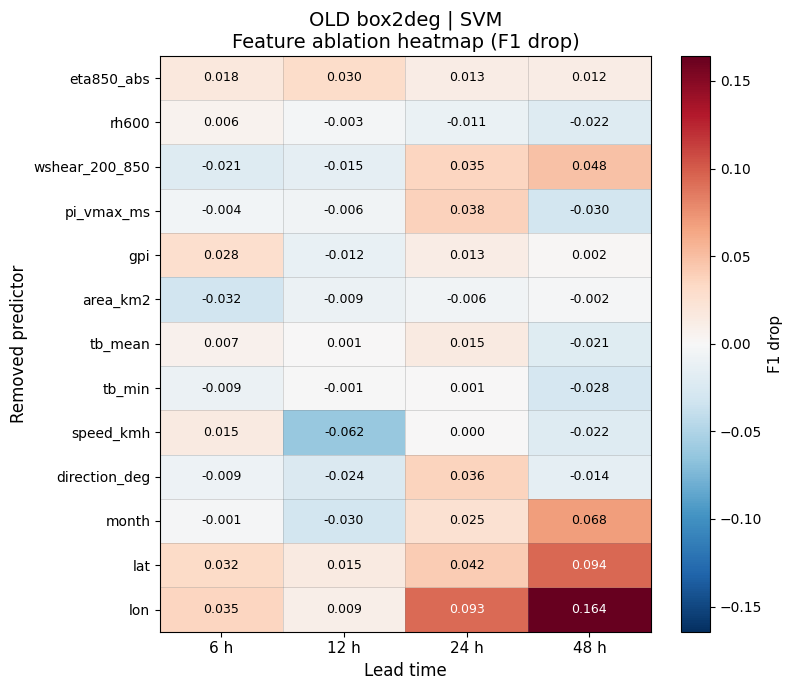

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_heatmap_OLD_box2deg_SVM_drop_f1_default.png



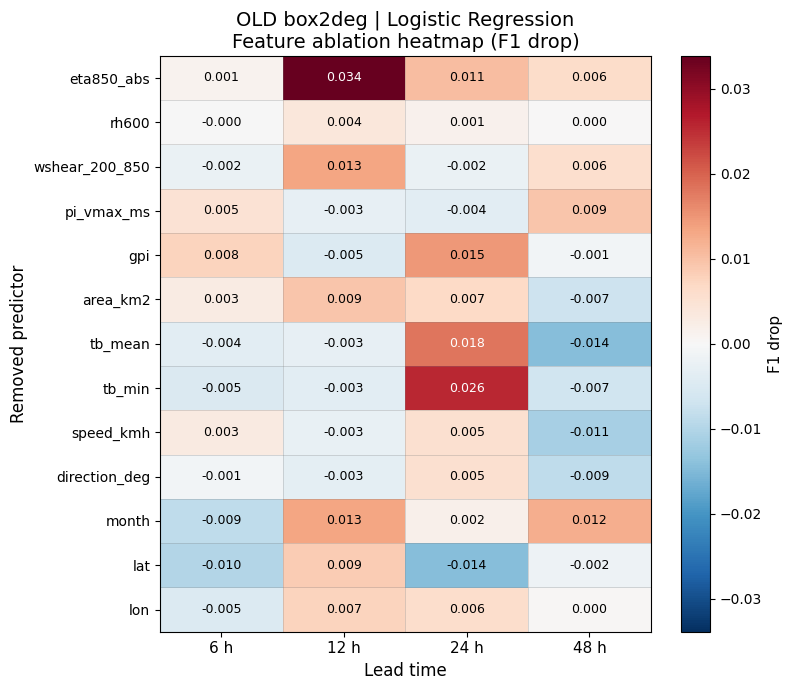

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_heatmap_OLD_box2deg_Logistic_Regression_drop_f1_default.png



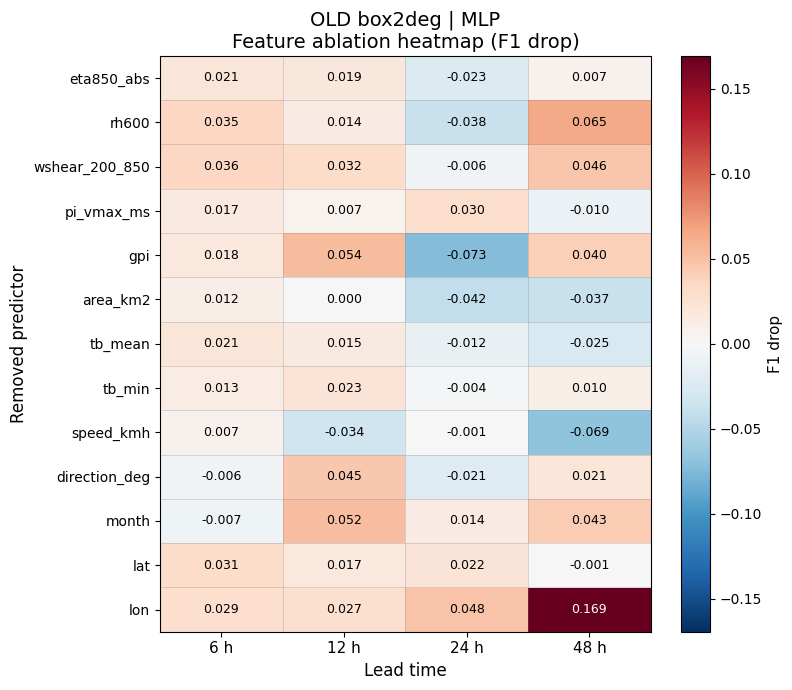

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_heatmap_OLD_box2deg_MLP_drop_f1_default.png



In [ ]:
# ============================================================
# FEATURE ABLATION HEATMAP
# Rows   = predictors
# Cols   = lead times
# Values = F1 drop after removing each feature
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
# If already defined in your notebook, this will use it.
# Otherwise, set the folder manually.
try:
    ABLATION_DIR
except NameError:
    ABLATION_DIR = OUT_DIR / "feature_ablation"

CSV_FP = ABLATION_DIR / "feature_ablation_impact_vs_baseline.csv"

# Choose what to plot
TARGET_DATASET = "OLD"       # e.g. "OLD" or "NEW"
TARGET_LABEL   = "box2deg"   # e.g. "box2deg" or "300km"
MODELS_TO_PLOT = ["AdaBoost", "Random Forest", "SVM", "Logistic Regression", "MLP"]   # or ["AdaBoost", "Random Forest"]

# metric options:
#   drop_f1_default
#   drop_f1_tuned
#   drop_pr_auc_default
#   drop_pr_auc_tuned
METRIC_COL = "drop_f1_default"
TITLE_METRIC = "F1 drop"

# exact predictor order requested
PREDICTOR_ORDER = [
    "eta850_abs",
    "rh600",
    "wshear_200_850",
    "pi_vmax_ms",
    "gpi",
    "area_km2",
    "tb_mean",
    "tb_min",
    "speed_kmh",
    "direction_deg",
    "month",
    "lat",
    "lon",
]

LEAD_ORDER = [6, 12, 24, 48]

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
df = pd.read_csv(CSV_FP)

# keep only individual leave-one-feature-out rows
df = df[df["ablation_type"] == "leave_one_feature_out"].copy()

# optional filter by dataset/label if columns exist
if "dataset" in df.columns:
    df = df[df["dataset"].astype(str).str.upper() == TARGET_DATASET.upper()].copy()

if "label" in df.columns:
    df = df[df["label"].astype(str) == TARGET_LABEL].copy()

print("Loaded rows:", len(df))
print("Models available:", sorted(df["model"].unique()))
print("Leads available:", sorted(df["lead_h"].unique()))

# ------------------------------------------------------------
# MAKE HEATMAP FOR EACH MODEL
# ------------------------------------------------------------
for model_name in MODELS_TO_PLOT:
    sub = df[df["model"] == model_name].copy()

    if len(sub) == 0:
        print(f"[SKIP] No rows found for model: {model_name}")
        continue

    heat = sub.pivot_table(
        index="removed_features",
        columns="lead_h",
        values=METRIC_COL,
        aggfunc="mean"
    )

    heat = heat.reindex(index=PREDICTOR_ORDER, columns=LEAD_ORDER)

    vals = heat.values.astype(float)

    # robust color scaling centered at zero
    finite_vals = vals[np.isfinite(vals)]
    if len(finite_vals) == 0:
        print(f"[SKIP] No finite values for model: {model_name}")
        continue

    vmax = np.nanmax(np.abs(finite_vals))
    vmin = -vmax
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(vals, cmap="RdBu_r", norm=norm, aspect="auto")

    # ticks
    ax.set_xticks(np.arange(len(LEAD_ORDER)))
    ax.set_xticklabels([f"{l} h" for l in LEAD_ORDER], fontsize=11)

    ax.set_yticks(np.arange(len(PREDICTOR_ORDER)))
    ax.set_yticklabels(PREDICTOR_ORDER, fontsize=10)

    # annotate each cell
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if np.isfinite(v):
                txt_color = "white" if abs(v) > 0.5 * vmax else "black"
                ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                        fontsize=9, color=txt_color)
            else:
                ax.text(j, i, "NA", ha="center", va="center",
                        fontsize=8, color="black")

    # title
    ax.set_title(
        f"{TARGET_DATASET} {TARGET_LABEL} | {model_name}\n"
        f"Feature ablation heatmap ({TITLE_METRIC})",
        fontsize=14
    )

    ax.set_xlabel("Lead time", fontsize=12)
    ax.set_ylabel("Removed predictor", fontsize=12)

    # minor grid to separate cells
    ax.set_xticks(np.arange(-0.5, len(LEAD_ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(PREDICTOR_ORDER), 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(TITLE_METRIC, fontsize=11)

    plt.tight_layout()

    safe_model = model_name.replace(" ", "_").replace("/", "_")
    out_png = ABLATION_DIR / f"feature_ablation_heatmap_{TARGET_DATASET}_{TARGET_LABEL}_{safe_model}_{METRIC_COL}.png"
    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)
    print()

Loaded rows: 52
Models available: ['Naive Bayes']
Leads available: [np.int64(6), np.int64(12), np.int64(24), np.int64(48)]


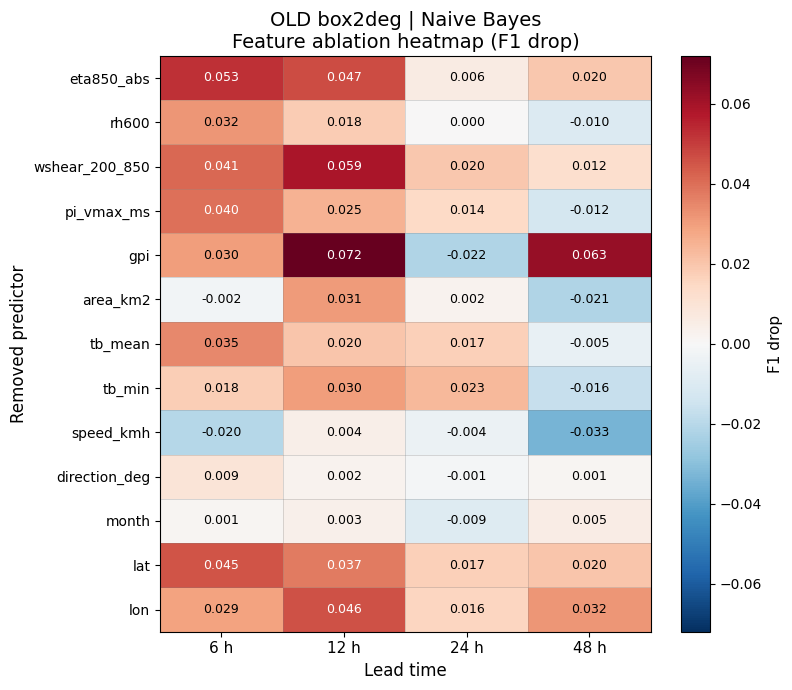

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_ablation\feature_ablation_heatmap_OLD_box2deg_Naive_Bayes_drop_f1_default.png



In [ ]:
# ============================================================
# FEATURE ABLATION HEATMAP
# Rows   = predictors
# Cols   = lead times
# Values = F1 drop after removing each feature
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
# If already defined in your notebook, this will use it.
# Otherwise, set the folder manually.
try:
    ABLATION_DIR
except NameError:
    ABLATION_DIR = OUT_DIR / "feature_ablation"

CSV_FP = ABLATION_DIR / "feature_ablation_impact_vs_baseline.csv"

# Choose what to plot
TARGET_DATASET = "OLD"       # e.g. "OLD" or "NEW"
TARGET_LABEL   = "box2deg"   # e.g. "box2deg" or "300km"
MODELS_TO_PLOT = ["Naive Bayes"]   # or ["AdaBoost", "Random Forest"]

# metric options:
#   drop_f1_default
#   drop_f1_tuned
#   drop_pr_auc_default
#   drop_pr_auc_tuned
METRIC_COL = "drop_f1_default"
TITLE_METRIC = "F1 drop"

# exact predictor order requested
PREDICTOR_ORDER = [
    "eta850_abs",
    "rh600",
    "wshear_200_850",
    "pi_vmax_ms",
    "gpi",
    "area_km2",
    "tb_mean",
    "tb_min",
    "speed_kmh",
    "direction_deg",
    "month",
    "lat",
    "lon",
]

LEAD_ORDER = [6, 12, 24, 48]

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
df = pd.read_csv(CSV_FP)

# keep only individual leave-one-feature-out rows
df = df[df["ablation_type"] == "leave_one_feature_out"].copy()

# optional filter by dataset/label if columns exist
if "dataset" in df.columns:
    df = df[df["dataset"].astype(str).str.upper() == TARGET_DATASET.upper()].copy()

if "label" in df.columns:
    df = df[df["label"].astype(str) == TARGET_LABEL].copy()

print("Loaded rows:", len(df))
print("Models available:", sorted(df["model"].unique()))
print("Leads available:", sorted(df["lead_h"].unique()))

# ------------------------------------------------------------
# MAKE HEATMAP FOR EACH MODEL
# ------------------------------------------------------------
for model_name in MODELS_TO_PLOT:
    sub = df[df["model"] == model_name].copy()

    if len(sub) == 0:
        print(f"[SKIP] No rows found for model: {model_name}")
        continue

    heat = sub.pivot_table(
        index="removed_features",
        columns="lead_h",
        values=METRIC_COL,
        aggfunc="mean"
    )

    heat = heat.reindex(index=PREDICTOR_ORDER, columns=LEAD_ORDER)

    vals = heat.values.astype(float)

    # robust color scaling centered at zero
    finite_vals = vals[np.isfinite(vals)]
    if len(finite_vals) == 0:
        print(f"[SKIP] No finite values for model: {model_name}")
        continue

    vmax = np.nanmax(np.abs(finite_vals))
    vmin = -vmax
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(vals, cmap="RdBu_r", norm=norm, aspect="auto")

    # ticks
    ax.set_xticks(np.arange(len(LEAD_ORDER)))
    ax.set_xticklabels([f"{l} h" for l in LEAD_ORDER], fontsize=11)

    ax.set_yticks(np.arange(len(PREDICTOR_ORDER)))
    ax.set_yticklabels(PREDICTOR_ORDER, fontsize=10)

    # annotate each cell
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if np.isfinite(v):
                txt_color = "white" if abs(v) > 0.5 * vmax else "black"
                ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                        fontsize=9, color=txt_color)
            else:
                ax.text(j, i, "NA", ha="center", va="center",
                        fontsize=8, color="black")

    # title
    ax.set_title(
        f"{TARGET_DATASET} {TARGET_LABEL} | {model_name}\n"
        f"Feature ablation heatmap ({TITLE_METRIC})",
        fontsize=14
    )

    ax.set_xlabel("Lead time", fontsize=12)
    ax.set_ylabel("Removed predictor", fontsize=12)

    # minor grid to separate cells
    ax.set_xticks(np.arange(-0.5, len(LEAD_ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(PREDICTOR_ORDER), 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(TITLE_METRIC, fontsize=11)

    plt.tight_layout()

    safe_model = model_name.replace(" ", "_").replace("/", "_")
    out_png = ABLATION_DIR / f"feature_ablation_heatmap_{TARGET_DATASET}_{TARGET_LABEL}_{safe_model}_{METRIC_COL}.png"
    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)
    print()

In [1]:
# ============================================================
# CELL 1 — SETUP + LOAD EXISTING GPI CASE TABLES
# Conventional vs MR
# Uses existing gpi column only.
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
)

try:
    from IPython.display import display
except Exception:
    display = print

# ============================================================
# CONFIG
# ============================================================

LAB = Path(r"C:\Users\_s2218026\Documents\lab")

OLD_NAME = "Conventional"
NEW_NAME = "MR"

LEADS = [6, 12, 24, 48]
LABEL_NAME = "box2deg"

GPI_COL_PRIORITY = ["gpi", "gpi_original", "gpi_en04"]

THRESHOLD_N = 250
THRESHOLD_UPPER_PERCENTILE = 99.5

OLD_CASE_DIR = (
    LAB
    / "mcs_output"
    / "exactlead_box2deg_case_tables_old_2009_2025_UPDATED"
)

NEW_CASE_DIR = (
    LAB
    / "mcs_output_softtest"
    / "exactlead_box2deg_case_tables_new_2009_2025_UPDATED"
)

OUT_DIR = LAB / "GPI_THRESHOLD_CLASSIFIER_EXISTING_GPI_Conventional_vs_MR"
PLOT_DIR = OUT_DIR / "plots"
TABLE_DIR = OUT_DIR / "tables"

for d in [OUT_DIR, PLOT_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def clean_df(df):
    return df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")].copy()


def find_case_file(case_dir, dataset_key, lead):
    case_dir = Path(case_dir)

    candidates = [
        case_dir / f"{LABEL_NAME}_case_table_{dataset_key}_{lead}h.csv",
        case_dir / f"zhang_case_table_{dataset_key}_{lead}h.csv",
        case_dir / f"zhang_case_table_{lead}h.csv",
        case_dir / f"case_table_{lead}h.csv",
    ]

    for fp in candidates:
        if fp.exists():
            return fp

    hits = sorted(case_dir.rglob(f"*{lead}h*.csv"))
    if hits:
        return hits[0]

    print(f"[SKIP] No case table found: {dataset_key}, {lead}h")
    return None


def choose_existing_gpi_col(df):
    for col in GPI_COL_PRIORITY:
        if col in df.columns:
            return col

    gpi_like = [
        c for c in df.columns
        if "gpi" in str(c).lower()
        and "2010" not in str(c).lower()
        and "e2010" not in str(c).lower()
    ]

    if len(gpi_like) > 0:
        return gpi_like[0]

    return None


def load_case_tables(case_dir, dataset_key, display_name):
    rows = []

    for lead in LEADS:
        fp = find_case_file(case_dir, dataset_key, lead)

        if fp is None:
            continue

        df = pd.read_csv(fp, low_memory=False)
        df = clean_df(df)

        if "y" not in df.columns:
            print(f"[SKIP] No y column: {fp.name}")
            continue

        gpi_col = choose_existing_gpi_col(df)

        if gpi_col is None:
            print(f"[SKIP] No existing GPI column: {fp.name}")
            continue

        use = df[["y", gpi_col]].copy()
        use = use.rename(columns={gpi_col: "gpi_used"})

        use["dataset"] = display_name
        use["lead_h"] = lead
        use["source_file"] = str(fp)
        use["gpi_column_used"] = gpi_col

        use["y"] = pd.to_numeric(use["y"], errors="coerce")
        use["gpi_used"] = pd.to_numeric(use["gpi_used"], errors="coerce")

        use = use.replace([np.inf, -np.inf], np.nan)
        use = use.dropna(subset=["y", "gpi_used"]).copy()
        use["y"] = use["y"].astype(int)

        rows.append(use)

        print(
            f"{display_name} | {lead}h | rows={len(use)} | "
            f"positive={int(use['y'].sum())} | GPI={gpi_col} | {fp.name}"
        )

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


# ============================================================
# LOAD DATA
# ============================================================

conv_cases = load_case_tables(
    case_dir=OLD_CASE_DIR,
    dataset_key="old",
    display_name=OLD_NAME
)

mr_cases = load_case_tables(
    case_dir=NEW_CASE_DIR,
    dataset_key="new",
    display_name=NEW_NAME
)

case_all = pd.concat([conv_cases, mr_cases], ignore_index=True)

if len(case_all) > 0:
    case_all.to_csv(TABLE_DIR / "existing_gpi_case_values_conventional_vs_MR.csv", index=False)

    display(
        case_all.groupby(["dataset", "lead_h", "gpi_column_used"])
        .agg(
            n=("y", "size"),
            positives=("y", "sum"),
            gpi_min=("gpi_used", "min"),
            gpi_mean=("gpi_used", "mean"),
            gpi_max=("gpi_used", "max"),
        )
        .reset_index()
    )
else:
    print("[WARNING] No valid GPI case data loaded.")

print("CELL 1 DONE")
print("Output directory:", OUT_DIR)

Conventional | 6h | rows=1132 | positive=216 | GPI=gpi | box2deg_case_table_old_6h.csv
Conventional | 12h | rows=1082 | positive=205 | GPI=gpi | box2deg_case_table_old_12h.csv
Conventional | 24h | rows=890 | positive=172 | GPI=gpi | box2deg_case_table_old_24h.csv
Conventional | 48h | rows=624 | positive=121 | GPI=gpi | box2deg_case_table_old_48h.csv
MR | 6h | rows=779 | positive=152 | GPI=gpi | box2deg_case_table_new_6h.csv
MR | 12h | rows=713 | positive=138 | GPI=gpi | box2deg_case_table_new_12h.csv
MR | 24h | rows=573 | positive=110 | GPI=gpi | box2deg_case_table_new_24h.csv
MR | 48h | rows=412 | positive=77 | GPI=gpi | box2deg_case_table_new_48h.csv


,dataset,lead_h,gpi_column_used,n,positives,gpi_min,gpi_mean,gpi_max
0,Conventional,6,gpi,1132,216,0.000000,22.951868,429.506490
1,Conventional,12,gpi,1082,205,0.000000,23.507050,1583.507430
2,Conventional,24,gpi,890,172,0.000000,19.053018,440.007032
3,Conventional,48,gpi,624,121,0.000000,16.751818,722.319700
4,MR,6,gpi,779,152,0.000054,26.595661,859.379310
5,MR,12,gpi,713,138,0.000603,20.352491,404.187242
6,MR,24,gpi,573,110,0.000079,19.388928,422.187780
7,MR,48,gpi,412,77,0.000000,16.473011,417.360270


CELL 1 DONE
Output directory: C:\Users\_s2218026\Documents\lab\GPI_THRESHOLD_CLASSIFIER_EXISTING_GPI_Conventional_vs_MR


Best existing-GPI threshold by lead:


,dataset,lead_h,threshold,precision,recall,f1,tn,fp,fn,tp
0,Conventional,6,28.208356,0.626667,0.652778,0.639456,832,84,75,141
1,Conventional,12,17.170304,0.451923,0.687805,0.545455,706,171,64,141
2,Conventional,24,13.490953,0.394464,0.662791,0.494577,543,175,58,114
3,Conventional,48,2.452901,0.257143,0.892562,0.399261,191,312,13,108
4,MR,6,28.208356,0.541176,0.605263,0.571429,549,78,60,92
5,MR,12,22.076105,0.482955,0.615942,0.541401,484,91,53,85
6,MR,24,12.264503,0.399015,0.736364,0.517572,341,122,29,81
7,MR,48,3.679351,0.271605,0.857143,0.412500,158,177,11,66


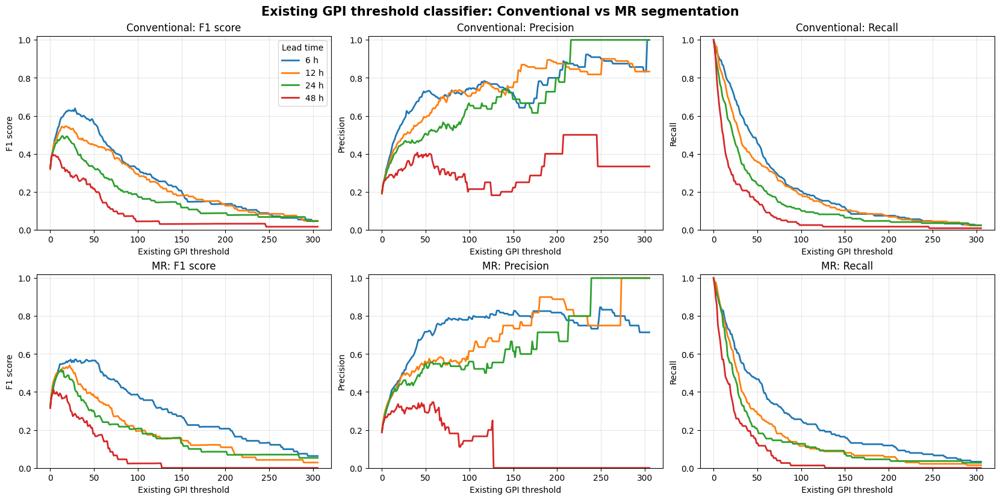

Saved: C:\Users\_s2218026\Documents\lab\GPI_THRESHOLD_CLASSIFIER_EXISTING_GPI_Conventional_vs_MR\plots\zhang_style_existing_gpi_threshold_classifier_conventional_vs_MR_combined.png


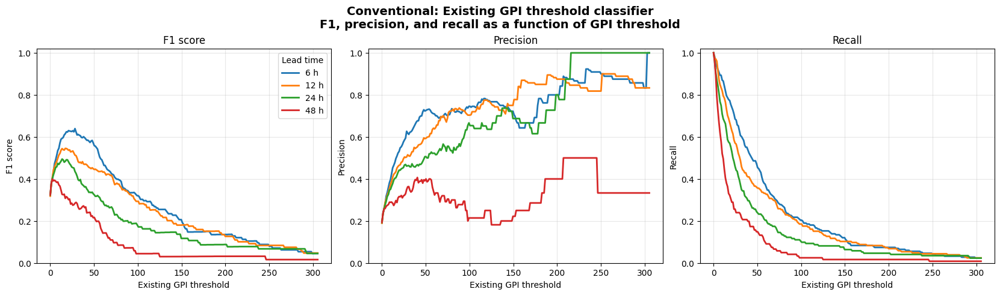

Saved: C:\Users\_s2218026\Documents\lab\GPI_THRESHOLD_CLASSIFIER_EXISTING_GPI_Conventional_vs_MR\plots\zhang_style_existing_gpi_threshold_classifier_Conventional.png


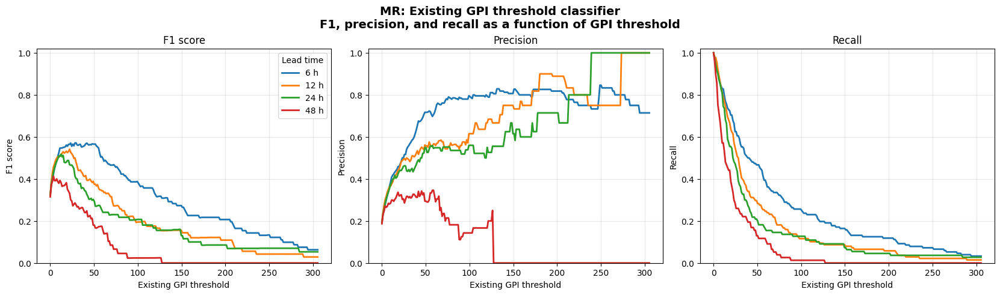

Saved: C:\Users\_s2218026\Documents\lab\GPI_THRESHOLD_CLASSIFIER_EXISTING_GPI_Conventional_vs_MR\plots\zhang_style_existing_gpi_threshold_classifier_MR.png
CELL 2 DONE


In [2]:
# ============================================================
# CELL 2 — GPI THRESHOLD SCAN + ZHANG-STYLE PLOTS
# Run Cell 1 first.
# ============================================================

def make_threshold_grid(df_all):
    if df_all.empty:
        return np.linspace(0, 1, THRESHOLD_N)

    g = df_all["gpi_used"].replace([np.inf, -np.inf], np.nan).dropna().values

    if len(g) == 0:
        return np.linspace(0, 1, THRESHOLD_N)

    g_min = 0.0
    g_max = np.nanpercentile(g, THRESHOLD_UPPER_PERCENTILE)

    if not np.isfinite(g_max) or g_max <= 0:
        g_max = np.nanmax(g)

    if not np.isfinite(g_max) or g_max <= 0:
        g_max = 1.0

    return np.linspace(g_min, g_max, THRESHOLD_N)


def gpi_threshold_scan(df_all, threshold_grid):
    rows = []

    for (dataset, lead), sub in df_all.groupby(["dataset", "lead_h"]):
        y_true = sub["y"].astype(int).values
        gpi = sub["gpi_used"].astype(float).values

        for thr in threshold_grid:
            y_pred = (gpi >= thr).astype(int)

            tn = int(((y_true == 0) & (y_pred == 0)).sum())
            fp = int(((y_true == 0) & (y_pred == 1)).sum())
            fn = int(((y_true == 1) & (y_pred == 0)).sum())
            tp = int(((y_true == 1) & (y_pred == 1)).sum())

            rows.append({
                "dataset": dataset,
                "lead_h": int(lead),
                "threshold": float(thr),
                "accuracy": accuracy_score(y_true, y_pred),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
                "n": int(len(y_true)),
                "positive_n": int(y_true.sum()),
                "negative_n": int((y_true == 0).sum()),
            })

    return pd.DataFrame(rows)


def get_best_gpi_by_lead(scan_df):
    if scan_df.empty:
        return pd.DataFrame()

    return (
        scan_df
        .sort_values(
            ["dataset", "lead_h", "f1", "recall", "precision"],
            ascending=[True, True, False, False, False]
        )
        .groupby(["dataset", "lead_h"], as_index=False)
        .first()
    )


if case_all.empty:
    print("[SKIP] case_all is empty. Run Cell 1 and check file paths.")
else:
    threshold_grid = make_threshold_grid(case_all)

    scan_df = gpi_threshold_scan(case_all, threshold_grid)
    best_gpi = get_best_gpi_by_lead(scan_df)

    scan_df.to_csv(TABLE_DIR / "existing_gpi_threshold_scan_conventional_vs_MR.csv", index=False)
    best_gpi.to_csv(TABLE_DIR / "best_existing_gpi_threshold_by_lead_conventional_vs_MR.csv", index=False)

    print("Best existing-GPI threshold by lead:")
    display(
        best_gpi[
            [
                "dataset", "lead_h", "threshold",
                "precision", "recall", "f1",
                "tn", "fp", "fn", "tp",
            ]
        ]
    )

    metric_list = [
        ("f1", "F1 score"),
        ("precision", "Precision"),
        ("recall", "Recall"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.2), constrained_layout=True)

    for row_i, dataset in enumerate([OLD_NAME, NEW_NAME]):
        for col_i, (metric, ylabel) in enumerate(metric_list):
            ax = axes[row_i, col_i]

            for lead in LEADS:
                sub = scan_df[
                    (scan_df["dataset"] == dataset)
                    & (scan_df["lead_h"] == lead)
                ].copy()

                if len(sub) == 0:
                    continue

                ax.plot(
                    sub["threshold"],
                    sub[metric],
                    linewidth=2,
                    label=f"{lead} h"
                )

            ax.set_title(f"{dataset}: {ylabel}")
            ax.set_xlabel("Existing GPI threshold")
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1.02)

            if row_i == 0 and col_i == 0:
                ax.legend(title="Lead time")

    fig.suptitle(
        "Existing GPI threshold classifier: Conventional vs MR segmentation",
        fontsize=15,
        fontweight="bold"
    )

    out_png = PLOT_DIR / "zhang_style_existing_gpi_threshold_classifier_conventional_vs_MR_combined.png"
    plt.savefig(out_png, dpi=250, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)

    for dataset in [OLD_NAME, NEW_NAME]:
        fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8), constrained_layout=True)

        for ax, (metric, ylabel) in zip(axes, metric_list):
            for lead in LEADS:
                sub = scan_df[
                    (scan_df["dataset"] == dataset)
                    & (scan_df["lead_h"] == lead)
                ].copy()

                if len(sub) == 0:
                    continue

                ax.plot(
                    sub["threshold"],
                    sub[metric],
                    linewidth=2,
                    label=f"{lead} h"
                )

            ax.set_title(ylabel)
            ax.set_xlabel("Existing GPI threshold")
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1.02)

        axes[0].legend(title="Lead time")

        fig.suptitle(
            f"{dataset}: Existing GPI threshold classifier\n"
            "F1, precision, and recall as a function of GPI threshold",
            fontsize=14,
            fontweight="bold"
        )

        safe_name = dataset.replace(" ", "_")
        out_png = PLOT_DIR / f"zhang_style_existing_gpi_threshold_classifier_{safe_name}.png"

        plt.savefig(out_png, dpi=250, bbox_inches="tight")
        plt.show()

        print("Saved:", out_png)

print("CELL 2 DONE")

Loaded ML OOF for Conventional: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\oof_predictions_all_models.csv
Loaded ML OOF for MR: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\oof_predictions_allmodels_new.csv
Best ML model by lead:


,dataset,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,Conventional,6,Random Forest,0.715232,0.484305,0.577540,0.913740,0.687383
1,Conventional,12,Naive Bayes,0.629630,0.492754,0.552846,0.840225,0.529843
2,Conventional,24,AdaBoost,0.537879,0.405714,0.462541,0.841117,0.511400
3,Conventional,48,MLP,0.432990,0.333333,0.376682,0.761061,0.345180
4,MR,6,AdaBoost,0.695652,0.578313,0.631579,0.897271,0.643259
5,MR,12,Naive Bayes,0.548387,0.456376,0.498168,0.833751,0.485259
6,MR,24,AdaBoost,0.557895,0.445378,0.495327,0.844997,0.529594
7,MR,48,Naive Bayes,0.350993,0.602273,0.443515,0.747288,0.350918


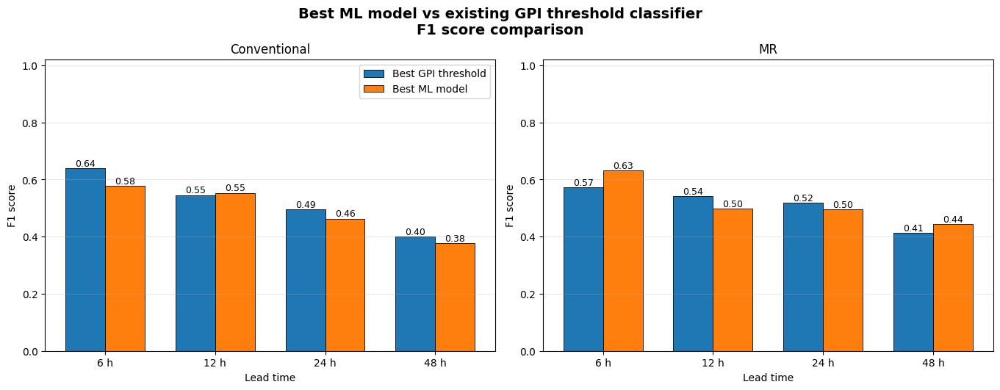

Saved: C:\Users\_s2218026\Documents\lab\GPI_THRESHOLD_CLASSIFIER_EXISTING_GPI_Conventional_vs_MR\plots\best_ml_vs_best_existing_gpi_threshold_f1_conventional_vs_MR.png
CELL 3 DONE


In [3]:
# ============================================================
# CELL 3 — LOAD ML RESULTS + COMPARE BEST ML VS BEST GPI
# Run Cell 1 and Cell 2 first.
# ============================================================

OOF_CANDIDATES = {
    OLD_NAME: [
        LAB / "mcs_output" / "ml_old_box2deg_2009_2025_final" / "oof_predictions_all_models.csv",
        LAB / "mcs_output" / "ml_old_box2deg_2009_2025_final" / "oof_predictions_allmodels_old.csv",
        LAB / "mcs_output" / "ml_old_box2deg_2009_2025_UPDATED" / "oof_predictions_all_models.csv",
        LAB / "mcs_output" / "ml_old_box2deg_2009_2025_UPDATED" / "oof_predictions_allmodels_old.csv",
    ],
    NEW_NAME: [
        LAB / "mcs_output_softtest" / "ml_new_box2deg_2009_2025_UPDATED" / "oof_predictions_allmodels_new.csv",
        LAB / "mcs_output_softtest" / "ml_new_box2deg_2009_2025_UPDATED" / "oof_predictions_all_models.csv",
        LAB / "mcs_output_softtest" / "ml_new_box2deg_2009_2025_UPDATED" / "oof_predictions_allmodels_soft.csv",
    ],
}


def first_existing(paths):
    for fp in paths:
        if Path(fp).exists():
            return Path(fp)
    return None


def load_oof_predictions(display_name):
    fp = first_existing(OOF_CANDIDATES[display_name])

    if fp is None:
        print(f"[SKIP] No OOF file found for {display_name}.")
        return None

    df = pd.read_csv(fp, low_memory=False)
    df = clean_df(df)

    if "lead_h" not in df.columns or "model" not in df.columns or "y_true" not in df.columns:
        print(f"[SKIP] Missing required OOF columns: {fp}")
        return None

    if "y_score" not in df.columns:
        if "y_prob" in df.columns:
            df["y_score"] = df["y_prob"]
        else:
            print(f"[SKIP] No y_score/y_prob column: {fp}")
            return None

    df["lead_h"] = pd.to_numeric(df["lead_h"], errors="coerce")
    df["y_true"] = pd.to_numeric(df["y_true"], errors="coerce")
    df["y_score"] = pd.to_numeric(df["y_score"], errors="coerce")

    df = df.dropna(subset=["lead_h", "y_true", "y_score"]).copy()

    df["lead_h"] = df["lead_h"].astype(int)
    df["y_true"] = df["y_true"].astype(int)

    print(f"Loaded ML OOF for {display_name}: {fp}")

    return df


def compute_ml_best_by_lead(oof, display_name):
    if oof is None or len(oof) == 0:
        return pd.DataFrame()

    rows = []

    for (lead, model), sub in oof.groupby(["lead_h", "model"]):
        if lead not in LEADS:
            continue

        y_true = sub["y_true"].astype(int).values
        y_score = sub["y_score"].astype(float).values

        if "y_pred_default" in sub.columns:
            y_pred = sub["y_pred_default"].astype(int).values
        elif "y_pred" in sub.columns:
            y_pred = sub["y_pred"].astype(int).values
        else:
            y_pred = (y_score >= 0.5).astype(int)

        try:
            roc_auc = roc_auc_score(y_true, y_score)
        except Exception:
            roc_auc = np.nan

        try:
            pr_auc = average_precision_score(y_true, y_score)
        except Exception:
            pr_auc = np.nan

        rows.append({
            "dataset": display_name,
            "lead_h": int(lead),
            "model": model,
            "threshold": 0.5,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "n": int(len(sub)),
            "positive_n": int(y_true.sum()),
            "negative_n": int((y_true == 0).sum()),
        })

    perf = pd.DataFrame(rows)

    if perf.empty:
        return perf

    best = (
        perf
        .sort_values(["dataset", "lead_h", "f1"], ascending=[True, True, False])
        .groupby(["dataset", "lead_h"], as_index=False)
        .first()
    )

    return best


conv_oof = load_oof_predictions(OLD_NAME)
mr_oof = load_oof_predictions(NEW_NAME)

ml_best = pd.concat(
    [
        compute_ml_best_by_lead(conv_oof, OLD_NAME),
        compute_ml_best_by_lead(mr_oof, NEW_NAME),
    ],
    ignore_index=True
)

if ml_best.empty:
    print("[SKIP] No ML OOF results loaded.")
else:
    ml_best.to_csv(TABLE_DIR / "best_ml_default_threshold_by_lead_conventional_vs_MR.csv", index=False)

    print("Best ML model by lead:")
    display(
        ml_best[
            [
                "dataset", "lead_h", "model",
                "precision", "recall", "f1",
                "roc_auc", "pr_auc",
            ]
        ]
    )

    compare_rows = []

    for _, r in best_gpi.iterrows():
        compare_rows.append({
            "dataset": r["dataset"],
            "lead_h": r["lead_h"],
            "method": "Best GPI threshold",
            "model": "GPI",
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
        })

    for _, r in ml_best.iterrows():
        compare_rows.append({
            "dataset": r["dataset"],
            "lead_h": r["lead_h"],
            "method": "Best ML model",
            "model": r["model"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
        })

    compare_df = pd.DataFrame(compare_rows)
    compare_df.to_csv(TABLE_DIR / "best_gpi_vs_best_ml_conventional_vs_MR.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)

    for ax, dataset in zip(axes, [OLD_NAME, NEW_NAME]):
        sub = compare_df[compare_df["dataset"] == dataset].copy()

        gpi_sub = sub[sub["method"] == "Best GPI threshold"].sort_values("lead_h")
        ml_sub = sub[sub["method"] == "Best ML model"].sort_values("lead_h")

        x = np.arange(len(LEADS))
        width = 0.36

        ax.bar(
            x - width / 2,
            gpi_sub["f1"],
            width=width,
            label="Best GPI threshold",
            edgecolor="black",
            linewidth=0.6
        )

        ax.bar(
            x + width / 2,
            ml_sub["f1"],
            width=width,
            label="Best ML model",
            edgecolor="black",
            linewidth=0.6
        )

        ax.set_xticks(x)
        ax.set_xticklabels([f"{L} h" for L in LEADS])
        ax.set_ylim(0, 1.02)
        ax.set_xlabel("Lead time")
        ax.set_ylabel("F1 score")
        ax.set_title(dataset)
        ax.grid(True, axis="y", alpha=0.3)

        for i, val in enumerate(gpi_sub["f1"].values):
            ax.text(i - width / 2, val, f"{val:.2f}", ha="center", va="bottom", fontsize=9)

        for i, val in enumerate(ml_sub["f1"].values):
            ax.text(i + width / 2, val, f"{val:.2f}", ha="center", va="bottom", fontsize=9)

    axes[0].legend()

    fig.suptitle(
        "Best ML model vs existing GPI threshold classifier\n"
        "F1 score comparison",
        fontsize=14,
        fontweight="bold"
    )

    out_png = PLOT_DIR / "best_ml_vs_best_existing_gpi_threshold_f1_conventional_vs_MR.png"

    plt.savefig(out_png, dpi=250, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)

print("CELL 3 DONE")

,dataset,lead_h,method,roc_auc,pr_auc
0,Conventional,6,GPI score,0.863689,0.626050
1,Conventional,12,GPI score,0.827961,0.543036
2,Conventional,24,GPI score,0.765628,0.448786
3,Conventional,48,GPI score,0.674367,0.297105
4,MR,6,GPI score,0.828160,0.601701
5,MR,12,GPI score,0.819395,0.501169
6,MR,24,GPI score,0.788141,0.453561
7,MR,48,GPI score,0.690560,0.288486
8,Conventional,6,Best ML model,0.913740,0.687383
9,Conventional,12,Best ML model,0.840225,0.529843


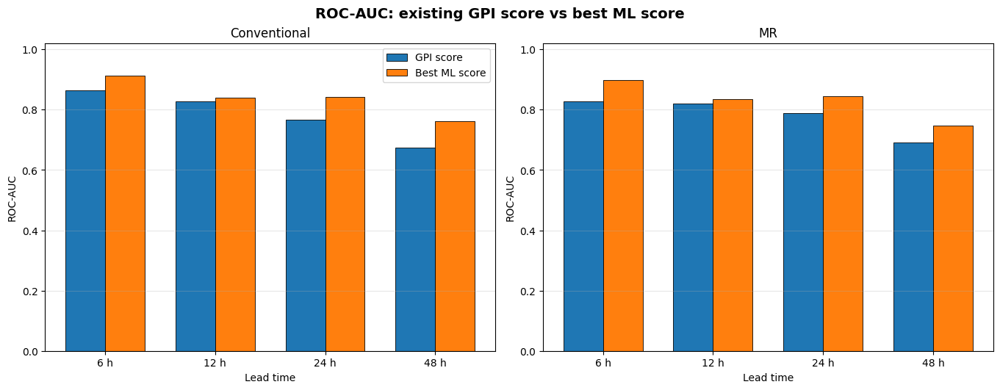

Saved: C:\Users\_s2218026\Documents\lab\GPI_THRESHOLD_CLASSIFIER_EXISTING_GPI_Conventional_vs_MR\plots\roc_auc_comparison_existing_gpi_score_vs_best_ml_conventional_vs_MR.png


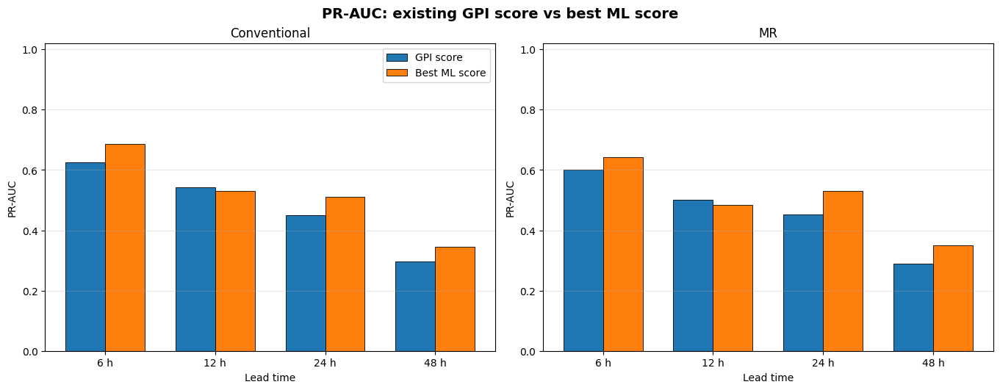

Saved: C:\Users\_s2218026\Documents\lab\GPI_THRESHOLD_CLASSIFIER_EXISTING_GPI_Conventional_vs_MR\plots\pr_auc_comparison_existing_gpi_score_vs_best_ml_conventional_vs_MR.png
CELL 4 DONE


In [4]:
# ============================================================
# CELL 4 — AUC COMPARISON: GPI SCORE VS ML SCORE
# Run Cell 1, Cell 2, and Cell 3 first.
# ============================================================

def compute_gpi_auc(df_all):
    rows = []

    for (dataset, lead), sub in df_all.groupby(["dataset", "lead_h"]):
        y_true = sub["y"].astype(int).values
        gpi = sub["gpi_used"].astype(float).values

        try:
            roc_auc = roc_auc_score(y_true, gpi)
        except Exception:
            roc_auc = np.nan

        try:
            pr_auc = average_precision_score(y_true, gpi)
        except Exception:
            pr_auc = np.nan

        rows.append({
            "dataset": dataset,
            "lead_h": int(lead),
            "method": "GPI score",
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
        })

    return pd.DataFrame(rows)


if case_all.empty:
    print("[SKIP] case_all is empty.")
elif "ml_best" not in globals() or ml_best.empty:
    print("[SKIP] ml_best is empty. Run Cell 3 first.")
else:
    gpi_auc = compute_gpi_auc(case_all)

    ml_auc = ml_best[["dataset", "lead_h", "roc_auc", "pr_auc"]].copy()
    ml_auc["method"] = "Best ML model"

    auc_compare = pd.concat(
        [
            gpi_auc,
            ml_auc[["dataset", "lead_h", "method", "roc_auc", "pr_auc"]],
        ],
        ignore_index=True
    )

    auc_compare.to_csv(
        TABLE_DIR / "auc_comparison_existing_gpi_score_vs_best_ml_conventional_vs_MR.csv",
        index=False
    )

    display(auc_compare)

    for metric, ylabel in [
        ("roc_auc", "ROC-AUC"),
        ("pr_auc", "PR-AUC"),
    ]:
        fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)

        for ax, dataset in zip(axes, [OLD_NAME, NEW_NAME]):
            sub = auc_compare[auc_compare["dataset"] == dataset].copy()

            gpi_sub = sub[sub["method"] == "GPI score"].sort_values("lead_h")
            ml_sub = sub[sub["method"] == "Best ML model"].sort_values("lead_h")

            x = np.arange(len(LEADS))
            width = 0.36

            ax.bar(
                x - width / 2,
                gpi_sub[metric],
                width=width,
                label="GPI score",
                edgecolor="black",
                linewidth=0.6
            )

            ax.bar(
                x + width / 2,
                ml_sub[metric],
                width=width,
                label="Best ML score",
                edgecolor="black",
                linewidth=0.6
            )

            ax.set_xticks(x)
            ax.set_xticklabels([f"{L} h" for L in LEADS])
            ax.set_ylim(0, 1.02)
            ax.set_xlabel("Lead time")
            ax.set_ylabel(ylabel)
            ax.set_title(dataset)
            ax.grid(True, axis="y", alpha=0.3)

        axes[0].legend()

        fig.suptitle(
            f"{ylabel}: existing GPI score vs best ML score",
            fontsize=14,
            fontweight="bold"
        )

        out_png = PLOT_DIR / f"{metric}_comparison_existing_gpi_score_vs_best_ml_conventional_vs_MR.png"

        plt.savefig(out_png, dpi=250, bbox_inches="tight")
        plt.show()

        print("Saved:", out_png)

print("CELL 4 DONE")

In [5]:
# ============================================================
# CELL 1 — LOAD EXISTING GPI CASE TABLES + ML OOF RESULTS
# Conventional vs MR
#
# GPI default threshold:
#   Uses fixed GPI threshold, not optimized.
#   Default here = 0.075, following Zhang-style WNP threshold.
#
# ML default threshold:
#   Uses y_pred_default if available.
#   Otherwise uses y_score >= 0.5.
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

try:
    from IPython.display import display
except Exception:
    display = print

# ============================================================
# CONFIG
# ============================================================

LAB = Path(r"C:\Users\_s2218026\Documents\lab")

OLD_NAME = "Conventional"
NEW_NAME = "MR"

LEADS = [6, 12, 24, 48]
LABEL_NAME = "box2deg"

# Fixed, not tuned
GPI_DEFAULT_THRESHOLD = 0.075

GPI_COL_PRIORITY = [
    "gpi",
    "gpi_original",
    "gpi_en04",
]

OLD_CASE_DIR = LAB / "mcs_output" / "exactlead_box2deg_case_tables_old_2009_2025_UPDATED"
NEW_CASE_DIR = LAB / "mcs_output_softtest" / "exactlead_box2deg_case_tables_new_2009_2025_UPDATED"

OLD_OOF_CANDIDATES = [
    LAB / "mcs_output" / "ml_old_box2deg_2009_2025_final" / "oof_predictions_all_models.csv",
    LAB / "mcs_output" / "ml_old_box2deg_2009_2025_final" / "oof_predictions_allmodels_old.csv",
    LAB / "mcs_output" / "ml_old_box2deg_2009_2025_UPDATED" / "oof_predictions_all_models.csv",
    LAB / "mcs_output" / "ml_old_box2deg_2009_2025_UPDATED" / "oof_predictions_allmodels_old.csv",
]

NEW_OOF_CANDIDATES = [
    LAB / "mcs_output_softtest" / "ml_new_box2deg_2009_2025_UPDATED" / "oof_predictions_allmodels_new.csv",
    LAB / "mcs_output_softtest" / "ml_new_box2deg_2009_2025_UPDATED" / "oof_predictions_all_models.csv",
    LAB / "mcs_output_softtest" / "ml_new_box2deg_2009_2025_UPDATED" / "oof_predictions_allmodels_soft.csv",
]

OUT_DIR = LAB / "GPI_DEFAULT_vs_ML_DEFAULT_Conventional_vs_MR"
PLOT_DIR = OUT_DIR / "plots"
TABLE_DIR = OUT_DIR / "tables"

for d in [OUT_DIR, PLOT_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def clean_df(df):
    return df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")].copy()


def first_existing(paths):
    for fp in paths:
        if Path(fp).exists():
            return Path(fp)
    return None


def find_case_file(case_dir, dataset_key, lead):
    case_dir = Path(case_dir)

    candidates = [
        case_dir / f"{LABEL_NAME}_case_table_{dataset_key}_{lead}h.csv",
        case_dir / f"zhang_case_table_{dataset_key}_{lead}h.csv",
        case_dir / f"zhang_case_table_{lead}h.csv",
        case_dir / f"case_table_{lead}h.csv",
    ]

    for fp in candidates:
        if fp.exists():
            return fp

    hits = sorted(case_dir.rglob(f"*{lead}h*.csv"))

    if len(hits) > 0:
        return hits[0]

    return None


def choose_gpi_col(df):
    for col in GPI_COL_PRIORITY:
        if col in df.columns:
            return col

    gpi_like = [
        c for c in df.columns
        if "gpi" in str(c).lower()
        and "2010" not in str(c).lower()
        and "e2010" not in str(c).lower()
    ]

    if len(gpi_like) > 0:
        return gpi_like[0]

    return None


def load_case_tables(case_dir, dataset_key, display_name):
    rows = []

    for lead in LEADS:
        fp = find_case_file(case_dir, dataset_key, lead)

        if fp is None:
            print(f"[SKIP] No case table found: {display_name}, {lead}h")
            continue

        df = pd.read_csv(fp, low_memory=False)
        df = clean_df(df)

        if "y" not in df.columns:
            print(f"[SKIP] No y column: {fp.name}")
            continue

        gpi_col = choose_gpi_col(df)

        if gpi_col is None:
            print(f"[SKIP] No GPI column: {fp.name}")
            continue

        use = df[["y", gpi_col]].copy()
        use = use.rename(columns={gpi_col: "gpi_used"})

        use["dataset"] = display_name
        use["lead_h"] = lead
        use["source_file"] = str(fp)
        use["gpi_column_used"] = gpi_col

        use["y"] = pd.to_numeric(use["y"], errors="coerce")
        use["gpi_used"] = pd.to_numeric(use["gpi_used"], errors="coerce")

        use = use.replace([np.inf, -np.inf], np.nan)
        use = use.dropna(subset=["y", "gpi_used"]).copy()
        use["y"] = use["y"].astype(int)

        rows.append(use)

        print(
            f"{display_name} | {lead}h | rows={len(use)} | "
            f"positive={int(use['y'].sum())} | GPI={gpi_col} | {fp.name}"
        )

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


def load_oof_predictions(paths, display_name):
    fp = first_existing(paths)

    if fp is None:
        print(f"[SKIP] No OOF file found for {display_name}")
        return pd.DataFrame()

    df = pd.read_csv(fp, low_memory=False)
    df = clean_df(df)

    required = ["lead_h", "model", "y_true"]

    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"[SKIP] Missing columns in OOF: {missing} | {fp}")
        return pd.DataFrame()

    if "y_score" not in df.columns:
        if "y_prob" in df.columns:
            df["y_score"] = df["y_prob"]
        else:
            print(f"[SKIP] No y_score/y_prob in {fp}")
            return pd.DataFrame()

    df["lead_h"] = pd.to_numeric(df["lead_h"], errors="coerce")
    df["y_true"] = pd.to_numeric(df["y_true"], errors="coerce")
    df["y_score"] = pd.to_numeric(df["y_score"], errors="coerce")

    df = df.dropna(subset=["lead_h", "y_true", "y_score"]).copy()

    df["lead_h"] = df["lead_h"].astype(int)
    df["y_true"] = df["y_true"].astype(int)
    df["dataset"] = display_name

    print(f"Loaded ML OOF for {display_name}: {fp}")

    return df


# ============================================================
# LOAD DATA
# ============================================================

conv_cases = load_case_tables(
    case_dir=OLD_CASE_DIR,
    dataset_key="old",
    display_name=OLD_NAME,
)

mr_cases = load_case_tables(
    case_dir=NEW_CASE_DIR,
    dataset_key="new",
    display_name=NEW_NAME,
)

case_all = pd.concat([conv_cases, mr_cases], ignore_index=True)

conv_oof = load_oof_predictions(OLD_OOF_CANDIDATES, OLD_NAME)
mr_oof = load_oof_predictions(NEW_OOF_CANDIDATES, NEW_NAME)

oof_all = pd.concat([conv_oof, mr_oof], ignore_index=True)

case_all.to_csv(TABLE_DIR / "case_existing_gpi_values.csv", index=False)
oof_all.to_csv(TABLE_DIR / "ml_oof_loaded.csv", index=False)

print("\nGPI case summary:")
if len(case_all) > 0:
    display(
        case_all.groupby(["dataset", "lead_h", "gpi_column_used"])
        .agg(
            n=("y", "size"),
            positives=("y", "sum"),
            gpi_min=("gpi_used", "min"),
            gpi_median=("gpi_used", "median"),
            gpi_mean=("gpi_used", "mean"),
            gpi_max=("gpi_used", "max"),
        )
        .reset_index()
    )
else:
    print("No GPI case data loaded.")

print("\nML OOF summary:")
if len(oof_all) > 0:
    display(
        oof_all.groupby(["dataset", "lead_h"])
        .agg(
            n=("y_true", "size"),
            positives=("y_true", "sum"),
            models=("model", "nunique"),
        )
        .reset_index()
    )
else:
    print("No ML OOF data loaded.")

print("\nCELL 1 DONE")
print("Output directory:", OUT_DIR)

Conventional | 6h | rows=1132 | positive=216 | GPI=gpi | box2deg_case_table_old_6h.csv
Conventional | 12h | rows=1082 | positive=205 | GPI=gpi | box2deg_case_table_old_12h.csv
Conventional | 24h | rows=890 | positive=172 | GPI=gpi | box2deg_case_table_old_24h.csv
Conventional | 48h | rows=624 | positive=121 | GPI=gpi | box2deg_case_table_old_48h.csv
MR | 6h | rows=779 | positive=152 | GPI=gpi | box2deg_case_table_new_6h.csv
MR | 12h | rows=713 | positive=138 | GPI=gpi | box2deg_case_table_new_12h.csv
MR | 24h | rows=573 | positive=110 | GPI=gpi | box2deg_case_table_new_24h.csv
MR | 48h | rows=412 | positive=77 | GPI=gpi | box2deg_case_table_new_48h.csv
Loaded ML OOF for Conventional: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\oof_predictions_all_models.csv
Loaded ML OOF for MR: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\oof_predictions_allmodels_new.csv

GPI case summary:


,dataset,lead_h,gpi_column_used,n,positives,gpi_min,gpi_median,gpi_mean,gpi_max
0,Conventional,6,gpi,1132,216,0.000000,6.359202,22.951868,429.506490
1,Conventional,12,gpi,1082,205,0.000000,6.487598,23.507050,1583.507430
2,Conventional,24,gpi,890,172,0.000000,6.005135,19.053018,440.007032
3,Conventional,48,gpi,624,121,0.000000,5.400851,16.751818,722.319700
4,MR,6,gpi,779,152,0.000054,7.177064,26.595661,859.379310
5,MR,12,gpi,713,138,0.000603,6.541566,20.352491,404.187242
6,MR,24,gpi,573,110,0.000079,6.726203,19.388928,422.187780
7,MR,48,gpi,412,77,0.000000,6.002167,16.473011,417.360270



ML OOF summary:


,dataset,lead_h,n,positives,models
0,Conventional,6,12042,2007,9
1,Conventional,12,11178,1863,9
2,Conventional,24,9450,1575,9
3,Conventional,48,6804,1134,9
4,MR,6,8964,1494,9
5,MR,12,8046,1341,9
6,MR,24,6426,1071,9
7,MR,48,4752,792,9



CELL 1 DONE
Output directory: C:\Users\_s2218026\Documents\lab\GPI_DEFAULT_vs_ML_DEFAULT_Conventional_vs_MR


GPI default threshold:
0.075

GPI default metrics:


,dataset,lead_h,method,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,n,positive_n,negative_n,tn,fp,fn,tp
0,Conventional,6,GPI default threshold,GPI,0.075,0.225265,0.197067,0.995370,0.328998,0.863689,0.626050,1132,216,916,40,876,1,215
1,Conventional,12,GPI default threshold,GPI,0.075,0.225508,0.196548,1.000000,0.328526,0.827961,0.543036,1082,205,877,39,838,0,205
2,Conventional,24,GPI default threshold,GPI,0.075,0.229213,0.199766,0.994186,0.332685,0.765628,0.448786,890,172,718,33,685,1,171
3,Conventional,48,GPI default threshold,GPI,0.075,0.230769,0.200334,0.991736,0.333333,0.674367,0.297105,624,121,503,24,479,1,120
4,MR,6,GPI default threshold,GPI,0.075,0.223363,0.200000,0.993421,0.332966,0.828160,0.601701,779,152,627,23,604,1,151
5,MR,12,GPI default threshold,GPI,0.075,0.228612,0.200581,1.000000,0.334140,0.819395,0.501169,713,138,575,25,550,0,138
6,MR,24,GPI default threshold,GPI,0.075,0.226876,0.198915,1.000000,0.331825,0.788141,0.453561,573,110,463,20,443,0,110
7,MR,48,GPI default threshold,GPI,0.075,0.216019,0.190955,0.987013,0.320000,0.690560,0.288486,412,77,335,13,322,1,76



Best ML default model by lead:


,dataset,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,Conventional,6,Random Forest,0.715232,0.484305,0.577540,0.913740,0.687383
1,Conventional,12,Naive Bayes,0.629630,0.492754,0.552846,0.840225,0.529843
2,Conventional,24,AdaBoost,0.537879,0.405714,0.462541,0.841117,0.511400
3,Conventional,48,MLP,0.432990,0.333333,0.376682,0.761061,0.345180
4,MR,6,AdaBoost,0.695652,0.578313,0.631579,0.897271,0.643259
5,MR,12,Naive Bayes,0.548387,0.456376,0.498168,0.833751,0.485259
6,MR,24,AdaBoost,0.557895,0.445378,0.495327,0.844997,0.529594
7,MR,48,Naive Bayes,0.350993,0.602273,0.443515,0.747288,0.350918



Combined comparison:


,dataset,lead_h,method,model,threshold,precision,recall,f1,roc_auc,pr_auc
0,Conventional,6,GPI default threshold,GPI,0.075,0.197067,0.995370,0.328998,0.863689,0.626050
1,Conventional,12,GPI default threshold,GPI,0.075,0.196548,1.000000,0.328526,0.827961,0.543036
2,Conventional,24,GPI default threshold,GPI,0.075,0.199766,0.994186,0.332685,0.765628,0.448786
3,Conventional,48,GPI default threshold,GPI,0.075,0.200334,0.991736,0.333333,0.674367,0.297105
4,MR,6,GPI default threshold,GPI,0.075,0.200000,0.993421,0.332966,0.828160,0.601701
5,MR,12,GPI default threshold,GPI,0.075,0.200581,1.000000,0.334140,0.819395,0.501169
6,MR,24,GPI default threshold,GPI,0.075,0.198915,1.000000,0.331825,0.788141,0.453561
7,MR,48,GPI default threshold,GPI,0.075,0.190955,0.987013,0.320000,0.690560,0.288486
8,Conventional,6,ML default threshold,Random Forest,0.500,0.715232,0.484305,0.577540,0.913740,0.687383
9,Conventional,12,ML default threshold,Naive Bayes,0.500,0.629630,0.492754,0.552846,0.840225,0.529843


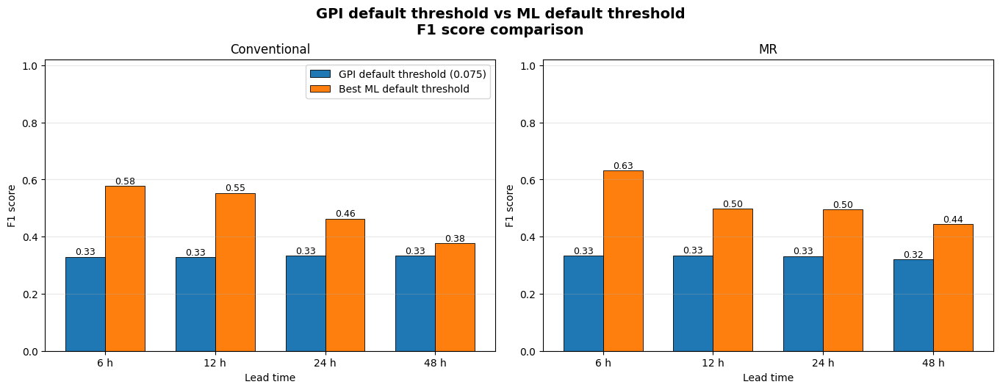

Saved: C:\Users\_s2218026\Documents\lab\GPI_DEFAULT_vs_ML_DEFAULT_Conventional_vs_MR\plots\gpi_default_vs_ml_default_f1_comparison.png


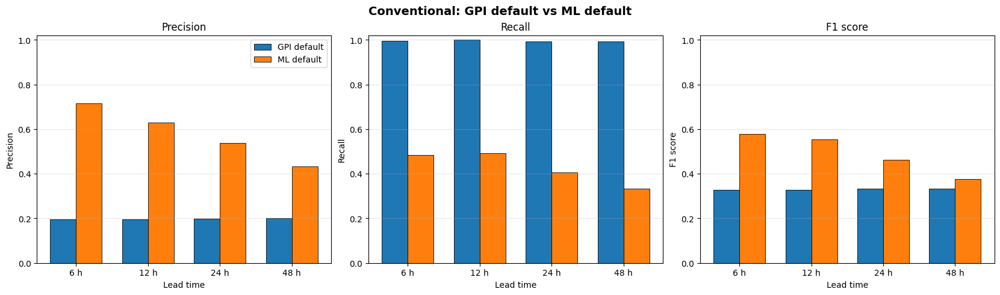

Saved: C:\Users\_s2218026\Documents\lab\GPI_DEFAULT_vs_ML_DEFAULT_Conventional_vs_MR\plots\Conventional_gpi_default_vs_ml_default_precision_recall_f1.png


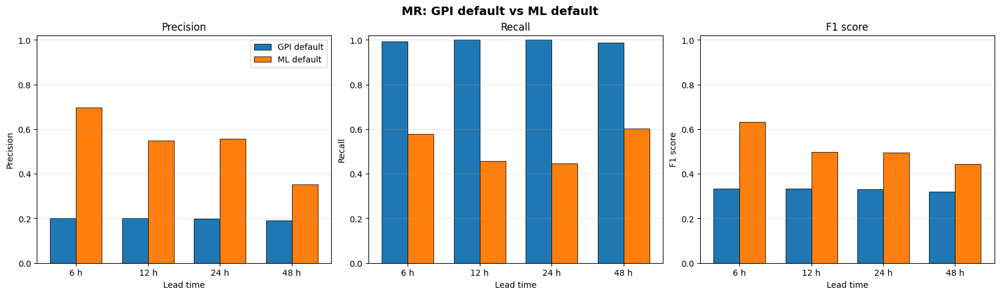

Saved: C:\Users\_s2218026\Documents\lab\GPI_DEFAULT_vs_ML_DEFAULT_Conventional_vs_MR\plots\MR_gpi_default_vs_ml_default_precision_recall_f1.png

CELL 2 DONE
Output directory: C:\Users\_s2218026\Documents\lab\GPI_DEFAULT_vs_ML_DEFAULT_Conventional_vs_MR


In [6]:
# ============================================================
# CELL 2 — GPI DEFAULT vs ML DEFAULT COMPARISON
# Run Cell 1 first.
# ============================================================

# ============================================================
# 1. GPI DEFAULT THRESHOLD METRICS
# ============================================================

gpi_rows = []

if len(case_all) == 0:
    print("[SKIP] case_all is empty.")
else:
    for (dataset, lead), sub in case_all.groupby(["dataset", "lead_h"]):
        y_true = sub["y"].astype(int).values
        gpi = sub["gpi_used"].astype(float).values

        y_pred = (gpi >= GPI_DEFAULT_THRESHOLD).astype(int)

        try:
            roc_auc = roc_auc_score(y_true, gpi)
        except Exception:
            roc_auc = np.nan

        try:
            pr_auc = average_precision_score(y_true, gpi)
        except Exception:
            pr_auc = np.nan

        gpi_rows.append({
            "dataset": dataset,
            "lead_h": int(lead),
            "method": "GPI default threshold",
            "model": "GPI",
            "threshold": GPI_DEFAULT_THRESHOLD,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "n": int(len(y_true)),
            "positive_n": int(y_true.sum()),
            "negative_n": int((y_true == 0).sum()),
            "tn": int(((y_true == 0) & (y_pred == 0)).sum()),
            "fp": int(((y_true == 0) & (y_pred == 1)).sum()),
            "fn": int(((y_true == 1) & (y_pred == 0)).sum()),
            "tp": int(((y_true == 1) & (y_pred == 1)).sum()),
        })

gpi_default = pd.DataFrame(gpi_rows)

# ============================================================
# 2. ML DEFAULT THRESHOLD METRICS
# ============================================================

ml_rows = []

if len(oof_all) == 0:
    print("[SKIP] oof_all is empty.")
else:
    for (dataset, lead, model), sub in oof_all.groupby(["dataset", "lead_h", "model"]):
        if int(lead) not in LEADS:
            continue

        y_true = sub["y_true"].astype(int).values
        y_score = sub["y_score"].astype(float).values

        if "y_pred_default" in sub.columns:
            y_pred = sub["y_pred_default"].astype(int).values
        elif "y_pred" in sub.columns:
            y_pred = sub["y_pred"].astype(int).values
        else:
            y_pred = (y_score >= 0.5).astype(int)

        try:
            roc_auc = roc_auc_score(y_true, y_score)
        except Exception:
            roc_auc = np.nan

        try:
            pr_auc = average_precision_score(y_true, y_score)
        except Exception:
            pr_auc = np.nan

        ml_rows.append({
            "dataset": dataset,
            "lead_h": int(lead),
            "method": "ML default threshold",
            "model": model,
            "threshold": 0.5,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "n": int(len(y_true)),
            "positive_n": int(y_true.sum()),
            "negative_n": int((y_true == 0).sum()),
            "tn": int(((y_true == 0) & (y_pred == 0)).sum()),
            "fp": int(((y_true == 0) & (y_pred == 1)).sum()),
            "fn": int(((y_true == 1) & (y_pred == 0)).sum()),
            "tp": int(((y_true == 1) & (y_pred == 1)).sum()),
        })

ml_default_all = pd.DataFrame(ml_rows)

if len(ml_default_all) > 0:
    ml_default_best = (
        ml_default_all
        .sort_values(["dataset", "lead_h", "f1"], ascending=[True, True, False])
        .groupby(["dataset", "lead_h"], as_index=False)
        .first()
    )
else:
    ml_default_best = pd.DataFrame()

# ============================================================
# 3. COMBINE TABLES
# ============================================================

comparison = pd.concat(
    [
        gpi_default,
        ml_default_best,
    ],
    ignore_index=True
)

gpi_default.to_csv(TABLE_DIR / "gpi_default_threshold_metrics.csv", index=False)
ml_default_all.to_csv(TABLE_DIR / "ml_default_all_models_metrics.csv", index=False)
ml_default_best.to_csv(TABLE_DIR / "ml_default_best_models_by_lead.csv", index=False)
comparison.to_csv(TABLE_DIR / "gpi_default_vs_ml_default_comparison.csv", index=False)

print("GPI default threshold:")
print(GPI_DEFAULT_THRESHOLD)

print("\nGPI default metrics:")
display(gpi_default)

print("\nBest ML default model by lead:")
display(
    ml_default_best[
        [
            "dataset", "lead_h", "model",
            "precision", "recall", "f1",
            "roc_auc", "pr_auc",
        ]
    ] if len(ml_default_best) > 0 else ml_default_best
)

print("\nCombined comparison:")
display(
    comparison[
        [
            "dataset", "lead_h", "method", "model",
            "threshold", "precision", "recall", "f1",
            "roc_auc", "pr_auc",
        ]
    ] if len(comparison) > 0 else comparison
)

# ============================================================
# 4. BAR PLOT — F1 COMPARISON
# ============================================================

if len(comparison) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)

    for ax, dataset in zip(axes, [OLD_NAME, NEW_NAME]):
        sub = comparison[comparison["dataset"] == dataset].copy()

        gpi_sub = sub[sub["method"] == "GPI default threshold"].sort_values("lead_h")
        ml_sub = sub[sub["method"] == "ML default threshold"].sort_values("lead_h")

        x = np.arange(len(LEADS))
        width = 0.36

        ax.bar(
            x - width / 2,
            gpi_sub["f1"],
            width=width,
            label=f"GPI default threshold ({GPI_DEFAULT_THRESHOLD})",
            edgecolor="black",
            linewidth=0.6,
        )

        ax.bar(
            x + width / 2,
            ml_sub["f1"],
            width=width,
            label="Best ML default threshold",
            edgecolor="black",
            linewidth=0.6,
        )

        ax.set_xticks(x)
        ax.set_xticklabels([f"{L} h" for L in LEADS])
        ax.set_ylim(0, 1.02)
        ax.set_xlabel("Lead time")
        ax.set_ylabel("F1 score")
        ax.set_title(dataset)
        ax.grid(True, axis="y", alpha=0.3)

        for i, val in enumerate(gpi_sub["f1"].values):
            ax.text(i - width / 2, val, f"{val:.2f}", ha="center", va="bottom", fontsize=9)

        for i, val in enumerate(ml_sub["f1"].values):
            ax.text(i + width / 2, val, f"{val:.2f}", ha="center", va="bottom", fontsize=9)

    axes[0].legend()

    fig.suptitle(
        "GPI default threshold vs ML default threshold\n"
        "F1 score comparison",
        fontsize=14,
        fontweight="bold",
    )

    out_png = PLOT_DIR / "gpi_default_vs_ml_default_f1_comparison.png"
    plt.savefig(out_png, dpi=250, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)

# ============================================================
# 5. BAR PLOTS — PRECISION / RECALL / F1
# ============================================================

if len(comparison) > 0:
    metric_list = [
        ("precision", "Precision"),
        ("recall", "Recall"),
        ("f1", "F1 score"),
    ]

    for dataset in [OLD_NAME, NEW_NAME]:
        fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8), constrained_layout=True)

        sub = comparison[comparison["dataset"] == dataset].copy()

        gpi_sub = sub[sub["method"] == "GPI default threshold"].sort_values("lead_h")
        ml_sub = sub[sub["method"] == "ML default threshold"].sort_values("lead_h")

        x = np.arange(len(LEADS))
        width = 0.36

        for ax, (metric, ylabel) in zip(axes, metric_list):
            ax.bar(
                x - width / 2,
                gpi_sub[metric],
                width=width,
                label=f"GPI default",
                edgecolor="black",
                linewidth=0.6,
            )

            ax.bar(
                x + width / 2,
                ml_sub[metric],
                width=width,
                label="ML default",
                edgecolor="black",
                linewidth=0.6,
            )

            ax.set_xticks(x)
            ax.set_xticklabels([f"{L} h" for L in LEADS])
            ax.set_ylim(0, 1.02)
            ax.set_xlabel("Lead time")
            ax.set_ylabel(ylabel)
            ax.set_title(ylabel)
            ax.grid(True, axis="y", alpha=0.3)

        axes[0].legend()

        fig.suptitle(
            f"{dataset}: GPI default vs ML default",
            fontsize=14,
            fontweight="bold",
        )

        safe_dataset = dataset.replace(" ", "_")
        out_png = PLOT_DIR / f"{safe_dataset}_gpi_default_vs_ml_default_precision_recall_f1.png"
        plt.savefig(out_png, dpi=250, bbox_inches="tight")
        plt.show()

        print("Saved:", out_png)

print("\nCELL 2 DONE")
print("Output directory:", OUT_DIR)